# 06A. 사업명 단어 동시출현 네트워크 분석

이 노트북은 03번 사업명 텍스트 분석 결과를 입력으로 사용하여, 사업명에 함께 등장하는 주요 단어들의 동시출현 네트워크를 탐색적으로 분석한다.

## 작업 목적

- 사업명 단위의 단어 pair 생성
- 단어 동시출현 edge list 생성
- 단어 node list 생성
- edge weight 계산
- 중심성 분석 및 커뮤니티 탐지 준비
- 포스터용 표와 그림 후보 생성을 위한 기초 네트워크 산출물 준비

## 기본 입력 파일

- 입력 파일: `03_project_name_text_analysis_v1_20260529_0135.parquet`
- 입력 위치:  
  `[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/final`

## 기본 분석 기준

- 기본 토큰 열: `tokens_analysis_primary`
- 비교용 토큰 열: `tokens_analysis_second_filter`
- 원본 열은 덮어쓰지 않는다.
- 네트워크 분석용 DataFrame과 산출물은 별도 변수로 생성한다.
- 이 노트북의 결과는 정책효과나 성과 우열이 아니라, 사업명 텍스트에 나타나는 정책어휘 간 연결 구조를 탐색적으로 보여주는 것이다.

## 주의사항

- `20260526_1935` 파일이 아니라 `20260529_0135` 파일을 사용한다.
- `v1_row_id`는 원본 V1 데이터의 행 순서 기준 식별자이다.
- 03번 master는 사업명 결측 14행을 제외한 79,262행 기준 데이터이다.
- NetworkX의 betweenness centrality 계산 시, 동시출현 weight를 그대로 거리로 쓰지 않고 `distance = 1 / weight`를 만들어 사용한다.

In [6]:
# 06A-1. 라이브러리 불러오기 및 경로 설정

# 기본 데이터 처리
import os
import ast
import math
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
from itertools import combinations

import pandas as pd
import numpy as np

# 네트워크 분석
import networkx as nx

# 시각화
import matplotlib.pyplot as plt

# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------------------
# 1) 실행 설정
# ------------------------------------------------------------

# 저장 여부 기본값
# 확인용 단계에서는 저장하지 않고, 최종 저장 단계에서만 True로 변경한다.
SAVE_OUTPUT = True

# 분석 버전
RUN_VERSION = "v1"

# 실행 timestamp
# 파일 저장 단계에서만 파일명에 사용할 예정
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)
print("SAVE_OUTPUT:", SAVE_OUTPUT)

# ------------------------------------------------------------
# 2) 프로젝트 경로 설정
# ------------------------------------------------------------

# 사용자의 Drive 구조에 맞게 기본 프로젝트 경로를 설정한다.
# 경로가 다르면 이 부분만 수정하면 된다.
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보"
)

# 06A 입력 파일: 반드시 20260529_0135 버전 사용
INPUT_03_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "final"
    / "03_project_name_text_analysis_v1_20260529_0135.parquet"
)

# 06A 산출물 저장 예정 폴더
OUTPUT_ROOT = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "06A_v1_단어동시출현네트워크"
)

TABLE_FINAL_DIR = OUTPUT_ROOT / "tables" / "final"
TABLE_REVIEW_DIR = OUTPUT_ROOT / "tables" / "review"
TABLE_ARCHIVE_DIR = OUTPUT_ROOT / "tables" / "archive_intermediate"

FIGURE_FINAL_DIR = OUTPUT_ROOT / "figures" / "final"
FIGURE_REVIEW_DIR = OUTPUT_ROOT / "figures" / "review"
FIGURE_ARCHIVE_DIR = OUTPUT_ROOT / "figures" / "archive_intermediate"

# ------------------------------------------------------------
# 3) 경로 확인
# ------------------------------------------------------------

print("\n[입력 파일 경로]")
print(INPUT_03_PATH)

print("\n[입력 파일 존재 여부]")
print(INPUT_03_PATH.exists())

print("\n[06A 산출물 저장 예정 폴더]")
print(OUTPUT_ROOT)

# 이 단계에서는 폴더를 만들지 않는다.
# 저장 단계에서 SAVE_OUTPUT=True일 때만 폴더를 생성한다.
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)
    print("\n저장 폴더 생성 완료")
else:
    print("\nSAVE_OUTPUT=False이므로 이 단계에서는 폴더를 생성하지 않습니다.")

Mounted at /content/drive
RUN_VERSION: v1
RUN_TS: 20260611_0742
SAVE_OUTPUT: True

[입력 파일 경로]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/final/03_project_name_text_analysis_v1_20260529_0135.parquet

[입력 파일 존재 여부]
True

[06A 산출물 저장 예정 폴더]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크

저장 폴더 생성 완료


In [ ]:
# 06A-2. 03번 사업명 텍스트 분석 master 불러오기 및 기본 구조 확인

# ------------------------------------------------------------
# 1) 최신 03번 master 불러오기
# ------------------------------------------------------------

df_03 = pd.read_parquet(INPUT_03_PATH)

print("[03번 master 불러오기 완료]")
print("행 수:", len(df_03))
print("열 수:", df_03.shape[1])

# ------------------------------------------------------------
# 2) 06A 필수 열 존재 여부 확인
# ------------------------------------------------------------

required_cols_06a = [
    "v1_row_id",
    "시도",
    "지자체명",
    "원파일명",
    "사업명",
    "사업명_clean",
    "사업명_clean_spacefix",
    "tokens_analysis_primary",
    "tokens_analysis_second_filter",
    "보조사업자",
    "평가결과",
    "평가종류",
]

missing_cols_06a = [col for col in required_cols_06a if col not in df_03.columns]

print("\n[06A 필수 열 확인]")
if len(missing_cols_06a) == 0:
    print("필수 열 모두 존재")
else:
    print("누락된 필수 열:", missing_cols_06a)

# ------------------------------------------------------------
# 3) 기본 식별자 및 행 수 점검
# ------------------------------------------------------------

basic_check = pd.DataFrame({
    "항목": [
        "전체 행 수",
        "전체 열 수",
        "v1_row_id 존재 여부",
        "v1_row_id 결측 수",
        "v1_row_id 중복 수",
        "v1_row_id 최소값",
        "v1_row_id 최대값",
        "원파일명 존재 여부",
        "원파일명 결측 수",
    ],
    "값": [
        len(df_03),
        df_03.shape[1],
        "v1_row_id" in df_03.columns,
        df_03["v1_row_id"].isna().sum() if "v1_row_id" in df_03.columns else None,
        df_03["v1_row_id"].duplicated().sum() if "v1_row_id" in df_03.columns else None,
        df_03["v1_row_id"].min() if "v1_row_id" in df_03.columns else None,
        df_03["v1_row_id"].max() if "v1_row_id" in df_03.columns else None,
        "원파일명" in df_03.columns,
        df_03["원파일명"].isna().sum() if "원파일명" in df_03.columns else None,
    ]
})

print("\n[기본 구조 점검]")
display(basic_check)

# ------------------------------------------------------------
# 4) 토큰 열을 안전하게 list로 변환하는 함수
# ------------------------------------------------------------

def normalize_token_list(x):
    """
    토큰 열의 값을 안전하게 list 형태로 변환하는 함수.

    처리 대상:
    - list
    - tuple
    - set
    - numpy array
    - 문자열 형태의 list
    - 결측값

    주의:
    parquet에서 토큰 열이 numpy array 형태로 읽히는 경우가 있으므로,
    pd.isna(x)를 먼저 적용하지 않는다.
    """

    # None은 빈 리스트 처리
    if x is None:
        return []

    # numpy array인 경우 먼저 list로 변환
    if isinstance(x, np.ndarray):
        return [
            str(token).strip()
            for token in x.tolist()
            if token is not None and str(token).strip() != ""
        ]

    # list, tuple, set인 경우
    if isinstance(x, (list, tuple, set)):
        return [
            str(token).strip()
            for token in list(x)
            if token is not None and str(token).strip() != ""
        ]

    # 문자열인 경우
    # 예: "['복지', '노인', '지원']" 형태를 대비
    if isinstance(x, str):
        text = x.strip()

        if text == "" or text.lower() in ["nan", "none", "null"]:
            return []

        try:
            parsed = ast.literal_eval(text)

            if isinstance(parsed, np.ndarray):
                return [
                    str(token).strip()
                    for token in parsed.tolist()
                    if token is not None and str(token).strip() != ""
                ]

            if isinstance(parsed, (list, tuple, set)):
                return [
                    str(token).strip()
                    for token in list(parsed)
                    if token is not None and str(token).strip() != ""
                ]

        except Exception:
            # 문자열이지만 list 형태가 아니면 토큰 리스트로 보지 않음
            return []

    # 그 외 스칼라 결측값 처리
    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    return []


def safe_token_len(x):
    """
    normalize_token_list로 변환한 뒤 토큰 개수를 반환한다.
    """
    return len(normalize_token_list(x))

# ------------------------------------------------------------
# 5) 토큰 열 기본 점검
# ------------------------------------------------------------

token_cols = [
    "tokens_analysis_primary",
    "tokens_analysis_second_filter",
]

token_empty_rows = []

for col in token_cols:
    if col in df_03.columns:
        token_lengths = df_03[col].apply(safe_token_len)

        token_empty_rows.append({
            "토큰열": col,
            "결측 수": int(df_03[col].isna().sum()),
            "빈 토큰 행 수": int((token_lengths == 0).sum()),
            "평균 토큰 수": round(token_lengths.mean(), 3),
            "최소 토큰 수": int(token_lengths.min()),
            "최대 토큰 수": int(token_lengths.max()),
        })
    else:
        token_empty_rows.append({
            "토큰열": col,
            "결측 수": None,
            "빈 토큰 행 수": None,
            "평균 토큰 수": None,
            "최소 토큰 수": None,
            "최대 토큰 수": None,
        })

token_empty_check = pd.DataFrame(token_empty_rows)

print("\n[토큰 열 기본 점검]")
display(token_empty_check)

# ------------------------------------------------------------
# 6) 토큰 열 실제 자료형 샘플 확인
# ------------------------------------------------------------

token_type_check = []

for col in token_cols:
    if col in df_03.columns:
        sample_types = (
            df_03[col]
            .dropna()
            .head(20)
            .apply(lambda x: type(x).__name__)
            .value_counts()
            .reset_index()
        )

        sample_types.columns = ["자료형", "샘플 내 개수"]
        sample_types.insert(0, "토큰열", col)

        token_type_check.append(sample_types)

if len(token_type_check) > 0:
    token_type_check = pd.concat(token_type_check, ignore_index=True)

    print("\n[토큰 열 자료형 샘플 확인]")
    display(token_type_check)

# ------------------------------------------------------------
# 7) 분석에 사용할 주요 열 미리보기
# ------------------------------------------------------------

preview_cols = [col for col in required_cols_06a if col in df_03.columns]

print("\n[주요 열 미리보기]")
display(df_03[preview_cols].head(10))

# ------------------------------------------------------------
# 8) 정상 기준 간단 판정
# ------------------------------------------------------------

print("\n[06A-2 간단 판정]")

if len(missing_cols_06a) == 0:
    print("- 필수 열: 정상")
else:
    print("- 필수 열: 확인 필요")

if "v1_row_id" in df_03.columns:
    if df_03["v1_row_id"].isna().sum() == 0 and df_03["v1_row_id"].duplicated().sum() == 0:
        print("- v1_row_id: 정상")
    else:
        print("- v1_row_id: 결측 또는 중복 확인 필요")

if "원파일명" in df_03.columns:
    if df_03["원파일명"].isna().sum() == 0:
        print("- 원파일명: 정상")
    else:
        print("- 원파일명: 결측 확인 필요")

if len(df_03) == 79262:
    print("- 행 수: 정상")
else:
    print("- 행 수: 기존 기준과 다름. 확인 필요")

print("\n06A-2 실행 완료")

[03번 master 불러오기 완료]
행 수: 79262
열 수: 43

[06A 필수 열 확인]
필수 열 모두 존재

[기본 구조 점검]


,항목,값
0,전체 행 수,79262
1,전체 열 수,43
2,v1_row_id 존재 여부,True
3,v1_row_id 결측 수,0
4,v1_row_id 중복 수,0
5,v1_row_id 최소값,0
6,v1_row_id 최대값,79275
7,원파일명 존재 여부,True
8,원파일명 결측 수,0



[토큰 열 기본 점검]


,토큰열,결측 수,빈 토큰 행 수,평균 토큰 수,최소 토큰 수,최대 토큰 수
0,tokens_analysis_primary,0,61,4.184,0,19
1,tokens_analysis_second_filter,0,62,4.055,0,18



[토큰 열 자료형 샘플 확인]


,토큰열,자료형,샘플 내 개수
0,tokens_analysis_primary,ndarray,20
1,tokens_analysis_second_filter,ndarray,20



[주요 열 미리보기]


,v1_row_id,시도,지자체명,원파일명,사업명,사업명_clean,사업명_clean_spacefix,tokens_analysis_primary,tokens_analysis_second_filter,보조사업자,평가결과,평가종류
0,0,경남,남해군,경남_남해군.xlsx,마늘재배 영농지원단 지원,마늘재배 영농지원단 지원,마늘재배 영농지원단 지원,"[마늘, 재배, 영농, 지원단]","[마늘, 재배, 영농, 지원단]",농협중앙회 남해군지부,매우우수,유지필요성평가
1,1,경남,남해군,경남_남해군.xlsx,2023년 사)진주지역범죄피해자지원센터‘등불 ’남해지부 운영,2023년 사)진주지역범죄피해자지원센터'등불 '남해지부 운영,2023년 사)진주지역범죄피해자지원센터'등불 '남해지부 운영,"[지역, 범죄, 피해자, 센터, 등불, 지부]","[지역, 범죄, 피해자, 센터, 등불, 지부]",사단법인진주지역범죄피 해자지원센터남해지부,미흡,유지필요성평가
2,2,경남,남해군,경남_남해군.xlsx,자유민주주의신장 및 자유선진의식 고취,자유민주주의신장 및 자유선진의식 고취,자유민주주의신장 및 자유선진의식 고취,"[자유, 민주주의, 신장, 자유선진, 의식, 고취]","[자유, 민주주의, 신장, 자유선진, 의식, 고취]",한국자유총연맹남해군지 회,미흡,유지필요성평가
3,3,경남,남해군,경남_남해군.xlsx,보물섬 독서학교 지원,보물섬 독서학교 지원,보물섬 독서학교 지원,"[보물섬, 독서, 학교]","[보물섬, 독서, 학교]",보물섬남해독서학교,미흡,유지필요성평가
4,4,경남,남해군,경남_남해군.xlsx,참전경찰유공자 보훈활동,참전경찰유공자 보훈활동,참전경찰유공자 보훈활동,"[참전, 경찰, 유공자, 보훈, 활동]","[참전, 경찰, 유공자, 보훈, 활동]",한국참전경찰유공자회,미흡,유지필요성평가
5,5,경남,남해군,경남_남해군.xlsx,무공수훈자회 운영비 보조,무공수훈자회 운영비 보조,무공수훈자회 운영비 보조,"[무공, 수훈자]","[무공, 수훈자]",대한민국무공수훈자회남 해 군 지 회,미흡,유지필요성평가
6,6,경남,남해군,경남_남해군.xlsx,행복나눔센터 운영,행복나눔센터 운영,행복나눔센터 운영,"[행복, 센터]","[행복, 센터]",남해군지역사회보장협의 체,미흡,유지필요성평가
7,7,경남,남해군,경남_남해군.xlsx,경로당 양곡구입비 지원,경로당 양곡구입비 지원,경로당 양곡구입비 지원,"[경로당, 양곡, 구입비]","[경로당, 양곡, 구입비]",봉내경로당 외 10개소,미흡,유지필요성평가
8,8,경남,남해군,경남_남해군.xlsx,장애인직업재활 자활교육,장애인직업재활 자활교육,장애인직업재활 자활교육,"[장애인, 직업, 재활, 자활, 교육]","[장애인, 직업, 재활, 자활, 교육]",남해장애인종합복지관,미흡,유지필요성평가
9,9,경남,남해군,경남_남해군.xlsx,어린이집 운전기사 인건비 (미조지역영유아수송),어린이집 운전기사 인건비 (미조지역영유아수송),어린이집 운전기사 인건비 (미조지역영유아수송),"[어린이집, 운전기사, 미조, 지역, 영유아, 수송]","[어린이집, 운전기사, 미조, 지역, 영유아, 수송]",모 모 어 린 이 집,미흡,유지필요성평가



[06A-2 간단 판정]
- 필수 열: 정상
- v1_row_id: 정상
- 원파일명: 정상
- 행 수: 정상

06A-2 실행 완료


In [ ]:
# 06A-3. 네트워크 분석용 토큰 기본 점검

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 아래 값을 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")


# ------------------------------------------------------------
# 1) 네트워크 분석용 기본 토큰 열 설정
# ------------------------------------------------------------

BASE_TOKEN_COL = "tokens_analysis_primary"
COMPARE_TOKEN_COL = "tokens_analysis_second_filter"

print("\n[사용 토큰 열]")
print("기본 분석 토큰:", BASE_TOKEN_COL)
print("비교용 토큰:", COMPARE_TOKEN_COL)


# ------------------------------------------------------------
# 2) 네트워크 분석용 DataFrame 생성
# ------------------------------------------------------------
# 원본 df_03은 그대로 두고, 네트워크 분석용 df_network를 별도로 만든다.

network_base_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "원파일명",
    "사업명",
    "사업명_clean",
    "사업명_clean_spacefix",
    BASE_TOKEN_COL,
    COMPARE_TOKEN_COL,
    "보조사업자",
    "평가결과",
    "평가종류",
]

network_base_cols = [col for col in network_base_cols if col in df_03.columns]

df_network = df_03[network_base_cols].copy()

print("\n[df_network 생성 완료]")
print("행 수:", len(df_network))
print("열 수:", df_network.shape[1])


# ------------------------------------------------------------
# 3) 토큰 정규화 및 중복 제거
# ------------------------------------------------------------
# 한 사업명 안에서 같은 단어가 반복되면 pair 생성 시 중복 연결이 과대 계산될 수 있다.
# 따라서 기본 네트워크에서는 사업명 단위 중복 토큰을 제거한다.
#
# 예: [환경, 개선, 환경, 시설] -> [환경, 개선, 시설]

def unique_preserve_order(tokens):
    """
    토큰 리스트에서 순서를 유지하면서 중복을 제거한다.
    """
    seen = set()
    result = []

    for token in tokens:
        if token not in seen:
            seen.add(token)
            result.append(token)

    return result


df_network["tokens_network_base"] = df_network[BASE_TOKEN_COL].apply(normalize_token_list)
df_network["tokens_network_unique"] = df_network["tokens_network_base"].apply(unique_preserve_order)

df_network["token_count_base"] = df_network["tokens_network_base"].apply(len)
df_network["token_count_unique"] = df_network["tokens_network_unique"].apply(len)
df_network["token_duplicate_removed_count"] = (
    df_network["token_count_base"] - df_network["token_count_unique"]
)

print("\n[토큰 정규화 및 중복 제거 완료]")
print("기본 토큰 빈 행 수:", int((df_network["token_count_base"] == 0).sum()))
print("중복 제거 후 빈 행 수:", int((df_network["token_count_unique"] == 0).sum()))
print("중복 토큰이 제거된 행 수:", int((df_network["token_duplicate_removed_count"] > 0).sum()))


# ------------------------------------------------------------
# 4) 토큰 수 분포 점검
# ------------------------------------------------------------

token_count_summary = pd.DataFrame({
    "항목": [
        "전체 행 수",
        "기본 토큰 빈 행 수",
        "중복 제거 후 빈 행 수",
        "기본 토큰 평균 개수",
        "중복 제거 후 평균 개수",
        "기본 토큰 최대 개수",
        "중복 제거 후 최대 개수",
        "중복 토큰 제거 발생 행 수",
    ],
    "값": [
        len(df_network),
        int((df_network["token_count_base"] == 0).sum()),
        int((df_network["token_count_unique"] == 0).sum()),
        round(df_network["token_count_base"].mean(), 3),
        round(df_network["token_count_unique"].mean(), 3),
        int(df_network["token_count_base"].max()),
        int(df_network["token_count_unique"].max()),
        int((df_network["token_duplicate_removed_count"] > 0).sum()),
    ]
})

print("\n[토큰 수 분포 요약]")
display(token_count_summary)


# ------------------------------------------------------------
# 5) 전체 단어 빈도표 생성
# ------------------------------------------------------------
# 중복 제거 전 빈도: 사업명 안 반복 토큰도 포함
# 중복 제거 후 빈도: 한 사업명 안에서는 같은 단어를 1회만 계산
#
# 06A 네트워크 기준은 중복 제거 후 빈도를 우선 사용한다.

all_tokens_base = []
all_tokens_unique = []

for tokens in df_network["tokens_network_base"]:
    all_tokens_base.extend(tokens)

for tokens in df_network["tokens_network_unique"]:
    all_tokens_unique.extend(tokens)

word_freq_base = (
    pd.DataFrame(Counter(all_tokens_base).items(), columns=["word", "freq_base"])
    .sort_values(["freq_base", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

word_freq_unique = (
    pd.DataFrame(Counter(all_tokens_unique).items(), columns=["word", "doc_freq_unique"])
    .sort_values(["doc_freq_unique", "word"], ascending=[False, True])
    .reset_index(drop=True)
)

word_freq_check = word_freq_unique.merge(
    word_freq_base,
    on="word",
    how="left"
)

word_freq_check["duplicate_gap"] = (
    word_freq_check["freq_base"] - word_freq_check["doc_freq_unique"]
)

print("\n[단어 빈도표 생성 완료]")
print("중복 제거 전 고유 단어 수:", len(word_freq_base))
print("중복 제거 후 고유 단어 수:", len(word_freq_unique))

print("\n[중복 제거 후 단어 빈도 상위 30개]")
display(word_freq_check.head(30))


# ------------------------------------------------------------
# 6) 최소 등장 빈도 기준 후보 점검
# ------------------------------------------------------------
# 아직 기준을 확정하지 않고, 20회/30회/50회/100회 기준에서
# 남는 단어 수를 비교한다.

min_freq_candidates = [10, 20, 30, 50, 100, 200]

min_freq_check_rows = []

for min_freq in min_freq_candidates:
    n_words = int((word_freq_check["doc_freq_unique"] >= min_freq).sum())

    min_freq_check_rows.append({
        "min_doc_freq_unique": min_freq,
        "남는 단어 수": n_words,
    })

min_freq_check = pd.DataFrame(min_freq_check_rows)

print("\n[최소 등장 빈도 기준 후보]")
display(min_freq_check)


# ------------------------------------------------------------
# 7) 토큰 수가 너무 적거나 많은 사례 확인
# ------------------------------------------------------------

empty_token_cases = df_network.loc[
    df_network["token_count_unique"] == 0,
    [
        "v1_row_id",
        "시도",
        "지자체명",
        "원파일명",
        "사업명",
        "사업명_clean_spacefix",
        "tokens_network_unique",
    ]
].copy()

long_token_cases = df_network.sort_values(
    "token_count_unique",
    ascending=False
).head(30)[
    [
        "v1_row_id",
        "시도",
        "지자체명",
        "원파일명",
        "사업명",
        "사업명_clean_spacefix",
        "tokens_network_unique",
        "token_count_unique",
    ]
].copy()

print("\n[빈 토큰 사례 일부]")
display(empty_token_cases.head(20))

print("\n[토큰 수가 많은 사례 상위 30개]")
display(long_token_cases)


# ------------------------------------------------------------
# 8) 확인용 산출물 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    word_freq_path = TABLE_REVIEW_DIR / f"06A_word_frequency_check_{RUN_VERSION}_{RUN_TS}.csv"
    token_count_summary_path = TABLE_REVIEW_DIR / f"06A_token_count_summary_{RUN_VERSION}_{RUN_TS}.csv"
    min_freq_check_path = TABLE_REVIEW_DIR / f"06A_min_frequency_candidate_check_{RUN_VERSION}_{RUN_TS}.csv"
    empty_token_cases_path = TABLE_REVIEW_DIR / f"06A_empty_token_cases_{RUN_VERSION}_{RUN_TS}.csv"
    long_token_cases_path = TABLE_REVIEW_DIR / f"06A_long_token_cases_{RUN_VERSION}_{RUN_TS}.csv"

    word_freq_check.to_csv(word_freq_path, index=False, encoding="utf-8-sig")
    token_count_summary.to_csv(token_count_summary_path, index=False, encoding="utf-8-sig")
    min_freq_check.to_csv(min_freq_check_path, index=False, encoding="utf-8-sig")
    empty_token_cases.to_csv(empty_token_cases_path, index=False, encoding="utf-8-sig")
    long_token_cases.to_csv(long_token_cases_path, index=False, encoding="utf-8-sig")

    print("\n[저장 완료]")
    print(word_freq_path)
    print(token_count_summary_path)
    print(min_freq_check_path)
    print(empty_token_cases_path)
    print(long_token_cases_path)
else:
    print("\nSAVE_OUTPUT=False이므로 확인용 산출물을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 9) 06A-3 간단 판정
# ------------------------------------------------------------

print("\n[06A-3 간단 판정]")
print("- df_network 생성:", "정상" if len(df_network) == len(df_03) else "확인 필요")
print("- 기본 토큰 열:", BASE_TOKEN_COL)
print("- 네트워크 기준 토큰 열: tokens_network_unique")
print("- 중복 제거 후 빈 토큰 행 수:", int((df_network["token_count_unique"] == 0).sum()))
print("- 중복 제거 후 고유 단어 수:", len(word_freq_unique))
print("\n06A-3 실행 완료")

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.

[사용 토큰 열]
기본 분석 토큰: tokens_analysis_primary
비교용 토큰: tokens_analysis_second_filter

[df_network 생성 완료]
행 수: 79262
열 수: 12

[토큰 정규화 및 중복 제거 완료]
기본 토큰 빈 행 수: 61
중복 제거 후 빈 행 수: 61
중복 토큰이 제거된 행 수: 3139

[토큰 수 분포 요약]


,항목,값
0,전체 행 수,79262.000
1,기본 토큰 빈 행 수,61.000
2,중복 제거 후 빈 행 수,61.000
3,기본 토큰 평균 개수,4.184
4,중복 제거 후 평균 개수,4.126
5,기본 토큰 최대 개수,19.000
6,중복 제거 후 최대 개수,17.000
7,중복 토큰 제거 발생 행 수,3139.000



[단어 빈도표 생성 완료]
중복 제거 전 고유 단어 수: 18151
중복 제거 후 고유 단어 수: 18151

[중복 제거 후 단어 빈도 상위 30개]


,word,doc_freq_unique,freq_base,duplicate_gap
0,대회,8525,8704,179
1,장애인,5164,5392,228
2,체육,3927,4031,104
3,행사,3846,3885,39
4,시설,3327,3395,68
5,센터,2755,2807,52
6,문화,2613,2728,115
7,교육,2472,2508,36
8,단체,2405,2467,62
9,지역,2390,2447,57



[최소 등장 빈도 기준 후보]


...


[빈 토큰 사례 일부]


,v1_row_id,시도,지자체명,원파일명,사업명,사업명_clean_spacefix,tokens_network_unique
1632,1632,경남,양산시,경남_양산시.xlsx,운영비,운영비,[]
1841,1841,경남,창원시,경남_창원시.xlsx,열아홉을 위하여,열아홉을 위하여,[]
7472,7472,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
7473,7473,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
7474,7474,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
7475,7475,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
7476,7476,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
7477,7477,경남,김해시,V1 후보_성과_경남_김해시.xlsx,김해바로알기 운영,김해바로알기 운영,[]
9172,9172,경남,본청,V1 후보_경남_본청.xlsx,경남을 찾아서 展 지원,경남을 찾아서 展 지원,[]
9374,9374,경남,본청,V1 후보_경남_본청.xlsx,다함께 해 봄,다함께 해 봄,[]



[토큰 수가 많은 사례 상위 30개]


,v1_row_id,시도,지자체명,원파일명,사업명,사업명_clean_spacefix,tokens_network_unique,token_count_unique
77565,77579,광주,서구,광주_서구.xlsx,어르 신전 담생 활체 육지 도자 활동 지원 어르신전담생활체육지도자피복비및운동용품,어르 신전 담생 활체 육지 도자 활동 지원 어르신전담생활체육지도자피복비및운동용품,"[신전, 담, 생, 활, 체, 육지, 도자, 활동, 어르신, 전담, 생활, 체육, ...",17
8409,8409,경남,본청,V1 후보_경남_본청.xlsx,국제 및 전국규모 스포츠대회 유치지원(전문체육) (통영) 윤덕주배 제35회 연맹회장...,국제 및 전국규모 스포츠대회 유치지원(전문체육) (통영) 윤덕주배 제35회 연맹회장...,"[국제, 전국, 규모, 스포츠, 대회, 유치, 전문, 체육, 윤, 덕, 주, 연맹,...",16
17122,17123,서울,본청,서울_본청.xlsx,양천자원회수시설 주변영향지역 아파트 관리비 및 주거환경개선사업비 지원 307-02 ...,양천자원회수시설 주변영향지역 아파트 관리비 및 주거환경개선사업비 지원 307-02 ...,"[양천, 자원, 회수, 시설, 주변, 영향, 지역, 아파트, 관리비, 주거, 환경,...",15
8986,8986,경남,본청,V1 후보_경남_본청.xlsx,"소규모 아파트 관리재능기부 및 오지마을독거노인주거봉사활동, 공공장소 환경정화 봉사활동","소규모 아파트 관리재능기부 및 오지마을독거노인주거봉사활동, 공공장소 환경정화 봉사활동","[규모, 아파트, 재능, 기부, 오지, 마을, 독거, 노인, 주거, 봉사, 활동, ...",15
12237,12237,대전,본청,대전_본청.xlsx,"가정폭력피해자보호시설운영지원(자체) -부식비, 피복비등 -종사자특별수당 -종사자정액급식비","가정폭력피해자보호시설운영지원(자체) -부식비, 피복비등 -종사자특별수당 -종사자정액급식비","[가정, 폭력, 피해자, 보호, 시설, 자, 체, 부식비, 피복, 비, 종사자, 특...",15
12236,12236,대전,본청,대전_본청.xlsx,"폭력피해이주여성보호시설운영지원(자체, 1개소) -부식비, 피복비등 -종사자특별수당 ...","폭력피해이주여성보호시설운영지원(자체, 1개소) -부식비, 피복비등 -종사자특별수당 ...","[폭력, 피해, 이주, 여성, 보호, 시설, 자체, 부식비, 피복, 비, 종사자, ...",15
12258,12258,대전,본청,대전_본청.xlsx,"한부모가족복지시설지원 -춘계부식비, -월동용김장비, -종사자특별수당, -종사자정액급...","한부모가족복지시설지원 -춘계부식비, -월동용김장비, -종사자특별수당, -종사자정액급...","[부모, 가족, 복지, 시설, 춘계, 부식비, 월동, 김장, 비, 종사자, 특별, ...",15
48099,48113,경기,본청,경기_본청.xlsx,"노인일자리 취·창업 초기투자비, 농시설개선비 및 경기-GS시니어 동행 편의점","노인일자리 취·창업 초기투자비, 농시설개선비 및 경기-GS시니어 동행 편의점","[노인, 일자리, 취, 창업, 초기, 투자비, 농, 시설, 개선, 비, 경기, GS...",15
42791,42805,경기,포천시,경기_포천시.xlsx,"양성평등기금 공모-포천가족성상담센터 지적,경계성 장애인에 대한 성인식 개선 및 자존...","양성평등기금 공모-포천가족성상담센터 지적,경계성 장애인에 대한 성인식 개선 및 자존...","[양성평등, 기금, 공모, 포천, 가족, 상담, 센터, 경계, 장애인, 성, 인식,...",15
828,828,경남,진주시,경남_진주시.xlsx,지역 문화 진흥 공모사업 (문화유산 재발견 (진주교방음식의 전망과 과제진주와 평양의...,지역 문화 진흥 공모사업 (문화유산 재발견 (진주교방음식의 전망과 과제진주와 평양의...,"[지역, 문화, 진흥, 공모, 문화유산, 발견, 교, 방, 음식, 전망, 과제, 평...",15



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_word_frequency_check_v1_20260603_0727.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_token_count_summary_v1_20260603_0727.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_min_frequency_candidate_check_v1_20260603_0727.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_empty_token_cases_v1_20260603_0727.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_long_token_cases_v1_20260603_0727.csv

[06A-3 간단 판정]
- df_network 생성: 정상
- 기본 토큰 열: tokens_analysis_primary
- 네트워크 기준 토큰 열: tokens_network_unique
- 

06A-4. 최소 등장 빈도 기준별 edge 규모 점검
1. 이 단계의 목적

이 단계의 목적은 tokens_network_unique를 기준으로 단어 동시출현 pair를 만들되, 아직 최종 edge list를 확정하지 않고 최소 등장 빈도 기준별 네트워크 규모를 비교하는 것입니다.

06A-3에서 확인한 것처럼 전체 고유 단어는 18,151개로 많습니다.
따라서 모든 단어를 그대로 사용하면 네트워크가 지나치게 복잡해질 수 있습니다.

이번 셀에서는 다음 기준을 비교합니다.

---
min_doc_freq_unique = 20, 30, 50, 100, 200

각 기준별로 확인할 내용은 다음입니다.

- 남는 단어 수
- pair 생성 가능 행 수
- 생성 edge 수
- 전체 edge weight 합
- 가장 강한 edge weight
- 상위 edge 예시

In [ ]:
# 06A-4. 최소 등장 빈도 기준별 edge 규모 점검

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 이 셀 실행 시점 기준 timestamp
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "df_network",
    "word_freq_check",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-3 셀을 먼저 실행한 뒤 다시 실행하세요."
    )

required_df_network_cols = [
    "tokens_network_unique",
]

missing_df_network_cols = [
    col for col in required_df_network_cols
    if col not in df_network.columns
]

if len(missing_df_network_cols) > 0:
    raise KeyError(
        f"df_network에 다음 열이 없습니다: {missing_df_network_cols}. "
        "06A-3 셀을 먼저 확인하세요."
    )

required_freq_cols = [
    "word",
    "doc_freq_unique",
]

missing_freq_cols = [
    col for col in required_freq_cols
    if col not in word_freq_check.columns
]

if len(missing_freq_cols) > 0:
    raise KeyError(
        f"word_freq_check에 다음 열이 없습니다: {missing_freq_cols}. "
        "06A-3 셀을 먼저 확인하세요."
    )

print("\n[입력 객체 확인 완료]")
print("df_network 행 수:", len(df_network))
print("word_freq_check 행 수:", len(word_freq_check))


# ------------------------------------------------------------
# 2) 최소 등장 빈도 기준 후보 설정
# ------------------------------------------------------------
# 06A-3 결과를 바탕으로 너무 낮은 10회 기준은 일단 제외한다.
# 20, 30, 50, 100, 200회 기준을 비교한다.

NETWORK_MIN_FREQ_CANDIDATES = [20, 30, 50, 100, 200]

print("\n[비교할 최소 등장 빈도 기준]")
print(NETWORK_MIN_FREQ_CANDIDATES)


# ------------------------------------------------------------
# 3) edge 생성 함수 정의
# ------------------------------------------------------------

def build_edge_counter_for_min_freq(df, vocab_set, token_col="tokens_network_unique"):
    """
    특정 최소 등장 빈도 기준으로 남긴 단어 집합(vocab_set)을 사용하여
    사업명 단위 단어 pair를 생성하고 edge weight를 계산한다.

    기본 원칙:
    - 한 사업명 안의 중복 토큰은 이미 제거된 tokens_network_unique를 사용한다.
    - vocab_set에 포함된 단어만 남긴다.
    - 한 사업명 안에서 2개 이상의 단어가 남아야 pair를 만든다.
    - edge는 방향이 없는 네트워크이므로 pair를 정렬해서 저장한다.
      예: (복지, 노인)과 (노인, 복지)는 같은 edge로 처리한다.
    """

    edge_counter = Counter()

    row_count_total = len(df)
    row_count_with_1plus_token = 0
    row_count_pairable = 0
    total_filtered_token_count = 0
    max_filtered_token_count = 0

    for tokens in df[token_col]:
        # tokens_network_unique는 이미 list 형태라고 가정하지만,
        # 안정성을 위해 normalize_token_list를 한 번 더 적용한다.
        token_list = normalize_token_list(tokens)

        # 최소 빈도 기준을 통과한 단어만 남긴다.
        filtered_tokens = [
            token for token in token_list
            if token in vocab_set
        ]

        filtered_token_count = len(filtered_tokens)

        if filtered_token_count >= 1:
            row_count_with_1plus_token += 1

        if filtered_token_count >= 2:
            row_count_pairable += 1

            # pair 생성 전 한 번 더 정렬
            # 이미 중복 제거되어 있으므로 combinations만 적용
            for w1, w2 in combinations(sorted(filtered_tokens), 2):
                edge_counter[(w1, w2)] += 1

        total_filtered_token_count += filtered_token_count
        max_filtered_token_count = max(max_filtered_token_count, filtered_token_count)

    avg_filtered_token_count = total_filtered_token_count / row_count_total

    result_info = {
        "전체 행 수": row_count_total,
        "1개 이상 기준 단어 보유 행 수": row_count_with_1plus_token,
        "pair 생성 가능 행 수": row_count_pairable,
        "평균 기준 단어 수": round(avg_filtered_token_count, 3),
        "최대 기준 단어 수": max_filtered_token_count,
        "edge 수": len(edge_counter),
        "edge weight 합": int(sum(edge_counter.values())),
        "최대 edge weight": int(max(edge_counter.values())) if len(edge_counter) > 0 else 0,
    }

    return edge_counter, result_info


# ------------------------------------------------------------
# 4) 기준별 edge 규모 계산
# ------------------------------------------------------------

edge_threshold_summary_rows = []
top_edges_rows = []
edge_counter_by_threshold = {}

for min_freq in NETWORK_MIN_FREQ_CANDIDATES:
    # 기준 이상 등장한 단어 집합
    vocab_set = set(
        word_freq_check.loc[
            word_freq_check["doc_freq_unique"] >= min_freq,
            "word"
        ].astype(str)
    )

    # edge counter 생성
    edge_counter, result_info = build_edge_counter_for_min_freq(
        df=df_network,
        vocab_set=vocab_set,
        token_col="tokens_network_unique"
    )

    edge_counter_by_threshold[min_freq] = edge_counter

    # 요약 행 생성
    summary_row = {
        "min_doc_freq_unique": min_freq,
        "남는 단어 수": len(vocab_set),
        **result_info,
    }

    # 비율 지표 추가
    summary_row["1개 이상 기준 단어 보유 행 비율"] = round(
        summary_row["1개 이상 기준 단어 보유 행 수"] / summary_row["전체 행 수"] * 100,
        2
    )

    summary_row["pair 생성 가능 행 비율"] = round(
        summary_row["pair 생성 가능 행 수"] / summary_row["전체 행 수"] * 100,
        2
    )

    edge_threshold_summary_rows.append(summary_row)

    # 기준별 상위 edge 30개 저장
    for rank, ((w1, w2), weight) in enumerate(edge_counter.most_common(30), start=1):
        top_edges_rows.append({
            "min_doc_freq_unique": min_freq,
            "rank": rank,
            "source": w1,
            "target": w2,
            "weight": int(weight),
        })

edge_threshold_summary = pd.DataFrame(edge_threshold_summary_rows)
top_edges_by_threshold = pd.DataFrame(top_edges_rows)

print("\n[최소 등장 빈도 기준별 edge 규모 요약]")
display(edge_threshold_summary)

print("\n[기준별 상위 edge 예시]")
display(top_edges_by_threshold.head(30))


# ------------------------------------------------------------
# 5) 주요 기준 후보의 상위 edge 따로 확인
# ------------------------------------------------------------
# 포스터/분석 후보로 자주 검토할 만한 50회, 100회 기준을 우선 확인한다.

for check_min_freq in [50, 100]:
    print(f"\n[min_doc_freq_unique >= {check_min_freq}] 상위 edge 30개")

    temp_edges = top_edges_by_threshold.loc[
        top_edges_by_threshold["min_doc_freq_unique"] == check_min_freq
    ].copy()

    display(temp_edges)


# ------------------------------------------------------------
# 6) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    edge_threshold_summary_path = (
        TABLE_REVIEW_DIR
        / f"06A_edge_threshold_summary_{RUN_VERSION}_{RUN_TS}.csv"
    )

    top_edges_by_threshold_path = (
        TABLE_REVIEW_DIR
        / f"06A_top_edges_by_threshold_{RUN_VERSION}_{RUN_TS}.csv"
    )

    edge_threshold_summary.to_csv(
        edge_threshold_summary_path,
        index=False,
        encoding="utf-8-sig"
    )

    top_edges_by_threshold.to_csv(
        top_edges_by_threshold_path,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[저장 완료]")
    print(edge_threshold_summary_path)
    print(top_edges_by_threshold_path)
else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 7) 06A-4 간단 판정
# ------------------------------------------------------------

print("\n[06A-4 간단 판정]")

if len(edge_threshold_summary) == len(NETWORK_MIN_FREQ_CANDIDATES):
    print("- 기준별 edge 규모 요약 생성: 정상")
else:
    print("- 기준별 edge 규모 요약 생성: 확인 필요")

if len(top_edges_by_threshold) > 0:
    print("- 기준별 상위 edge 생성: 정상")
else:
    print("- 기준별 상위 edge 생성: 확인 필요")

print("\n다음 단계에서는 이 결과를 바탕으로 기본 네트워크 기준을 정합니다.")
print("후보 예: min_doc_freq_unique = 50 또는 100")
print("\n06A-4 실행 완료")

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0734

[입력 객체 확인 완료]
df_network 행 수: 79262
word_freq_check 행 수: 18151

[비교할 최소 등장 빈도 기준]
[20, 30, 50, 100, 200]

[최소 등장 빈도 기준별 edge 규모 요약]


,min_doc_freq_unique,남는 단어 수,전체 행 수,1개 이상 기준 단어 보유 행 수,pair 생성 가능 행 수,평균 기준 단어 수,최대 기준 단어 수,edge 수,edge weight 합,최대 edge weight,1개 이상 기준 단어 보유 행 비율,pair 생성 가능 행 비율
0,20,2016,79262,77148,72111,3.573,15,116859,475426,2476,97.33,90.98
1,30,1516,79262,76777,70655,3.422,15,96310,438267,2476,96.86,89.14
2,50,1020,79262,76043,67958,3.183,13,68929,381818,2476,95.94,85.74
3,100,576,79262,74464,62646,2.801,12,39036,298949,2476,93.95,79.04
4,200,288,79262,70634,53523,2.300,11,17219,208388,2476,89.11,67.53



[기준별 상위 edge 예시]


,min_doc_freq_unique,rank,source,target,weight
0,20,1,대회,체육,2476
1,20,2,대회,전국,1792
2,20,3,생활,체육,1591
3,20,4,대회,장애인,959
4,20,5,센터,지역,858
5,20,6,센터,아동,822
6,20,7,장애인,체육,821
7,20,8,대회,생활,819
8,20,9,아동,지역,817
9,20,10,강화,역량,816



[min_doc_freq_unique >= 50] 상위 edge 30개


,min_doc_freq_unique,rank,source,target,weight
60,50,1,대회,체육,2476
61,50,2,대회,전국,1792
62,50,3,생활,체육,1591
63,50,4,대회,장애인,959
64,50,5,센터,지역,858
65,50,6,센터,아동,822
66,50,7,장애인,체육,821
67,50,8,대회,생활,819
68,50,9,아동,지역,817
69,50,10,강화,역량,816



[min_doc_freq_unique >= 100] 상위 edge 30개


,min_doc_freq_unique,rank,source,target,weight
90,100,1,대회,체육,2476
91,100,2,대회,전국,1792
92,100,3,생활,체육,1591
93,100,4,대회,장애인,959
94,100,5,센터,지역,858
95,100,6,센터,아동,822
96,100,7,장애인,체육,821
97,100,8,대회,생활,819
98,100,9,아동,지역,817
99,100,10,강화,역량,816



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_edge_threshold_summary_v1_20260603_0734.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_top_edges_by_threshold_v1_20260603_0734.csv

[06A-4 간단 판정]
- 기준별 edge 규모 요약 생성: 정상
- 기준별 상위 edge 생성: 정상

다음 단계에서는 이 결과를 바탕으로 기본 네트워크 기준을 정합니다.
후보 예: min_doc_freq_unique = 50 또는 100

06A-4 실행 완료


06A-5. 기본 네트워크 edge list 및 node list 생성
1. 이 단계의 목적

이 단계의 목적은 06A-4 결과를 바탕으로 기본 단어 동시출현 네트워크를 실제 분석 가능한 형태로 만드는 것입니다.

이번 단계에서는 다음을 생성합니다.

기본 네트워크 기준 단어 집합
단어 동시출현 edge list
단어 node list
NetworkX graph 객체
네트워크 기본 요약표
연결요소 component 요약표

기본 기준은 다음으로 설정합니다.

NETWORK_MIN_DOC_FREQ = 100

이 기준은 전체 네트워크를 너무 복잡하게 만들지 않으면서도, 주요 정책어휘 연결 구조를 충분히 포함하는 중간 기준입니다.

In [ ]:
# 06A-5. 기본 네트워크 edge list 및 node list 생성

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 이 셀 실행 시점 기준 timestamp
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 기본 네트워크 기준 설정
# ------------------------------------------------------------
# 06A-4 결과를 기준으로 기본 분석용 네트워크는 100회 이상 등장 단어로 설정한다.
# 시각화 단계에서는 edge weight 기준을 추가로 적용하여 별도 축약 네트워크를 만들 예정이다.

NETWORK_MIN_DOC_FREQ = 100
NETWORK_TOKEN_COL = "tokens_network_unique"

print("\n[기본 네트워크 기준]")
print("NETWORK_MIN_DOC_FREQ:", NETWORK_MIN_DOC_FREQ)
print("NETWORK_TOKEN_COL:", NETWORK_TOKEN_COL)


# ------------------------------------------------------------
# 2) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "df_network",
    "word_freq_check",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-3과 06A-4를 먼저 실행한 뒤 다시 실행하세요."
    )

required_df_network_cols = [
    NETWORK_TOKEN_COL,
]

missing_df_network_cols = [
    col for col in required_df_network_cols
    if col not in df_network.columns
]

if len(missing_df_network_cols) > 0:
    raise KeyError(
        f"df_network에 다음 열이 없습니다: {missing_df_network_cols}. "
        "06A-3 셀을 먼저 확인하세요."
    )

required_freq_cols = [
    "word",
    "doc_freq_unique",
    "freq_base",
]

missing_freq_cols = [
    col for col in required_freq_cols
    if col not in word_freq_check.columns
]

if len(missing_freq_cols) > 0:
    raise KeyError(
        f"word_freq_check에 다음 열이 없습니다: {missing_freq_cols}. "
        "06A-3 셀을 먼저 확인하세요."
    )

print("\n[입력 객체 확인 완료]")
print("df_network 행 수:", len(df_network))
print("word_freq_check 행 수:", len(word_freq_check))


# ------------------------------------------------------------
# 3) 기본 네트워크 단어 집합 생성
# ------------------------------------------------------------

base_vocab_df = word_freq_check.loc[
    word_freq_check["doc_freq_unique"] >= NETWORK_MIN_DOC_FREQ,
    ["word", "doc_freq_unique", "freq_base", "duplicate_gap"]
].copy()

base_vocab_df = base_vocab_df.sort_values(
    ["doc_freq_unique", "word"],
    ascending=[False, True]
).reset_index(drop=True)

base_vocab_set = set(base_vocab_df["word"].astype(str))

print("\n[기본 네트워크 단어 집합 생성 완료]")
print("기준 이상 단어 수:", len(base_vocab_set))

display(base_vocab_df.head(30))


# ------------------------------------------------------------
# 4) edge counter 및 node 출현 카운터 생성
# ------------------------------------------------------------
# edge weight:
# - 두 단어가 같은 사업명 안에서 함께 등장한 횟수
#
# node_project_count_in_network:
# - 해당 단어가 기본 네트워크 기준을 통과한 뒤 몇 개 사업명에 나타났는지

edge_counter = Counter()
node_project_counter = Counter()

row_count_total = len(df_network)
row_count_with_1plus_token = 0
row_count_pairable = 0
total_filtered_token_count = 0
max_filtered_token_count = 0

for tokens in df_network[NETWORK_TOKEN_COL]:
    token_list = normalize_token_list(tokens)

    # 기본 네트워크 기준 단어만 남김
    filtered_tokens = [
        token for token in token_list
        if token in base_vocab_set
    ]

    # 한 행 안에서 혹시 모를 중복을 다시 제거
    filtered_tokens = unique_preserve_order(filtered_tokens)

    filtered_token_count = len(filtered_tokens)

    if filtered_token_count >= 1:
        row_count_with_1plus_token += 1

        for token in filtered_tokens:
            node_project_counter[token] += 1

    if filtered_token_count >= 2:
        row_count_pairable += 1

        # 무방향 네트워크이므로 source-target 순서를 정렬해 고정
        for source, target in combinations(sorted(filtered_tokens), 2):
            edge_counter[(source, target)] += 1

    total_filtered_token_count += filtered_token_count
    max_filtered_token_count = max(max_filtered_token_count, filtered_token_count)

avg_filtered_token_count = total_filtered_token_count / row_count_total

print("\n[edge counter 생성 완료]")
print("전체 행 수:", row_count_total)
print("1개 이상 기준 단어 보유 행 수:", row_count_with_1plus_token)
print("pair 생성 가능 행 수:", row_count_pairable)
print("생성 edge 수:", len(edge_counter))
print("edge weight 합:", sum(edge_counter.values()))
print("평균 기준 단어 수:", round(avg_filtered_token_count, 3))
print("최대 기준 단어 수:", max_filtered_token_count)


# ------------------------------------------------------------
# 5) edge list 생성
# ------------------------------------------------------------

edge_rows = []

for edge_id, ((source, target), weight) in enumerate(edge_counter.items(), start=1):
    edge_rows.append({
        "edge_id": edge_id,
        "source": source,
        "target": target,
        "weight": int(weight),
    })

edge_df = pd.DataFrame(edge_rows)

if len(edge_df) > 0:
    edge_df = edge_df.sort_values(
        ["weight", "source", "target"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    edge_df["edge_rank_by_weight"] = range(1, len(edge_df) + 1)

print("\n[edge_df 생성 완료]")
print("edge 수:", len(edge_df))

display(edge_df.head(30))


# ------------------------------------------------------------
# 6) NetworkX graph 생성
# ------------------------------------------------------------

G_base = nx.Graph()

# 기준 단어는 edge가 없어도 node로 일단 추가
G_base.add_nodes_from(base_vocab_set)

# edge 추가
for _, row in edge_df.iterrows():
    G_base.add_edge(
        row["source"],
        row["target"],
        weight=int(row["weight"])
    )

print("\n[NetworkX graph 생성 완료]")
print("node 수:", G_base.number_of_nodes())
print("edge 수:", G_base.number_of_edges())


# ------------------------------------------------------------
# 7) node list 생성
# ------------------------------------------------------------
# 여기서는 중심성 분석 전 기본 node 속성만 만든다.
# degree, weighted_degree, component 정도를 먼저 확인한다.
# betweenness/eigenvector 등은 다음 단계에서 별도로 계산한다.

degree_dict = dict(G_base.degree())
weighted_degree_dict = dict(G_base.degree(weight="weight"))

# 연결요소 component 부여
component_list = sorted(
    nx.connected_components(G_base),
    key=len,
    reverse=True
)

component_id_dict = {}

for component_id, nodes in enumerate(component_list, start=1):
    for node in nodes:
        component_id_dict[node] = component_id

node_rows = []

for word in sorted(base_vocab_set):
    node_rows.append({
        "word": word,
        "doc_freq_unique": int(
            base_vocab_df.loc[
                base_vocab_df["word"] == word,
                "doc_freq_unique"
            ].iloc[0]
        ),
        "freq_base": int(
            base_vocab_df.loc[
                base_vocab_df["word"] == word,
                "freq_base"
            ].iloc[0]
        ),
        "duplicate_gap": int(
            base_vocab_df.loc[
                base_vocab_df["word"] == word,
                "duplicate_gap"
            ].iloc[0]
        ),
        "node_project_count_in_network": int(node_project_counter.get(word, 0)),
        "degree": int(degree_dict.get(word, 0)),
        "weighted_degree": int(weighted_degree_dict.get(word, 0)),
        "component_id": int(component_id_dict.get(word, 0)),
        "is_isolated": degree_dict.get(word, 0) == 0,
    })

node_df = pd.DataFrame(node_rows)

node_df = node_df.sort_values(
    ["weighted_degree", "degree", "doc_freq_unique", "word"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

node_df["node_rank_by_weighted_degree"] = range(1, len(node_df) + 1)

print("\n[node_df 생성 완료]")
print("node 수:", len(node_df))
print("고립 node 수:", int(node_df["is_isolated"].sum()))

display(node_df.head(30))


# ------------------------------------------------------------
# 8) 네트워크 기본 요약표 생성
# ------------------------------------------------------------

largest_component_size = len(component_list[0]) if len(component_list) > 0 else 0
n_components = len(component_list)

network_base_summary = pd.DataFrame({
    "항목": [
        "기본 토큰 열",
        "최소 등장 빈도 기준",
        "전체 행 수",
        "1개 이상 기준 단어 보유 행 수",
        "1개 이상 기준 단어 보유 행 비율",
        "pair 생성 가능 행 수",
        "pair 생성 가능 행 비율",
        "평균 기준 단어 수",
        "최대 기준 단어 수",
        "node 수",
        "edge 수",
        "density",
        "connected component 수",
        "largest component node 수",
        "largest component 비율",
        "고립 node 수",
        "edge weight 합",
        "최대 edge weight",
    ],
    "값": [
        NETWORK_TOKEN_COL,
        NETWORK_MIN_DOC_FREQ,
        row_count_total,
        row_count_with_1plus_token,
        round(row_count_with_1plus_token / row_count_total * 100, 2),
        row_count_pairable,
        round(row_count_pairable / row_count_total * 100, 2),
        round(avg_filtered_token_count, 3),
        max_filtered_token_count,
        G_base.number_of_nodes(),
        G_base.number_of_edges(),
        round(nx.density(G_base), 6),
        n_components,
        largest_component_size,
        round(largest_component_size / G_base.number_of_nodes() * 100, 2)
        if G_base.number_of_nodes() > 0 else 0,
        int(node_df["is_isolated"].sum()),
        int(edge_df["weight"].sum()) if len(edge_df) > 0 else 0,
        int(edge_df["weight"].max()) if len(edge_df) > 0 else 0,
    ]
})

component_summary_rows = []

for component_id, nodes in enumerate(component_list, start=1):
    component_summary_rows.append({
        "component_id": component_id,
        "node_count": len(nodes),
        "node_share_percent": round(len(nodes) / G_base.number_of_nodes() * 100, 2)
        if G_base.number_of_nodes() > 0 else 0,
        "sample_nodes": ", ".join(sorted(list(nodes))[:20]),
    })

component_summary = pd.DataFrame(component_summary_rows)

selected_network_criteria = pd.DataFrame({
    "항목": [
        "선택 기준",
        "선택 이유",
        "주의사항",
        "후속 처리",
    ],
    "내용": [
        "min_doc_freq_unique >= 100",
        "06A-4 기준 비교 결과, 50회 기준보다 단어와 edge 규모가 줄어들면서도 주요 정책어휘 연결을 충분히 포함하는 중간 기준으로 판단",
        "이 기준은 최종 시각화 기준이 아니라 기본 분석용 네트워크 기준임",
        "시각화 단계에서는 edge weight 기준을 추가 적용하여 축약 네트워크를 별도로 생성",
    ]
})

print("\n[network_base_summary]")
display(network_base_summary)

print("\n[component_summary 상위]")
display(component_summary.head(20))


# ------------------------------------------------------------
# 9) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    edge_list_path = (
        TABLE_FINAL_DIR
        / f"06A_word_edge_list_base_{RUN_VERSION}_{RUN_TS}.csv"
    )

    node_list_path = (
        TABLE_FINAL_DIR
        / f"06A_word_node_list_base_{RUN_VERSION}_{RUN_TS}.csv"
    )

    network_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_network_base_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    edge_df.to_csv(edge_list_path, index=False, encoding="utf-8-sig")
    node_df.to_csv(node_list_path, index=False, encoding="utf-8-sig")

    with pd.ExcelWriter(network_summary_path) as writer:
        network_base_summary.to_excel(
            writer,
            sheet_name="network_base_summary",
            index=False
        )
        component_summary.to_excel(
            writer,
            sheet_name="component_summary",
            index=False
        )
        selected_network_criteria.to_excel(
            writer,
            sheet_name="selected_criteria",
            index=False
        )
        edge_df.head(100).to_excel(
            writer,
            sheet_name="top100_edges",
            index=False
        )
        node_df.head(100).to_excel(
            writer,
            sheet_name="top100_nodes",
            index=False
        )

    print("\n[저장 완료]")
    print(edge_list_path)
    print(node_list_path)
    print(network_summary_path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 10) 06A-5 간단 판정
# ------------------------------------------------------------

print("\n[06A-5 간단 판정]")

print("- 기본 네트워크 기준:", f"min_doc_freq_unique >= {NETWORK_MIN_DOC_FREQ}")
print("- node 수:", G_base.number_of_nodes())
print("- edge 수:", G_base.number_of_edges())
print("- component 수:", n_components)
print("- largest component node 수:", largest_component_size)
print("- 고립 node 수:", int(node_df["is_isolated"].sum()))

if G_base.number_of_nodes() == len(base_vocab_set):
    print("- node 수 기준: 정상")
else:
    print("- node 수 기준: 확인 필요")

if G_base.number_of_edges() == len(edge_df):
    print("- edge 수 기준: 정상")
else:
    print("- edge 수 기준: 확인 필요")

print("\n다음 단계에서는 node 중심성 지표를 계산합니다.")
print("특히 betweenness centrality는 distance = 1 / weight 기준으로 계산합니다.")
print("\n06A-5 실행 완료")

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0737

[기본 네트워크 기준]
NETWORK_MIN_DOC_FREQ: 100
NETWORK_TOKEN_COL: tokens_network_unique

[입력 객체 확인 완료]
df_network 행 수: 79262
word_freq_check 행 수: 18151

[기본 네트워크 단어 집합 생성 완료]
기준 이상 단어 수: 576


,word,doc_freq_unique,freq_base,duplicate_gap
0,대회,8525,8704,179
1,장애인,5164,5392,228
2,체육,3927,4031,104
3,행사,3846,3885,39
4,시설,3327,3395,68
5,센터,2755,2807,52
6,문화,2613,2728,115
7,교육,2472,2508,36
8,단체,2405,2467,62
9,지역,2390,2447,57



[edge counter 생성 완료]
전체 행 수: 79262
1개 이상 기준 단어 보유 행 수: 74464
pair 생성 가능 행 수: 62646
생성 edge 수: 39036
edge weight 합: 298949
평균 기준 단어 수: 2.801
최대 기준 단어 수: 12

[edge_df 생성 완료]
edge 수: 39036


,edge_id,source,target,weight,edge_rank_by_weight
0,441,대회,체육,2476,1
1,43,대회,전국,1792,2
2,40,생활,체육,1591,3
3,457,대회,장애인,959,4
4,9,센터,지역,858,5
5,243,센터,아동,822,6
6,297,장애인,체육,821,7
7,456,대회,생활,819,8
8,248,아동,지역,817,9
9,240,강화,역량,816,10



[NetworkX graph 생성 완료]
node 수: 576
edge 수: 39036

[node_df 생성 완료]
node 수: 576
고립 node 수: 0


...


[network_base_summary]


,항목,값
0,기본 토큰 열,tokens_network_unique
1,최소 등장 빈도 기준,100
2,전체 행 수,79262
3,1개 이상 기준 단어 보유 행 수,74464
4,1개 이상 기준 단어 보유 행 비율,93.95
5,pair 생성 가능 행 수,62646
6,pair 생성 가능 행 비율,79.04
7,평균 기준 단어 수,2.801
8,최대 기준 단어 수,12
9,node 수,576



[component_summary 상위]


,component_id,node_count,node_share_percent,sample_nodes
0,1,576,100.0,"6.25, H, 가공, 가능, 가요제, 가정, 가족, 가축, 각종, 간식, 강좌, ..."



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_word_edge_list_base_v1_20260603_0737.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_word_node_list_base_v1_20260603_0737.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_network_base_summary_v1_20260603_0737.xlsx

[06A-5 간단 판정]
- 기본 네트워크 기준: min_doc_freq_unique >= 100
- node 수: 576
- edge 수: 39036
- component 수: 1
- largest component node 수: 576
- 고립 node 수: 0
- node 수 기준: 정상
- edge 수 기준: 정상

다음 단계에서는 node 중심성 지표를 계산합니다.
특히 betweenness centrality는 distance = 1 / weight 기준으로 계산합니다.

06A-5 실행 완료


06A-6. node 중심성 지표 계산
1. 이 단계의 목적

이 단계에서는 06A-5에서 생성한 기본 단어 동시출현 네트워크 G_base를 바탕으로 node별 중심성 지표를 계산합니다.

계산할 중심성은 다음입니다.

1. degree
2. weighted_degree
3. degree_centrality
4. betweenness_centrality
5. eigenvector_centrality
6. pagerank

중요한 점은 betweenness_centrality입니다.

현재 edge의 weight는 두 단어가 같은 사업명 안에서 함께 등장한 횟수입니다.
즉, 값이 클수록 두 단어가 더 강하게 연결되어 있다는 뜻입니다.

하지만 NetworkX의 betweenness centrality에서 weight는 연결 강도가 아니라 거리 또는 비용으로 해석됩니다.
따라서 이번 셀에서는 다음처럼 변환합니다.

: distance = 1 / weight

그리고 betweenness centrality는 distance를 기준으로 계산합니다.

*기존 오류를 방지하기 위해 node_df에 이미 존재하는 degree, weighted_degree 열과 새로 계산한 중심성 열이 충돌하지 않도록 처리합니다.

In [ ]:
# 06A-6. node 중심성 지표 계산 - 수정본

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 이 셀 실행 시점 기준 timestamp
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "G_base",
    "node_df",
    "edge_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-5 셀을 먼저 실행한 뒤 다시 실행하세요."
    )

if G_base.number_of_nodes() == 0:
    raise ValueError("G_base에 node가 없습니다. 06A-5 결과를 확인하세요.")

if G_base.number_of_edges() == 0:
    raise ValueError("G_base에 edge가 없습니다. 06A-5 결과를 확인하세요.")

if "word" not in node_df.columns:
    raise KeyError("node_df에 'word' 열이 없습니다. 06A-5 결과를 확인하세요.")

print("\n[입력 객체 확인 완료]")
print("G_base node 수:", G_base.number_of_nodes())
print("G_base edge 수:", G_base.number_of_edges())
print("node_df 행 수:", len(node_df))
print("edge_df 행 수:", len(edge_df))


# ------------------------------------------------------------
# 2) betweenness 계산용 distance 속성 생성
# ------------------------------------------------------------
# NetworkX의 betweenness centrality에서 weight는 거리로 해석된다.
# 현재 weight는 동시출현 횟수이므로 값이 클수록 가까운 관계이다.
# 따라서 distance = 1 / weight를 만들어 사용한다.

for u, v, data in G_base.edges(data=True):
    weight = data.get("weight", 1)

    if weight <= 0:
        data["distance"] = np.inf
    else:
        data["distance"] = 1 / weight

print("\n[distance 속성 생성 완료]")

sample_edges_with_distance = []

for u, v, data in list(G_base.edges(data=True))[:10]:
    sample_edges_with_distance.append({
        "source": u,
        "target": v,
        "weight": data.get("weight"),
        "distance": data.get("distance"),
    })

display(pd.DataFrame(sample_edges_with_distance))


# ------------------------------------------------------------
# 3) 중심성 계산
# ------------------------------------------------------------
# node 수가 576개이므로 exact betweenness 계산을 기본으로 수행한다.
# 실행 시간이 너무 오래 걸리면 BETWEENNESS_MODE를 "sample"로 바꿀 수 있다.

BETWEENNESS_MODE = "exact"
BETWEENNESS_SAMPLE_K = 200
BETWEENNESS_RANDOM_STATE = 42

print("\n[중심성 계산 시작]")
print("BETWEENNESS_MODE:", BETWEENNESS_MODE)

# 3-1. degree / weighted degree
degree_dict = dict(G_base.degree())
weighted_degree_dict = dict(G_base.degree(weight="weight"))

# 3-2. degree centrality
degree_centrality_dict = nx.degree_centrality(G_base)

# 3-3. betweenness centrality
# 반드시 distance를 사용한다.
if BETWEENNESS_MODE == "exact":
    betweenness_dict = nx.betweenness_centrality(
        G_base,
        weight="distance",
        normalized=True
    )
elif BETWEENNESS_MODE == "sample":
    betweenness_dict = nx.betweenness_centrality(
        G_base,
        k=BETWEENNESS_SAMPLE_K,
        weight="distance",
        normalized=True,
        seed=BETWEENNESS_RANDOM_STATE
    )
else:
    raise ValueError("BETWEENNESS_MODE는 'exact' 또는 'sample'만 사용할 수 있습니다.")

print("betweenness centrality 계산 완료")

# 3-4. eigenvector centrality
try:
    eigenvector_dict = nx.eigenvector_centrality(
        G_base,
        weight="weight",
        max_iter=1000,
        tol=1e-06
    )
    eigenvector_status = "success"
except Exception as e:
    print("eigenvector centrality 계산 실패:", e)
    eigenvector_dict = {node: np.nan for node in G_base.nodes()}
    eigenvector_status = f"failed: {e}"

print("eigenvector centrality 상태:", eigenvector_status)

# 3-5. PageRank
pagerank_dict = nx.pagerank(
    G_base,
    weight="weight"
)

print("pagerank 계산 완료")


# ------------------------------------------------------------
# 4) 중심성 DataFrame 생성
# ------------------------------------------------------------

centrality_rows = []

for node in G_base.nodes():
    centrality_rows.append({
        "word": node,
        "degree": int(degree_dict.get(node, 0)),
        "weighted_degree": float(weighted_degree_dict.get(node, 0)),
        "degree_centrality": float(degree_centrality_dict.get(node, 0)),
        "betweenness_centrality_distance": float(betweenness_dict.get(node, 0)),
        "eigenvector_centrality_weighted": float(eigenvector_dict.get(node, np.nan)),
        "pagerank_weighted": float(pagerank_dict.get(node, 0)),
    })

centrality_metric_df = pd.DataFrame(centrality_rows)

# ------------------------------------------------------------
# 중요 수정 부분
# ------------------------------------------------------------
# node_df에는 이미 degree, weighted_degree 열이 있다.
# 그대로 merge하면 degree_x, degree_y처럼 이름이 바뀌어 KeyError가 발생한다.
# 따라서 중심성 계산으로 다시 채울 열은 node_df에서 제거한 뒤 병합한다.

cols_to_replace = [
    "degree",
    "weighted_degree",
    "degree_centrality",
    "betweenness_centrality_distance",
    "eigenvector_centrality_weighted",
    "pagerank_weighted",
]

rank_cols_old = [
    col for col in node_df.columns
    if col.startswith("rank_")
]

node_base_for_merge = node_df.drop(
    columns=[col for col in cols_to_replace + rank_cols_old if col in node_df.columns],
    errors="ignore"
).copy()

node_centrality_df = node_base_for_merge.merge(
    centrality_metric_df,
    on="word",
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 5) 순위 변수 생성
# ------------------------------------------------------------

rank_cols = [
    "degree",
    "weighted_degree",
    "degree_centrality",
    "betweenness_centrality_distance",
    "eigenvector_centrality_weighted",
    "pagerank_weighted",
]

for col in rank_cols:
    rank_col = f"rank_{col}"

    node_centrality_df[rank_col] = (
        node_centrality_df[col]
        .rank(method="min", ascending=False)
        .astype("Int64")
    )

# 기본 정렬: weighted degree 기준
node_centrality_df = node_centrality_df.sort_values(
    ["weighted_degree", "degree", "doc_freq_unique", "word"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

print("\n[node_centrality_df 생성 완료]")
print("행 수:", len(node_centrality_df))
print("열 수:", node_centrality_df.shape[1])

display(node_centrality_df.head(30))


# ------------------------------------------------------------
# 6) 중심성 요약표 생성
# ------------------------------------------------------------

centrality_summary_rows = []

for col in rank_cols:
    sorted_temp = node_centrality_df.sort_values(
        col,
        ascending=False
    )

    centrality_summary_rows.append({
        "centrality_metric": col,
        "non_null_count": int(node_centrality_df[col].notna().sum()),
        "min": float(node_centrality_df[col].min()),
        "mean": float(node_centrality_df[col].mean()),
        "median": float(node_centrality_df[col].median()),
        "max": float(node_centrality_df[col].max()),
        "top_word": sorted_temp.iloc[0]["word"],
        "top_value": float(sorted_temp.iloc[0][col]),
    })

centrality_summary = pd.DataFrame(centrality_summary_rows)

centrality_run_info = pd.DataFrame({
    "항목": [
        "기본 네트워크 기준",
        "node 수",
        "edge 수",
        "betweenness 계산 방식",
        "betweenness weight 처리",
        "eigenvector 계산 상태",
    ],
    "값": [
        f"min_doc_freq_unique >= {NETWORK_MIN_DOC_FREQ}",
        G_base.number_of_nodes(),
        G_base.number_of_edges(),
        BETWEENNESS_MODE,
        "distance = 1 / weight",
        eigenvector_status,
    ]
})

print("\n[centrality_summary]")
display(centrality_summary)

print("\n[centrality_run_info]")
display(centrality_run_info)


# ------------------------------------------------------------
# 7) 중심성별 상위 node 표 생성
# ------------------------------------------------------------

TOP_N = 50

centrality_top_tables = {}

for col in rank_cols:
    top_table = node_centrality_df.sort_values(
        [col, "weighted_degree", "doc_freq_unique", "word"],
        ascending=[False, False, False, True]
    ).head(TOP_N).copy()

    centrality_top_tables[col] = top_table

    print(f"\n[{col} 상위 {TOP_N}개]")
    display(top_table[
        [
            "word",
            "doc_freq_unique",
            "degree",
            "weighted_degree",
            "degree_centrality",
            "betweenness_centrality_distance",
            "eigenvector_centrality_weighted",
            "pagerank_weighted",
        ]
    ].head(20))


# ------------------------------------------------------------
# 8) 중심성 간 순위 차이 확인용 표
# ------------------------------------------------------------

node_centrality_df["rank_gap_betweenness_vs_weighted_degree"] = (
    node_centrality_df["rank_weighted_degree"]
    - node_centrality_df["rank_betweenness_centrality_distance"]
)

rank_gap_check = node_centrality_df.sort_values(
    "rank_gap_betweenness_vs_weighted_degree",
    ascending=False
).head(50).copy()

print("\n[weighted_degree 대비 betweenness 순위가 상대적으로 높은 단어]")
display(rank_gap_check[
    [
        "word",
        "doc_freq_unique",
        "weighted_degree",
        "betweenness_centrality_distance",
        "rank_weighted_degree",
        "rank_betweenness_centrality_distance",
        "rank_gap_betweenness_vs_weighted_degree",
    ]
].head(30))


# ------------------------------------------------------------
# 9) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    node_centrality_path = (
        TABLE_FINAL_DIR
        / f"06A_word_node_centrality_base_{RUN_VERSION}_{RUN_TS}.csv"
    )

    centrality_top_tables_path = (
        TABLE_FINAL_DIR
        / f"06A_word_node_centrality_top_tables_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    node_centrality_df.to_csv(
        node_centrality_path,
        index=False,
        encoding="utf-8-sig"
    )

    with pd.ExcelWriter(centrality_top_tables_path) as writer:
        centrality_run_info.to_excel(
            writer,
            sheet_name="run_info",
            index=False
        )

        centrality_summary.to_excel(
            writer,
            sheet_name="centrality_summary",
            index=False
        )

        for col, table in centrality_top_tables.items():
            sheet_name = col.replace("_centrality", "").replace("_weighted", "")
            sheet_name = sheet_name[:31]

            table.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )

        rank_gap_check.to_excel(
            writer,
            sheet_name="rank_gap_check",
            index=False
        )

    print("\n[저장 완료]")
    print(node_centrality_path)
    print(centrality_top_tables_path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 10) 06A-6 간단 판정
# ------------------------------------------------------------

print("\n[06A-6 간단 판정]")
print("- node_centrality_df 행 수:", len(node_centrality_df))
print("- G_base node 수:", G_base.number_of_nodes())
print("- betweenness 계산 방식:", BETWEENNESS_MODE)
print("- betweenness 거리 처리: distance = 1 / weight")
print("- eigenvector 계산 상태:", eigenvector_status)

if len(node_centrality_df) == G_base.number_of_nodes():
    print("- 중심성 병합 기준: 정상")
else:
    print("- 중심성 병합 기준: 확인 필요")

if node_centrality_df["betweenness_centrality_distance"].notna().all():
    print("- betweenness centrality: 정상")
else:
    print("- betweenness centrality: 결측 확인 필요")

if "degree" in node_centrality_df.columns and "weighted_degree" in node_centrality_df.columns:
    print("- degree / weighted_degree 열 이름: 정상")
else:
    print("- degree / weighted_degree 열 이름: 확인 필요")

print("\n다음 단계에서는 community detection을 수행합니다.")
print("community 결과는 확정적 정책분야가 아니라 탐색적 단어 묶음으로 해석합니다.")
print("\n06A-6 실행 완료")

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0744

[입력 객체 확인 완료]
G_base node 수: 576
G_base edge 수: 39036
node_df 행 수: 576
edge_df 행 수: 39036

[distance 속성 생성 완료]


,source,target,weight,distance
0,버스,공연,10,0.100000
1,버스,개선,9,0.111111
2,버스,설치,9,0.111111
3,버스,장애인,9,0.111111
4,버스,시설,8,0.125000
5,버스,구입,7,0.142857
6,버스,행복,5,0.200000
7,버스,교통,4,0.250000
8,버스,단지,4,0.250000
9,버스,종사자,4,0.250000



[중심성 계산 시작]
BETWEENNESS_MODE: exact
betweenness centrality 계산 완료
eigenvector centrality 상태: success
pagerank 계산 완료

[node_centrality_df 생성 완료]
행 수: 576
열 수: 20


,word,doc_freq_unique,freq_base,duplicate_gap,node_project_count_in_network,component_id,is_isolated,node_rank_by_weighted_degree,degree,weighted_degree,degree_centrality,betweenness_centrality_distance,eigenvector_centrality_weighted,pagerank_weighted,rank_degree,rank_weighted_degree,rank_degree_centrality,rank_betweenness_centrality_distance,rank_eigenvector_centrality_weighted,rank_pagerank_weighted
0,대회,8525,8704,179,8525,1,False,1,443,21331.0,0.770435,0.338100,0.547438,0.029429,4,1,4,3,1,1
1,장애인,5164,5392,228,5164,1,False,2,390,14313.0,0.678261,0.577197,0.302657,0.019334,13,2,13,1,4,2
2,체육,3927,4031,104,3927,1,False,3,327,11991.0,0.568696,0.058697,0.489321,0.015590,23,3,23,13,2,3
3,시설,3327,3395,68,3327,1,False,4,452,10479.0,0.786087,0.344342,0.078241,0.015197,3,4,3,2,11,4
4,센터,2755,2807,52,2755,1,False,5,358,8521.0,0.622609,0.139658,0.082620,0.011721,15,5,15,4,10,6
5,행사,3846,3885,39,3846,1,False,6,461,8333.0,0.801739,0.084193,0.102013,0.012388,2,6,2,7,8,5
6,지역,2390,2447,57,2390,1,False,7,478,8038.0,0.831304,0.056022,0.057133,0.011319,1,7,1,15,17,7
7,생활,2388,2439,51,2388,1,False,8,356,7830.0,0.619130,0.003657,0.312288,0.010279,16,8,16,74,3,9
8,문화,2613,2728,115,2613,1,False,9,408,7067.0,0.709565,0.106329,0.063087,0.010524,10,9,10,5,15,8
9,교육,2472,2508,36,2472,1,False,10,442,6738.0,0.768696,0.054719,0.051412,0.009743,5,10,5,16,22,10



[centrality_summary]


...


[pagerank_weighted 상위 50개]


,word,doc_freq_unique,degree,weighted_degree,degree_centrality,betweenness_centrality_distance,eigenvector_centrality_weighted,pagerank_weighted
0,대회,8525,443,21331.0,0.770435,0.338100,0.547438,0.029429
1,장애인,5164,390,14313.0,0.678261,0.577197,0.302657,0.019334
2,체육,3927,327,11991.0,0.568696,0.058697,0.489321,0.015590
3,시설,3327,452,10479.0,0.786087,0.344342,0.078241,0.015197
5,행사,3846,461,8333.0,0.801739,0.084193,0.102013,0.012388
4,센터,2755,358,8521.0,0.622609,0.139658,0.082620,0.011721
6,지역,2390,478,8038.0,0.831304,0.056022,0.057133,0.011319
8,문화,2613,408,7067.0,0.709565,0.106329,0.063087,0.010524
7,생활,2388,356,7830.0,0.619130,0.003657,0.312288,0.010279
9,교육,2472,442,6738.0,0.768696,0.054719,0.051412,0.009743



[weighted_degree 대비 betweenness 순위가 상대적으로 높은 단어]


,word,doc_freq_unique,weighted_degree,betweenness_centrality_distance,rank_weighted_degree,rank_betweenness_centrality_distance,rank_gap_betweenness_vs_weighted_degree
499,직거래,118,269.0,0.003242,499,107,392
559,전통문화,126,187.0,0.000006,560,196,364
575,추모제,111,94.0,0.000000,576,213,363
574,지역사회보장협의체,102,103.0,0.000000,575,213,362
573,예총,111,107.0,0.000000,574,213,361
572,문화제,127,113.0,0.000000,573,213,360
571,가요제,115,129.0,0.000000,572,213,359
544,소형,112,217.0,0.000012,545,187,358
570,제례,122,132.0,0.000000,571,213,358
569,광복회,122,166.0,0.000000,570,213,357



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_word_node_centrality_base_v1_20260603_0744.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_word_node_centrality_top_tables_v1_20260603_0744.xlsx

[06A-6 간단 판정]
- node_centrality_df 행 수: 576
- G_base node 수: 576
- betweenness 계산 방식: exact
- betweenness 거리 처리: distance = 1 / weight
- eigenvector 계산 상태: success
- 중심성 병합 기준: 정상
- betweenness centrality: 정상
- degree / weighted_degree 열 이름: 정상

다음 단계에서는 community detection을 수행합니다.
community 결과는 확정적 정책분야가 아니라 탐색적 단어 묶음으로 해석합니다.

06A-6 실행 완료


06A-7. 커뮤니티 탐지 및 커뮤니티별 주요 단어 요약
1. 이 단계의 목적

이 단계에서는 06A-5에서 만든 기본 단어 동시출현 네트워크 G_base와 06A-6에서 만든 중심성 결과 node_centrality_df를 바탕으로 단어 커뮤니티를 탐색적으로 탐지합니다.

다만 현재 기본 네트워크는 node 576개, edge 39,036개로 상당히 조밀합니다. 따라서 전체 그래프 하나만으로 커뮤니티를 탐지하면 너무 넓고 일반적인 묶음이 나올 수 있습니다.

그래서 이번 셀에서는 다음 두 가지를 함께 확인합니다.

1. full graph 기준 community
2. edge weight threshold를 적용한 filtered graph 기준 community

상세 확인용 기본 기준은 다음으로 둡니다.

:COMMUNITY_DETAIL_EDGE_MIN_WEIGHT = 30

이 기준은 최종 확정값이 아니라, 커뮤니티 구조를 보기 위한 탐색 기준입니다.

In [ ]:
# 06A-7. 커뮤니티 탐지 및 커뮤니티별 주요 단어 요약

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 이 셀 실행 시점 기준 timestamp
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "G_base",
    "edge_df",
    "node_centrality_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-5와 06A-6을 먼저 실행한 뒤 다시 실행하세요."
    )

required_edge_cols = ["source", "target", "weight"]
missing_edge_cols = [col for col in required_edge_cols if col not in edge_df.columns]

if len(missing_edge_cols) > 0:
    raise KeyError(f"edge_df에 다음 열이 없습니다: {missing_edge_cols}")

required_node_cols = [
    "word",
    "doc_freq_unique",
    "degree",
    "weighted_degree",
    "betweenness_centrality_distance",
    "eigenvector_centrality_weighted",
    "pagerank_weighted",
]

missing_node_cols = [
    col for col in required_node_cols
    if col not in node_centrality_df.columns
]

if len(missing_node_cols) > 0:
    raise KeyError(f"node_centrality_df에 다음 열이 없습니다: {missing_node_cols}")

print("\n[입력 객체 확인 완료]")
print("G_base node 수:", G_base.number_of_nodes())
print("G_base edge 수:", G_base.number_of_edges())
print("edge_df 행 수:", len(edge_df))
print("node_centrality_df 행 수:", len(node_centrality_df))


# ------------------------------------------------------------
# 2) 커뮤니티 탐지 함수 정의
# ------------------------------------------------------------

from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity


def build_filtered_graph_from_edge_df(edge_df, min_weight=None):
    """
    edge_df를 기준으로 filtered graph를 생성한다.

    min_weight가 None이면 전체 edge를 사용한다.
    min_weight가 숫자이면 weight >= min_weight인 edge만 사용한다.

    filtered graph에서는 edge가 없는 고립 node는 제거한다.
    community detection에서는 연결이 전혀 없는 node가 해석에 큰 의미가 없기 때문이다.
    """

    if min_weight is None:
        temp_edge_df = edge_df.copy()
    else:
        temp_edge_df = edge_df.loc[
            edge_df["weight"] >= min_weight
        ].copy()

    G_temp = nx.Graph()

    for _, row in temp_edge_df.iterrows():
        G_temp.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

    # 혹시 생긴 고립 node 제거
    isolated_nodes = list(nx.isolates(G_temp))
    G_temp.remove_nodes_from(isolated_nodes)

    return G_temp


def detect_communities_greedy(G, weight_col="weight"):
    """
    greedy modularity community detection을 수행한다.
    community_id는 규모가 큰 순서대로 1부터 부여한다.
    """

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        return [], np.nan

    communities = list(
        greedy_modularity_communities(
            G,
            weight=weight_col
        )
    )

    communities = sorted(
        communities,
        key=lambda x: len(x),
        reverse=True
    )

    try:
        modularity_value = modularity(
            G,
            communities,
            weight=weight_col
        )
    except Exception:
        modularity_value = np.nan

    return communities, modularity_value


def make_community_assignment_df(
    communities,
    threshold_label,
    min_edge_weight
):
    """
    community 결과를 node 단위 DataFrame으로 변환한다.
    """

    rows = []

    for community_id, nodes in enumerate(communities, start=1):
        community_size = len(nodes)

        for word in sorted(list(nodes)):
            rows.append({
                "threshold_label": threshold_label,
                "min_edge_weight": min_edge_weight,
                "community_id": community_id,
                "community_size": community_size,
                "word": word,
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 3) threshold 후보별 community detection
# ------------------------------------------------------------
# full graph와 여러 edge weight threshold graph를 비교한다.
# 이 결과를 보고 해석 가능한 community 기준을 판단한다.

COMMUNITY_EDGE_WEIGHT_THRESHOLDS = [None, 10, 20, 30, 50, 100]

community_threshold_rows = []
community_assignment_list = []

for min_weight in COMMUNITY_EDGE_WEIGHT_THRESHOLDS:
    if min_weight is None:
        threshold_label = "full_graph"
    else:
        threshold_label = f"weight_ge_{min_weight}"

    print(f"\n[community detection 시작] {threshold_label}")

    G_temp = build_filtered_graph_from_edge_df(
        edge_df=edge_df,
        min_weight=min_weight
    )

    communities, modularity_value = detect_communities_greedy(
        G=G_temp,
        weight_col="weight"
    )

    component_count = nx.number_connected_components(G_temp) if G_temp.number_of_nodes() > 0 else 0

    if component_count > 0:
        largest_component_size = len(max(nx.connected_components(G_temp), key=len))
    else:
        largest_component_size = 0

    community_count = len(communities)
    largest_community_size = len(communities[0]) if community_count > 0 else 0

    community_threshold_rows.append({
        "threshold_label": threshold_label,
        "min_edge_weight": min_weight if min_weight is not None else "None",
        "node_count": G_temp.number_of_nodes(),
        "edge_count": G_temp.number_of_edges(),
        "density": round(nx.density(G_temp), 6) if G_temp.number_of_nodes() > 1 else 0,
        "component_count": component_count,
        "largest_component_size": largest_component_size,
        "community_count": community_count,
        "largest_community_size": largest_community_size,
        "largest_community_share_percent": round(
            largest_community_size / G_temp.number_of_nodes() * 100,
            2
        ) if G_temp.number_of_nodes() > 0 else 0,
        "modularity": round(modularity_value, 6) if pd.notna(modularity_value) else np.nan,
    })

    assignment_df = make_community_assignment_df(
        communities=communities,
        threshold_label=threshold_label,
        min_edge_weight=min_weight if min_weight is not None else "None"
    )

    community_assignment_list.append(assignment_df)

    print("node 수:", G_temp.number_of_nodes())
    print("edge 수:", G_temp.number_of_edges())
    print("component 수:", component_count)
    print("community 수:", community_count)
    print("largest community size:", largest_community_size)
    print("modularity:", modularity_value)

community_threshold_summary = pd.DataFrame(community_threshold_rows)

community_assignment_all = pd.concat(
    community_assignment_list,
    ignore_index=True
) if len(community_assignment_list) > 0 else pd.DataFrame()

print("\n[threshold별 community 요약]")
display(community_threshold_summary)


# ------------------------------------------------------------
# 4) 상세 확인용 community 기준 설정
# ------------------------------------------------------------
# 기본 상세 기준은 weight >= 30으로 둔다.
# 너무 복잡하면 50, 너무 단순하면 20으로 바꿔 비교 가능하다.

COMMUNITY_DETAIL_EDGE_MIN_WEIGHT = 30
COMMUNITY_DETAIL_LABEL = f"weight_ge_{COMMUNITY_DETAIL_EDGE_MIN_WEIGHT}"

print("\n[상세 확인 community 기준]")
print("COMMUNITY_DETAIL_EDGE_MIN_WEIGHT:", COMMUNITY_DETAIL_EDGE_MIN_WEIGHT)


# ------------------------------------------------------------
# 5) 상세 기준 graph와 community node list 생성
# ------------------------------------------------------------

G_community_detail = build_filtered_graph_from_edge_df(
    edge_df=edge_df,
    min_weight=COMMUNITY_DETAIL_EDGE_MIN_WEIGHT
)

detail_communities, detail_modularity = detect_communities_greedy(
    G=G_community_detail,
    weight_col="weight"
)

community_node_df = make_community_assignment_df(
    communities=detail_communities,
    threshold_label=COMMUNITY_DETAIL_LABEL,
    min_edge_weight=COMMUNITY_DETAIL_EDGE_MIN_WEIGHT
)

# 중심성 지표와 병합
community_node_df = community_node_df.merge(
    node_centrality_df,
    on="word",
    how="left",
    validate="one_to_one"
)

community_node_df = community_node_df.sort_values(
    [
        "community_id",
        "weighted_degree",
        "betweenness_centrality_distance",
        "doc_freq_unique",
        "word",
    ],
    ascending=[True, False, False, False, True]
).reset_index(drop=True)

print("\n[community_node_df 생성 완료]")
print("행 수:", len(community_node_df))
print("커뮤니티 수:", community_node_df["community_id"].nunique())
print("상세 기준 modularity:", detail_modularity)

display(community_node_df.head(30))


# ------------------------------------------------------------
# 6) community별 요약표 생성
# ------------------------------------------------------------

community_summary_rows = []

for community_id, group in community_node_df.groupby("community_id"):
    group_sorted_weighted = group.sort_values(
        ["weighted_degree", "doc_freq_unique", "word"],
        ascending=[False, False, True]
    )

    group_sorted_betweenness = group.sort_values(
        ["betweenness_centrality_distance", "weighted_degree", "word"],
        ascending=[False, False, True]
    )

    top_words_by_weighted_degree = ", ".join(
        group_sorted_weighted["word"].head(15).tolist()
    )

    top_words_by_betweenness = ", ".join(
        group_sorted_betweenness["word"].head(10).tolist()
    )

    community_summary_rows.append({
        "community_id": community_id,
        "community_size": int(group["word"].nunique()),
        "avg_doc_freq_unique": round(group["doc_freq_unique"].mean(), 3),
        "sum_weighted_degree": round(group["weighted_degree"].sum(), 3),
        "avg_weighted_degree": round(group["weighted_degree"].mean(), 3),
        "max_weighted_degree": round(group["weighted_degree"].max(), 3),
        "max_betweenness_centrality_distance": round(
            group["betweenness_centrality_distance"].max(),
            6
        ),
        "top_words_by_weighted_degree": top_words_by_weighted_degree,
        "top_words_by_betweenness": top_words_by_betweenness,
    })

community_summary_detail = pd.DataFrame(community_summary_rows)

community_summary_detail = community_summary_detail.sort_values(
    ["community_size", "sum_weighted_degree"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n[community_summary_detail]")
display(community_summary_detail)


# ------------------------------------------------------------
# 7) community별 내부 edge / community 간 edge 요약
# ------------------------------------------------------------
# 각 community 내부에서 강한 edge가 무엇인지,
# 서로 다른 community를 연결하는 강한 edge가 무엇인지 확인한다.

word_to_community = dict(
    zip(
        community_node_df["word"],
        community_node_df["community_id"]
    )
)

community_edge_rows = []

for _, row in edge_df.iterrows():
    source = row["source"]
    target = row["target"]
    weight = row["weight"]

    source_community = word_to_community.get(source)
    target_community = word_to_community.get(target)

    # 상세 기준 community에 포함되지 않은 단어는 제외
    if source_community is None or target_community is None:
        continue

    if source_community == target_community:
        edge_type = "within_community"
    else:
        edge_type = "between_community"

    community_edge_rows.append({
        "source": source,
        "target": target,
        "weight": int(weight),
        "source_community": source_community,
        "target_community": target_community,
        "edge_type": edge_type,
    })

community_edge_df = pd.DataFrame(community_edge_rows)

within_community_top_edges = (
    community_edge_df.loc[
        community_edge_df["edge_type"] == "within_community"
    ]
    .sort_values(
        ["source_community", "weight", "source", "target"],
        ascending=[True, False, True, True]
    )
    .groupby("source_community")
    .head(20)
    .reset_index(drop=True)
)

between_community_top_edges = (
    community_edge_df.loc[
        community_edge_df["edge_type"] == "between_community"
    ]
    .sort_values(
        ["weight", "source", "target"],
        ascending=[False, True, True]
    )
    .head(100)
    .reset_index(drop=True)
)

print("\n[community 내부 상위 edge]")
display(within_community_top_edges.head(50))

print("\n[community 간 상위 edge]")
display(between_community_top_edges.head(50))


# ------------------------------------------------------------
# 8) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    community_threshold_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_community_threshold_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    community_node_path = (
        TABLE_FINAL_DIR
        / f"06A_community_node_list_weight_ge_{COMMUNITY_DETAIL_EDGE_MIN_WEIGHT}_{RUN_VERSION}_{RUN_TS}.csv"
    )

    community_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_community_summary_weight_ge_{COMMUNITY_DETAIL_EDGE_MIN_WEIGHT}_{RUN_VERSION}_{RUN_TS}.csv"
    )

    community_edges_path = (
        TABLE_FINAL_DIR
        / f"06A_community_edge_summary_weight_ge_{COMMUNITY_DETAIL_EDGE_MIN_WEIGHT}_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    community_node_df.to_csv(
        community_node_path,
        index=False,
        encoding="utf-8-sig"
    )

    community_summary_detail.to_csv(
        community_summary_path,
        index=False,
        encoding="utf-8-sig"
    )

    with pd.ExcelWriter(community_threshold_summary_path) as writer:
        community_threshold_summary.to_excel(
            writer,
            sheet_name="threshold_summary",
            index=False
        )

        community_assignment_all.to_excel(
            writer,
            sheet_name="all_assignments",
            index=False
        )

    with pd.ExcelWriter(community_edges_path) as writer:
        community_summary_detail.to_excel(
            writer,
            sheet_name="community_summary",
            index=False
        )

        within_community_top_edges.to_excel(
            writer,
            sheet_name="within_top_edges",
            index=False
        )

        between_community_top_edges.to_excel(
            writer,
            sheet_name="between_top_edges",
            index=False
        )

    print("\n[저장 완료]")
    print(community_threshold_summary_path)
    print(community_node_path)
    print(community_summary_path)
    print(community_edges_path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 9) 06A-7 간단 판정
# ------------------------------------------------------------

print("\n[06A-7 간단 판정]")
print("- threshold별 community summary 생성:", "정상" if len(community_threshold_summary) > 0 else "확인 필요")
print("- 상세 community 기준:", f"weight >= {COMMUNITY_DETAIL_EDGE_MIN_WEIGHT}")
print("- 상세 graph node 수:", G_community_detail.number_of_nodes())
print("- 상세 graph edge 수:", G_community_detail.number_of_edges())
print("- 상세 community 수:", community_node_df["community_id"].nunique())
print("- 상세 modularity:", round(detail_modularity, 6) if pd.notna(detail_modularity) else np.nan)
print("- community_node_df 행 수:", len(community_node_df))

print("\n다음 단계에서는 중심성 및 community 결과를 바탕으로")
print("포스터 후보용 축약 네트워크와 시각화 후보를 생성합니다.")
print("\n06A-7 실행 완료")

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0755

[입력 객체 확인 완료]
G_base node 수: 576
G_base edge 수: 39036
edge_df 행 수: 39036
node_centrality_df 행 수: 576

[community detection 시작] full_graph
node 수: 576
edge 수: 39036
component 수: 1
community 수: 7
largest community size: 129
modularity: 0.36850967953057173

[community detection 시작] weight_ge_10
node 수: 574
edge 수: 5718
component 수: 1
community 수: 9
largest community size: 107
modularity: 0.4529264641386803

[community detection 시작] weight_ge_20
node 수: 549
edge 수: 2936
component 수: 1
community 수: 12
largest community size: 105
modularity: 0.4988991917566598

[community detection 시작] weight_ge_30
node 수: 495
edge 수: 1889
component 수: 6
community 수: 19
largest community size: 94
modularity: 0.5291336847903664

[community detection 시작] weight_ge_50
node 수: 400
edge 수: 1002
component 수: 18
community 수: 29
largest community size: 80
modularity: 0.5876560660089852

[community detection 시작] weight_ge_100
node 수: 243
edge 

,threshold_label,min_edge_weight,node_count,edge_count,density,component_count,largest_component_size,community_count,largest_community_size,largest_community_share_percent,modularity
0,full_graph,None,576,39036,0.235725,1,576,7,129,22.40,0.368510
1,weight_ge_10,10,574,5718,0.034770,1,574,9,107,18.64,0.452926
2,weight_ge_20,20,549,2936,0.019518,1,549,12,105,19.13,0.498899
3,weight_ge_30,30,495,1889,0.015450,6,484,19,94,18.99,0.529134
4,weight_ge_50,50,400,1002,0.012556,18,365,29,80,20.00,0.587656
5,weight_ge_100,100,243,382,0.012992,21,192,34,53,21.81,0.671107



[상세 확인 community 기준]
COMMUNITY_DETAIL_EDGE_MIN_WEIGHT: 30

[community_node_df 생성 완료]
행 수: 495
커뮤니티 수: 19
상세 기준 modularity: 0.5291336847903664


,threshold_label,min_edge_weight,community_id,community_size,word,doc_freq_unique,freq_base,duplicate_gap,node_project_count_in_network,component_id,...,betweenness_centrality_distance,eigenvector_centrality_weighted,pagerank_weighted,rank_degree,rank_weighted_degree,rank_degree_centrality,rank_betweenness_centrality_distance,rank_eigenvector_centrality_weighted,rank_pagerank_weighted,rank_gap_betweenness_vs_weighted_degree
0,weight_ge_30,30,1,94,대회,8525,8704,179,8525,1,...,0.338100,0.547438,0.029429,4,1,4,3,1,1,-2
1,weight_ge_30,30,1,94,장애인,5164,5392,228,5164,1,...,0.577197,0.302657,0.019334,13,2,13,1,4,2,1
2,weight_ge_30,30,1,94,체육,3927,4031,104,3927,1,...,0.058697,0.489321,0.015590,23,3,23,13,2,3,-10
3,weight_ge_30,30,1,94,생활,2388,2439,51,2388,1,...,0.003657,0.312288,0.010279,16,8,16,74,3,9,-66
4,weight_ge_30,30,1,94,전국,2323,2363,40,2323,1,...,0.026172,0.270728,0.008758,46,14,46,24,5,14,-10
5,weight_ge_30,30,1,94,지도자,1045,1057,12,1045,1,...,0.010362,0.095732,0.004648,66,30,66,46,9,34,-16
6,weight_ge_30,30,1,94,출전,902,910,8,902,1,...,0.000000,0.174245,0.003978,244,37,244,213,6,42,-176
7,weight_ge_30,30,1,94,한마음,1008,1011,3,1008,1,...,0.002624,0.114537,0.003970,54,40,54,120,7,44,-80
8,weight_ge_30,30,1,94,연합회,656,656,0,656,1,...,0.003206,0.036451,0.002888,52,65,52,110,38,65,-45
9,weight_ge_30,30,1,94,협회,666,676,10,666,1,...,0.003454,0.037221,0.002832,66,66,66,97,35,69,-31



[community_summary_detail]


...


[community 내부 상위 edge]


,source,target,weight,source_community,target_community,edge_type
0,대회,체육,2476,1,1,within_community
1,대회,전국,1792,1,1,within_community
2,생활,체육,1591,1,1,within_community
3,대회,장애인,959,1,1,within_community
4,장애인,체육,821,1,1,within_community
5,대회,생활,819,1,1,within_community
6,대회,출전,785,1,1,within_community
7,대회,한마음,729,1,1,within_community
8,체육,출전,540,1,1,within_community
9,생활,장애인,511,1,1,within_community



[community 간 상위 edge]


,source,target,weight,source_community,target_community,edge_type
0,센터,장애인,427,3,1,between_community
1,시설,장애인,423,3,1,between_community
2,복지,장애인,420,3,1,between_community
3,단체,장애인,355,6,1,between_community
4,교육,장애인,256,7,1,between_community
5,장애인,행사,255,1,2,between_community
6,체육,행사,234,1,2,between_community
7,날,장애인,225,2,1,between_community
8,대회,행사,223,1,2,between_community
9,단체,여성,207,6,7,between_community



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_community_threshold_summary_v1_20260603_0755.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_community_node_list_weight_ge_30_v1_20260603_0755.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_community_summary_weight_ge_30_v1_20260603_0755.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_community_edge_summary_weight_ge_30_v1_20260603_0755.xlsx

[06A-7 간단 판정]
- threshold별 community summary 생성: 정상
- 상세 community 기준: weight >= 30
- 상세 graph node 수: 495
- 상세 graph edge 수: 1889
- 상세 community 수: 19
- 상세 modularity: 0.529134
- community_node_df 행 수: 495

다음 단계에서는 중심성 및 community 결과를 바탕으로
포스

06A-8. 포스터 후보용 축약 네트워크 및 시각화 후보 생성
1. 이 단계의 목적

이 단계의 목적은 06A-5~06A-7에서 생성한 기본 네트워크, 중심성, 커뮤니티 결과를 바탕으로 포스터 또는 HTML 부록에 사용할 수 있는 축약 네트워크 후보 Figure를 생성하는 것입니다.

기본 네트워크는 다음처럼 너무 큽니다.

: node 수: 576
edge 수: 39,036

커뮤니티 상세 기준인 weight >= 30도 다음처럼 여전히 복잡합니다.

: node 수: 495
edge 수: 1,889

따라서 이번 단계에서는 다음 세 가지 후보를 생성합니다.

Candidate A: weight >= 100 기준 네트워크
Candidate B: 전체 edge 중 weight 상위 120개 네트워크
Candidate C: community 내부 핵심 edge + community 간 핵심 edge를 합친 compact 네트워크

이 중 어느 하나를 바로 최종 포스터 Figure로 확정하지 않고, 해석 가능성과 시각적 복잡도를 비교하기 위한 후보로 저장합니다.

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0802

[입력 객체 확인 완료]
edge_df 행 수: 39036
node_centrality_df 행 수: 576
community_node_df 행 수: 495
community_edge_df 행 수: 31935

[Figure 후보 요약]


,candidate_name,candidate_rule,node_count,edge_count,component_count,largest_component_size,largest_component_share_percent,density,max_edge_weight,min_edge_weight,top_nodes_by_candidate_weighted_degree
0,candidate_weight_ge_100,전체 edge 중 weight >= 100,243,382,21,192,79.01,0.012992,2476,100,"대회, 장애인, 체육, 생활, 센터, 시설, 전국, 종사자, 지역, 행사, 복지, ..."
1,candidate_top120_edges,전체 edge 중 weight 상위 120개,105,120,22,52,49.52,0.021978,2476,185,"대회, 체육, 장애인, 생활, 전국, 센터, 종사자, 개선, 지역, 복지, 아동, ..."
2,candidate_community_core,community 내부 상위 edge + community 간 상위 edge,119,119,29,48,40.34,0.016949,2476,7,"대회, 체육, 장애인, 생활, 센터, 단체, 지역, 행사, 전국, 시설, 문화, 아..."



[candidate_weight_ge_100] edge 상위 20개


,source,target,weight,candidate_name,candidate_rule
0,대회,체육,2476,candidate_weight_ge_100,전체 edge 중 weight >= 100
1,대회,전국,1792,candidate_weight_ge_100,전체 edge 중 weight >= 100
2,생활,체육,1591,candidate_weight_ge_100,전체 edge 중 weight >= 100
3,대회,장애인,959,candidate_weight_ge_100,전체 edge 중 weight >= 100
4,센터,지역,858,candidate_weight_ge_100,전체 edge 중 weight >= 100
5,센터,아동,822,candidate_weight_ge_100,전체 edge 중 weight >= 100
6,장애인,체육,821,candidate_weight_ge_100,전체 edge 중 weight >= 100
7,대회,생활,819,candidate_weight_ge_100,전체 edge 중 weight >= 100
8,아동,지역,817,candidate_weight_ge_100,전체 edge 중 weight >= 100
9,강화,역량,816,candidate_weight_ge_100,전체 edge 중 weight >= 100



[candidate_weight_ge_100] node 상위 20개


...


[candidate_community_core] node 상위 20개


,word,community_id,doc_freq_unique,weighted_degree,betweenness_centrality_distance,candidate_degree,candidate_weighted_degree
0,대회,1,8525,21331.0,0.338100,11,8446.0
1,체육,1,3927,11991.0,0.058697,6,5410.0
2,장애인,1,5164,14313.0,0.577197,12,4600.0
3,생활,1,2388,7830.0,0.003657,4,2780.0
4,센터,3,2755,8521.0,0.139658,6,2566.0
5,단체,6,2405,6682.0,0.067578,9,2275.0
6,지역,3,2390,8038.0,0.056022,4,2030.0
7,행사,2,3846,8333.0,0.084193,6,1865.0
8,전국,1,2323,6198.0,0.026172,1,1792.0
9,시설,3,3327,10479.0,0.344342,5,1754.0


/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from 

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_candidate_weight_ge_100_v1_20260603_0802.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

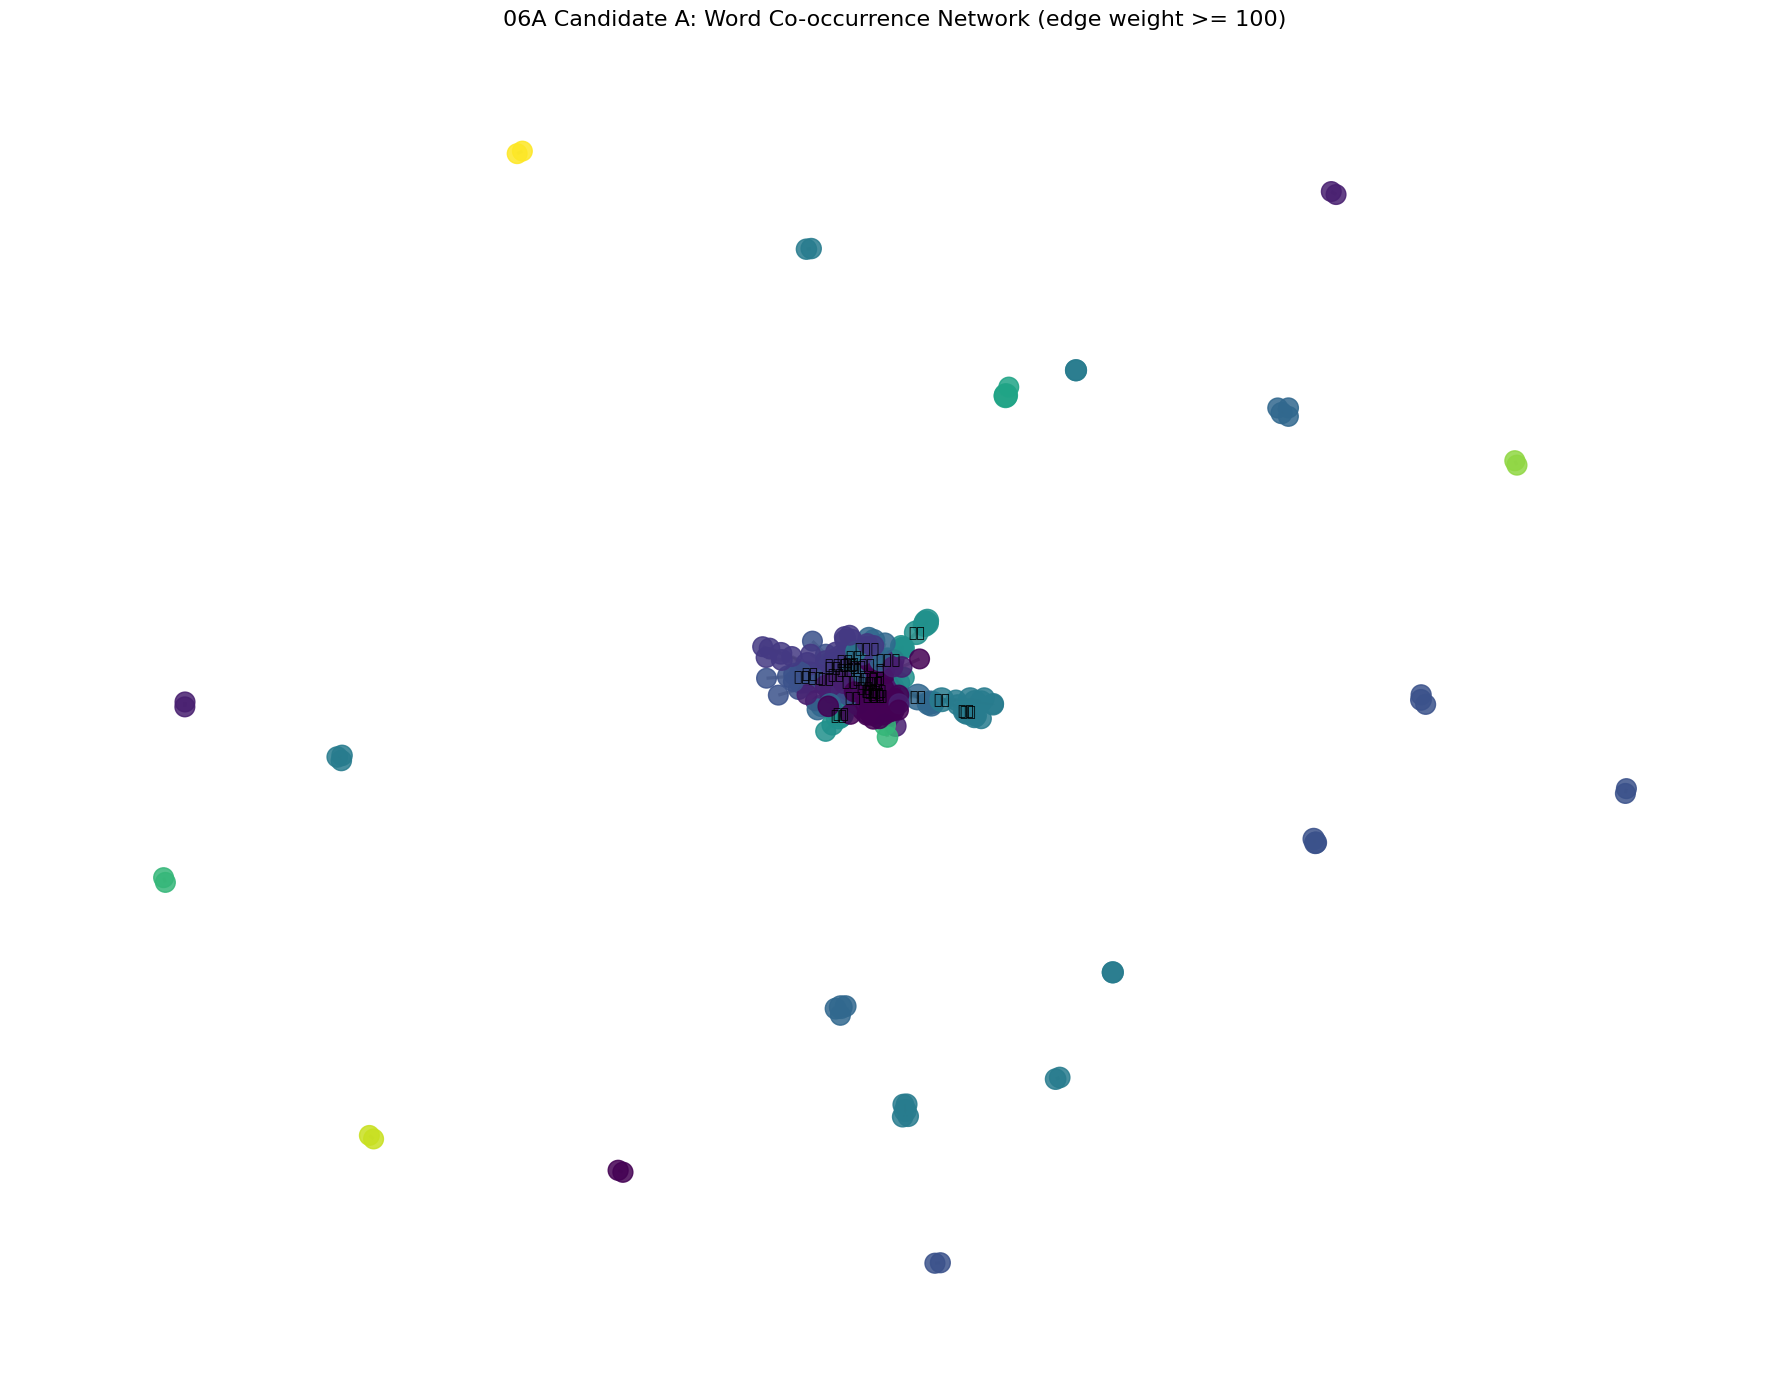

/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_candidate_top120_edges_v1_20260603_0802.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

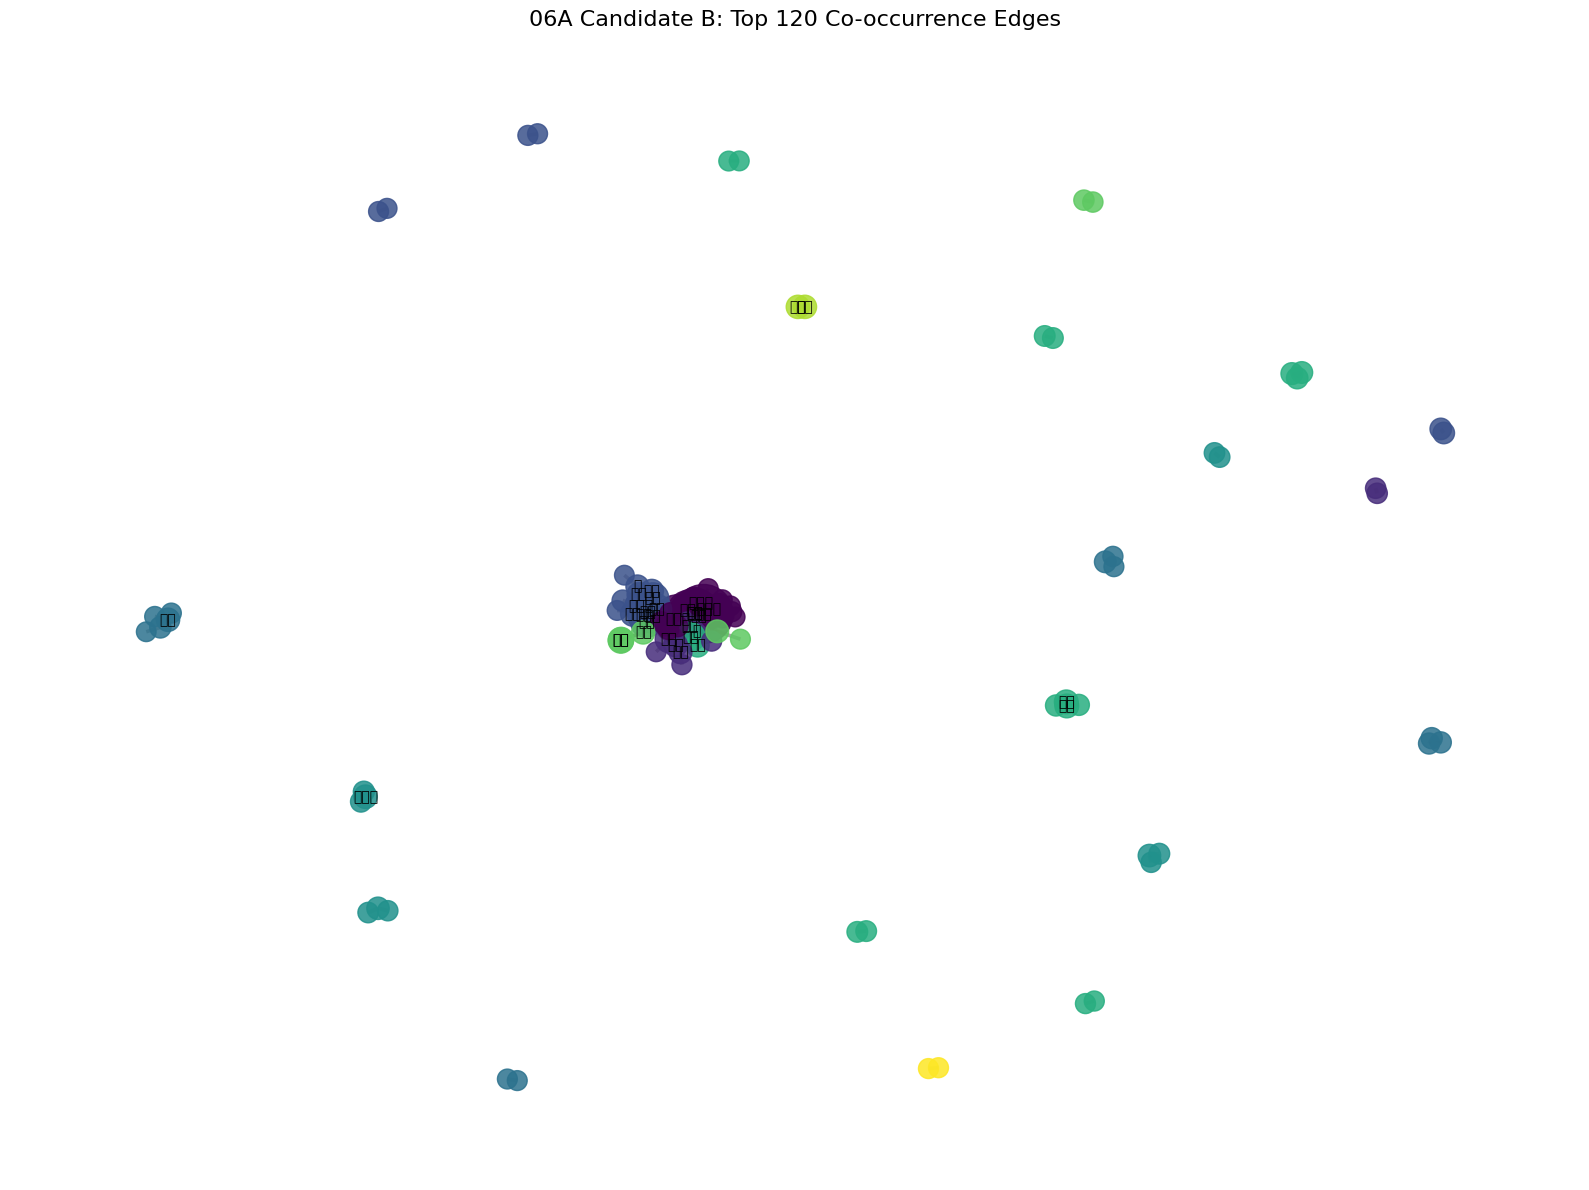

/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=300, bbox_inches="tight")
/tmp/ipykernel_951/1434057018.py:312: UserWarning: Glyph 50528 (\N{HANGUL SYLLABLE AE}) missing from

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_candidate_community_core_v1_20260603_0802.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

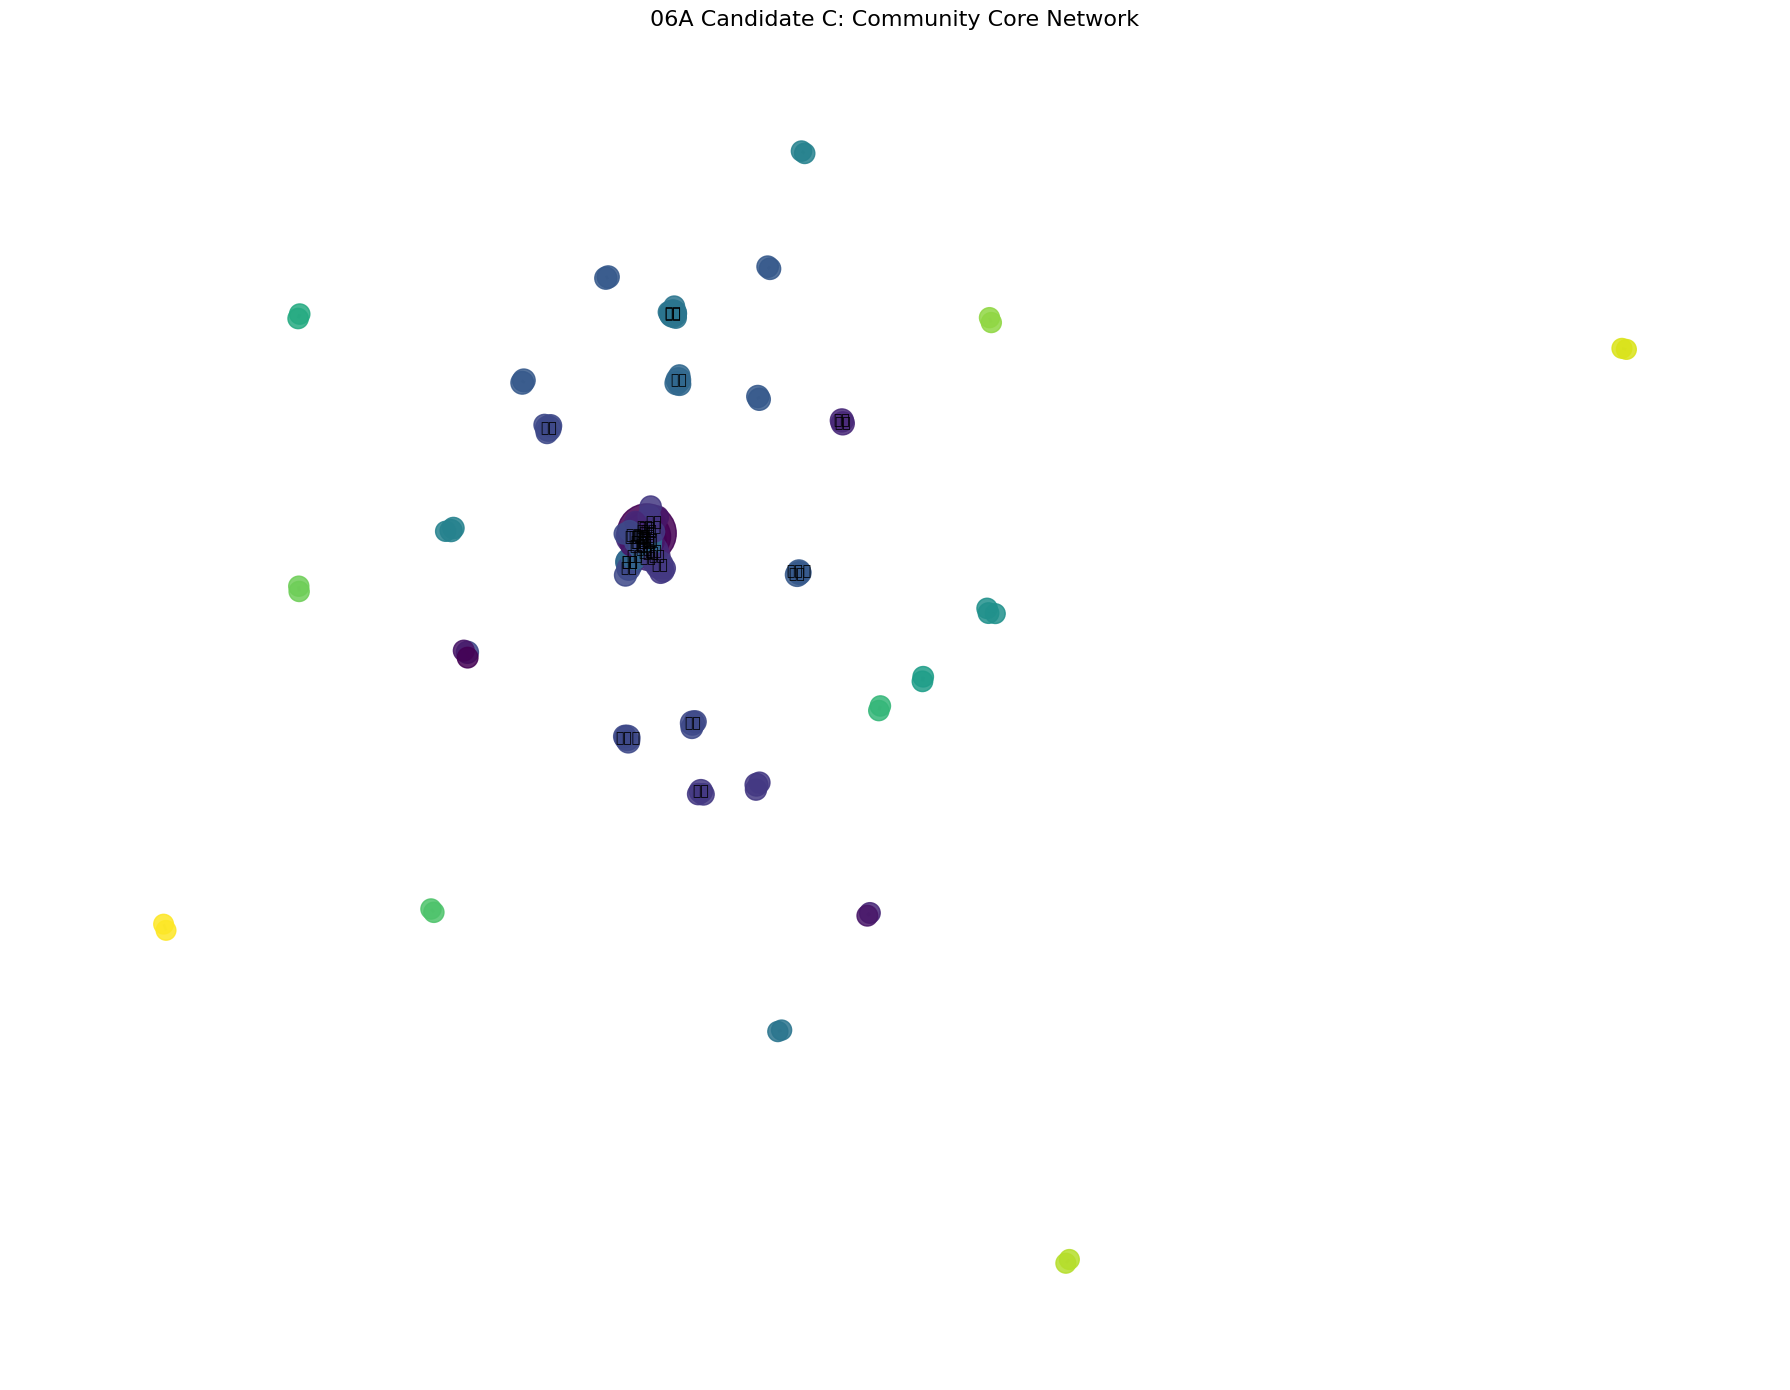


[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_figure_candidate_summary_v1_20260603_0802.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_figure_candidate_edges_v1_20260603_0802.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_figure_candidate_nodes_v1_20260603_0802.xlsx
candidate_weight_ge_100 : /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_candidate_weight_ge_100_v1_20260603_0802.png
candidate_top120_edges : /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_candidate_top120_edges_v1_20260603_0802.png
candidate_community_core : /con

In [ ]:
# 06A-8. 포스터 후보용 축약 네트워크 및 시각화 후보 생성

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

# 이 셀 실행 시점 기준 timestamp
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

# 저장 폴더 생성
if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "edge_df",
    "node_centrality_df",
    "community_node_df",
    "community_edge_df",
    "within_community_top_edges",
    "between_community_top_edges",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-5, 06A-6, 06A-7 셀을 먼저 실행한 뒤 다시 실행하세요."
    )

required_edge_cols = ["source", "target", "weight"]
missing_edge_cols = [col for col in required_edge_cols if col not in edge_df.columns]

if len(missing_edge_cols) > 0:
    raise KeyError(f"edge_df에 다음 열이 없습니다: {missing_edge_cols}")

required_node_cols = [
    "word",
    "doc_freq_unique",
    "weighted_degree",
    "betweenness_centrality_distance",
    "pagerank_weighted",
]

missing_node_cols = [
    col for col in required_node_cols
    if col not in node_centrality_df.columns
]

if len(missing_node_cols) > 0:
    raise KeyError(f"node_centrality_df에 다음 열이 없습니다: {missing_node_cols}")

required_community_cols = ["word", "community_id", "community_size"]
missing_community_cols = [
    col for col in required_community_cols
    if col not in community_node_df.columns
]

if len(missing_community_cols) > 0:
    raise KeyError(f"community_node_df에 다음 열이 없습니다: {missing_community_cols}")

print("\n[입력 객체 확인 완료]")
print("edge_df 행 수:", len(edge_df))
print("node_centrality_df 행 수:", len(node_centrality_df))
print("community_node_df 행 수:", len(community_node_df))
print("community_edge_df 행 수:", len(community_edge_df))


# ------------------------------------------------------------
# 2) 시각화용 보조 함수 정의
# ------------------------------------------------------------

def build_graph_from_edge_table(edge_table):
    """
    edge table을 NetworkX graph로 변환한다.
    """

    G = nx.Graph()

    for _, row in edge_table.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

    return G


def make_candidate_node_table(candidate_name, edge_table, node_centrality_df, community_node_df):
    """
    후보 edge table에 포함된 node를 기준으로 node table을 만든다.
    중심성 지표와 community_id를 함께 붙인다.
    """

    candidate_nodes = sorted(
        set(edge_table["source"].astype(str)).union(
            set(edge_table["target"].astype(str))
        )
    )

    node_table = pd.DataFrame({"word": candidate_nodes})

    # 중심성 지표 병합
    node_table = node_table.merge(
        node_centrality_df,
        on="word",
        how="left",
        validate="one_to_one"
    )

    # community 정보 병합
    community_cols = [
        "word",
        "community_id",
        "community_size",
    ]

    community_info = community_node_df[community_cols].drop_duplicates("word").copy()

    node_table = node_table.merge(
        community_info,
        on="word",
        how="left",
        validate="one_to_one",
        suffixes=("", "_community")
    )

    # 병합 과정에서 community_id가 이미 있으면 정리
    # node_centrality_df에는 community_id가 없고, community_node_df에는 있으므로 보통 문제 없음
    if "community_id_community" in node_table.columns:
        node_table["community_id"] = node_table["community_id_community"]
        node_table = node_table.drop(columns=["community_id_community"])

    node_table["candidate_name"] = candidate_name

    # 후보 내 degree / weighted degree 계산
    G_temp = build_graph_from_edge_table(edge_table)

    candidate_degree = dict(G_temp.degree())
    candidate_weighted_degree = dict(G_temp.degree(weight="weight"))

    node_table["candidate_degree"] = node_table["word"].map(candidate_degree).fillna(0).astype(int)
    node_table["candidate_weighted_degree"] = node_table["word"].map(candidate_weighted_degree).fillna(0)

    node_table = node_table.sort_values(
        ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique", "word"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    node_table["candidate_node_rank"] = range(1, len(node_table) + 1)

    return node_table


def scale_series_to_range(series, min_value=200, max_value=1800):
    """
    node size, edge width 등 시각화용 크기 조정을 위한 함수.
    값이 모두 같을 경우 중간값으로 고정한다.
    """

    s = pd.Series(series).astype(float)

    if len(s) == 0:
        return []

    s_min = s.min()
    s_max = s.max()

    if s_max == s_min:
        return [int((min_value + max_value) / 2)] * len(s)

    scaled = min_value + (s - s_min) / (s_max - s_min) * (max_value - min_value)

    return scaled.tolist()


def draw_network_candidate(
    candidate_name,
    edge_table,
    node_table,
    output_path=None,
    title=None,
    label_top_n=35,
    layout_seed=42,
    figsize=(16, 12)
):
    """
    후보 네트워크를 시각화한다.

    주의:
    - 포스터 최종 Figure가 아니라 후보 탐색용이다.
    - 너무 많은 라벨은 겹치므로 candidate_weighted_degree 상위 일부만 표시한다.
    """

    G = build_graph_from_edge_table(edge_table)

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        print(f"{candidate_name}: 그래프가 비어 있어 시각화하지 않습니다.")
        return None

    # layout 계산
    # weight가 큰 edge가 가깝게 배치되도록 weight를 반영한다.
    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        weight="weight",
        k=None,
        iterations=100
    )

    # node 순서 맞추기
    nodes = list(G.nodes())

    plot_node_table = node_table.set_index("word").reindex(nodes).copy()

    # node size: 후보 네트워크 내 weighted degree 기준
    node_sizes = scale_series_to_range(
        plot_node_table["candidate_weighted_degree"].fillna(0),
        min_value=200,
        max_value=1800
    )

    # node color: community_id 숫자를 그대로 사용
    # 색 자체는 최종 포스터용에서 다시 통일할 예정
    node_colors = plot_node_table["community_id"].fillna(0).astype(int).tolist()

    # edge width: log(weight) 기준으로 완만하게 조정
    edge_weights = [
        G[u][v].get("weight", 1)
        for u, v in G.edges()
    ]

    edge_widths = [
        max(0.5, min(5.0, np.log1p(w) / 2))
        for w in edge_weights
    ]

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.35
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.85
    )

    # 라벨은 후보 내 weighted degree 상위 N개만 표시
    label_nodes = (
        node_table
        .sort_values(
            ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique"],
            ascending=[False, False, False]
        )
        .head(label_top_n)["word"]
        .tolist()
    )

    labels = {
        node: node
        for node in label_nodes
        if node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=10
    )

    if title is None:
        title = candidate_name

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print("Figure 저장:", output_path)

    plt.show()

    return G


# ------------------------------------------------------------
# 3) Figure 후보 edge list 생성
# ------------------------------------------------------------

figure_candidate_edge_dict = {}

# Candidate A: weight >= 100
CANDIDATE_A_MIN_WEIGHT = 100

candidate_a_edges = (
    edge_df.loc[
        edge_df["weight"] >= CANDIDATE_A_MIN_WEIGHT,
        ["source", "target", "weight"]
    ]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .reset_index(drop=True)
)

candidate_a_edges["candidate_name"] = "candidate_weight_ge_100"
candidate_a_edges["candidate_rule"] = "전체 edge 중 weight >= 100"

figure_candidate_edge_dict["candidate_weight_ge_100"] = candidate_a_edges


# Candidate B: 전체 edge 중 weight 상위 120개
CANDIDATE_B_TOP_N_EDGES = 120

candidate_b_edges = (
    edge_df[["source", "target", "weight"]]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(CANDIDATE_B_TOP_N_EDGES)
    .reset_index(drop=True)
)

candidate_b_edges["candidate_name"] = "candidate_top120_edges"
candidate_b_edges["candidate_rule"] = "전체 edge 중 weight 상위 120개"

figure_candidate_edge_dict["candidate_top120_edges"] = candidate_b_edges


# Candidate C: community 내부 핵심 edge + community 간 핵심 edge
# - 큰 community는 내부 edge 상위 8개씩
# - 작은 community는 내부 edge 상위 3개씩
# - community 간 edge는 상위 40개
LARGE_COMMUNITY_MIN_SIZE = 10
WITHIN_TOP_N_LARGE_COMMUNITY = 8
WITHIN_TOP_N_SMALL_COMMUNITY = 3
BETWEEN_TOP_N_EDGES = 40

community_size_map = (
    community_node_df[["community_id", "community_size"]]
    .drop_duplicates()
    .set_index("community_id")["community_size"]
    .to_dict()
)

candidate_c_within_rows = []

for community_id, group in within_community_top_edges.groupby("source_community"):
    community_size = community_size_map.get(community_id, 0)

    if community_size >= LARGE_COMMUNITY_MIN_SIZE:
        top_n = WITHIN_TOP_N_LARGE_COMMUNITY
    else:
        top_n = WITHIN_TOP_N_SMALL_COMMUNITY

    candidate_c_within_rows.append(
        group.sort_values(
            ["weight", "source", "target"],
            ascending=[False, True, True]
        ).head(top_n)
    )

candidate_c_within_edges = (
    pd.concat(candidate_c_within_rows, ignore_index=True)
    if len(candidate_c_within_rows) > 0
    else pd.DataFrame(columns=within_community_top_edges.columns)
)

candidate_c_between_edges = (
    between_community_top_edges
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(BETWEEN_TOP_N_EDGES)
    .copy()
)

candidate_c_edges = pd.concat(
    [
        candidate_c_within_edges[["source", "target", "weight"]],
        candidate_c_between_edges[["source", "target", "weight"]],
    ],
    ignore_index=True
)

# 중복 edge가 있을 경우 weight 기준으로 하나만 남김
candidate_c_edges = (
    candidate_c_edges
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .drop_duplicates(subset=["source", "target"])
    .reset_index(drop=True)
)

candidate_c_edges["candidate_name"] = "candidate_community_core"
candidate_c_edges["candidate_rule"] = (
    "community 내부 상위 edge + community 간 상위 edge"
)

figure_candidate_edge_dict["candidate_community_core"] = candidate_c_edges


# ------------------------------------------------------------
# 4) 후보별 node list와 graph 생성
# ------------------------------------------------------------

figure_candidate_node_dict = {}
G_candidate_dict = {}
figure_candidate_summary_rows = []

for candidate_name, candidate_edges in figure_candidate_edge_dict.items():
    candidate_node_table = make_candidate_node_table(
        candidate_name=candidate_name,
        edge_table=candidate_edges,
        node_centrality_df=node_centrality_df,
        community_node_df=community_node_df
    )

    G_candidate = build_graph_from_edge_table(candidate_edges)

    figure_candidate_node_dict[candidate_name] = candidate_node_table
    G_candidate_dict[candidate_name] = G_candidate

    component_count = (
        nx.number_connected_components(G_candidate)
        if G_candidate.number_of_nodes() > 0
        else 0
    )

    if component_count > 0:
        largest_component_size = len(max(nx.connected_components(G_candidate), key=len))
    else:
        largest_component_size = 0

    figure_candidate_summary_rows.append({
        "candidate_name": candidate_name,
        "candidate_rule": candidate_edges["candidate_rule"].iloc[0],
        "node_count": G_candidate.number_of_nodes(),
        "edge_count": G_candidate.number_of_edges(),
        "component_count": component_count,
        "largest_component_size": largest_component_size,
        "largest_component_share_percent": round(
            largest_component_size / G_candidate.number_of_nodes() * 100,
            2
        ) if G_candidate.number_of_nodes() > 0 else 0,
        "density": round(nx.density(G_candidate), 6)
        if G_candidate.number_of_nodes() > 1 else 0,
        "max_edge_weight": int(candidate_edges["weight"].max())
        if len(candidate_edges) > 0 else 0,
        "min_edge_weight": int(candidate_edges["weight"].min())
        if len(candidate_edges) > 0 else 0,
        "top_nodes_by_candidate_weighted_degree": ", ".join(
            candidate_node_table
            .sort_values("candidate_weighted_degree", ascending=False)
            .head(15)["word"]
            .tolist()
        ),
    })

figure_candidate_summary = pd.DataFrame(figure_candidate_summary_rows)

print("\n[Figure 후보 요약]")
display(figure_candidate_summary)

for candidate_name in figure_candidate_edge_dict:
    print(f"\n[{candidate_name}] edge 상위 20개")
    display(
        figure_candidate_edge_dict[candidate_name]
        .sort_values(["weight", "source", "target"], ascending=[False, True, True])
        .head(20)
    )

    print(f"\n[{candidate_name}] node 상위 20개")
    display(
        figure_candidate_node_dict[candidate_name]
        .sort_values(
            ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique"],
            ascending=[False, False, False]
        )
        .head(20)[
            [
                "word",
                "community_id",
                "doc_freq_unique",
                "weighted_degree",
                "betweenness_centrality_distance",
                "candidate_degree",
                "candidate_weighted_degree",
            ]
        ]
    )


# ------------------------------------------------------------
# 5) 시각화 생성 및 저장
# ------------------------------------------------------------

figure_paths = {}

if SAVE_OUTPUT:
    candidate_a_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_candidate_weight_ge_100_{RUN_VERSION}_{RUN_TS}.png"
    )

    candidate_b_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_candidate_top120_edges_{RUN_VERSION}_{RUN_TS}.png"
    )

    candidate_c_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_candidate_community_core_{RUN_VERSION}_{RUN_TS}.png"
    )
else:
    candidate_a_fig_path = None
    candidate_b_fig_path = None
    candidate_c_fig_path = None

figure_paths["candidate_weight_ge_100"] = candidate_a_fig_path
figure_paths["candidate_top120_edges"] = candidate_b_fig_path
figure_paths["candidate_community_core"] = candidate_c_fig_path


# Candidate A
draw_network_candidate(
    candidate_name="candidate_weight_ge_100",
    edge_table=figure_candidate_edge_dict["candidate_weight_ge_100"],
    node_table=figure_candidate_node_dict["candidate_weight_ge_100"],
    output_path=figure_paths["candidate_weight_ge_100"],
    title="06A Candidate A: Word Co-occurrence Network (edge weight >= 100)",
    label_top_n=40,
    layout_seed=42,
    figsize=(18, 14)
)

# Candidate B
draw_network_candidate(
    candidate_name="candidate_top120_edges",
    edge_table=figure_candidate_edge_dict["candidate_top120_edges"],
    node_table=figure_candidate_node_dict["candidate_top120_edges"],
    output_path=figure_paths["candidate_top120_edges"],
    title="06A Candidate B: Top 120 Co-occurrence Edges",
    label_top_n=35,
    layout_seed=42,
    figsize=(16, 12)
)

# Candidate C
draw_network_candidate(
    candidate_name="candidate_community_core",
    edge_table=figure_candidate_edge_dict["candidate_community_core"],
    node_table=figure_candidate_node_dict["candidate_community_core"],
    output_path=figure_paths["candidate_community_core"],
    title="06A Candidate C: Community Core Network",
    label_top_n=40,
    layout_seed=42,
    figsize=(18, 14)
)


# ------------------------------------------------------------
# 6) 후보 edge/node table 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    figure_candidate_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_figure_candidate_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    figure_candidate_edges_path = (
        TABLE_FINAL_DIR
        / f"06A_figure_candidate_edges_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    figure_candidate_nodes_path = (
        TABLE_FINAL_DIR
        / f"06A_figure_candidate_nodes_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    with pd.ExcelWriter(figure_candidate_summary_path) as writer:
        figure_candidate_summary.to_excel(
            writer,
            sheet_name="candidate_summary",
            index=False
        )

    with pd.ExcelWriter(figure_candidate_edges_path) as writer:
        for candidate_name, candidate_edges in figure_candidate_edge_dict.items():
            sheet_name = candidate_name[:31]
            candidate_edges.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )

    with pd.ExcelWriter(figure_candidate_nodes_path) as writer:
        for candidate_name, candidate_nodes in figure_candidate_node_dict.items():
            sheet_name = candidate_name[:31]
            candidate_nodes.to_excel(
                writer,
                sheet_name=sheet_name,
                index=False
            )

    print("\n[저장 완료]")
    print(figure_candidate_summary_path)
    print(figure_candidate_edges_path)
    print(figure_candidate_nodes_path)

    for candidate_name, path in figure_paths.items():
        print(candidate_name, ":", path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 7) 06A-8 간단 판정
# ------------------------------------------------------------

print("\n[06A-8 간단 판정]")

for _, row in figure_candidate_summary.iterrows():
    print(
        f"- {row['candidate_name']}: "
        f"node {row['node_count']}, "
        f"edge {row['edge_count']}, "
        f"component {row['component_count']}, "
        f"largest component share {row['largest_component_share_percent']}%"
    )

print("\n후보 판단 기준:")
print("- Candidate A는 전체 강한 edge 구조를 비교적 넓게 보여주는 후보입니다.")
print("- Candidate B는 가장 강한 edge만 보여주므로 포스터에서 가장 단순할 수 있습니다.")
print("- Candidate C는 community 구조를 의식적으로 반영한 compact 후보입니다.")

print("\n다음 단계에서는 생성된 Figure 후보를 비교하고,")
print("포스터용/부록용/보류 후보를 판정하는 요약표를 작성합니다.")
print("\n06A-8 실행 완료")

06A-8-FIX. 한글 폰트 적용 및 포스터용 Figure 후보 재생성
1. 이 단계의 목적

이 단계의 목적은 06A-8에서 생성한 Figure 후보의 가시성을 개선하는 것입니다.

수정 방향은 다음과 같습니다.

1. Colab에 NanumGothic 한글 폰트 적용
2. 포스터용 후보를 더 단순하게 축약
3. 라벨 수를 줄여 겹침 완화
4. community core 후보에서 너무 약한 edge 제거
5. refined Figure와 refined 후보표를 별도 저장

이번 단계에서는 기존 06A-8 산출물을 삭제하지 않고, 개선본을 별도 파일명으로 저장합니다.

필수 전제는 다음입니다.

---
06A-5 완료

06A-6 완료

06A-7 완료

06A-8 완료 여부는 필수는 아님

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0810

[한글 폰트 설정 시작]
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
사용 폰트: ['NanumGothic']
폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf

[입력 객체 확인 완료]
edge_df 행 수: 39036
node_centrality_df 행 수: 576
community_node_df 행 수: 495
community_edge_df 행 수: 31935

[Refined Figure 후보 요약]


,candidate_name,candidate_rule,node_count,edge_count,component_count,largest_component_size,largest_component_share_percent,density,max_edge_weight,min_edge_weight,top_nodes_by_candidate_weighted_degree
0,refined_poster_top80_edges,전체 edge 중 weight 상위 80개,80,80,20,38,47.50,0.025316,2476,223,"대회, 체육, 장애인, 생활, 센터, 종사자, 전국, 개선, 지역, 아동, 복지, 시설"
1,refined_poster_top100_edges,전체 edge 중 weight 상위 100개,95,100,22,46,48.42,0.022396,2476,196,"대회, 체육, 장애인, 생활, 전국, 센터, 종사자, 개선, 지역, 아동, 복지, 시설"
2,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ...",88,78,26,34,38.64,0.020376,2476,37,"대회, 체육, 장애인, 센터, 단체, 생활, 지역, 행사, 전국, 아동, 시설, 날"



[refined_poster_top80_edges] edge 상위 15개


,source,target,weight,candidate_name,candidate_rule
0,대회,체육,2476,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
1,대회,전국,1792,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
2,생활,체육,1591,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
3,대회,장애인,959,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
4,센터,지역,858,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
5,센터,아동,822,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
6,장애인,체육,821,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
7,대회,생활,819,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
8,아동,지역,817,refined_poster_top80_edges,전체 edge 중 weight 상위 80개
9,강화,역량,816,refined_poster_top80_edges,전체 edge 중 weight 상위 80개



[refined_poster_top80_edges] node 상위 15개


...


[refined_community_core_weight_ge_30] edge 상위 15개


,source,target,weight,candidate_name,candidate_rule
0,대회,체육,2476,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
1,대회,전국,1792,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
2,생활,체육,1591,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
3,대회,장애인,959,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
4,센터,지역,858,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
5,센터,아동,822,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
6,장애인,체육,821,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
7,아동,지역,817,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
8,강화,역량,816,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."
9,날,행사,714,refined_community_core_weight_ge_30,"community 내부 핵심 edge + community 간 핵심 edge, 단 ..."



[refined_community_core_weight_ge_30] node 상위 15개


,word,community_id,doc_freq_unique,weighted_degree,betweenness_centrality_distance,candidate_degree,candidate_weighted_degree
0,대회,1,8525,21331.0,0.338100,6,5830.0
1,체육,1,3927,11991.0,0.058697,4,5122.0
2,장애인,1,5164,14313.0,0.577197,10,4310.0
3,센터,3,2755,8521.0,0.139658,4,2275.0
4,단체,6,2405,6682.0,0.067578,8,2118.0
5,생활,1,2388,7830.0,0.003657,3,1961.0
6,지역,3,2390,8038.0,0.056022,3,1870.0
7,행사,2,3846,8333.0,0.084193,6,1865.0
8,전국,1,2323,6198.0,0.026172,1,1792.0
9,아동,3,1488,5095.0,0.016416,2,1639.0


Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_refined_poster_top80_edges_v1_20260603_0810.png


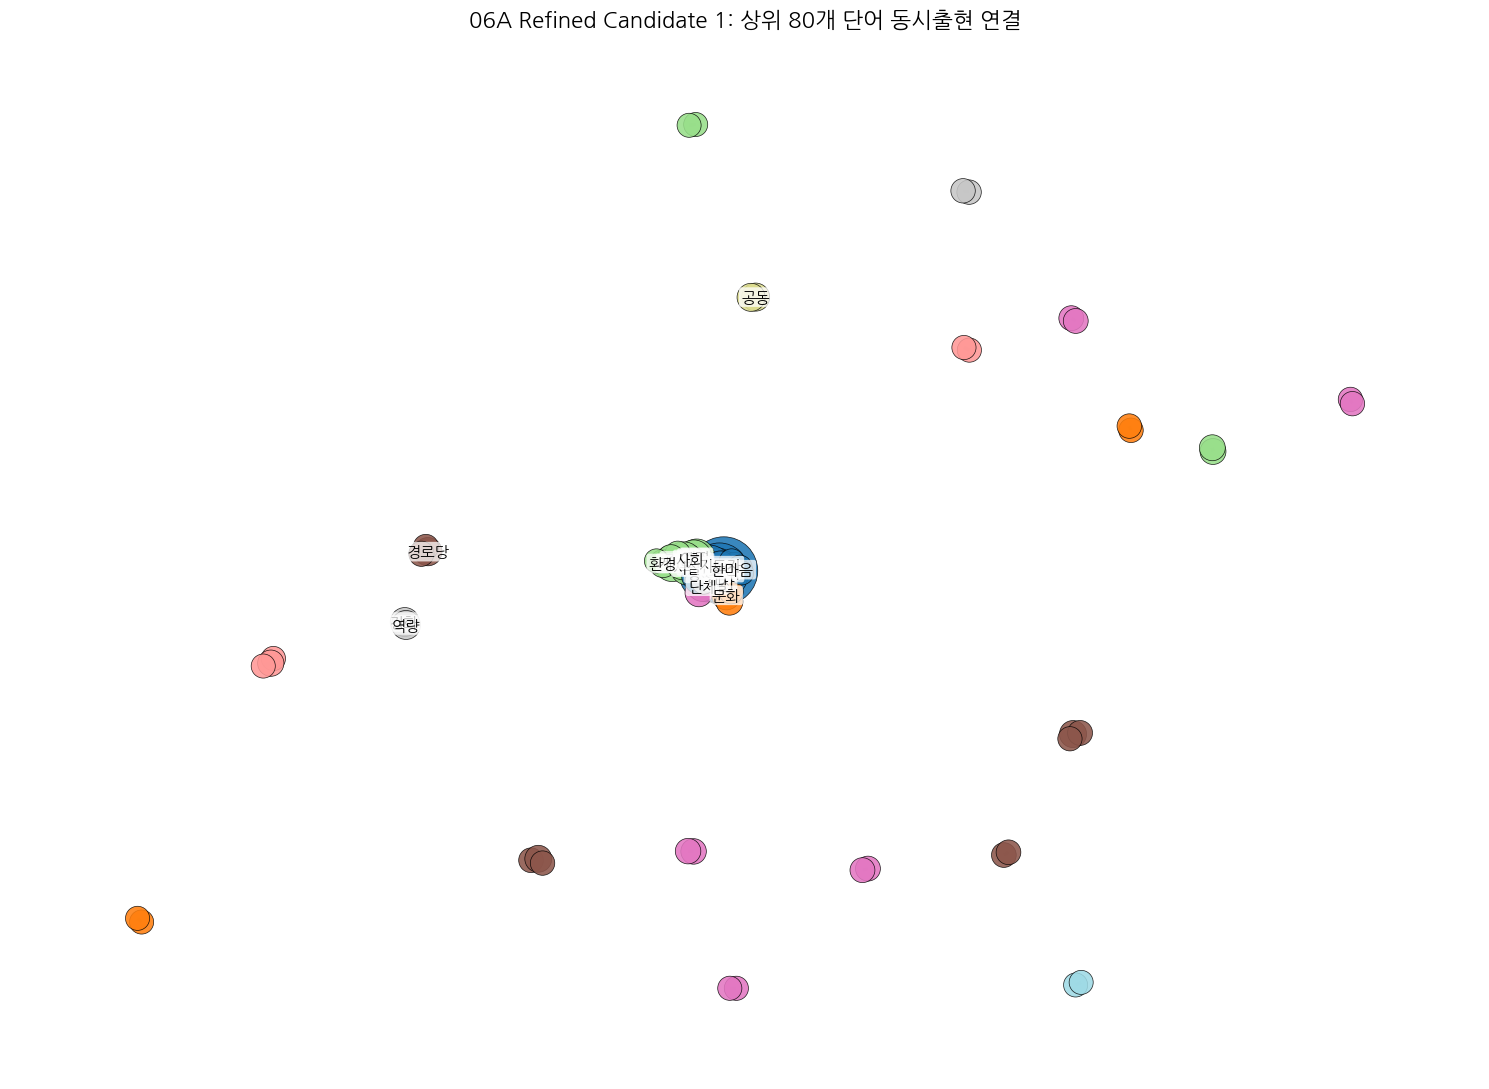

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_refined_poster_top100_edges_v1_20260603_0810.png


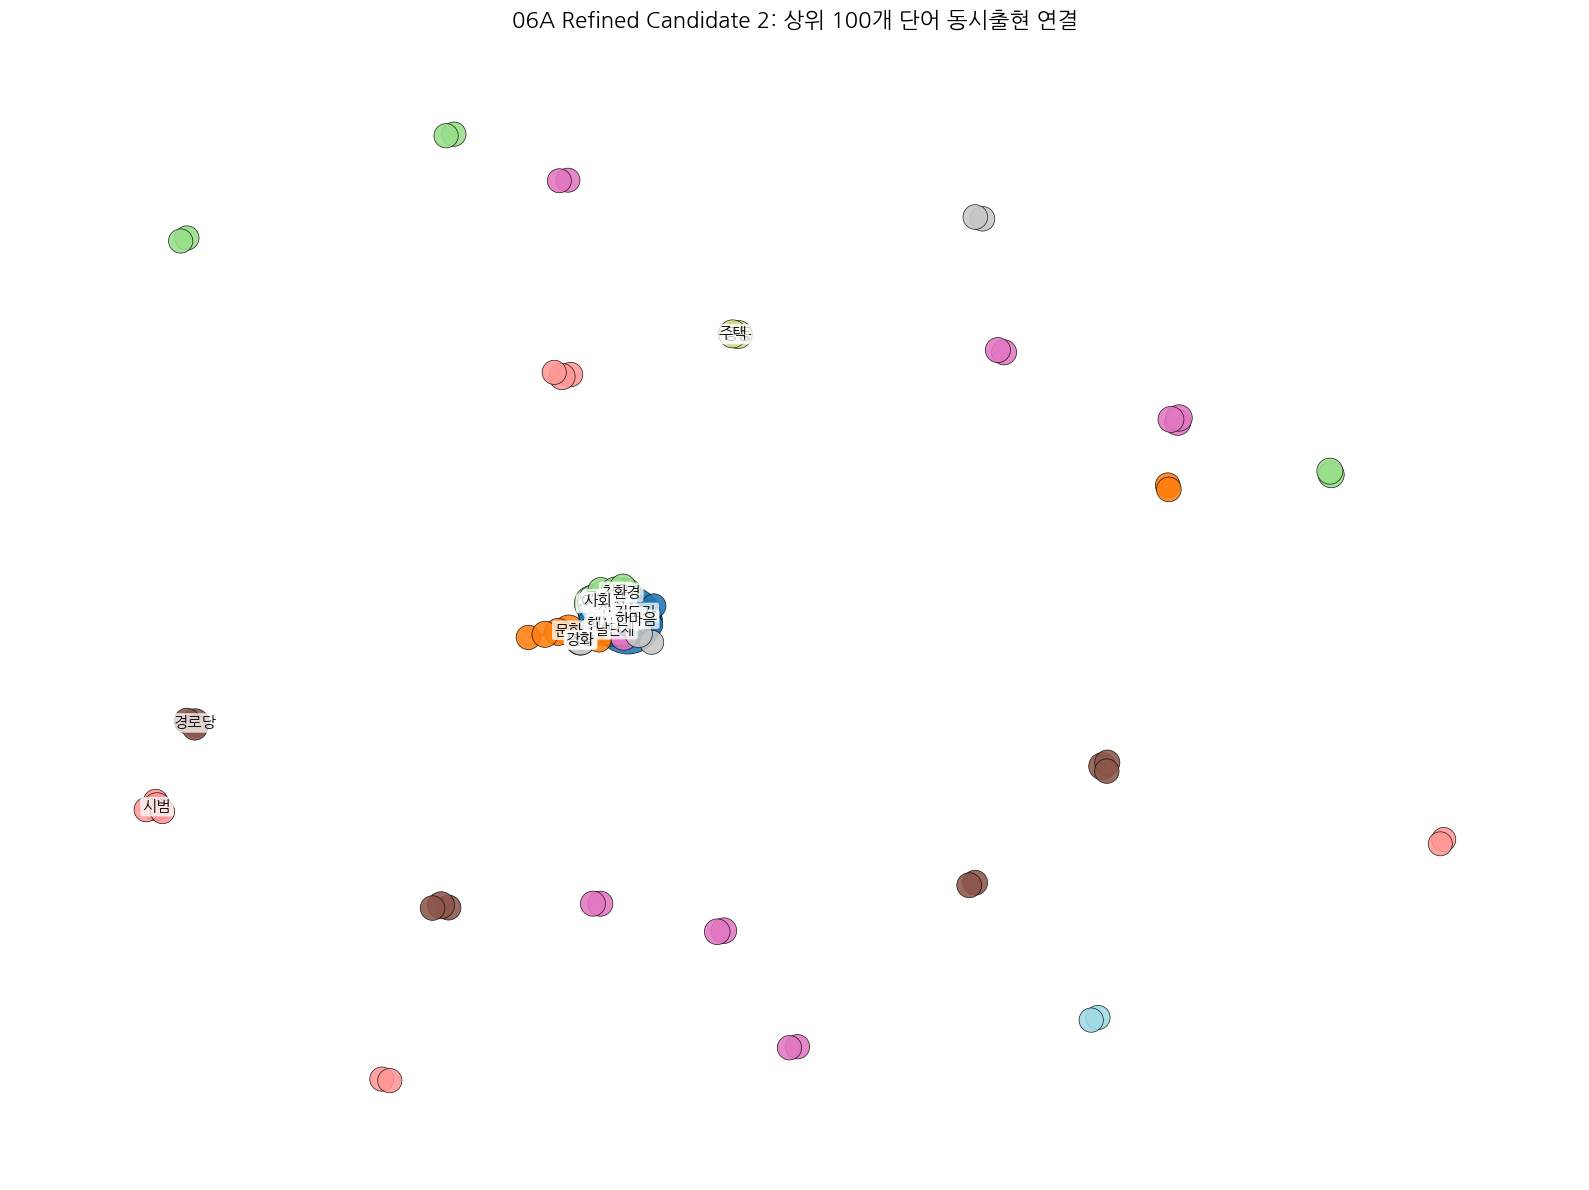

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_refined_community_core_weight_ge_30_v1_20260603_0810.png


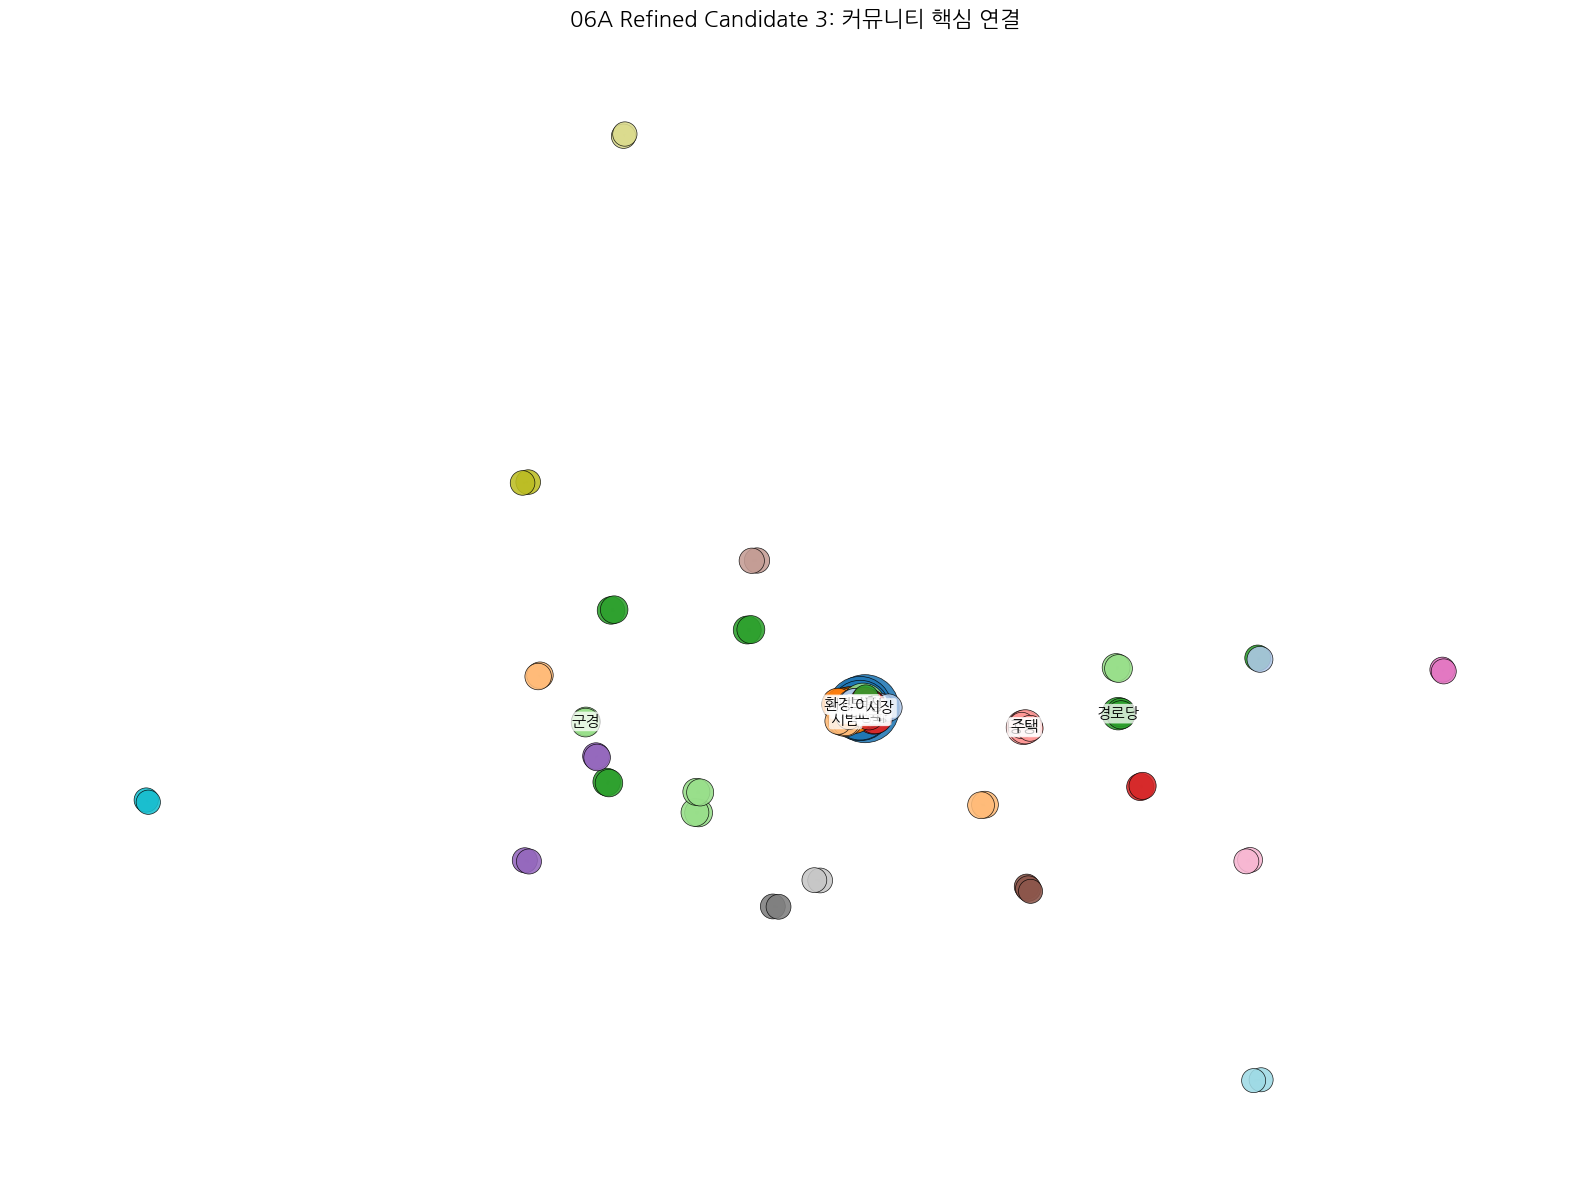


[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_refined_figure_candidate_summary_v1_20260603_0810.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_refined_figure_candidate_edges_v1_20260603_0810.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_refined_figure_candidate_nodes_v1_20260603_0810.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_refined_poster_top80_edges_v1_20260603_0810.png
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_refined_poster_top100_edges_v1_20260603_0810.png
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/

In [ ]:
# 06A-8-FIX. 한글 폰트 적용 및 포스터용 Figure 후보 재생성

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
# 현재는 저장하는 기준으로 둔다.
# 확인만 하고 싶으면 False로 바꾸면 된다.

SAVE_OUTPUT = True

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 한글 폰트 설치 및 matplotlib 설정
# ------------------------------------------------------------
# Colab 기본 폰트인 DejaVu Sans는 한글 glyph가 없어 라벨이 깨진다.
# NanumGothic을 설치하고 matplotlib에 직접 등록한다.

import matplotlib.font_manager as fm
from pathlib import Path

print("\n[한글 폰트 설정 시작]")

# Colab 환경에서 Nanum 폰트 설치
# 이미 설치되어 있으면 빠르게 넘어간다.
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

font_path = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

if not font_path.exists():
    raise FileNotFoundError(
        "NanumGothic.ttf를 찾지 못했습니다. "
        "fonts-nanum 설치가 정상적으로 되었는지 확인하세요."
    )

# matplotlib font manager에 폰트 직접 추가
fm.fontManager.addfont(str(font_path))

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("사용 폰트:", plt.rcParams["font.family"])
print("폰트 경로:", font_path)


# ------------------------------------------------------------
# 2) 이전 단계 산출물 존재 여부 점검
# ------------------------------------------------------------

required_objects = [
    "edge_df",
    "node_centrality_df",
    "community_node_df",
    "community_edge_df",
    "within_community_top_edges",
    "between_community_top_edges",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-5, 06A-6, 06A-7을 먼저 실행한 뒤 다시 실행하세요."
    )

print("\n[입력 객체 확인 완료]")
print("edge_df 행 수:", len(edge_df))
print("node_centrality_df 행 수:", len(node_centrality_df))
print("community_node_df 행 수:", len(community_node_df))
print("community_edge_df 행 수:", len(community_edge_df))


# ------------------------------------------------------------
# 3) 시각화용 보조 함수 정의
# ------------------------------------------------------------

def build_graph_from_edge_table_refined(edge_table):
    """
    edge table을 NetworkX graph로 변환한다.
    """

    G = nx.Graph()

    for _, row in edge_table.iterrows():
        G.add_edge(
            str(row["source"]),
            str(row["target"]),
            weight=float(row["weight"])
        )

    return G


def make_refined_candidate_node_table(
    candidate_name,
    edge_table,
    node_centrality_df,
    community_node_df
):
    """
    후보 edge table에 포함된 node를 기준으로 node table을 만든다.
    중심성 지표와 community 정보를 붙인다.
    """

    candidate_nodes = sorted(
        set(edge_table["source"].astype(str)).union(
            set(edge_table["target"].astype(str))
        )
    )

    node_table = pd.DataFrame({"word": candidate_nodes})

    node_table = node_table.merge(
        node_centrality_df,
        on="word",
        how="left",
        validate="one_to_one"
    )

    community_info = (
        community_node_df[
            [
                "word",
                "community_id",
                "community_size",
            ]
        ]
        .drop_duplicates("word")
        .copy()
    )

    # node_centrality_df에 혹시 community_id가 이미 있으면 충돌 방지
    if "community_id" in node_table.columns:
        node_table = node_table.drop(columns=["community_id"], errors="ignore")

    if "community_size" in node_table.columns:
        node_table = node_table.drop(columns=["community_size"], errors="ignore")

    node_table = node_table.merge(
        community_info,
        on="word",
        how="left",
        validate="one_to_one"
    )

    node_table["candidate_name"] = candidate_name

    G_temp = build_graph_from_edge_table_refined(edge_table)

    candidate_degree = dict(G_temp.degree())
    candidate_weighted_degree = dict(G_temp.degree(weight="weight"))

    node_table["candidate_degree"] = (
        node_table["word"]
        .map(candidate_degree)
        .fillna(0)
        .astype(int)
    )

    node_table["candidate_weighted_degree"] = (
        node_table["word"]
        .map(candidate_weighted_degree)
        .fillna(0)
    )

    node_table = node_table.sort_values(
        [
            "candidate_weighted_degree",
            "weighted_degree",
            "doc_freq_unique",
            "word",
        ],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    node_table["candidate_node_rank"] = range(1, len(node_table) + 1)

    return node_table


def scale_series_to_range_refined(series, min_value=250, max_value=2200):
    """
    node size 조정 함수.
    """

    s = pd.Series(series).astype(float)

    if len(s) == 0:
        return []

    s_min = s.min()
    s_max = s.max()

    if s_max == s_min:
        return [int((min_value + max_value) / 2)] * len(s)

    scaled = min_value + (s - s_min) / (s_max - s_min) * (max_value - min_value)

    return scaled.tolist()


def draw_refined_network_candidate(
    candidate_name,
    edge_table,
    node_table,
    output_path=None,
    title=None,
    label_top_n=25,
    layout_seed=42,
    figsize=(16, 12)
):
    """
    가시성 개선용 네트워크 Figure를 그린다.

    개선 사항:
    - NanumGothic 사용
    - 라벨 수 축소
    - 라벨에 흰색 배경 박스 적용
    - node 크기 범위 조정
    - edge alpha 완화
    """

    G = build_graph_from_edge_table_refined(edge_table)

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        print(f"{candidate_name}: 그래프가 비어 있어 시각화하지 않습니다.")
        return None

    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        weight="weight",
        iterations=150
    )

    nodes = list(G.nodes())

    plot_node_table = (
        node_table
        .set_index("word")
        .reindex(nodes)
        .copy()
    )

    node_sizes = scale_series_to_range_refined(
        plot_node_table["candidate_weighted_degree"].fillna(0),
        min_value=300,
        max_value=2400
    )

    node_colors = (
        plot_node_table["community_id"]
        .fillna(0)
        .astype(int)
        .tolist()
    )

    edge_weights = [
        G[u][v].get("weight", 1)
        for u, v in G.edges()
    ]

    edge_widths = [
        max(0.4, min(4.0, np.log1p(w) / 2.2))
        for w in edge_weights
    ]

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.28
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        alpha=0.88,
        linewidths=0.5,
        edgecolors="black"
    )

    label_nodes = (
        node_table
        .sort_values(
            [
                "candidate_weighted_degree",
                "weighted_degree",
                "doc_freq_unique",
            ],
            ascending=[False, False, False]
        )
        .head(label_top_n)["word"]
        .tolist()
    )

    labels = {
        node: node
        for node in label_nodes
        if node in G.nodes()
    }

    text_items = nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=11,
        font_family="NanumGothic"
    )

    # 라벨 배경을 흰색 반투명 박스로 처리해 가독성 개선
    for _, text in text_items.items():
        text.set_bbox(
            dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
                boxstyle="round,pad=0.15"
            )
        )

    if title is None:
        title = candidate_name

    plt.title(title, fontsize=16, fontfamily="NanumGothic")
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print("Figure 저장:", output_path)

    plt.show()

    return G


# ------------------------------------------------------------
# 4) refined Figure 후보 edge list 생성
# ------------------------------------------------------------

refined_figure_candidate_edge_dict = {}

# 후보 1: 포스터 1순위 후보 - 상위 80개 edge
POSTER_TOP80_EDGES = 80

poster_top80_edges = (
    edge_df[["source", "target", "weight"]]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(POSTER_TOP80_EDGES)
    .reset_index(drop=True)
)

poster_top80_edges["candidate_name"] = "refined_poster_top80_edges"
poster_top80_edges["candidate_rule"] = "전체 edge 중 weight 상위 80개"

refined_figure_candidate_edge_dict["refined_poster_top80_edges"] = poster_top80_edges


# 후보 2: 포스터 대안 후보 - 상위 100개 edge
POSTER_TOP100_EDGES = 100

poster_top100_edges = (
    edge_df[["source", "target", "weight"]]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(POSTER_TOP100_EDGES)
    .reset_index(drop=True)
)

poster_top100_edges["candidate_name"] = "refined_poster_top100_edges"
poster_top100_edges["candidate_rule"] = "전체 edge 중 weight 상위 100개"

refined_figure_candidate_edge_dict["refined_poster_top100_edges"] = poster_top100_edges


# 후보 3: community core 개선본
# 기존 Candidate C는 min edge weight가 낮아질 수 있으므로 weight >= 30만 유지한다.
REFINED_COMMUNITY_MIN_WEIGHT = 30
REFINED_WITHIN_TOP_N_LARGE = 5
REFINED_WITHIN_TOP_N_SMALL = 2
REFINED_BETWEEN_TOP_N = 25
LARGE_COMMUNITY_MIN_SIZE = 10

community_size_map = (
    community_node_df[["community_id", "community_size"]]
    .drop_duplicates()
    .set_index("community_id")["community_size"]
    .to_dict()
)

within_filtered = (
    community_edge_df.loc[
        (community_edge_df["edge_type"] == "within_community")
        & (community_edge_df["weight"] >= REFINED_COMMUNITY_MIN_WEIGHT)
    ]
    .copy()
)

between_filtered = (
    community_edge_df.loc[
        (community_edge_df["edge_type"] == "between_community")
        & (community_edge_df["weight"] >= REFINED_COMMUNITY_MIN_WEIGHT)
    ]
    .copy()
)

community_core_within_rows = []

for community_id, group in within_filtered.groupby("source_community"):
    community_size = community_size_map.get(community_id, 0)

    if community_size >= LARGE_COMMUNITY_MIN_SIZE:
        top_n = REFINED_WITHIN_TOP_N_LARGE
    else:
        top_n = REFINED_WITHIN_TOP_N_SMALL

    community_core_within_rows.append(
        group.sort_values(
            ["weight", "source", "target"],
            ascending=[False, True, True]
        ).head(top_n)
    )

community_core_within_edges = (
    pd.concat(community_core_within_rows, ignore_index=True)
    if len(community_core_within_rows) > 0
    else pd.DataFrame(columns=within_filtered.columns)
)

community_core_between_edges = (
    between_filtered
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(REFINED_BETWEEN_TOP_N)
    .copy()
)

community_core_edges = pd.concat(
    [
        community_core_within_edges[["source", "target", "weight"]],
        community_core_between_edges[["source", "target", "weight"]],
    ],
    ignore_index=True
)

# 무방향 edge 중복 방지
community_core_edges["edge_key"] = community_core_edges.apply(
    lambda row: tuple(sorted([str(row["source"]), str(row["target"])])),
    axis=1
)

community_core_edges = (
    community_core_edges
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .drop_duplicates(subset=["edge_key"])
    .drop(columns=["edge_key"])
    .reset_index(drop=True)
)

community_core_edges["candidate_name"] = "refined_community_core_weight_ge_30"
community_core_edges["candidate_rule"] = (
    "community 내부 핵심 edge + community 간 핵심 edge, 단 weight >= 30"
)

refined_figure_candidate_edge_dict[
    "refined_community_core_weight_ge_30"
] = community_core_edges


# ------------------------------------------------------------
# 5) 후보별 node list와 graph 생성
# ------------------------------------------------------------

refined_figure_candidate_node_dict = {}
G_refined_candidate_dict = {}
refined_summary_rows = []

for candidate_name, candidate_edges in refined_figure_candidate_edge_dict.items():
    candidate_node_table = make_refined_candidate_node_table(
        candidate_name=candidate_name,
        edge_table=candidate_edges,
        node_centrality_df=node_centrality_df,
        community_node_df=community_node_df
    )

    G_candidate = build_graph_from_edge_table_refined(candidate_edges)

    refined_figure_candidate_node_dict[candidate_name] = candidate_node_table
    G_refined_candidate_dict[candidate_name] = G_candidate

    component_count = (
        nx.number_connected_components(G_candidate)
        if G_candidate.number_of_nodes() > 0
        else 0
    )

    if component_count > 0:
        largest_component_size = len(max(nx.connected_components(G_candidate), key=len))
    else:
        largest_component_size = 0

    refined_summary_rows.append({
        "candidate_name": candidate_name,
        "candidate_rule": candidate_edges["candidate_rule"].iloc[0],
        "node_count": G_candidate.number_of_nodes(),
        "edge_count": G_candidate.number_of_edges(),
        "component_count": component_count,
        "largest_component_size": largest_component_size,
        "largest_component_share_percent": round(
            largest_component_size / G_candidate.number_of_nodes() * 100,
            2
        ) if G_candidate.number_of_nodes() > 0 else 0,
        "density": round(nx.density(G_candidate), 6)
        if G_candidate.number_of_nodes() > 1 else 0,
        "max_edge_weight": int(candidate_edges["weight"].max())
        if len(candidate_edges) > 0 else 0,
        "min_edge_weight": int(candidate_edges["weight"].min())
        if len(candidate_edges) > 0 else 0,
        "top_nodes_by_candidate_weighted_degree": ", ".join(
            candidate_node_table
            .sort_values("candidate_weighted_degree", ascending=False)
            .head(12)["word"]
            .tolist()
        ),
    })

refined_figure_candidate_summary = pd.DataFrame(refined_summary_rows)

print("\n[Refined Figure 후보 요약]")
display(refined_figure_candidate_summary)

for candidate_name in refined_figure_candidate_edge_dict:
    print(f"\n[{candidate_name}] edge 상위 15개")
    display(
        refined_figure_candidate_edge_dict[candidate_name]
        .sort_values(["weight", "source", "target"], ascending=[False, True, True])
        .head(15)
    )

    print(f"\n[{candidate_name}] node 상위 15개")
    display(
        refined_figure_candidate_node_dict[candidate_name]
        .sort_values(
            [
                "candidate_weighted_degree",
                "weighted_degree",
                "doc_freq_unique",
            ],
            ascending=[False, False, False]
        )
        .head(15)[
            [
                "word",
                "community_id",
                "doc_freq_unique",
                "weighted_degree",
                "betweenness_centrality_distance",
                "candidate_degree",
                "candidate_weighted_degree",
            ]
        ]
    )


# ------------------------------------------------------------
# 6) refined Figure 생성 및 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    poster_top80_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_refined_poster_top80_edges_{RUN_VERSION}_{RUN_TS}.png"
    )

    poster_top100_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_refined_poster_top100_edges_{RUN_VERSION}_{RUN_TS}.png"
    )

    community_core_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_refined_community_core_weight_ge_30_{RUN_VERSION}_{RUN_TS}.png"
    )
else:
    poster_top80_fig_path = None
    poster_top100_fig_path = None
    community_core_fig_path = None


# 포스터 1순위 후보
draw_refined_network_candidate(
    candidate_name="refined_poster_top80_edges",
    edge_table=refined_figure_candidate_edge_dict["refined_poster_top80_edges"],
    node_table=refined_figure_candidate_node_dict["refined_poster_top80_edges"],
    output_path=poster_top80_fig_path,
    title="06A Refined Candidate 1: 상위 80개 단어 동시출현 연결",
    label_top_n=25,
    layout_seed=42,
    figsize=(15, 11)
)

# 포스터 대안 후보
draw_refined_network_candidate(
    candidate_name="refined_poster_top100_edges",
    edge_table=refined_figure_candidate_edge_dict["refined_poster_top100_edges"],
    node_table=refined_figure_candidate_node_dict["refined_poster_top100_edges"],
    output_path=poster_top100_fig_path,
    title="06A Refined Candidate 2: 상위 100개 단어 동시출현 연결",
    label_top_n=28,
    layout_seed=42,
    figsize=(16, 12)
)

# community 설명용 후보
draw_refined_network_candidate(
    candidate_name="refined_community_core_weight_ge_30",
    edge_table=refined_figure_candidate_edge_dict["refined_community_core_weight_ge_30"],
    node_table=refined_figure_candidate_node_dict["refined_community_core_weight_ge_30"],
    output_path=community_core_fig_path,
    title="06A Refined Candidate 3: 커뮤니티 핵심 연결",
    label_top_n=28,
    layout_seed=42,
    figsize=(16, 12)
)


# ------------------------------------------------------------
# 7) refined 후보표 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    refined_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_refined_figure_candidate_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    refined_edges_path = (
        TABLE_FINAL_DIR
        / f"06A_refined_figure_candidate_edges_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    refined_nodes_path = (
        TABLE_FINAL_DIR
        / f"06A_refined_figure_candidate_nodes_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    with pd.ExcelWriter(refined_summary_path) as writer:
        refined_figure_candidate_summary.to_excel(
            writer,
            sheet_name="refined_summary",
            index=False
        )

    with pd.ExcelWriter(refined_edges_path) as writer:
        for candidate_name, candidate_edges in refined_figure_candidate_edge_dict.items():
            candidate_edges.to_excel(
                writer,
                sheet_name=candidate_name[:31],
                index=False
            )

    with pd.ExcelWriter(refined_nodes_path) as writer:
        for candidate_name, candidate_nodes in refined_figure_candidate_node_dict.items():
            candidate_nodes.to_excel(
                writer,
                sheet_name=candidate_name[:31],
                index=False
            )

    print("\n[저장 완료]")
    print(refined_summary_path)
    print(refined_edges_path)
    print(refined_nodes_path)
    print(poster_top80_fig_path)
    print(poster_top100_fig_path)
    print(community_core_fig_path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 8) 06A-8-FIX 간단 판정
# ------------------------------------------------------------

print("\n[06A-8-FIX 간단 판정]")

for _, row in refined_figure_candidate_summary.iterrows():
    print(
        f"- {row['candidate_name']}: "
        f"node {row['node_count']}, "
        f"edge {row['edge_count']}, "
        f"component {row['component_count']}, "
        f"largest component share {row['largest_component_share_percent']}%, "
        f"min edge weight {row['min_edge_weight']}"
    )

print("\n가시성 판단 기준:")
print("- 한글 라벨이 깨지지 않아야 합니다.")
print("- 포스터 본문에는 refined_poster_top80_edges를 우선 검토합니다.")
print("- refined_poster_top100_edges는 조금 더 풍부한 대안입니다.")
print("- refined_community_core_weight_ge_30은 커뮤니티 설명용 후보입니다.")
print("\n06A-8-FIX 실행 완료")

06A-8-FIX2. Largest Connected Component 중심 포스터용 Figure 재생성
1. 이 단계의 목적

이 단계의 목적은 기존 refined Figure 후보에서 너무 많이 흩어진 작은 component들을 제거하고,
가장 큰 연결 성분(largest connected component, LCC)만 남겨 실제로 해석 가능한 중심 연결 구조를 시각화하는 것입니다.

이번 단계에서는 아래 두 후보를 만듭니다.

A. top100_edges 기반 largest connected component Figure
B. weight >= 100 기반 largest connected component Figure

이렇게 하면 기존의 “흩어진 점들의 산포도” 같은 느낌을 줄이고,
중심 네트워크 구조만 남겨 포스터용으로 더 적합한 후보를 만들 수 있습니다.
기존 refined 결과에서 component 분절이 컸다는 점을 보완하기 위한 단계입니다.

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0826

[한글 폰트 설정]
사용 폰트: ['NanumGothic']
폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf

[입력 객체 확인 완료]
edge_df 행 수: 39036
node_centrality_df 행 수: 576
community_node_df 행 수: 495

[LCC 후보 요약]


,candidate_name,base_rule,base_node_count,base_edge_count,base_component_count,lcc_node_count,lcc_edge_count,lcc_node_share_percent,lcc_edge_share_percent,lcc_density,max_edge_weight,min_edge_weight,top_nodes_by_candidate_weighted_degree
0,lcc_top100_edges,전체 edge 중 weight 상위 100개,95,100,22,46,71,48.42,71.00,0.068599,2476,196,"대회, 체육, 장애인, 생활, 전국, 센터, 종사자, 개선, 지역, 아동, 복지, ..."
1,lcc_weight_ge_100,전체 edge 중 weight >= 100,243,382,21,192,347,79.01,90.84,0.018925,2476,100,"대회, 장애인, 체육, 생활, 센터, 시설, 전국, 종사자, 지역, 행사, 복지, ..."



[lcc_top100_edges] edge 상위 15개


,source,target,weight,candidate_name,candidate_rule
0,체육,대회,2476.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
1,전국,대회,1792.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
2,체육,생활,1591.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
3,대회,장애인,959.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
4,지역,센터,858.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
5,센터,아동,822.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
6,체육,장애인,821.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
7,생활,대회,819.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
8,지역,아동,817.0,lcc_top100_edges,base 후보에서 largest connected component만 추출
9,역량,강화,816.0,lcc_top100_edges,base 후보에서 largest connected component만 추출



[lcc_top100_edges] node 상위 15개


...


[lcc_weight_ge_100] edge 상위 15개


,source,target,weight,candidate_name,candidate_rule
0,대회,체육,2476.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
1,대회,전국,1792.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
2,체육,생활,1591.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
3,대회,장애인,959.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
4,센터,지역,858.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
5,센터,아동,822.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
6,체육,장애인,821.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
7,대회,생활,819.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
8,지역,아동,817.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출
9,강화,역량,816.0,lcc_weight_ge_100,base 후보에서 largest connected component만 추출



[lcc_weight_ge_100] node 상위 15개


,word,community_id,doc_freq_unique,weighted_degree,betweenness_centrality_distance,candidate_degree,candidate_weighted_degree
0,대회,1,8525,21331.0,0.338100,52,14803.0
1,장애인,1,5164,14313.0,0.577197,31,8640.0
2,체육,1,3927,11991.0,0.058697,16,7886.0
3,생활,1,2388,7830.0,0.003657,12,4508.0
4,센터,3,2755,8521.0,0.139658,16,3983.0
5,시설,3,3327,10479.0,0.344342,18,3933.0
6,전국,1,2323,6198.0,0.026172,8,3125.0
7,종사자,3,1195,5341.0,0.045611,13,3057.0
8,지역,3,2390,8038.0,0.056022,8,2787.0
9,행사,2,3846,8333.0,0.084193,13,2754.0


Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_lcc_top100_edges_v1_20260603_0826.png


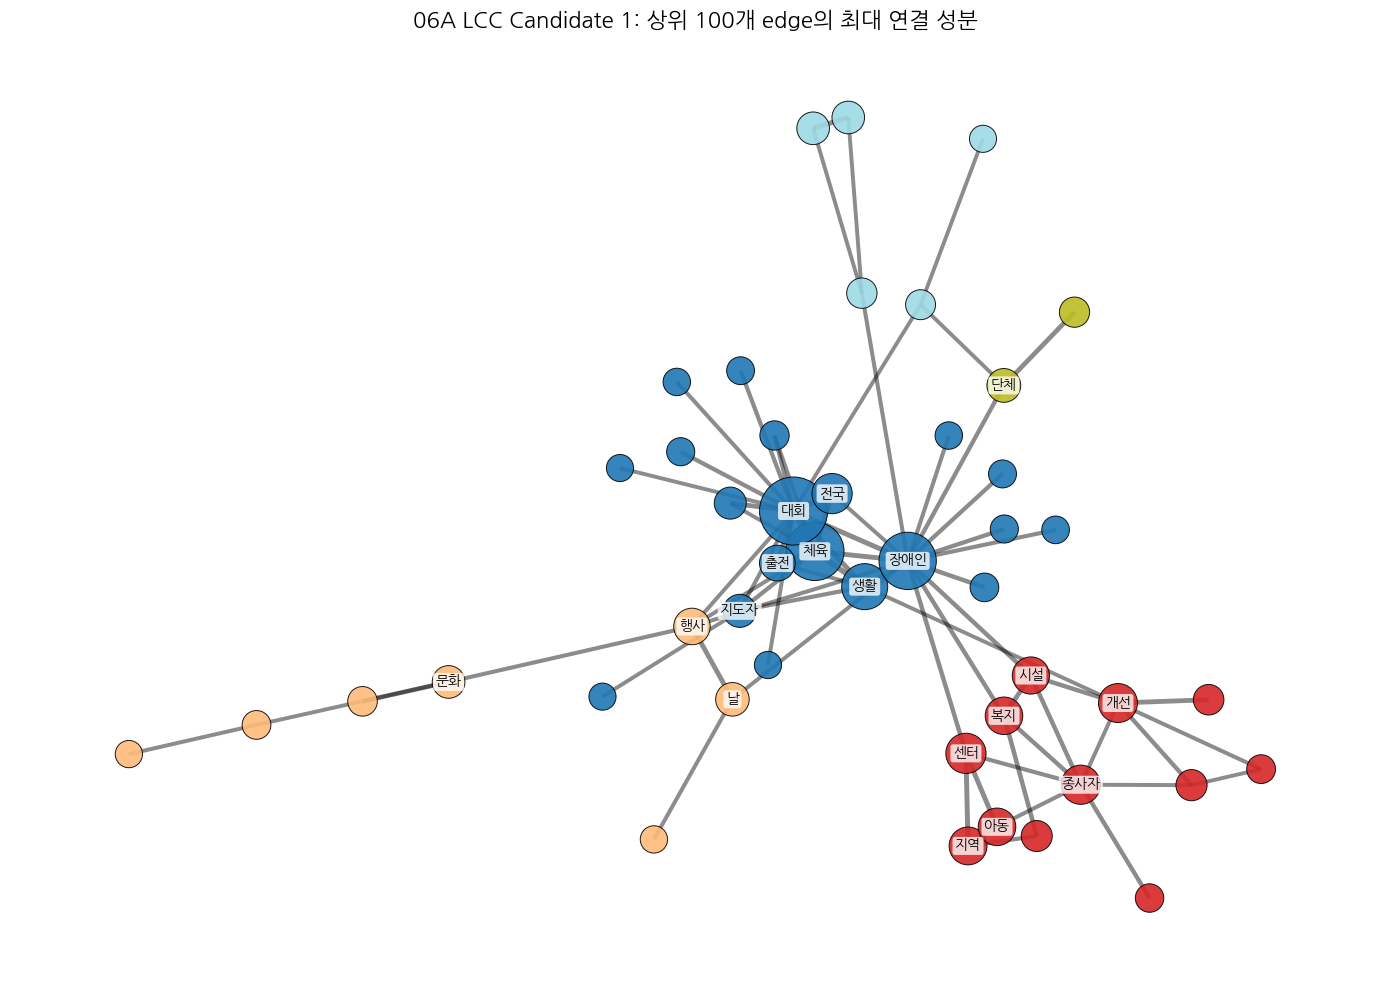

Figure 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_lcc_weight_ge_100_v1_20260603_0826.png


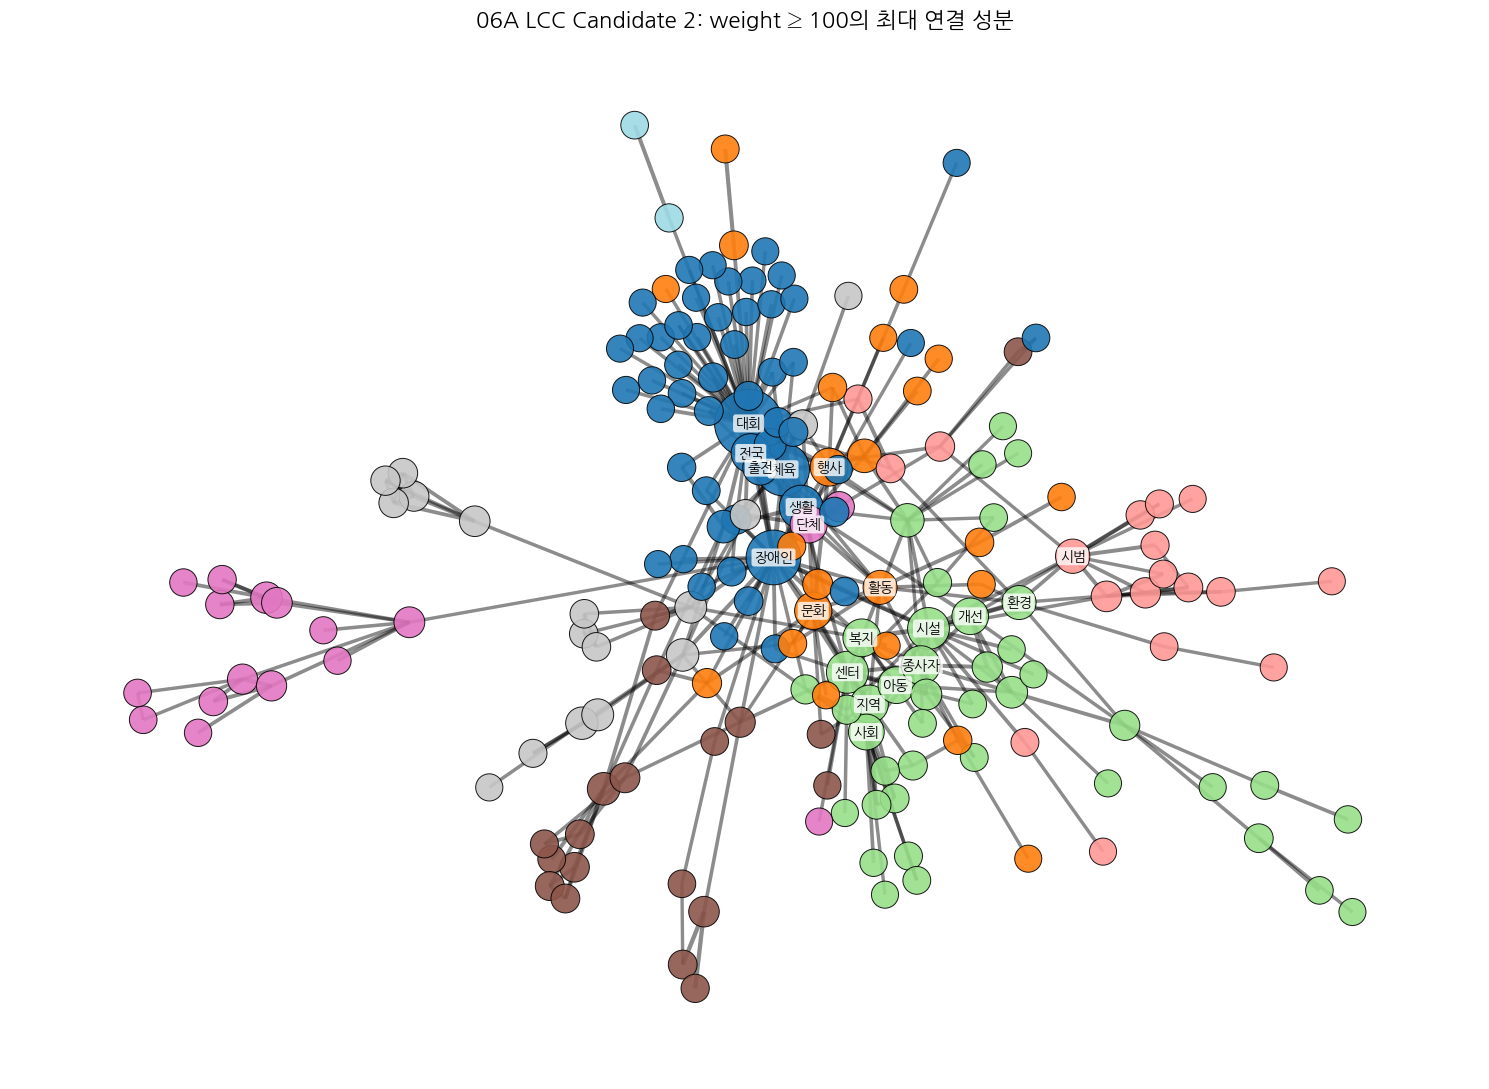


[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_lcc_candidate_summary_v1_20260603_0826.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_lcc_candidate_edges_v1_20260603_0826.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_lcc_candidate_nodes_v1_20260603_0826.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_lcc_top100_edges_v1_20260603_0826.png
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_lcc_weight_ge_100_v1_20260603_0826.png

[06A-8-FIX2 간단 판정]
- lcc_top100_edges: base nodes 95 -> lcc nodes 46, base edges 100 -> lcc edges 71, 

In [ ]:
# 06A-8-FIX2. Largest Connected Component 중심 포스터용 Figure 재생성

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
SAVE_OUTPUT = True

from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 한글 폰트 확인
# ------------------------------------------------------------
# 이미 06A-8-FIX에서 설치했더라도, 현재 셀만 단독 실행 가능하도록 재설정한다.

font_path = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

if not font_path.exists():
    !apt-get -qq update
    !apt-get -qq install -y fonts-nanum

fm.fontManager.addfont(str(font_path))
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트 설정]")
print("사용 폰트:", plt.rcParams["font.family"])
print("폰트 경로:", font_path)


# ------------------------------------------------------------
# 2) 입력 객체 점검
# ------------------------------------------------------------
required_objects = [
    "edge_df",
    "node_centrality_df",
    "community_node_df",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-5~06A-7 또는 이후 셀을 먼저 실행한 뒤 다시 실행하세요."
    )

required_edge_cols = ["source", "target", "weight"]
missing_edge_cols = [col for col in required_edge_cols if col not in edge_df.columns]
if len(missing_edge_cols) > 0:
    raise KeyError(f"edge_df에 다음 열이 없습니다: {missing_edge_cols}")

required_node_cols = [
    "word",
    "doc_freq_unique",
    "weighted_degree",
    "betweenness_centrality_distance",
    "pagerank_weighted",
]
missing_node_cols = [col for col in required_node_cols if col not in node_centrality_df.columns]
if len(missing_node_cols) > 0:
    raise KeyError(f"node_centrality_df에 다음 열이 없습니다: {missing_node_cols}")

required_comm_cols = ["word", "community_id", "community_size"]
missing_comm_cols = [col for col in required_comm_cols if col not in community_node_df.columns]
if len(missing_comm_cols) > 0:
    raise KeyError(f"community_node_df에 다음 열이 없습니다: {missing_comm_cols}")

print("\n[입력 객체 확인 완료]")
print("edge_df 행 수:", len(edge_df))
print("node_centrality_df 행 수:", len(node_centrality_df))
print("community_node_df 행 수:", len(community_node_df))


# ------------------------------------------------------------
# 3) 보조 함수 정의
# ------------------------------------------------------------
def build_graph_from_edge_table(edge_table):
    """
    edge table을 NetworkX Graph로 변환한다.
    """
    G = nx.Graph()

    for _, row in edge_table.iterrows():
        G.add_edge(
            str(row["source"]),
            str(row["target"]),
            weight=float(row["weight"])
        )

    return G


def get_largest_component_edge_table(edge_table):
    """
    주어진 edge table에서 largest connected component만 추출한 edge table을 반환한다.
    """
    G = build_graph_from_edge_table(edge_table)

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        return edge_table.iloc[0:0].copy(), set(), G

    components = list(nx.connected_components(G))
    largest_nodes = max(components, key=len)

    G_lcc = G.subgraph(largest_nodes).copy()

    lcc_edge_rows = []
    for u, v, data in G_lcc.edges(data=True):
        lcc_edge_rows.append({
            "source": u,
            "target": v,
            "weight": data.get("weight", np.nan)
        })

    lcc_edge_table = pd.DataFrame(lcc_edge_rows)

    if len(lcc_edge_table) > 0:
        lcc_edge_table = lcc_edge_table.sort_values(
            ["weight", "source", "target"],
            ascending=[False, True, True]
        ).reset_index(drop=True)

    return lcc_edge_table, largest_nodes, G_lcc


def make_candidate_node_table(candidate_name, edge_table, node_centrality_df, community_node_df):
    """
    후보 edge table에 포함된 node만 추출하고 중심성/커뮤니티 정보를 붙인다.
    """
    candidate_nodes = sorted(
        set(edge_table["source"].astype(str)).union(
            set(edge_table["target"].astype(str))
        )
    )

    node_table = pd.DataFrame({"word": candidate_nodes})

    node_table = node_table.merge(
        node_centrality_df,
        on="word",
        how="left",
        validate="one_to_one"
    )

    community_info = (
        community_node_df[["word", "community_id", "community_size"]]
        .drop_duplicates("word")
        .copy()
    )

    # 혹시 중복 열이 있으면 제거
    for col in ["community_id", "community_size"]:
        if col in node_table.columns:
            node_table = node_table.drop(columns=[col], errors="ignore")

    node_table = node_table.merge(
        community_info,
        on="word",
        how="left",
        validate="one_to_one"
    )

    G_temp = build_graph_from_edge_table(edge_table)

    candidate_degree = dict(G_temp.degree())
    candidate_weighted_degree = dict(G_temp.degree(weight="weight"))

    node_table["candidate_name"] = candidate_name
    node_table["candidate_degree"] = node_table["word"].map(candidate_degree).fillna(0).astype(int)
    node_table["candidate_weighted_degree"] = node_table["word"].map(candidate_weighted_degree).fillna(0)

    node_table = node_table.sort_values(
        ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique", "word"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    node_table["candidate_node_rank"] = range(1, len(node_table) + 1)

    return node_table


def scale_series_to_range(series, min_value=350, max_value=2200):
    """
    node size scaling
    """
    s = pd.Series(series).astype(float)

    if len(s) == 0:
        return []

    s_min = s.min()
    s_max = s.max()

    if s_max == s_min:
        return [int((min_value + max_value) / 2)] * len(s)

    scaled = min_value + (s - s_min) / (s_max - s_min) * (max_value - min_value)
    return scaled.tolist()


def draw_lcc_network_candidate(
    candidate_name,
    edge_table,
    node_table,
    output_path=None,
    title=None,
    label_top_n=18,
    layout_seed=42,
    figsize=(14, 10)
):
    """
    largest connected component 기반 포스터 후보 Figure
    """
    G = build_graph_from_edge_table(edge_table)

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        print(f"{candidate_name}: 그래프가 비어 있어 시각화하지 않습니다.")
        return None

    n_nodes = G.number_of_nodes()
    k_value = 1.3 / np.sqrt(max(n_nodes, 2))

    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        weight="weight",
        k=k_value,
        iterations=300
    )

    nodes = list(G.nodes())

    plot_node_table = (
        node_table
        .set_index("word")
        .reindex(nodes)
        .copy()
    )

    node_sizes = scale_series_to_range(
        plot_node_table["candidate_weighted_degree"].fillna(0),
        min_value=380,
        max_value=2400
    )

    node_colors = (
        plot_node_table["community_id"]
        .fillna(0)
        .astype(int)
        .tolist()
    )

    edge_weights = [G[u][v].get("weight", 1) for u, v in G.edges()]

    edge_widths = [
        max(0.8, min(6.0, np.log1p(w) / 1.9))
        for w in edge_weights
    ]

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.45
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        alpha=0.9,
        linewidths=0.7,
        edgecolors="black"
    )

    label_nodes = (
        node_table
        .sort_values(
            ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique"],
            ascending=[False, False, False]
        )
        .head(label_top_n)["word"]
        .tolist()
    )

    labels = {
        node: node
        for node in label_nodes
        if node in G.nodes()
    }

    text_items = nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=10,
        font_family="NanumGothic"
    )

    for _, text in text_items.items():
        text.set_bbox(
            dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.78,
                boxstyle="round,pad=0.18"
            )
        )

    if title is None:
        title = candidate_name

    plt.title(title, fontsize=16, fontfamily="NanumGothic")
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print("Figure 저장:", output_path)

    plt.show()

    return G


# ------------------------------------------------------------
# 4) base 후보 edge table 생성
# ------------------------------------------------------------
# A. top100 edge 후보
TOP100_EDGE_N = 100

base_top100_edges = (
    edge_df[["source", "target", "weight"]]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .head(TOP100_EDGE_N)
    .reset_index(drop=True)
)

base_top100_edges["base_candidate_name"] = "base_top100_edges"
base_top100_edges["base_rule"] = "전체 edge 중 weight 상위 100개"

# B. weight >= 100 후보
MIN_WEIGHT_FOR_BASE = 100

base_weight_ge_100_edges = (
    edge_df.loc[edge_df["weight"] >= MIN_WEIGHT_FOR_BASE, ["source", "target", "weight"]]
    .copy()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .reset_index(drop=True)
)

base_weight_ge_100_edges["base_candidate_name"] = "base_weight_ge_100"
base_weight_ge_100_edges["base_rule"] = "전체 edge 중 weight >= 100"

base_candidate_dict = {
    "lcc_top100_edges": base_top100_edges,
    "lcc_weight_ge_100": base_weight_ge_100_edges,
}


# ------------------------------------------------------------
# 5) largest connected component 추출
# ------------------------------------------------------------
lcc_candidate_edge_dict = {}
lcc_candidate_node_dict = {}
G_lcc_candidate_dict = {}
lcc_summary_rows = []

for candidate_name, base_edge_table in base_candidate_dict.items():
    base_graph = build_graph_from_edge_table(base_edge_table)

    if base_graph.number_of_nodes() == 0 or base_graph.number_of_edges() == 0:
        print(f"{candidate_name}: base graph가 비어 있습니다.")
        continue

    base_component_count = nx.number_connected_components(base_graph)
    base_node_count = base_graph.number_of_nodes()
    base_edge_count = base_graph.number_of_edges()

    lcc_edge_table, largest_nodes, G_lcc = get_largest_component_edge_table(base_edge_table)

    if len(lcc_edge_table) == 0:
        print(f"{candidate_name}: largest connected component를 만들지 못했습니다.")
        continue

    lcc_edge_table["candidate_name"] = candidate_name
    lcc_edge_table["candidate_rule"] = (
        "base 후보에서 largest connected component만 추출"
    )

    lcc_candidate_edge_dict[candidate_name] = lcc_edge_table
    G_lcc_candidate_dict[candidate_name] = G_lcc

    node_table = make_candidate_node_table(
        candidate_name=candidate_name,
        edge_table=lcc_edge_table,
        node_centrality_df=node_centrality_df,
        community_node_df=community_node_df
    )
    lcc_candidate_node_dict[candidate_name] = node_table

    lcc_node_count = G_lcc.number_of_nodes()
    lcc_edge_count = G_lcc.number_of_edges()
    lcc_density = nx.density(G_lcc) if lcc_node_count > 1 else 0

    lcc_summary_rows.append({
        "candidate_name": candidate_name,
        "base_rule": base_edge_table["base_rule"].iloc[0],
        "base_node_count": base_node_count,
        "base_edge_count": base_edge_count,
        "base_component_count": base_component_count,
        "lcc_node_count": lcc_node_count,
        "lcc_edge_count": lcc_edge_count,
        "lcc_node_share_percent": round(lcc_node_count / base_node_count * 100, 2),
        "lcc_edge_share_percent": round(lcc_edge_count / base_edge_count * 100, 2),
        "lcc_density": round(lcc_density, 6),
        "max_edge_weight": int(lcc_edge_table["weight"].max()),
        "min_edge_weight": int(lcc_edge_table["weight"].min()),
        "top_nodes_by_candidate_weighted_degree": ", ".join(
            node_table
            .sort_values("candidate_weighted_degree", ascending=False)
            .head(15)["word"]
            .tolist()
        )
    })

lcc_candidate_summary = pd.DataFrame(lcc_summary_rows)

print("\n[LCC 후보 요약]")
display(lcc_candidate_summary)

for candidate_name in lcc_candidate_edge_dict:
    print(f"\n[{candidate_name}] edge 상위 15개")
    display(
        lcc_candidate_edge_dict[candidate_name]
        .sort_values(["weight", "source", "target"], ascending=[False, True, True])
        .head(15)
    )

    print(f"\n[{candidate_name}] node 상위 15개")
    display(
        lcc_candidate_node_dict[candidate_name]
        .sort_values(
            ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique"],
            ascending=[False, False, False]
        )
        .head(15)[
            [
                "word",
                "community_id",
                "doc_freq_unique",
                "weighted_degree",
                "betweenness_centrality_distance",
                "candidate_degree",
                "candidate_weighted_degree",
            ]
        ]
    )


# ------------------------------------------------------------
# 6) Figure 생성 및 저장
# ------------------------------------------------------------
if SAVE_OUTPUT:
    lcc_top100_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_lcc_top100_edges_{RUN_VERSION}_{RUN_TS}.png"
    )

    lcc_weight_ge_100_fig_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_lcc_weight_ge_100_{RUN_VERSION}_{RUN_TS}.png"
    )
else:
    lcc_top100_fig_path = None
    lcc_weight_ge_100_fig_path = None

draw_lcc_network_candidate(
    candidate_name="lcc_top100_edges",
    edge_table=lcc_candidate_edge_dict["lcc_top100_edges"],
    node_table=lcc_candidate_node_dict["lcc_top100_edges"],
    output_path=lcc_top100_fig_path,
    title="06A LCC Candidate 1: 상위 100개 edge의 최대 연결 성분",
    label_top_n=18,
    layout_seed=42,
    figsize=(14, 10)
)

draw_lcc_network_candidate(
    candidate_name="lcc_weight_ge_100",
    edge_table=lcc_candidate_edge_dict["lcc_weight_ge_100"],
    node_table=lcc_candidate_node_dict["lcc_weight_ge_100"],
    output_path=lcc_weight_ge_100_fig_path,
    title="06A LCC Candidate 2: weight ≥ 100의 최대 연결 성분",
    label_top_n=20,
    layout_seed=42,
    figsize=(15, 11)
)


# ------------------------------------------------------------
# 7) 표 저장
# ------------------------------------------------------------
if SAVE_OUTPUT:
    lcc_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_lcc_candidate_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    lcc_edges_path = (
        TABLE_FINAL_DIR
        / f"06A_lcc_candidate_edges_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    lcc_nodes_path = (
        TABLE_FINAL_DIR
        / f"06A_lcc_candidate_nodes_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    with pd.ExcelWriter(lcc_summary_path) as writer:
        lcc_candidate_summary.to_excel(
            writer,
            sheet_name="lcc_summary",
            index=False
        )

    with pd.ExcelWriter(lcc_edges_path) as writer:
        for candidate_name, candidate_edges in lcc_candidate_edge_dict.items():
            candidate_edges.to_excel(
                writer,
                sheet_name=candidate_name[:31],
                index=False
            )

    with pd.ExcelWriter(lcc_nodes_path) as writer:
        for candidate_name, candidate_nodes in lcc_candidate_node_dict.items():
            candidate_nodes.to_excel(
                writer,
                sheet_name=candidate_name[:31],
                index=False
            )

    print("\n[저장 완료]")
    print(lcc_summary_path)
    print(lcc_edges_path)
    print(lcc_nodes_path)
    print(lcc_top100_fig_path)
    print(lcc_weight_ge_100_fig_path)
else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 8) 간단 판정
# ------------------------------------------------------------
print("\n[06A-8-FIX2 간단 판정]")

for _, row in lcc_candidate_summary.iterrows():
    print(
        f"- {row['candidate_name']}: "
        f"base nodes {row['base_node_count']} -> lcc nodes {row['lcc_node_count']}, "
        f"base edges {row['base_edge_count']} -> lcc edges {row['lcc_edge_count']}, "
        f"node share {row['lcc_node_share_percent']}%, "
        f"edge share {row['lcc_edge_share_percent']}%, "
        f"min edge weight {row['min_edge_weight']}"
    )

print("\n판단 기준:")
print("- 작은 분절 component가 사라지고 중심 네트워크가 더 응집적으로 보이는지 확인합니다.")
print("- 라벨 겹침이 줄었는지 확인합니다.")
print("- 포스터 본문에는 lcc_top100_edges와 lcc_weight_ge_100 중 더 읽기 쉬운 것을 우선 검토합니다.")
print("\n06A-8-FIX2 실행 완료")

06A-8-FINAL. 포스터용 최종 후보 Figure 저장 및 후보 판정표 작성
1. 이 단계의 목적

이 단계의 목적은 지금까지 생성한 Figure 후보 중 포스터 메인 Figure로 사용할 최종 후보를 지정하고, 발표·공유용 산출물을 정리하는 것입니다.

이번 단계에서는 다음을 수행합니다.

1. LCC Candidate 1을 포스터 메인 Figure 후보로 확정
2. 제목을 발표용으로 수정
3. 라벨 수와 라벨 단어를 조정
4. PNG와 SVG 형식으로 저장
5. 포스터용/부록용/보류 후보 판정표 저장
6. 최종 Figure에 사용된 node/edge 목록 저장

SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.
RUN_VERSION: v1
RUN_TS: 20260603_0835

[한글 폰트 설정]
사용 폰트: ['NanumGothic']
폰트 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf

[입력 객체 확인 완료]
LCC 후보 수: 2


,candidate_name,base_rule,base_node_count,base_edge_count,base_component_count,lcc_node_count,lcc_edge_count,lcc_node_share_percent,lcc_edge_share_percent,lcc_density,max_edge_weight,min_edge_weight,top_nodes_by_candidate_weighted_degree
0,lcc_top100_edges,전체 edge 중 weight 상위 100개,95,100,22,46,71,48.42,71.00,0.068599,2476,196,"대회, 체육, 장애인, 생활, 전국, 센터, 종사자, 개선, 지역, 아동, 복지, ..."
1,lcc_weight_ge_100,전체 edge 중 weight >= 100,243,382,21,192,347,79.01,90.84,0.018925,2476,100,"대회, 장애인, 체육, 생활, 센터, 시설, 전국, 종사자, 지역, 행사, 복지, ..."



[포스터 최종 후보 지정]
POSTER_FINAL_CANDIDATE_NAME: lcc_top100_edges
edge 수: 71
node 수: 46

[최종 후보 graph 생성 완료]
node 수: 46
edge 수: 71
component 수: 1

[최종 Figure 라벨 단어]
['대회', '체육', '장애인', '생활', '전국', '출전', '센터', '시설', '복지', '지역', '아동', '종사자', '개선', '행사', '문화', '날', '단체']
PNG 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_poster_final_candidate_lcc_top100_edges_v1_20260603_0835.png
SVG 저장: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_poster_final_candidate_lcc_top100_edges_v1_20260603_0835.svg


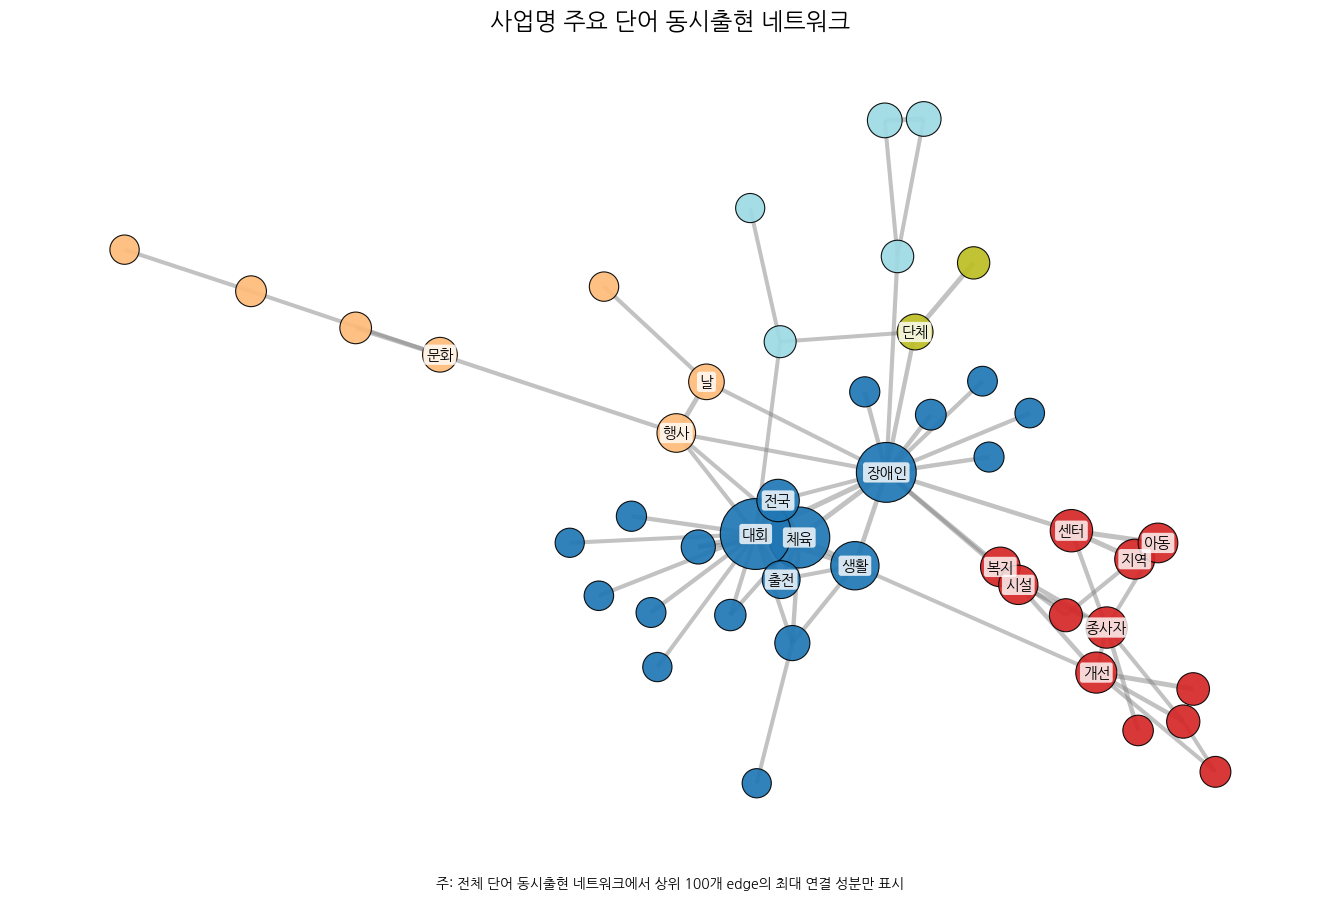


[poster_final_summary]


,항목,값
0,포스터 최종 후보,lcc_top100_edges
1,선택 기준,전체 edge 중 weight 상위 100개 후보에서 largest connecte...
2,node 수,46
3,edge 수,71
4,component 수,1
5,density,0.068599
6,최대 edge weight,2476
7,최소 edge weight,196
8,표시 라벨 수,17
9,표시 라벨,"대회, 체육, 장애인, 생활, 전국, 출전, 센터, 시설, 복지, 지역, 아동, 종..."



[poster_figure_decision_table]


,candidate_name,decision,use_location,reason,caution
0,lcc_top100_edges,poster_main_final_candidate,poster_main_figure,작은 component를 제거한 뒤 46개 node와 71개 edge로 축약되어 주...,전체 네트워크가 아니라 상위 100개 edge의 최대 연결 성분만 표시한 가독성 중...
1,lcc_weight_ge_100,appendix_or_backup,appendix_or_presentation_backup,192개 node와 347개 edge로 전체 강한 연결 구조를 풍부하게 보여주지만 ...,작게 출력하면 라벨과 노드가 겹쳐 가독성이 떨어질 수 있음
2,refined_poster_top80_edges,hold,not_recommended_for_main_poster,component가 많이 분절되어 네트워크 구조보다 흩어진 점들이 먼저 보임,보조 검토용으로만 보관
3,refined_poster_top100_edges,hold,not_recommended_for_main_poster,component가 많이 분절되어 포스터 메인 Figure로는 산만함,보조 검토용으로만 보관
4,refined_community_core_weight_ge_30,hold_or_method_appendix,method_appendix_if_needed,community 구조 설명용으로는 의미가 있으나 포스터 메인 Figure로는 분절이 큼,커뮤니티 결과는 공식 정책분야가 아니라 탐색적 단어 묶음임



[저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_poster_final_candidate_lcc_top100_edges_v1_20260603_0835.png
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final/06A_network_poster_final_candidate_lcc_top100_edges_v1_20260603_0835.svg
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_poster_final_candidate_summary_v1_20260603_0835.xlsx
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_poster_final_edge_list_v1_20260603_0835.csv
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final/06A_poster_final_node_list_v1_20260603_0835.csv

[06A-8-FINAL 간단 판정]
- 포스터 최종 후보: lcc_top100_

In [ ]:
# 06A-8-FINAL. 포스터용 최종 후보 Figure 저장 및 후보 판정표 작성

# ------------------------------------------------------------
# 0) 저장 설정
# ------------------------------------------------------------
SAVE_OUTPUT = True

from datetime import datetime
from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

if SAVE_OUTPUT:
    for folder in [
        TABLE_FINAL_DIR,
        TABLE_REVIEW_DIR,
        TABLE_ARCHIVE_DIR,
        FIGURE_FINAL_DIR,
        FIGURE_REVIEW_DIR,
        FIGURE_ARCHIVE_DIR,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    print("SAVE_OUTPUT=True: 저장 폴더를 확인/생성했습니다.")
else:
    print("SAVE_OUTPUT=False: 이번 셀에서는 파일을 저장하지 않습니다.")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)


# ------------------------------------------------------------
# 1) 한글 폰트 재설정
# ------------------------------------------------------------
# 최종 Figure 저장 시에도 한글이 깨지지 않도록 NanumGothic을 다시 지정한다.

font_path = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

if not font_path.exists():
    !apt-get -qq update
    !apt-get -qq install -y fonts-nanum

fm.fontManager.addfont(str(font_path))
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트 설정]")
print("사용 폰트:", plt.rcParams["font.family"])
print("폰트 경로:", font_path)


# ------------------------------------------------------------
# 2) 입력 객체 점검
# ------------------------------------------------------------

required_objects = [
    "lcc_candidate_edge_dict",
    "lcc_candidate_node_dict",
    "lcc_candidate_summary",
]

missing_objects = [obj for obj in required_objects if obj not in globals()]

if len(missing_objects) > 0:
    raise NameError(
        f"다음 객체가 없습니다: {missing_objects}. "
        "06A-8-FIX2를 먼저 실행한 뒤 다시 실행하세요."
    )

if "lcc_top100_edges" not in lcc_candidate_edge_dict:
    raise KeyError("lcc_candidate_edge_dict에 'lcc_top100_edges'가 없습니다.")

if "lcc_top100_edges" not in lcc_candidate_node_dict:
    raise KeyError("lcc_candidate_node_dict에 'lcc_top100_edges'가 없습니다.")

if "lcc_weight_ge_100" not in lcc_candidate_edge_dict:
    raise KeyError("lcc_candidate_edge_dict에 'lcc_weight_ge_100'가 없습니다.")

print("\n[입력 객체 확인 완료]")
print("LCC 후보 수:", len(lcc_candidate_edge_dict))
display(lcc_candidate_summary)


# ------------------------------------------------------------
# 3) 포스터 최종 후보 지정
# ------------------------------------------------------------

POSTER_FINAL_CANDIDATE_NAME = "lcc_top100_edges"
APPENDIX_CANDIDATE_NAME = "lcc_weight_ge_100"

poster_final_edge_df = lcc_candidate_edge_dict[POSTER_FINAL_CANDIDATE_NAME].copy()
poster_final_node_df = lcc_candidate_node_dict[POSTER_FINAL_CANDIDATE_NAME].copy()

# source-target 문자열 정리
poster_final_edge_df["source"] = poster_final_edge_df["source"].astype(str)
poster_final_edge_df["target"] = poster_final_edge_df["target"].astype(str)

poster_final_node_df["word"] = poster_final_node_df["word"].astype(str)

print("\n[포스터 최종 후보 지정]")
print("POSTER_FINAL_CANDIDATE_NAME:", POSTER_FINAL_CANDIDATE_NAME)
print("edge 수:", len(poster_final_edge_df))
print("node 수:", len(poster_final_node_df))


# ------------------------------------------------------------
# 4) 최종 Figure용 graph 생성
# ------------------------------------------------------------

G_poster_final = nx.Graph()

for _, row in poster_final_edge_df.iterrows():
    G_poster_final.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

print("\n[최종 후보 graph 생성 완료]")
print("node 수:", G_poster_final.number_of_nodes())
print("edge 수:", G_poster_final.number_of_edges())
print("component 수:", nx.number_connected_components(G_poster_final))


# ------------------------------------------------------------
# 5) 최종 Figure 라벨 단어 지정
# ------------------------------------------------------------
# 포스터에서는 너무 많은 라벨보다 핵심 구조가 읽히는 것이 중요하다.
# 데이터 상위 단어를 기준으로 하되, 해석에 필요한 주요 단어를 우선 포함한다.

POSTER_LABEL_WORDS_PRIORITY = [
    # 체육·장애인·대회 묶음
    "대회",
    "체육",
    "장애인",
    "생활",
    "전국",
    "출전",

    # 복지·시설·지역서비스 묶음
    "센터",
    "시설",
    "복지",
    "지역",
    "아동",
    "종사자",
    "개선",

    # 문화·행사 묶음
    "행사",
    "문화",
    "날",

    # 보훈·단체 등 보조 묶음
    "단체",
]

POSTER_LABEL_TOP_N = 17

# 우선순위 단어 중 graph에 있는 단어만 사용
label_words = [
    word for word in POSTER_LABEL_WORDS_PRIORITY
    if word in G_poster_final.nodes()
]

# 부족하면 candidate_weighted_degree 상위 단어로 보충
top_words_for_supplement = (
    poster_final_node_df
    .sort_values(
        ["candidate_weighted_degree", "weighted_degree", "doc_freq_unique", "word"],
        ascending=[False, False, False, True]
    )["word"]
    .tolist()
)

for word in top_words_for_supplement:
    if len(label_words) >= POSTER_LABEL_TOP_N:
        break

    if word not in label_words and word in G_poster_final.nodes():
        label_words.append(word)

label_words = label_words[:POSTER_LABEL_TOP_N]

poster_final_node_df["show_label_in_poster_final"] = (
    poster_final_node_df["word"].isin(label_words)
)

poster_final_node_df["label_selection_reason"] = np.where(
    poster_final_node_df["word"].isin(POSTER_LABEL_WORDS_PRIORITY),
    "priority_label",
    np.where(
        poster_final_node_df["show_label_in_poster_final"],
        "supplement_by_candidate_weighted_degree",
        "not_labeled"
    )
)

print("\n[최종 Figure 라벨 단어]")
print(label_words)


# ------------------------------------------------------------
# 6) 시각화 보조 함수
# ------------------------------------------------------------

def scale_series_to_range_final(series, min_value=420, max_value=2500):
    """
    node size scaling
    """
    s = pd.Series(series).astype(float)

    if len(s) == 0:
        return []

    s_min = s.min()
    s_max = s.max()

    if s_max == s_min:
        return [int((min_value + max_value) / 2)] * len(s)

    scaled = min_value + (s - s_min) / (s_max - s_min) * (max_value - min_value)
    return scaled.tolist()


def draw_poster_final_network(
    G,
    node_table,
    label_words,
    output_png_path=None,
    output_svg_path=None,
    layout_seed=42,
    figsize=(13.5, 9.5)
):
    """
    포스터용 최종 후보 네트워크 Figure를 생성한다.
    """

    n_nodes = G.number_of_nodes()

    # 이전 LCC 후보보다 약간 더 벌려 라벨 겹침을 줄인다.
    k_value = 1.55 / np.sqrt(max(n_nodes, 2))

    pos = nx.spring_layout(
        G,
        seed=layout_seed,
        weight="weight",
        k=k_value,
        iterations=400
    )

    nodes = list(G.nodes())

    plot_node_table = (
        node_table
        .set_index("word")
        .reindex(nodes)
        .copy()
    )

    node_sizes = scale_series_to_range_final(
        plot_node_table["candidate_weighted_degree"].fillna(0),
        min_value=440,
        max_value=2600
    )

    node_colors = (
        plot_node_table["community_id"]
        .fillna(0)
        .astype(int)
        .tolist()
    )

    edge_weights = [G[u][v].get("weight", 1) for u, v in G.edges()]

    # edge 선은 이전보다 조금 진하게 조정
    edge_widths = [
        max(0.9, min(6.2, np.log1p(w) / 1.85))
        for w in edge_weights
    ]

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        width=edge_widths,
        alpha=0.48,
        edge_color="gray"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        alpha=0.92,
        linewidths=0.8,
        edgecolors="black"
    )

    labels = {
        node: node
        for node in label_words
        if node in G.nodes()
    }

    text_items = nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=10.5,
        font_family="NanumGothic"
    )

    for _, text in text_items.items():
        text.set_bbox(
            dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
                boxstyle="round,pad=0.18"
            )
        )

    plt.title(
        "사업명 주요 단어 동시출현 네트워크",
        fontsize=17,
        fontfamily="NanumGothic",
        pad=16
    )

    # 포스터용 보조 설명
    plt.figtext(
        0.5,
        0.02,
        "주: 전체 단어 동시출현 네트워크에서 상위 100개 edge의 최대 연결 성분만 표시",
        ha="center",
        fontsize=10,
        fontfamily="NanumGothic"
    )

    plt.axis("off")
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])

    if output_png_path is not None:
        plt.savefig(output_png_path, dpi=300, bbox_inches="tight")
        print("PNG 저장:", output_png_path)

    if output_svg_path is not None:
        plt.savefig(output_svg_path, bbox_inches="tight")
        print("SVG 저장:", output_svg_path)

    plt.show()


# ------------------------------------------------------------
# 7) 최종 Figure 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    poster_final_png_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_poster_final_candidate_lcc_top100_edges_{RUN_VERSION}_{RUN_TS}.png"
    )

    poster_final_svg_path = (
        FIGURE_FINAL_DIR
        / f"06A_network_poster_final_candidate_lcc_top100_edges_{RUN_VERSION}_{RUN_TS}.svg"
    )
else:
    poster_final_png_path = None
    poster_final_svg_path = None

draw_poster_final_network(
    G=G_poster_final,
    node_table=poster_final_node_df,
    label_words=label_words,
    output_png_path=poster_final_png_path,
    output_svg_path=poster_final_svg_path,
    layout_seed=42,
    figsize=(13.5, 9.5)
)


# ------------------------------------------------------------
# 8) 최종 후보 요약표 및 판정표 생성
# ------------------------------------------------------------

poster_final_summary = pd.DataFrame({
    "항목": [
        "포스터 최종 후보",
        "선택 기준",
        "node 수",
        "edge 수",
        "component 수",
        "density",
        "최대 edge weight",
        "최소 edge weight",
        "표시 라벨 수",
        "표시 라벨",
        "해석 범위",
        "주의사항",
    ],
    "값": [
        POSTER_FINAL_CANDIDATE_NAME,
        "전체 edge 중 weight 상위 100개 후보에서 largest connected component만 추출",
        G_poster_final.number_of_nodes(),
        G_poster_final.number_of_edges(),
        nx.number_connected_components(G_poster_final),
        round(nx.density(G_poster_final), 6),
        int(poster_final_edge_df["weight"].max()),
        int(poster_final_edge_df["weight"].min()),
        len(label_words),
        ", ".join(label_words),
        "사업명 텍스트에서 강하게 함께 등장한 중심 단어 연결 구조를 보여주는 탐색적 Figure",
        "전체 네트워크가 아니라 포스터 가독성을 위해 최대 연결 성분만 표시한 축약 Figure",
    ]
})

poster_figure_decision_table = pd.DataFrame([
    {
        "candidate_name": "lcc_top100_edges",
        "decision": "poster_main_final_candidate",
        "use_location": "poster_main_figure",
        "reason": (
            "작은 component를 제거한 뒤 46개 node와 71개 edge로 축약되어 "
            "주요 연결 구조가 가장 명확하게 보임"
        ),
        "caution": (
            "전체 네트워크가 아니라 상위 100개 edge의 최대 연결 성분만 표시한 "
            "가독성 중심 Figure임"
        ),
    },
    {
        "candidate_name": "lcc_weight_ge_100",
        "decision": "appendix_or_backup",
        "use_location": "appendix_or_presentation_backup",
        "reason": (
            "192개 node와 347개 edge로 전체 강한 연결 구조를 풍부하게 보여주지만 "
            "포스터 본문에는 과밀함"
        ),
        "caution": "작게 출력하면 라벨과 노드가 겹쳐 가독성이 떨어질 수 있음",
    },
    {
        "candidate_name": "refined_poster_top80_edges",
        "decision": "hold",
        "use_location": "not_recommended_for_main_poster",
        "reason": "component가 많이 분절되어 네트워크 구조보다 흩어진 점들이 먼저 보임",
        "caution": "보조 검토용으로만 보관",
    },
    {
        "candidate_name": "refined_poster_top100_edges",
        "decision": "hold",
        "use_location": "not_recommended_for_main_poster",
        "reason": "component가 많이 분절되어 포스터 메인 Figure로는 산만함",
        "caution": "보조 검토용으로만 보관",
    },
    {
        "candidate_name": "refined_community_core_weight_ge_30",
        "decision": "hold_or_method_appendix",
        "use_location": "method_appendix_if_needed",
        "reason": "community 구조 설명용으로는 의미가 있으나 포스터 메인 Figure로는 분절이 큼",
        "caution": "커뮤니티 결과는 공식 정책분야가 아니라 탐색적 단어 묶음임",
    },
])


print("\n[poster_final_summary]")
display(poster_final_summary)

print("\n[poster_figure_decision_table]")
display(poster_figure_decision_table)


# ------------------------------------------------------------
# 9) 최종 산출물 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    poster_final_summary_path = (
        TABLE_FINAL_DIR
        / f"06A_poster_final_candidate_summary_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    poster_final_edge_path = (
        TABLE_FINAL_DIR
        / f"06A_poster_final_edge_list_{RUN_VERSION}_{RUN_TS}.csv"
    )

    poster_final_node_path = (
        TABLE_FINAL_DIR
        / f"06A_poster_final_node_list_{RUN_VERSION}_{RUN_TS}.csv"
    )

    poster_final_edge_df.to_csv(
        poster_final_edge_path,
        index=False,
        encoding="utf-8-sig"
    )

    poster_final_node_df.to_csv(
        poster_final_node_path,
        index=False,
        encoding="utf-8-sig"
    )

    with pd.ExcelWriter(poster_final_summary_path) as writer:
        poster_final_summary.to_excel(
            writer,
            sheet_name="poster_final_summary",
            index=False
        )

        poster_figure_decision_table.to_excel(
            writer,
            sheet_name="figure_decision",
            index=False
        )

        poster_final_edge_df.head(100).to_excel(
            writer,
            sheet_name="final_edges",
            index=False
        )

        poster_final_node_df.to_excel(
            writer,
            sheet_name="final_nodes",
            index=False
        )

    print("\n[저장 완료]")
    print(poster_final_png_path)
    print(poster_final_svg_path)
    print(poster_final_summary_path)
    print(poster_final_edge_path)
    print(poster_final_node_path)

else:
    print("\nSAVE_OUTPUT=False이므로 파일을 저장하지 않았습니다.")


# ------------------------------------------------------------
# 10) 06A-8-FINAL 간단 판정
# ------------------------------------------------------------

print("\n[06A-8-FINAL 간단 판정]")
print("- 포스터 최종 후보:", POSTER_FINAL_CANDIDATE_NAME)
print("- node 수:", G_poster_final.number_of_nodes())
print("- edge 수:", G_poster_final.number_of_edges())
print("- component 수:", nx.number_connected_components(G_poster_final))
print("- 표시 라벨 수:", len(label_words))
print("- PNG 저장:", poster_final_png_path if SAVE_OUTPUT else "저장 안 함")
print("- SVG 저장:", poster_final_svg_path if SAVE_OUTPUT else "저장 안 함")
print("\n다음 단계에서는 06A 전체 산출물 목록과 work_log/README 반영 내용을 정리하면 됩니다.")
print("\n06A-8-FINAL 실행 완료")

06A-9. final 폴더 산출물 정리 및 후보 파일 archive 이동
1. 이 단계의 목적

이 단계의 목적은 06A_v1_단어동시출현네트워크의 final 폴더에 섞여 있는 후보·중간 산출물을 정리하는 것입니다.

정리 원칙은 다음입니다.

1. 최종 분석 결과로 남길 파일은 final 폴더에 유지한다.
2. Figure 후보, refined 후보, LCC 후보 등 최종 선택 전 검토용 파일은 archive_intermediate로 이동한다.
3. 파일은 삭제하지 않는다.
4. 이동 전후 목록을 manifest로 저장한다.
5. 같은 유형의 최종 파일이 여러 개 있으면 최신 파일만 final에 남긴다.

이 단계는 파일 이동 작업이므로, 처음에는 DRY_RUN=True로 실행해 이동 계획만 확인하는 것을 권장합니다.
이동 계획이 맞으면 DRY_RUN=False로 바꿔 다시 실행하면 실제 이동됩니다.

In [ ]:
# 06A-9. final 폴더 산출물 정리 및 후보 파일 archive 이동

# ------------------------------------------------------------
# 0) 실행 설정
# ------------------------------------------------------------
# 처음에는 True로 실행해서 이동 계획만 확인한다.
# 계획이 맞으면 False로 바꿔 다시 실행하면 실제 이동된다.

DRY_RUN = False

SAVE_OUTPUT = True

from datetime import datetime
from pathlib import Path
import shutil
import pandas as pd
import numpy as np

RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)
print("DRY_RUN:", DRY_RUN)
print("SAVE_OUTPUT:", SAVE_OUTPUT)


# ------------------------------------------------------------
# 1) 입력 폴더 및 archive 폴더 설정
# ------------------------------------------------------------

TABLE_FINAL_DIR = Path(TABLE_FINAL_DIR)
TABLE_REVIEW_DIR = Path(TABLE_REVIEW_DIR)
TABLE_ARCHIVE_DIR = Path(TABLE_ARCHIVE_DIR)

FIGURE_FINAL_DIR = Path(FIGURE_FINAL_DIR)
FIGURE_REVIEW_DIR = Path(FIGURE_REVIEW_DIR)
FIGURE_ARCHIVE_DIR = Path(FIGURE_ARCHIVE_DIR)

TABLE_ARCHIVE_FROM_FINAL_DIR = (
    TABLE_ARCHIVE_DIR
    / f"archived_from_final_{RUN_TS}"
)

FIGURE_ARCHIVE_FROM_FINAL_DIR = (
    FIGURE_ARCHIVE_DIR
    / f"archived_from_final_{RUN_TS}"
)

print("\n[정리 대상 폴더]")
print("TABLE_FINAL_DIR:", TABLE_FINAL_DIR)
print("FIGURE_FINAL_DIR:", FIGURE_FINAL_DIR)

print("\n[archive 이동 예정 폴더]")
print("TABLE_ARCHIVE_FROM_FINAL_DIR:", TABLE_ARCHIVE_FROM_FINAL_DIR)
print("FIGURE_ARCHIVE_FROM_FINAL_DIR:", FIGURE_ARCHIVE_FROM_FINAL_DIR)


# ------------------------------------------------------------
# 2) final 폴더에 남길 파일 prefix 정의
# ------------------------------------------------------------
# 최종 분석 산출물로 final에 남길 파일 유형이다.
# 후보 Figure/후보 요약/실험용 산출물은 archive로 이동한다.

TABLE_KEEP_PREFIXES = [
    # 기본 네트워크 산출물
    "06A_word_edge_list_base_",
    "06A_word_node_list_base_",
    "06A_network_base_summary_",

    # 중심성 산출물
    "06A_word_node_centrality_base_",
    "06A_word_node_centrality_top_tables_",

    # 커뮤니티 산출물
    "06A_community_threshold_summary_",
    "06A_community_node_list_weight_ge_30_",
    "06A_community_summary_weight_ge_30_",
    "06A_community_edge_summary_weight_ge_30_",

    # 포스터 최종 후보 산출물
    "06A_poster_final_candidate_summary_",
    "06A_poster_final_edge_list_",
    "06A_poster_final_node_list_",
]

FIGURE_KEEP_PREFIXES = [
    # 포스터 최종 후보 Figure만 final에 유지
    "06A_network_poster_final_candidate_lcc_top100_edges_",
]

# archive로 보낼 대표 후보/중간 산출물 prefix
# 여기에 포함되지 않아도 KEEP prefix가 아니면 archive 대상이 된다.
TABLE_ARCHIVE_HINT_PREFIXES = [
    "06A_figure_candidate_",
    "06A_refined_figure_candidate_",
    "06A_lcc_candidate_",
]

FIGURE_ARCHIVE_HINT_PREFIXES = [
    "06A_network_candidate_",
    "06A_network_refined_",
    "06A_network_lcc_",
]


# ------------------------------------------------------------
# 3) 보조 함수 정의
# ------------------------------------------------------------

def get_matching_prefix(filename, prefixes):
    """
    filename이 prefixes 중 하나로 시작하면 해당 prefix를 반환한다.
    없으면 None을 반환한다.
    """
    for prefix in prefixes:
        if filename.startswith(prefix):
            return prefix
    return None


def get_latest_file_by_prefix(files, keep_prefixes):
    """
    keep_prefix별 최신 파일 하나를 찾는다.
    최신 기준은 파일 수정 시간이다.
    """
    latest_map = {}

    for file_path in files:
        prefix = get_matching_prefix(file_path.name, keep_prefixes)

        if prefix is None:
            continue

        if prefix not in latest_map:
            latest_map[prefix] = file_path
        else:
            if file_path.stat().st_mtime > latest_map[prefix].stat().st_mtime:
                latest_map[prefix] = file_path

    return latest_map


def make_unique_destination_path(destination_path):
    """
    같은 이름의 파일이 이미 있으면 _copy1, _copy2를 붙여 덮어쓰기를 방지한다.
    """
    destination_path = Path(destination_path)

    if not destination_path.exists():
        return destination_path

    stem = destination_path.stem
    suffix = destination_path.suffix
    parent = destination_path.parent

    copy_idx = 1

    while True:
        candidate = parent / f"{stem}_copy{copy_idx}{suffix}"

        if not candidate.exists():
            return candidate

        copy_idx += 1


def build_cleanup_plan(
    final_dir,
    archive_dir,
    keep_prefixes,
    folder_label
):
    """
    final 폴더의 파일을 검사해 keep/archive 계획표를 만든다.
    """
    final_dir = Path(final_dir)
    archive_dir = Path(archive_dir)

    files = sorted(
        [p for p in final_dir.iterdir() if p.is_file()],
        key=lambda x: x.name
    )

    latest_map = get_latest_file_by_prefix(files, keep_prefixes)
    latest_files_to_keep = set(latest_map.values())

    plan_rows = []

    for file_path in files:
        filename = file_path.name
        keep_prefix = get_matching_prefix(filename, keep_prefixes)

        if keep_prefix is not None:
            if file_path in latest_files_to_keep:
                action = "keep_in_final"
                reason = "최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일"
                destination_path = file_path
            else:
                action = "archive_old_version"
                reason = "최종 산출물 prefix에 해당하지만 같은 prefix의 최신 파일이 아님"
                destination_path = archive_dir / filename
        else:
            action = "archive_candidate_or_intermediate"
            reason = "최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물"
            destination_path = archive_dir / filename

        plan_rows.append({
            "folder_label": folder_label,
            "filename": filename,
            "source_path": str(file_path),
            "action": action,
            "reason": reason,
            "destination_path": str(destination_path),
            "file_size_kb": round(file_path.stat().st_size / 1024, 2),
            "modified_time": datetime.fromtimestamp(
                file_path.stat().st_mtime
            ).strftime("%Y-%m-%d %H:%M:%S"),
        })

    return pd.DataFrame(plan_rows)


def execute_cleanup_plan(cleanup_plan_df):
    """
    cleanup_plan_df에 따라 파일을 archive로 이동한다.
    keep_in_final은 이동하지 않는다.
    """
    moved_rows = []

    for _, row in cleanup_plan_df.iterrows():
        action = row["action"]
        source_path = Path(row["source_path"])
        destination_path = Path(row["destination_path"])

        if action == "keep_in_final":
            moved_rows.append({
                **row.to_dict(),
                "executed": False,
                "execution_result": "kept_in_final",
                "actual_destination_path": str(source_path),
            })
            continue

        if not source_path.exists():
            moved_rows.append({
                **row.to_dict(),
                "executed": False,
                "execution_result": "source_missing",
                "actual_destination_path": None,
            })
            continue

        destination_path.parent.mkdir(parents=True, exist_ok=True)
        unique_destination_path = make_unique_destination_path(destination_path)

        shutil.move(
            str(source_path),
            str(unique_destination_path)
        )

        moved_rows.append({
            **row.to_dict(),
            "executed": True,
            "execution_result": "moved_to_archive",
            "actual_destination_path": str(unique_destination_path),
        })

    return pd.DataFrame(moved_rows)


# ------------------------------------------------------------
# 4) cleanup plan 생성
# ------------------------------------------------------------

table_cleanup_plan = build_cleanup_plan(
    final_dir=TABLE_FINAL_DIR,
    archive_dir=TABLE_ARCHIVE_FROM_FINAL_DIR,
    keep_prefixes=TABLE_KEEP_PREFIXES,
    folder_label="tables/final"
)

figure_cleanup_plan = build_cleanup_plan(
    final_dir=FIGURE_FINAL_DIR,
    archive_dir=FIGURE_ARCHIVE_FROM_FINAL_DIR,
    keep_prefixes=FIGURE_KEEP_PREFIXES,
    folder_label="figures/final"
)

cleanup_plan_df = pd.concat(
    [table_cleanup_plan, figure_cleanup_plan],
    ignore_index=True
)

print("\n[cleanup plan 요약]")
display(
    cleanup_plan_df
    .groupby(["folder_label", "action"])
    .size()
    .reset_index(name="file_count")
)

print("\n[archive 이동 예정 파일]")
display(
    cleanup_plan_df.loc[
        cleanup_plan_df["action"] != "keep_in_final",
        [
            "folder_label",
            "filename",
            "action",
            "reason",
            "destination_path",
        ]
    ].sort_values(["folder_label", "filename"])
)

print("\n[final 유지 예정 파일]")
display(
    cleanup_plan_df.loc[
        cleanup_plan_df["action"] == "keep_in_final",
        [
            "folder_label",
            "filename",
            "action",
            "reason",
        ]
    ].sort_values(["folder_label", "filename"])
)


# ------------------------------------------------------------
# 5) cleanup plan 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

    cleanup_plan_path = (
        TABLE_REVIEW_DIR
        / f"06A_final_folder_cleanup_plan_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    with pd.ExcelWriter(cleanup_plan_path) as writer:
        cleanup_plan_df.to_excel(
            writer,
            sheet_name="cleanup_plan",
            index=False
        )

        cleanup_plan_df.groupby(
            ["folder_label", "action"]
        ).size().reset_index(
            name="file_count"
        ).to_excel(
            writer,
            sheet_name="summary",
            index=False
        )

    print("\n[cleanup plan 저장 완료]")
    print(cleanup_plan_path)


# ------------------------------------------------------------
# 6) 실제 이동 실행
# ------------------------------------------------------------

if DRY_RUN:
    cleanup_result_df = cleanup_plan_df.copy()
    cleanup_result_df["executed"] = False
    cleanup_result_df["execution_result"] = "dry_run_only"
    cleanup_result_df["actual_destination_path"] = None

    print("\nDRY_RUN=True이므로 실제 파일 이동은 하지 않았습니다.")
    print("이동 계획이 맞으면 DRY_RUN=False로 바꿔 다시 실행하세요.")

else:
    cleanup_result_df = execute_cleanup_plan(cleanup_plan_df)

    cleanup_result_path = (
        TABLE_REVIEW_DIR
        / f"06A_final_folder_cleanup_result_{RUN_VERSION}_{RUN_TS}.xlsx"
    )

    with pd.ExcelWriter(cleanup_result_path) as writer:
        cleanup_result_df.to_excel(
            writer,
            sheet_name="cleanup_result",
            index=False
        )

        cleanup_result_df.groupby(
            ["folder_label", "execution_result"]
        ).size().reset_index(
            name="file_count"
        ).to_excel(
            writer,
            sheet_name="summary",
            index=False
        )

    print("\n[실제 이동 완료]")
    print(cleanup_result_path)


# ------------------------------------------------------------
# 7) 정리 후 final 폴더 상태 확인
# ------------------------------------------------------------

final_folder_after_cleanup_rows = []

for folder_label, folder_path in [
    ("tables/final", TABLE_FINAL_DIR),
    ("figures/final", FIGURE_FINAL_DIR),
]:
    folder_path = Path(folder_path)

    if folder_path.exists():
        for file_path in sorted([p for p in folder_path.iterdir() if p.is_file()], key=lambda x: x.name):
            final_folder_after_cleanup_rows.append({
                "folder_label": folder_label,
                "filename": file_path.name,
                "file_size_kb": round(file_path.stat().st_size / 1024, 2),
                "modified_time": datetime.fromtimestamp(
                    file_path.stat().st_mtime
                ).strftime("%Y-%m-%d %H:%M:%S"),
            })

final_folder_after_cleanup = pd.DataFrame(final_folder_after_cleanup_rows)

print("\n[현재 final 폴더 파일 목록]")
display(final_folder_after_cleanup)


# ------------------------------------------------------------
# 8) 06A-9 간단 판정
# ------------------------------------------------------------

print("\n[06A-9 간단 판정]")
print("- DRY_RUN:", DRY_RUN)
print("- cleanup plan 전체 파일 수:", len(cleanup_plan_df))
print("- final 유지 예정 파일 수:", int((cleanup_plan_df["action"] == "keep_in_final").sum()))
print("- archive 이동 예정 파일 수:", int((cleanup_plan_df["action"] != "keep_in_final").sum()))

if DRY_RUN:
    print("- 실제 이동: 실행 안 함")
    print("- 다음 조치: 이동 계획 확인 후 DRY_RUN=False로 재실행")
else:
    print("- 실제 이동: 실행 완료")
    print("- archive tables 폴더:", TABLE_ARCHIVE_FROM_FINAL_DIR)
    print("- archive figures 폴더:", FIGURE_ARCHIVE_FROM_FINAL_DIR)

print("\n06A-9 실행 완료")

RUN_VERSION: v1
RUN_TS: 20260603_0843
DRY_RUN: False
SAVE_OUTPUT: True

[정리 대상 폴더]
TABLE_FINAL_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/final
FIGURE_FINAL_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/final

[archive 이동 예정 폴더]
TABLE_ARCHIVE_FROM_FINAL_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/archive_intermediate/archived_from_final_20260603_0843
FIGURE_ARCHIVE_FROM_FINAL_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/archive_intermediate/archived_from_final_20260603_0843

[cleanup plan 요약]


,folder_label,action,file_count
0,figures/final,archive_candidate_or_intermediate,8
1,figures/final,archive_old_version,1
2,figures/final,keep_in_final,1
3,tables/final,archive_candidate_or_intermediate,9
4,tables/final,keep_in_final,12



[archive 이동 예정 파일]


,folder_label,filename,action,reason,destination_path
21,figures/final,06A_network_candidate_community_core_v1_202606...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
22,figures/final,06A_network_candidate_top120_edges_v1_20260603...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
23,figures/final,06A_network_candidate_weight_ge_100_v1_2026060...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
24,figures/final,06A_network_lcc_top100_edges_v1_20260603_0826.png,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
25,figures/final,06A_network_lcc_weight_ge_100_v1_20260603_0826...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
27,figures/final,06A_network_poster_final_candidate_lcc_top100_...,archive_old_version,최종 산출물 prefix에 해당하지만 같은 prefix의 최신 파일이 아님,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
28,figures/final,06A_network_refined_community_core_weight_ge_3...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
29,figures/final,06A_network_refined_poster_top100_edges_v1_202...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
30,figures/final,06A_network_refined_poster_top80_edges_v1_2026...,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...
4,tables/final,06A_figure_candidate_edges_v1_20260603_0802.xlsx,archive_candidate_or_intermediate,최종 유지 prefix에 해당하지 않는 후보 또는 중간 산출물,/content/drive/MyDrive/파공장 (PA Factory)/2026 K...



[final 유지 예정 파일]


,folder_label,filename,action,reason
26,figures/final,06A_network_poster_final_candidate_lcc_top100_...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
0,tables/final,06A_community_edge_summary_weight_ge_30_v1_202...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
1,tables/final,06A_community_node_list_weight_ge_30_v1_202606...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
2,tables/final,06A_community_summary_weight_ge_30_v1_20260603...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
3,tables/final,06A_community_threshold_summary_v1_20260603_07...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
10,tables/final,06A_network_base_summary_v1_20260603_0737.xlsx,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
11,tables/final,06A_poster_final_candidate_summary_v1_20260603...,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
12,tables/final,06A_poster_final_edge_list_v1_20260603_0835.csv,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
13,tables/final,06A_poster_final_node_list_v1_20260603_0835.csv,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일
17,tables/final,06A_word_edge_list_base_v1_20260603_0737.csv,keep_in_final,최종 산출물 prefix에 해당하며 해당 prefix의 최신 파일



[cleanup plan 저장 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_final_folder_cleanup_plan_v1_20260603_0843.xlsx

[실제 이동 완료]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_final_folder_cleanup_result_v1_20260603_0843.xlsx

[현재 final 폴더 파일 목록]


,folder_label,filename,file_size_kb,modified_time
0,tables/final,06A_community_edge_summary_weight_ge_30_v1_202...,17.49,2026-06-03 07:55:51
1,tables/final,06A_community_node_list_weight_ge_30_v1_202606...,80.18,2026-06-03 07:55:50
2,tables/final,06A_community_summary_weight_ge_30_v1_20260603...,3.11,2026-06-03 07:55:50
3,tables/final,06A_community_threshold_summary_v1_20260603_07...,73.92,2026-06-03 07:55:51
4,tables/final,06A_network_base_summary_v1_20260603_0737.xlsx,16.44,2026-06-03 07:37:54
5,tables/final,06A_poster_final_candidate_summary_v1_20260603...,18.05,2026-06-03 08:35:21
6,tables/final,06A_poster_final_edge_list_v1_20260603_0835.csv,6.59,2026-06-03 08:35:21
7,tables/final,06A_poster_final_node_list_v1_20260603_0835.csv,9.47,2026-06-03 08:35:21
8,tables/final,06A_word_edge_list_base_v1_20260603_0737.csv,1098.28,2026-06-03 07:37:53
9,tables/final,06A_word_node_centrality_base_v1_20260603_0744...,81.04,2026-06-03 07:45:22



[06A-9 간단 판정]
- DRY_RUN: False
- cleanup plan 전체 파일 수: 31
- final 유지 예정 파일 수: 13
- archive 이동 예정 파일 수: 18
- 실제 이동: 실행 완료
- archive tables 폴더: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/archive_intermediate/archived_from_final_20260603_0843
- archive figures 폴더: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/archive_intermediate/archived_from_final_20260603_0843

06A-9 실행 완료


06A-APPEND-1.

사업명 토큰 불용어 검토 이후, 동시출현 네트워크 시각화 결과 확인작업

In [7]:
# 06A-APPEND-1. 수동 판단표 기반 저정보 토큰 제거 적용 - 경로 자동 탐색 버전
# 목적:
# - 기존 06A 노트북 맨 아래에서 확인용으로 실행합니다.
# - 03번 네트워크 토큰 parquet를 불러옵니다.
# - 판단표 Excel이 있으면 manual_decision 시트에서 제거 토큰을 읽습니다.
# - 판단표 Excel이 없으면, assistant 1차 제거 토큰 fallback 목록을 사용합니다.
#
# 저장 여부:
# - SAVE_OUTPUT = False : 파일 저장 없이 화면 출력만 확인
# - SAVE_OUTPUT = True  : 검토용 표를 review 폴더에 저장

from pathlib import Path
from datetime import datetime
import ast

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 0) 저장 여부 설정
# ------------------------------------------------------------

SAVE_OUTPUT = False   # 필요할 때만 True로 바꾸세요.

RUN_VERSION = "v1"
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M")

print("RUN_VERSION:", RUN_VERSION)
print("RUN_TS:", RUN_TS)
print("SAVE_OUTPUT:", SAVE_OUTPUT)

# ------------------------------------------------------------
# 1) 경로 후보 설정
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보"
    )

PROJECT_ROOT = Path(PROJECT_ROOT)

EXPECTED_PARQUET_NAME = "03_project_name_text_analysis_network_tokens_v1_20260607_1810.parquet"
EXPECTED_DECISION_XLSX_NAME = "03_token_lowinfo_general_review_v1_20260610_1315_assistant_decision.xlsx"

INPUT_03_REVIEW_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "final"
    / EXPECTED_PARQUET_NAME
)

DECISION_XLSX_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "review"
    / EXPECTED_DECISION_XLSX_NAME
)

OUTPUT_ROOT_REVIEW = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "06A_v1_단어동시출현네트워크"
)

TABLE_REVIEW_DIR = OUTPUT_ROOT_REVIEW / "tables" / "review"
FIGURE_REVIEW_DIR = OUTPUT_ROOT_REVIEW / "figures" / "review"

if SAVE_OUTPUT:
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[1차 경로 확인]")
print("03 parquet:", INPUT_03_REVIEW_PATH)
print("exists:", INPUT_03_REVIEW_PATH.exists())
print("\n판단표 Excel:", DECISION_XLSX_PATH)
print("exists:", DECISION_XLSX_PATH.exists())

# ------------------------------------------------------------
# 2) 파일 자동 검색 함수
# ------------------------------------------------------------

def find_file_by_name(search_roots, filename):
    """
    search_roots 아래에서 filename과 정확히 일치하는 파일을 찾습니다.
    가장 먼저 발견된 파일을 반환합니다.
    """
    found = []

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        try:
            found.extend(list(root.rglob(filename)))
        except Exception as e:
            print(f"검색 중 경고: {root} / {e}")

    # 중복 제거
    found_unique = []
    seen = set()
    for p in found:
        p_str = str(p)
        if p_str not in seen:
            seen.add(p_str)
            found_unique.append(p)

    return found_unique


def find_files_by_pattern(search_roots, pattern):
    """
    search_roots 아래에서 glob pattern에 맞는 파일을 찾습니다.
    """
    found = []

    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue

        try:
            found.extend(list(root.rglob(pattern)))
        except Exception as e:
            print(f"검색 중 경고: {root} / {e}")

    found_unique = []
    seen = set()
    for p in found:
        p_str = str(p)
        if p_str not in seen:
            seen.add(p_str)
            found_unique.append(p)

    return found_unique


SEARCH_ROOTS = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/Shareddrives"),
    Path("/content")
]

# ------------------------------------------------------------
# 3) parquet 자동 탐색
# ------------------------------------------------------------

if not INPUT_03_REVIEW_PATH.exists():
    print("\n[자동 검색] 03번 네트워크 토큰 parquet를 찾는 중...")

    parquet_matches = find_file_by_name(
        SEARCH_ROOTS,
        EXPECTED_PARQUET_NAME
    )

    if len(parquet_matches) > 0:
        INPUT_03_REVIEW_PATH = parquet_matches[0]
        print("parquet 자동 검색 성공:")
        print(INPUT_03_REVIEW_PATH)
    else:
        print("정확한 파일명을 찾지 못했습니다. 유사 파일을 검색합니다.")

        parquet_candidates = find_files_by_pattern(
            SEARCH_ROOTS,
            "03_project_name_text_analysis_network_tokens*.parquet"
        )

        print("\n[유사 parquet 후보]")
        if len(parquet_candidates) == 0:
            print("후보 없음")
        else:
            for i, p in enumerate(parquet_candidates[:20], start=1):
                print(f"{i}. {p}")

        raise FileNotFoundError(
            "03번 네트워크 토큰 parquet를 찾지 못했습니다.\n"
            "해결 방법:\n"
            "1) 03-TOKEN-SUPP-6에서 저장한 parquet가 현재 Drive에 있는지 확인\n"
            "2) 다른 Google 계정으로 Drive가 마운트된 것은 아닌지 확인\n"
            "3) 위 후보 목록에 맞는 파일이 있다면 INPUT_03_REVIEW_PATH를 그 경로로 직접 지정"
        )

# ------------------------------------------------------------
# 4) 판단표 Excel 자동 탐색
# ------------------------------------------------------------

decision_xlsx_found = True

if not DECISION_XLSX_PATH.exists():
    print("\n[자동 검색] 판단표 Excel을 찾는 중...")

    decision_matches = find_file_by_name(
        SEARCH_ROOTS,
        EXPECTED_DECISION_XLSX_NAME
    )

    if len(decision_matches) > 0:
        DECISION_XLSX_PATH = decision_matches[0]
        print("판단표 Excel 자동 검색 성공:")
        print(DECISION_XLSX_PATH)
    else:
        decision_xlsx_found = False
        print("판단표 Excel을 찾지 못했습니다.")
        print("대신 코드 안의 assistant 1차 제거 토큰 fallback 목록을 사용합니다.")

print("\n[최종 입력 경로]")
print("03 parquet:", INPUT_03_REVIEW_PATH)
print("exists:", INPUT_03_REVIEW_PATH.exists())
print("\n판단표 Excel:", DECISION_XLSX_PATH)
print("exists:", DECISION_XLSX_PATH.exists())

# ------------------------------------------------------------
# 5) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

def normalize_token_list_for_06a_append(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip() != ""]

    if isinstance(x, tuple):
        return [str(t).strip() for t in list(x) if str(t).strip() != ""]

    if isinstance(x, np.ndarray):
        return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

    if x is None:
        return []

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, str):
        text = x.strip()
        if text == "" or text.lower() in ["nan", "none", "null"]:
            return []

        try:
            parsed = ast.literal_eval(text)

            if isinstance(parsed, list):
                return [str(t).strip() for t in parsed if str(t).strip() != ""]
            if isinstance(parsed, tuple):
                return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]
            if isinstance(parsed, np.ndarray):
                return [str(t).strip() for t in parsed.tolist() if str(t).strip() != ""]
        except Exception:
            return [text]

    return [str(x).strip()] if str(x).strip() != "" else []

# ------------------------------------------------------------
# 6) 03번 네트워크 토큰 master 불러오기
# ------------------------------------------------------------

df_03_review = pd.read_parquet(INPUT_03_REVIEW_PATH)

print("\n[03번 네트워크 토큰 master 불러오기 완료]")
print("행 수:", len(df_03_review))
print("열 수:", df_03_review.shape[1])

BASE_REVIEW_TOKEN_COL = "tokens_analysis_network_final"

if BASE_REVIEW_TOKEN_COL not in df_03_review.columns:
    raise KeyError(
        f"{BASE_REVIEW_TOKEN_COL} 열이 없습니다.\n"
        "입력 파일이 03_project_name_text_analysis_network_tokens_v1_20260607_1810.parquet인지 확인하세요."
    )

df_03_review[BASE_REVIEW_TOKEN_COL] = df_03_review[BASE_REVIEW_TOKEN_COL].apply(
    normalize_token_list_for_06a_append
)

# ------------------------------------------------------------
# 7) 제거 토큰 목록 불러오기
# ------------------------------------------------------------

# 판단표 Excel이 없을 때 사용하는 fallback 목록
# 내가 assistant_remove_tokens 시트에 넣었던 1차 제거 권고 토큰입니다.
fallback_remove_tokens = [
    "개선",
    "전국",
    "활성",
    "육성",
    "협의회",
    "강화",
    "지회",
    "조성",
    "구입",
    "설치",
    "우수",
    "사업비",
    "연합회",
    "사랑",
    "보급",
    "마당",
    "정비",
    "협회",
    "보수",
    "추가",
    "참여",
    "출전",
    "자체",
    "기념행사",
    "규모",
    "기념",
    "교체",
    "맞춤",
    "행복",
]

if decision_xlsx_found and DECISION_XLSX_PATH.exists():
    manual_decision = pd.read_excel(
        DECISION_XLSX_PATH,
        sheet_name="manual_decision"
    )

    required_decision_cols = ["token", "수동판단", "처리방향"]
    missing_decision_cols = [
        col for col in required_decision_cols
        if col not in manual_decision.columns
    ]

    if missing_decision_cols:
        raise KeyError(f"manual_decision 시트에 필요한 열이 없습니다: {missing_decision_cols}")

    # 사용자가 나중에 user_additional_decision 시트를 추가했을 경우 자동 반영
    try:
        user_additional_decision = pd.read_excel(
            DECISION_XLSX_PATH,
            sheet_name="user_additional_decision"
        )

        user_required_cols = ["token", "수동판단", "처리방향"]
        if all(col in user_additional_decision.columns for col in user_required_cols):
            decision_all = pd.concat(
                [manual_decision, user_additional_decision],
                ignore_index=True
            )
            print("\nuser_additional_decision 시트를 함께 반영했습니다.")
        else:
            decision_all = manual_decision.copy()
            print("\nuser_additional_decision 시트는 있으나 필수 열이 부족해 제외했습니다.")
    except Exception:
        decision_all = manual_decision.copy()
        print("\nuser_additional_decision 시트가 없어 manual_decision만 사용합니다.")

    decision_all["token"] = decision_all["token"].astype(str).str.strip()
    decision_all["수동판단"] = decision_all["수동판단"].astype(str).str.strip()
    decision_all["처리방향"] = decision_all["처리방향"].astype(str).str.strip()

    remove_tokens = (
        decision_all[
            (decision_all["수동판단"] == "제거")
            | (decision_all["처리방향"] == "remove_lowinfo")
        ]["token"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    remove_tokens = sorted(set([tok for tok in remove_tokens if tok != ""]))
    remove_source = "decision_excel"
else:
    remove_tokens = sorted(set(fallback_remove_tokens))
    remove_source = "fallback_list"

remove_token_set = set(remove_tokens)

print("\n[수동 판단 기반 제거 토큰]")
print("제거 목록 출처:", remove_source)
print("제거 토큰 수:", len(remove_tokens))
print(remove_tokens)

# ------------------------------------------------------------
# 8) 수동 제거 적용
# ------------------------------------------------------------

def remove_manual_lowinfo_tokens(tokens):
    token_list = normalize_token_list_for_06a_append(tokens)
    return [tok for tok in token_list if tok not in remove_token_set]

def get_removed_manual_lowinfo_tokens(tokens):
    token_list = normalize_token_list_for_06a_append(tokens)
    removed = [tok for tok in token_list if tok in remove_token_set]
    return list(dict.fromkeys(removed))

df_03_review["tokens_analysis_network_final_reviewed"] = df_03_review[
    BASE_REVIEW_TOKEN_COL
].apply(remove_manual_lowinfo_tokens)

df_03_review["tokens_network_manual_removed_lowinfo"] = df_03_review[
    BASE_REVIEW_TOKEN_COL
].apply(get_removed_manual_lowinfo_tokens)

df_03_review["tokens_analysis_network_final_reviewed_count"] = df_03_review[
    "tokens_analysis_network_final_reviewed"
].apply(len)

df_03_review["tokens_analysis_network_final_reviewed_empty"] = df_03_review[
    "tokens_analysis_network_final_reviewed_count"
].eq(0)

# ------------------------------------------------------------
# 9) 적용 결과 점검
# ------------------------------------------------------------

before_empty = int(
    df_03_review[BASE_REVIEW_TOKEN_COL]
    .apply(lambda x: len(x) == 0 if isinstance(x, list) else True)
    .sum()
)

after_empty = int(df_03_review["tokens_analysis_network_final_reviewed_empty"].sum())

removed_row_count = int(
    df_03_review["tokens_network_manual_removed_lowinfo"]
    .apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
    .sum()
)

removed_total_count = int(
    df_03_review["tokens_network_manual_removed_lowinfo"]
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
    .sum()
)

review_apply_summary = pd.DataFrame({
    "항목": [
        "전체 행 수",
        "제거 목록 출처",
        "수동 제거 토큰 수",
        "수동 제거 발생 행 수",
        "수동 제거 총 횟수",
        "제거 전 빈 토큰 행 수",
        "제거 후 빈 토큰 행 수",
        "수동 제거 후 추가 빈 토큰 행 수"
    ],
    "값": [
        len(df_03_review),
        remove_source,
        len(remove_tokens),
        removed_row_count,
        removed_total_count,
        before_empty,
        after_empty,
        after_empty - before_empty
    ]
})

print("\n[수동 제거 적용 결과 요약]")
display(review_apply_summary)

changed_cases = df_03_review[
    df_03_review["tokens_network_manual_removed_lowinfo"].apply(
        lambda x: len(x) > 0 if isinstance(x, list) else False
    )
].copy()

sample_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "원파일명",
    "사업명",
    "사업명_clean_spacefix",
    BASE_REVIEW_TOKEN_COL,
    "tokens_network_manual_removed_lowinfo",
    "tokens_analysis_network_final_reviewed",
    "보조사업자",
    "평가결과",
    "평가종류"
]

sample_cols = [col for col in sample_cols if col in changed_cases.columns]

print("\n[수동 제거 전후 사례 50개]")
display(changed_cases[sample_cols].head(50))

# ------------------------------------------------------------
# 10) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    out_apply_summary = TABLE_REVIEW_DIR / f"06A_manual_lowinfo_apply_summary_{RUN_VERSION}_{RUN_TS}.csv"
    out_removed_cases = TABLE_REVIEW_DIR / f"06A_manual_lowinfo_removed_cases_{RUN_VERSION}_{RUN_TS}.xlsx"

    review_apply_summary.to_csv(out_apply_summary, index=False, encoding="utf-8-sig")
    changed_cases[sample_cols].head(1000).to_excel(out_removed_cases, index=False)

    print("\n[저장 완료]")
    print(out_apply_summary)
    print(out_removed_cases)
else:
    print("\nSAVE_OUTPUT=False: 파일을 저장하지 않았습니다.")

print("\n06A-APPEND-1 완료")

RUN_VERSION: v1
RUN_TS: 20260611_0743
SAVE_OUTPUT: False

[1차 경로 확인]
03 parquet: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/final/03_project_name_text_analysis_network_tokens_v1_20260607_1810.parquet
exists: True

판단표 Excel: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/review/03_token_lowinfo_general_review_v1_20260610_1315_assistant_decision.xlsx
exists: True

[최종 입력 경로]
03 parquet: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/final/03_project_name_text_analysis_network_tokens_v1_20260607_1810.parquet
exists: True

판단표 Excel: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/review/03_token_lowinfo_general_review_v1_20260610_1315_assistant_decision.xlsx
exists: True

[03번 네트워크 토큰 master 불러오기 완

,항목,값
0,전체 행 수,79262
1,제거 목록 출처,decision_excel
2,수동 제거 토큰 수,29
3,수동 제거 발생 행 수,22557
4,수동 제거 총 횟수,24764
5,제거 전 빈 토큰 행 수,61
6,제거 후 빈 토큰 행 수,108
7,수동 제거 후 추가 빈 토큰 행 수,47



[수동 제거 전후 사례 50개]


,v1_row_id,시도,지자체명,원파일명,사업명,사업명_clean_spacefix,tokens_analysis_network_final,tokens_network_manual_removed_lowinfo,tokens_analysis_network_final_reviewed,보조사업자,평가결과,평가종류
6,6,경남,남해군,경남_남해군.xlsx,행복나눔센터 운영,행복나눔센터 운영,"[행복, 센터]",[행복],[센터],남해군지역사회보장협의 체,미흡,유지필요성평가
13,13,경남,남해군,경남_남해군.xlsx,"전국대회 운영(구급차, 응급의료 등) 지원","전국대회 운영(구급차, 응급의료 등) 지원","[전국, 대회, 구급차, 응급, 의료]",[전국],"[대회, 구급차, 응급, 의료]",남 해 군 체 육 회,미흡,유지필요성평가
18,18,경남,남해군,경남_남해군.xlsx,2023년 음식점 위생환경 개선사업 (시설환경개선및입식테이블지원),2023년 음식점 위생환경 개선사업 (시설환경개선및입식테이블지원),"[음식점, 위생, 환경, 개선, 시설, 환경, 개선, 입식, 테이블]",[개선],"[음식점, 위생, 환경, 시설, 환경, 입식, 테이블]",갯내음 외 1 9 개소,미흡,유지필요성평가
29,29,경남,남해군,경남_남해군.xlsx,바르게살기운동남해군협의회 운영비 지원,바르게살기운동남해군협의회 운영비 지원,"[운동, 남, 해군, 협의회]",[협의회],"[운동, 남, 해군]",바르게살기운동남해군협 의 회,보통,유지필요성평가
33,33,경남,남해군,경남_남해군.xlsx,6.25 전쟁 기념행사,6.25 전쟁 기념행사,"[6.25, 전쟁, 기념행사]",[기념행사],"[6.25, 전쟁]",6 . 2 5 참전유공자회,보통,유지필요성평가
41,41,경남,남해군,경남_남해군.xlsx,자원봉사협의회 활성화,자원봉사협의회 활성화,"[자원, 봉사, 협의회, 활성]","[협의회, 활성]","[자원, 봉사]",남해군자원봉사단체협의 회,보통,유지필요성평가
42,42,경남,남해군,경남_남해군.xlsx,지역사회보장협의체 운영 활성화 지원,지역사회보장협의체 운영 활성화 지원,"[지역, 사회, 보장, 협의체, 활성]",[활성],"[지역, 사회, 보장, 협의체]",남해군지역사회보장협의 체,보통,유지필요성평가
44,44,경남,남해군,경남_남해군.xlsx,경로당 순회프로그램 운영비 (경로당활성화),경로당 순회프로그램 운영비 (경로당활성화),"[경로당, 순회, 프로그램, 경로당, 활성]",[활성],"[경로당, 순회, 프로그램, 경로당]",사)대한노인회 남해군지회,보통,유지필요성평가
45,45,경남,남해군,경남_남해군.xlsx,경로당 순회프로그램 관리자 인건비 (경로당활성화),경로당 순회프로그램 관리자 인건비 (경로당활성화),"[경로당, 순회, 프로그램, 관리자, 경로당, 활성]",[활성],"[경로당, 순회, 프로그램, 관리자, 경로당]",사)대한노인회 남해군지회,보통,유지필요성평가
47,47,경남,남해군,경남_남해군.xlsx,경로당 건강증진기기 보급 및 수리,경로당 건강증진기기 보급 및 수리,"[경로당, 건강, 증진, 기기, 보급, 수리]",[보급],"[경로당, 건강, 증진, 기기, 수리]",유림2리경로당 외 11개소,보통,유지필요성평가



SAVE_OUTPUT=False: 파일을 저장하지 않았습니다.

06A-APPEND-1 완료


In [8]:
# 06A-APPEND-2. 수동 제거 반영 토큰으로 확인용 동시출현 네트워크 재생성
# 목적:
# - tokens_analysis_network_final_reviewed 기준으로 확인용 네트워크를 생성합니다.
# - 기존 06A 산출물 변수는 덮어쓰지 않도록 reviewed_* 변수명을 사용합니다.
#
# 저장 여부:
# - SAVE_OUTPUT = False : 화면 출력만
# - SAVE_OUTPUT = True  : review 폴더에 edge/node/요약표 저장

from collections import Counter
from itertools import combinations
import pandas as pd
import networkx as nx

# ------------------------------------------------------------
# 0) 분석 기준 설정
# ------------------------------------------------------------

SAVE_OUTPUT = False   # 필요할 때만 True로 바꾸세요.

REVIEWED_TOKEN_COL = "tokens_analysis_network_final_reviewed"

# 기존 06A 기본값과 맞추되, 필요하면 조정 가능
REVIEWED_MIN_DOC_FREQ = 100
REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE = 1
REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS = 30

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("REVIEWED_TOKEN_COL:", REVIEWED_TOKEN_COL)
print("REVIEWED_MIN_DOC_FREQ:", REVIEWED_MIN_DOC_FREQ)
print("REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS:", REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1을 먼저 실행하세요.")

if REVIEWED_TOKEN_COL not in df_03_review.columns:
    raise KeyError(f"{REVIEWED_TOKEN_COL} 열이 없습니다. 06A-APPEND-1을 먼저 실행하세요.")

if SAVE_OUTPUT:
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) 사업명 단위 중복 제거 함수
# ------------------------------------------------------------

def unique_preserve_order_for_review(tokens):
    if not isinstance(tokens, list):
        return []

    seen = set()
    result = []

    for tok in tokens:
        tok = str(tok).strip()
        if tok == "":
            continue
        if tok not in seen:
            seen.add(tok)
            result.append(tok)

    return result

# ------------------------------------------------------------
# 2) 네트워크용 데이터 생성
# ------------------------------------------------------------

review_base_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "원파일명",
    "사업명",
    "사업명_clean_spacefix",
    REVIEWED_TOKEN_COL,
    "보조사업자",
    "평가결과",
    "평가종류"
]

review_base_cols = [col for col in review_base_cols if col in df_03_review.columns]

df_network_reviewed = df_03_review[review_base_cols].copy()

df_network_reviewed["tokens_network_reviewed_unique"] = df_network_reviewed[
    REVIEWED_TOKEN_COL
].apply(unique_preserve_order_for_review)

df_network_reviewed["tokens_network_reviewed_unique_count"] = df_network_reviewed[
    "tokens_network_reviewed_unique"
].apply(len)

df_network_reviewed["tokens_network_reviewed_empty"] = df_network_reviewed[
    "tokens_network_reviewed_unique_count"
].eq(0)

print("\n[df_network_reviewed 생성 완료]")
print("행 수:", len(df_network_reviewed))
print("빈 토큰 행 수:", int(df_network_reviewed["tokens_network_reviewed_empty"].sum()))

# ------------------------------------------------------------
# 3) 단어 문서 빈도 계산
# ------------------------------------------------------------

reviewed_word_doc_counter = Counter()

for toks in df_network_reviewed["tokens_network_reviewed_unique"]:
    if not isinstance(toks, list):
        continue
    for tok in toks:
        reviewed_word_doc_counter[tok] += 1

reviewed_word_freq_check = (
    pd.DataFrame(
        reviewed_word_doc_counter.items(),
        columns=["word", "doc_freq_unique"]
    )
    .sort_values("doc_freq_unique", ascending=False)
    .reset_index(drop=True)
)

reviewed_word_freq_check["doc_share_percent"] = (
    reviewed_word_freq_check["doc_freq_unique"] / len(df_network_reviewed) * 100
).round(4)

reviewed_valid_words = set(
    reviewed_word_freq_check[
        reviewed_word_freq_check["doc_freq_unique"] >= REVIEWED_MIN_DOC_FREQ
    ]["word"]
)

print("\n[단어 빈도 상위 50개]")
display(reviewed_word_freq_check.head(50))

print("\n분석 포함 단어 수:", len(reviewed_valid_words))

# ------------------------------------------------------------
# 4) edge list 생성
# ------------------------------------------------------------

reviewed_edge_counter = Counter()

for toks in df_network_reviewed["tokens_network_reviewed_unique"]:
    if not isinstance(toks, list):
        continue

    toks_valid = [tok for tok in toks if tok in reviewed_valid_words]
    toks_valid = unique_preserve_order_for_review(toks_valid)

    if len(toks_valid) < 2:
        continue

    for a, b in combinations(sorted(toks_valid), 2):
        reviewed_edge_counter[(a, b)] += 1

reviewed_edge_df = pd.DataFrame(
    [
        {"source": a, "target": b, "weight": w}
        for (a, b), w in reviewed_edge_counter.items()
        if w >= REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE
    ]
)

if len(reviewed_edge_df) > 0:
    reviewed_edge_df = reviewed_edge_df.sort_values(
        ["weight", "source", "target"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

print("\n[reviewed edge list]")
print("edge 수:", len(reviewed_edge_df))
display(reviewed_edge_df.head(50))

# ------------------------------------------------------------
# 5) node list 및 중심성 생성
# ------------------------------------------------------------

reviewed_G = nx.Graph()

for _, row in reviewed_edge_df.iterrows():
    reviewed_G.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"]),
        distance=1 / float(row["weight"])
    )

for word, freq in reviewed_word_doc_counter.items():
    if word in reviewed_valid_words:
        reviewed_G.add_node(word, doc_freq_unique=int(freq))

print("\n[reviewed graph]")
print("node 수:", reviewed_G.number_of_nodes())
print("edge 수:", reviewed_G.number_of_edges())

reviewed_weighted_degree = dict(reviewed_G.degree(weight="weight"))

if reviewed_G.number_of_nodes() > 0 and reviewed_G.number_of_edges() > 0:
    reviewed_pagerank = nx.pagerank(reviewed_G, weight="weight")
else:
    reviewed_pagerank = {}

reviewed_node_rows = []

for node in reviewed_G.nodes():
    reviewed_node_rows.append({
        "word": node,
        "doc_freq_unique": reviewed_G.nodes[node].get("doc_freq_unique", 0),
        "weighted_degree": reviewed_weighted_degree.get(node, 0),
        "pagerank_weighted": reviewed_pagerank.get(node, 0)
    })

reviewed_node_df = (
    pd.DataFrame(reviewed_node_rows)
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\n[reviewed node list 상위 50개]")
display(reviewed_node_df.head(50))

# ------------------------------------------------------------
# 6) 요약표
# ------------------------------------------------------------

reviewed_network_summary = pd.DataFrame({
    "항목": [
        "전체 행 수",
        "빈 토큰 행 수",
        "분석 포함 최소 문서빈도",
        "분석 포함 단어 수",
        "edge 수",
        "node 수",
        "시각화 edge weight 기준"
    ],
    "값": [
        len(df_network_reviewed),
        int(df_network_reviewed["tokens_network_reviewed_empty"].sum()),
        REVIEWED_MIN_DOC_FREQ,
        len(reviewed_valid_words),
        len(reviewed_edge_df),
        reviewed_G.number_of_nodes(),
        REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS
    ]
})

print("\n[reviewed network summary]")
display(reviewed_network_summary)

# ------------------------------------------------------------
# 7) 저장
# ------------------------------------------------------------

if SAVE_OUTPUT:
    out_reviewed_edge = TABLE_REVIEW_DIR / f"06A_reviewed_edge_list_{RUN_VERSION}_{RUN_TS}.csv"
    out_reviewed_node = TABLE_REVIEW_DIR / f"06A_reviewed_node_list_{RUN_VERSION}_{RUN_TS}.csv"
    out_reviewed_summary = TABLE_REVIEW_DIR / f"06A_reviewed_network_summary_{RUN_VERSION}_{RUN_TS}.csv"
    out_reviewed_word_freq = TABLE_REVIEW_DIR / f"06A_reviewed_word_freq_{RUN_VERSION}_{RUN_TS}.csv"

    reviewed_edge_df.to_csv(out_reviewed_edge, index=False, encoding="utf-8-sig")
    reviewed_node_df.to_csv(out_reviewed_node, index=False, encoding="utf-8-sig")
    reviewed_network_summary.to_csv(out_reviewed_summary, index=False, encoding="utf-8-sig")
    reviewed_word_freq_check.to_csv(out_reviewed_word_freq, index=False, encoding="utf-8-sig")

    print("\n[저장 완료]")
    print(out_reviewed_edge)
    print(out_reviewed_node)
    print(out_reviewed_summary)
    print(out_reviewed_word_freq)
else:
    print("\nSAVE_OUTPUT=False: 파일을 저장하지 않았습니다.")

print("\n06A-APPEND-2 완료")

SAVE_OUTPUT: False
REVIEWED_TOKEN_COL: tokens_analysis_network_final_reviewed
REVIEWED_MIN_DOC_FREQ: 100
REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS: 30

[df_network_reviewed 생성 완료]
행 수: 79262
빈 토큰 행 수: 108

[단어 빈도 상위 50개]


,word,doc_freq_unique,doc_share_percent
0,대회,8525,10.7555
1,장애인,5164,6.5151
2,체육,3927,4.9545
3,행사,3846,4.8523
4,시설,3327,4.1975
5,센터,2755,3.4758
6,문화,2613,3.2967
7,교육,2472,3.1188
8,단체,2405,3.0342
9,지역,2390,3.0153



분석 포함 단어 수: 540

[reviewed edge list]
edge 수: 30634


,source,target,weight
0,대회,체육,2476
1,생활,체육,1591
2,대회,장애인,959
3,센터,지역,858
4,센터,아동,822
5,장애인,체육,821
6,대회,생활,819
7,아동,지역,817
8,공동,주택,696
9,단체,보훈,657



[reviewed graph]
node 수: 540
edge 수: 30634

[reviewed node list 상위 50개]


,word,doc_freq_unique,weighted_degree,pagerank_weighted
0,대회,8525,17135.0,0.032462
1,장애인,5164,12224.0,0.021937
2,체육,3927,10155.0,0.017828
3,시설,3327,9078.0,0.017556
4,센터,2755,7683.0,0.013872
5,지역,2390,7035.0,0.013152
6,생활,2388,6813.0,0.011940
7,행사,3846,6736.0,0.013694
8,문화,2613,6352.0,0.012611
9,교육,2472,6106.0,0.011751



[reviewed network summary]


,항목,값
0,전체 행 수,79262
1,빈 토큰 행 수,108
2,분석 포함 최소 문서빈도,100
3,분석 포함 단어 수,540
4,edge 수,30634
5,node 수,540
6,시각화 edge weight 기준,30



SAVE_OUTPUT=False: 파일을 저장하지 않았습니다.

06A-APPEND-2 완료


SAVE_OUTPUT: False
VIS_MIN_EDGE_WEIGHT: 30
VIS_TOP_N_NODES: 100

[시각화용 graph]
node 수: 100
edge 수: 615
NanumGothic.ttf가 없어 기본 폰트로 출력합니다.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

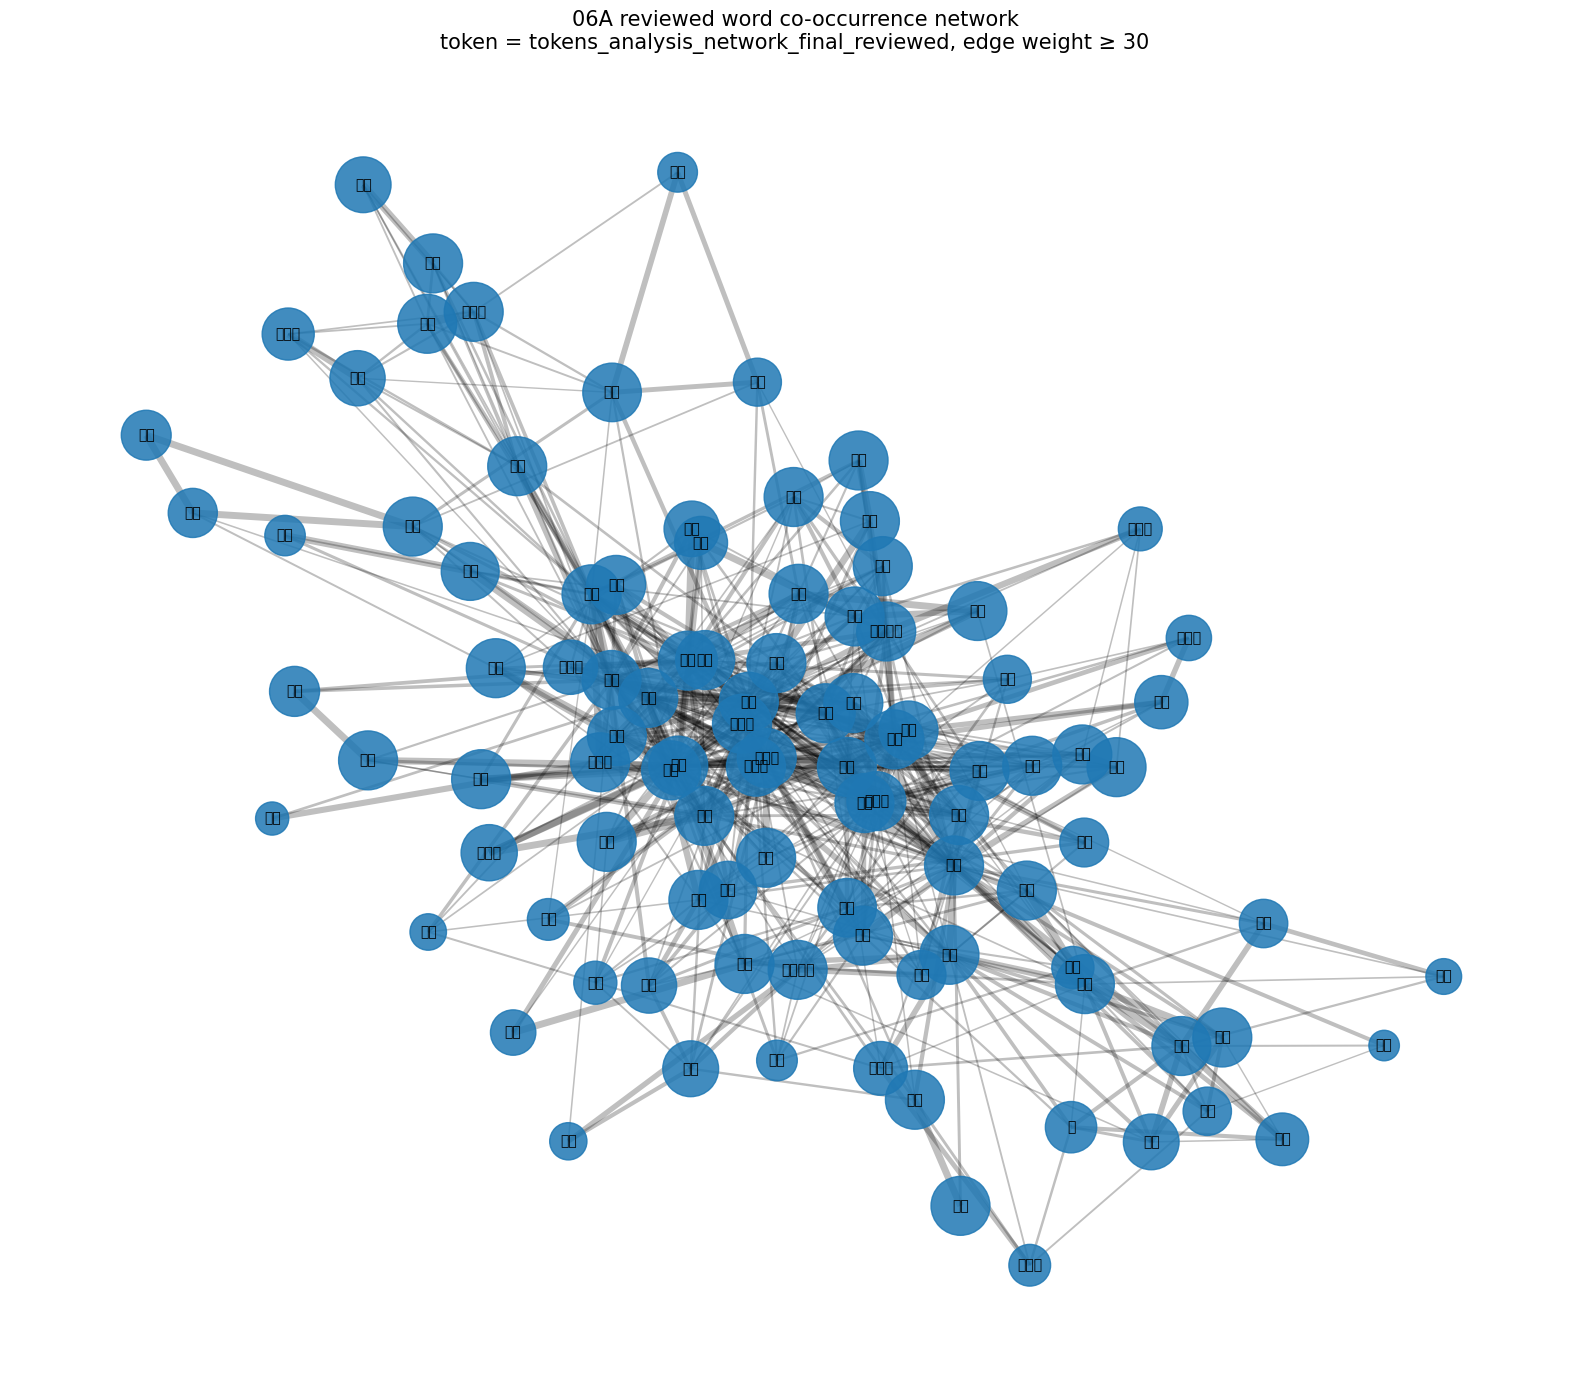


06A-APPEND-3 완료


In [9]:
# 06A-APPEND-3. 수동 제거 반영 네트워크 확인용 시각화
# 목적:
# - reviewed_edge_df, reviewed_node_df를 이용해 확인용 네트워크 그림을 그립니다.
# - 기존 06A 산출물은 덮어쓰지 않습니다.
#
# 저장 여부:
# - SAVE_OUTPUT = False : 화면 출력만
# - SAVE_OUTPUT = True  : PNG 저장

SAVE_OUTPUT = False   # 필요할 때만 True로 바꾸세요.

import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
import numpy as np

print("SAVE_OUTPUT:", SAVE_OUTPUT)

if "reviewed_edge_df" not in globals():
    raise NameError("reviewed_edge_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if "reviewed_node_df" not in globals():
    raise NameError("reviewed_node_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) 시각화 기준 설정
# ------------------------------------------------------------

VIS_MIN_EDGE_WEIGHT = 30
VIS_TOP_N_NODES = 100
VIS_FIGSIZE = (16, 14)
VIS_SEED = 42

print("VIS_MIN_EDGE_WEIGHT:", VIS_MIN_EDGE_WEIGHT)
print("VIS_TOP_N_NODES:", VIS_TOP_N_NODES)

# ------------------------------------------------------------
# 2) 시각화용 edge/node 구성
# ------------------------------------------------------------

vis_edge_df = reviewed_edge_df[
    reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT
].copy()

# 중심성 상위 노드만 사용
top_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_TOP_N_NODES)["word"]
)

vis_edge_df = vis_edge_df[
    vis_edge_df["source"].isin(top_nodes)
    & vis_edge_df["target"].isin(top_nodes)
].copy()

G_vis = nx.Graph()

for _, row in vis_edge_df.iterrows():
    G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

# 고립 노드 제외 후 확인
print("\n[시각화용 graph]")
print("node 수:", G_vis.number_of_nodes())
print("edge 수:", G_vis.number_of_edges())

if G_vis.number_of_nodes() == 0:
    raise ValueError(
        "시각화할 노드가 없습니다. VIS_MIN_EDGE_WEIGHT를 낮추거나 VIS_TOP_N_NODES를 늘려보세요."
    )

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

try:
    import matplotlib.font_manager as fm
    font_path = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

    if font_path.exists():
        fm.fontManager.addfont(str(font_path))
        plt.rcParams["font.family"] = "NanumGothic"
        plt.rcParams["axes.unicode_minus"] = False
    else:
        print("NanumGothic.ttf가 없어 기본 폰트로 출력합니다.")
except Exception as e:
    print("폰트 설정 중 경고:", e)

# ------------------------------------------------------------
# 4) 레이아웃 및 크기 설정
# ------------------------------------------------------------

pos = nx.spring_layout(
    G_vis,
    seed=VIS_SEED,
    weight="weight",
    k=1 / np.sqrt(max(G_vis.number_of_nodes(), 1))
)

weighted_degree_vis = dict(G_vis.degree(weight="weight"))

node_sizes = [
    max(80, min(weighted_degree_vis.get(node, 1) * 3, 1800))
    for node in G_vis.nodes()
]

edge_weights = [G_vis[u][v]["weight"] for u, v in G_vis.edges()]
edge_widths = [
    max(0.5, min(w / 30, 5))
    for w in edge_weights
]

# ------------------------------------------------------------
# 5) 그림 생성
# ------------------------------------------------------------

plt.figure(figsize=VIS_FIGSIZE)

nx.draw_networkx_edges(
    G_vis,
    pos,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    alpha=0.85
)

nx.draw_networkx_labels(
    G_vis,
    pos,
    font_size=10
)

plt.title(
    "06A reviewed word co-occurrence network\n"
    f"token = tokens_analysis_network_final_reviewed, edge weight ≥ {VIS_MIN_EDGE_WEIGHT}",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png = FIGURE_REVIEW_DIR / f"06A_reviewed_network_preview_{RUN_VERSION}_{RUN_TS}.png"
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    print("\n[PNG 저장 완료]")
    print(out_png)

plt.show()

print("\n06A-APPEND-3 완료")

SAVE_OUTPUT: False
INSTALL_KOREAN_FONT: True

[시각화 기준]
VIS_MIN_EDGE_WEIGHT: 80
VIS_TOP_N_NODES: 55
VIS_LABEL_TOP_N: 35
한글 폰트 설정 완료: NanumGothic

[시각화용 graph]
node 수: 52
edge 수: 154


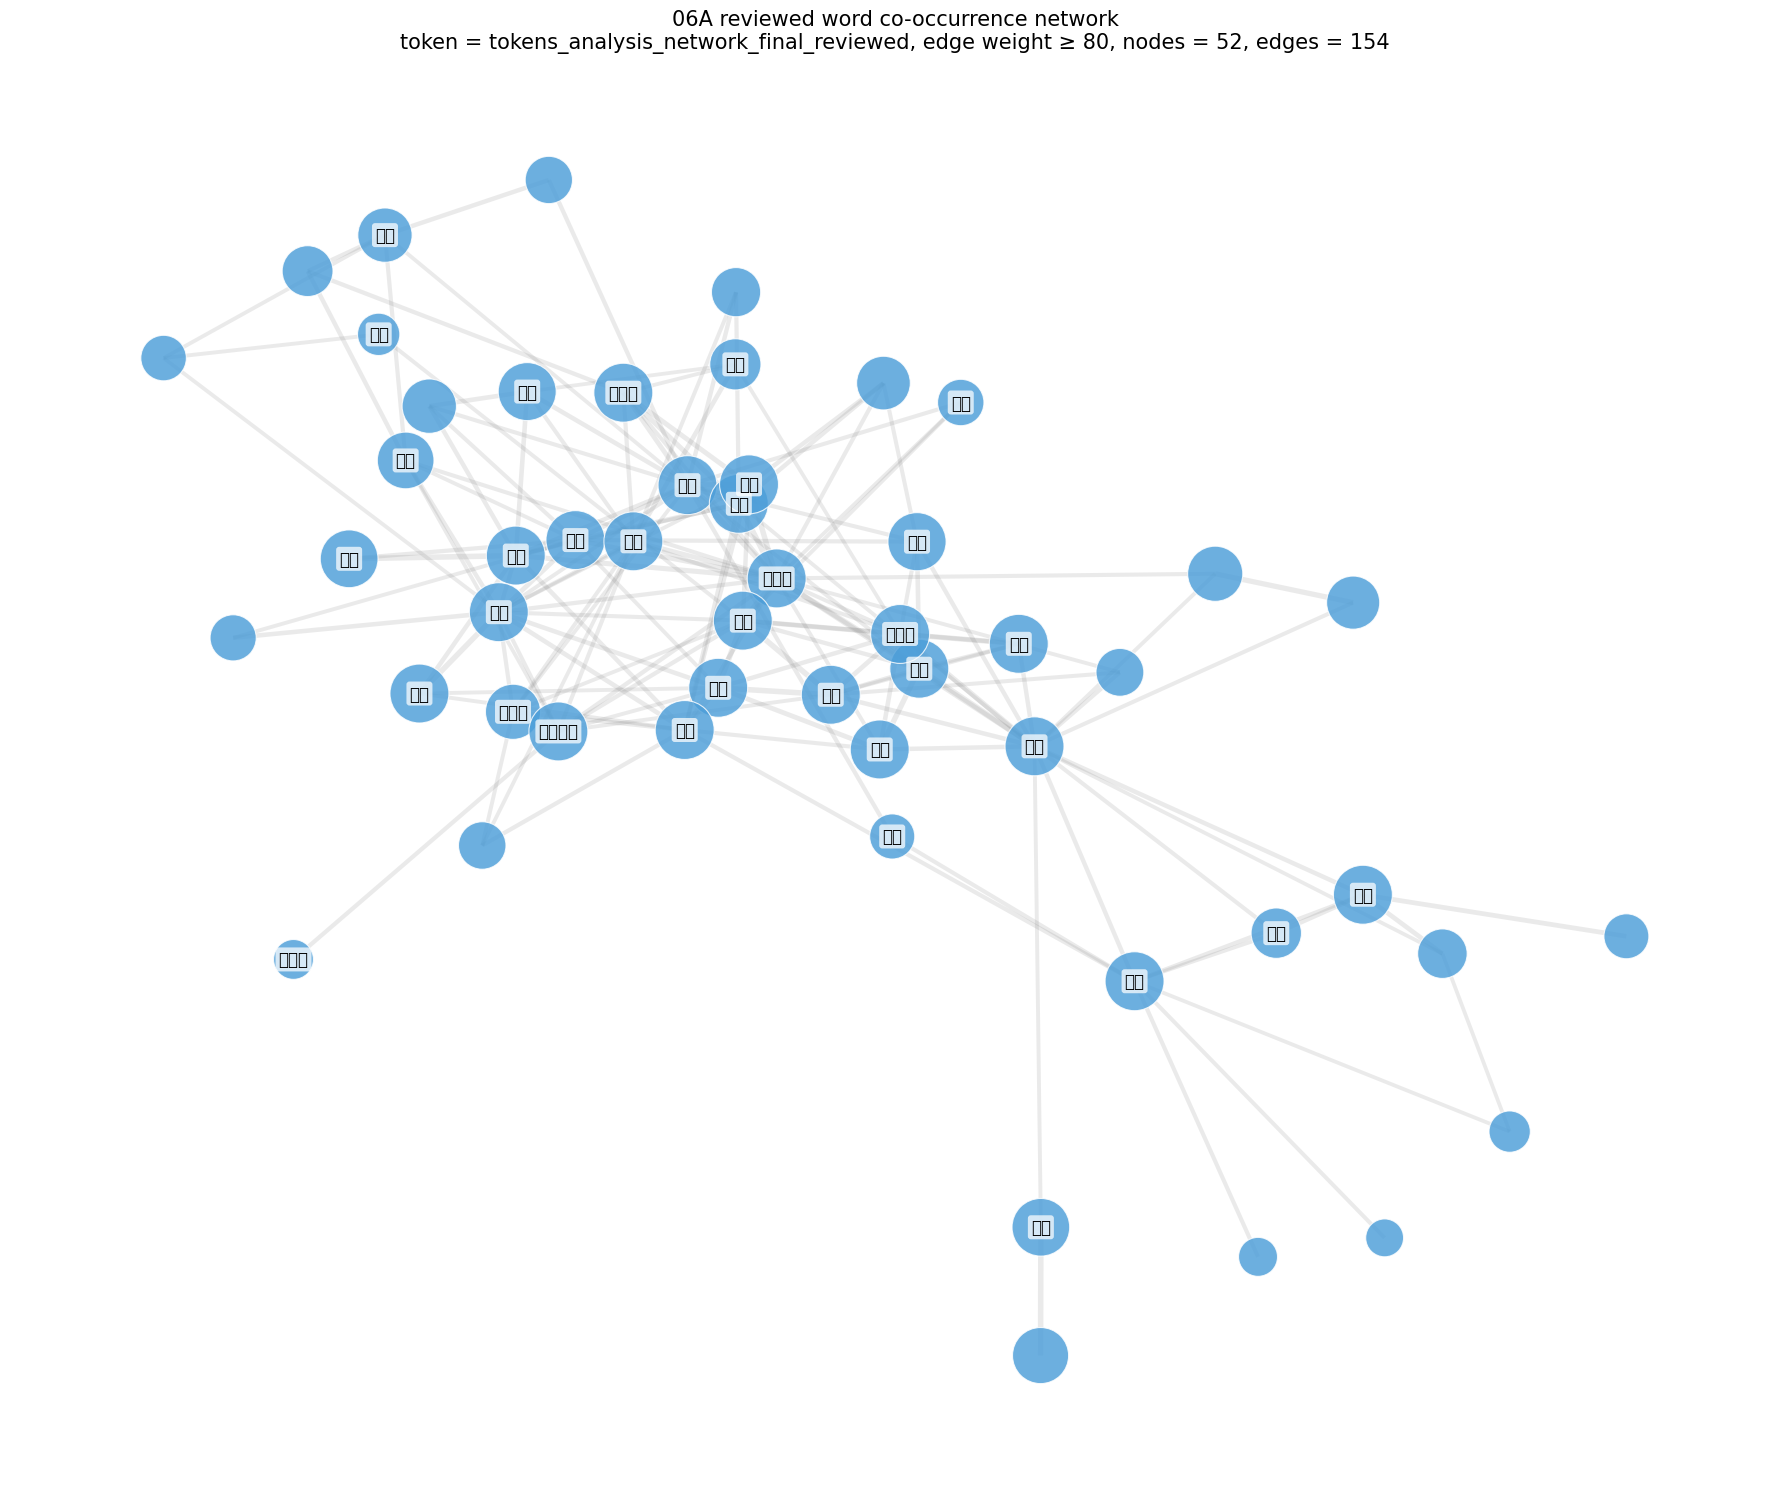


[표시 라벨 수] 35
표시 라벨: ['대회', '체육', '생활', '장애인', '센터', '지역', '아동', '공동', '단체', '보훈', '복지', '시설', '문화', '예술', '사회', '종사자', '수당', '지도자', '행사', '교육', '시범', '생산', '역량', '활동', '여성', '노인', '마을', '체험', '환경', '청소년', '프로그램', '농업', '경로당', '가족', '주민']

06A-APPEND-3-FIX 완료


In [11]:
# 06A-APPEND-3-FIX. 수동 제거 반영 네트워크 가시성 개선 시각화
# 목적:
# - 기존 06A-APPEND-3의 가시성을 개선합니다.
# - 노드 수와 엣지 수를 줄이고, 중심 노드 중심으로 라벨을 표시합니다.
# - 한글 폰트가 없으면 Colab에 Nanum 폰트를 설치한 뒤 다시 설정합니다.
#
# 저장 여부:
# - SAVE_OUTPUT = False : 화면 출력만
# - SAVE_OUTPUT = True  : PNG 저장

SAVE_OUTPUT = False   # 저장하려면 True로 변경
INSTALL_KOREAN_FONT = True  # 한글 라벨이 깨지면 True 유지

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
from pathlib import Path
import subprocess
import os

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

if "reviewed_edge_df" not in globals():
    raise NameError("reviewed_edge_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if "reviewed_node_df" not in globals():
    raise NameError("reviewed_node_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) 시각화 기준 설정
# ------------------------------------------------------------
# 기존: edge weight >= 30, top 100 nodes
# 개선: edge weight 기준을 높이고, 중심 노드 수를 줄임

VIS_MIN_EDGE_WEIGHT = 80
VIS_TOP_N_NODES = 55
VIS_LABEL_TOP_N = 35
VIS_FIGSIZE = (18, 15)
VIS_SEED = 42

print("\n[시각화 기준]")
print("VIS_MIN_EDGE_WEIGHT:", VIS_MIN_EDGE_WEIGHT)
print("VIS_TOP_N_NODES:", VIS_TOP_N_NODES)
print("VIS_LABEL_TOP_N:", VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 2) 한글 폰트 설정
# ------------------------------------------------------------

def setup_korean_font(install_font=True):
    """
    Colab에서 한글 폰트가 없을 때 Nanum 폰트를 설치하고 설정합니다.
    """
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            fm.fontManager.addfont(fp)
            font_name = fm.FontProperties(fname=fp).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            print("한글 폰트 설정 완료:", font_name)
            return font_name

    if install_font:
        print("한글 폰트가 없어 fonts-nanum을 설치합니다. 1분 정도 걸릴 수 있습니다.")
        try:
            subprocess.run(
                ["apt-get", "-qq", "update"],
                check=False
            )
            subprocess.run(
                ["apt-get", "-qq", "install", "-y", "fonts-nanum"],
                check=False
            )

            # matplotlib font cache 갱신
            fm.fontManager = fm.FontManager()

            for fp in candidate_paths:
                if Path(fp).exists():
                    fm.fontManager.addfont(fp)
                    font_name = fm.FontProperties(fname=fp).get_name()
                    plt.rcParams["font.family"] = font_name
                    plt.rcParams["axes.unicode_minus"] = False
                    print("한글 폰트 설치 및 설정 완료:", font_name)
                    return font_name

        except Exception as e:
            print("폰트 설치 중 경고:", e)

    print("한글 폰트 설정 실패: 기본 폰트로 출력됩니다.")
    return None

font_name = setup_korean_font(INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 3) 시각화용 노드 선정
# ------------------------------------------------------------

# 중심성 상위 노드 우선
top_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_TOP_N_NODES)["word"]
)

label_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_LABEL_TOP_N)["word"]
)

# edge weight 기준 + top node 기준 적용
vis_edge_df = reviewed_edge_df[
    (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
    & reviewed_edge_df["source"].isin(top_nodes)
    & reviewed_edge_df["target"].isin(top_nodes)
].copy()

# 너무 적게 남으면 edge 기준을 자동 완화
if len(vis_edge_df) < 30:
    print("\n주의: edge가 너무 적어 기준을 60으로 완화합니다.")
    VIS_MIN_EDGE_WEIGHT = 60

    vis_edge_df = reviewed_edge_df[
        (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
        & reviewed_edge_df["source"].isin(top_nodes)
        & reviewed_edge_df["target"].isin(top_nodes)
    ].copy()

# ------------------------------------------------------------
# 4) graph 생성
# ------------------------------------------------------------

G_vis = nx.Graph()

for _, row in vis_edge_df.iterrows():
    G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

# 고립 노드는 시각화에서 제외
G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

print("\n[시각화용 graph]")
print("node 수:", G_vis.number_of_nodes())
print("edge 수:", G_vis.number_of_edges())

if G_vis.number_of_nodes() == 0:
    raise ValueError(
        "시각화할 노드가 없습니다. VIS_MIN_EDGE_WEIGHT를 낮추거나 VIS_TOP_N_NODES를 늘려보세요."
    )

# ------------------------------------------------------------
# 5) 레이아웃 계산
# ------------------------------------------------------------

# k를 키워서 노드 간 간격 확대
pos = nx.spring_layout(
    G_vis,
    seed=VIS_SEED,
    weight="weight",
    k=1.15 / np.sqrt(max(G_vis.number_of_nodes(), 1)),
    iterations=250
)

weighted_degree_vis = dict(G_vis.degree(weight="weight"))

# node 크기: 과도한 차이를 줄이기 위해 sqrt 스케일
node_sizes = []
for node in G_vis.nodes():
    wd = weighted_degree_vis.get(node, 1)
    size = 180 + np.sqrt(wd) * 55
    size = max(220, min(size, 1800))
    node_sizes.append(size)

# edge 두께: 너무 두껍지 않게 log 스케일
edge_weights = [G_vis[u][v]["weight"] for u, v in G_vis.edges()]
edge_widths = [
    max(0.4, min(np.log1p(w) / 1.6, 4.0))
    for w in edge_weights
]

# ------------------------------------------------------------
# 6) 그림 생성
# ------------------------------------------------------------

plt.figure(figsize=VIS_FIGSIZE)

nx.draw_networkx_edges(
    G_vis,
    pos,
    width=edge_widths,
    alpha=0.16,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    alpha=0.82,
    node_color="#4C9ED9",
    edgecolors="white",
    linewidths=0.8
)

# 상위 라벨만 표시
labels = {
    node: node
    for node in G_vis.nodes()
    if node in label_nodes
}

nx.draw_networkx_labels(
    G_vis,
    pos,
    labels=labels,
    font_size=12,
    font_family=plt.rcParams["font.family"],
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        alpha=0.72,
        boxstyle="round,pad=0.18"
    )
)

plt.title(
    "06A reviewed word co-occurrence network\n"
    f"token = tokens_analysis_network_final_reviewed, "
    f"edge weight ≥ {VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {G_vis.number_of_nodes()}, edges = {G_vis.number_of_edges()}",
    fontsize=15
)

plt.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png = FIGURE_REVIEW_DIR / f"06A_reviewed_network_preview_fix_{RUN_VERSION}_{RUN_TS}.png"
    plt.savefig(out_png, dpi=240, bbox_inches="tight")
    print("\n[PNG 저장 완료]")
    print(out_png)

plt.show()

print("\n[표시 라벨 수]", len(labels))
print("표시 라벨:", list(labels.values()))

print("\n06A-APPEND-3-FIX 완료")

SAVE_OUTPUT: False
INSTALL_KOREAN_FONT: True

[시각화 기준]
VIS_MIN_EDGE_WEIGHT: 80
VIS_TOP_N_NODES: 55
VIS_LABEL_TOP_N: 35

[한글 폰트 경로]
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
적용 폰트명: NanumGothic


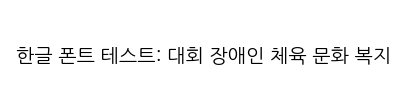

위 테스트 문장이 한글로 보이면 폰트 설정 성공입니다.

[시각화용 graph]
node 수: 52
edge 수: 154


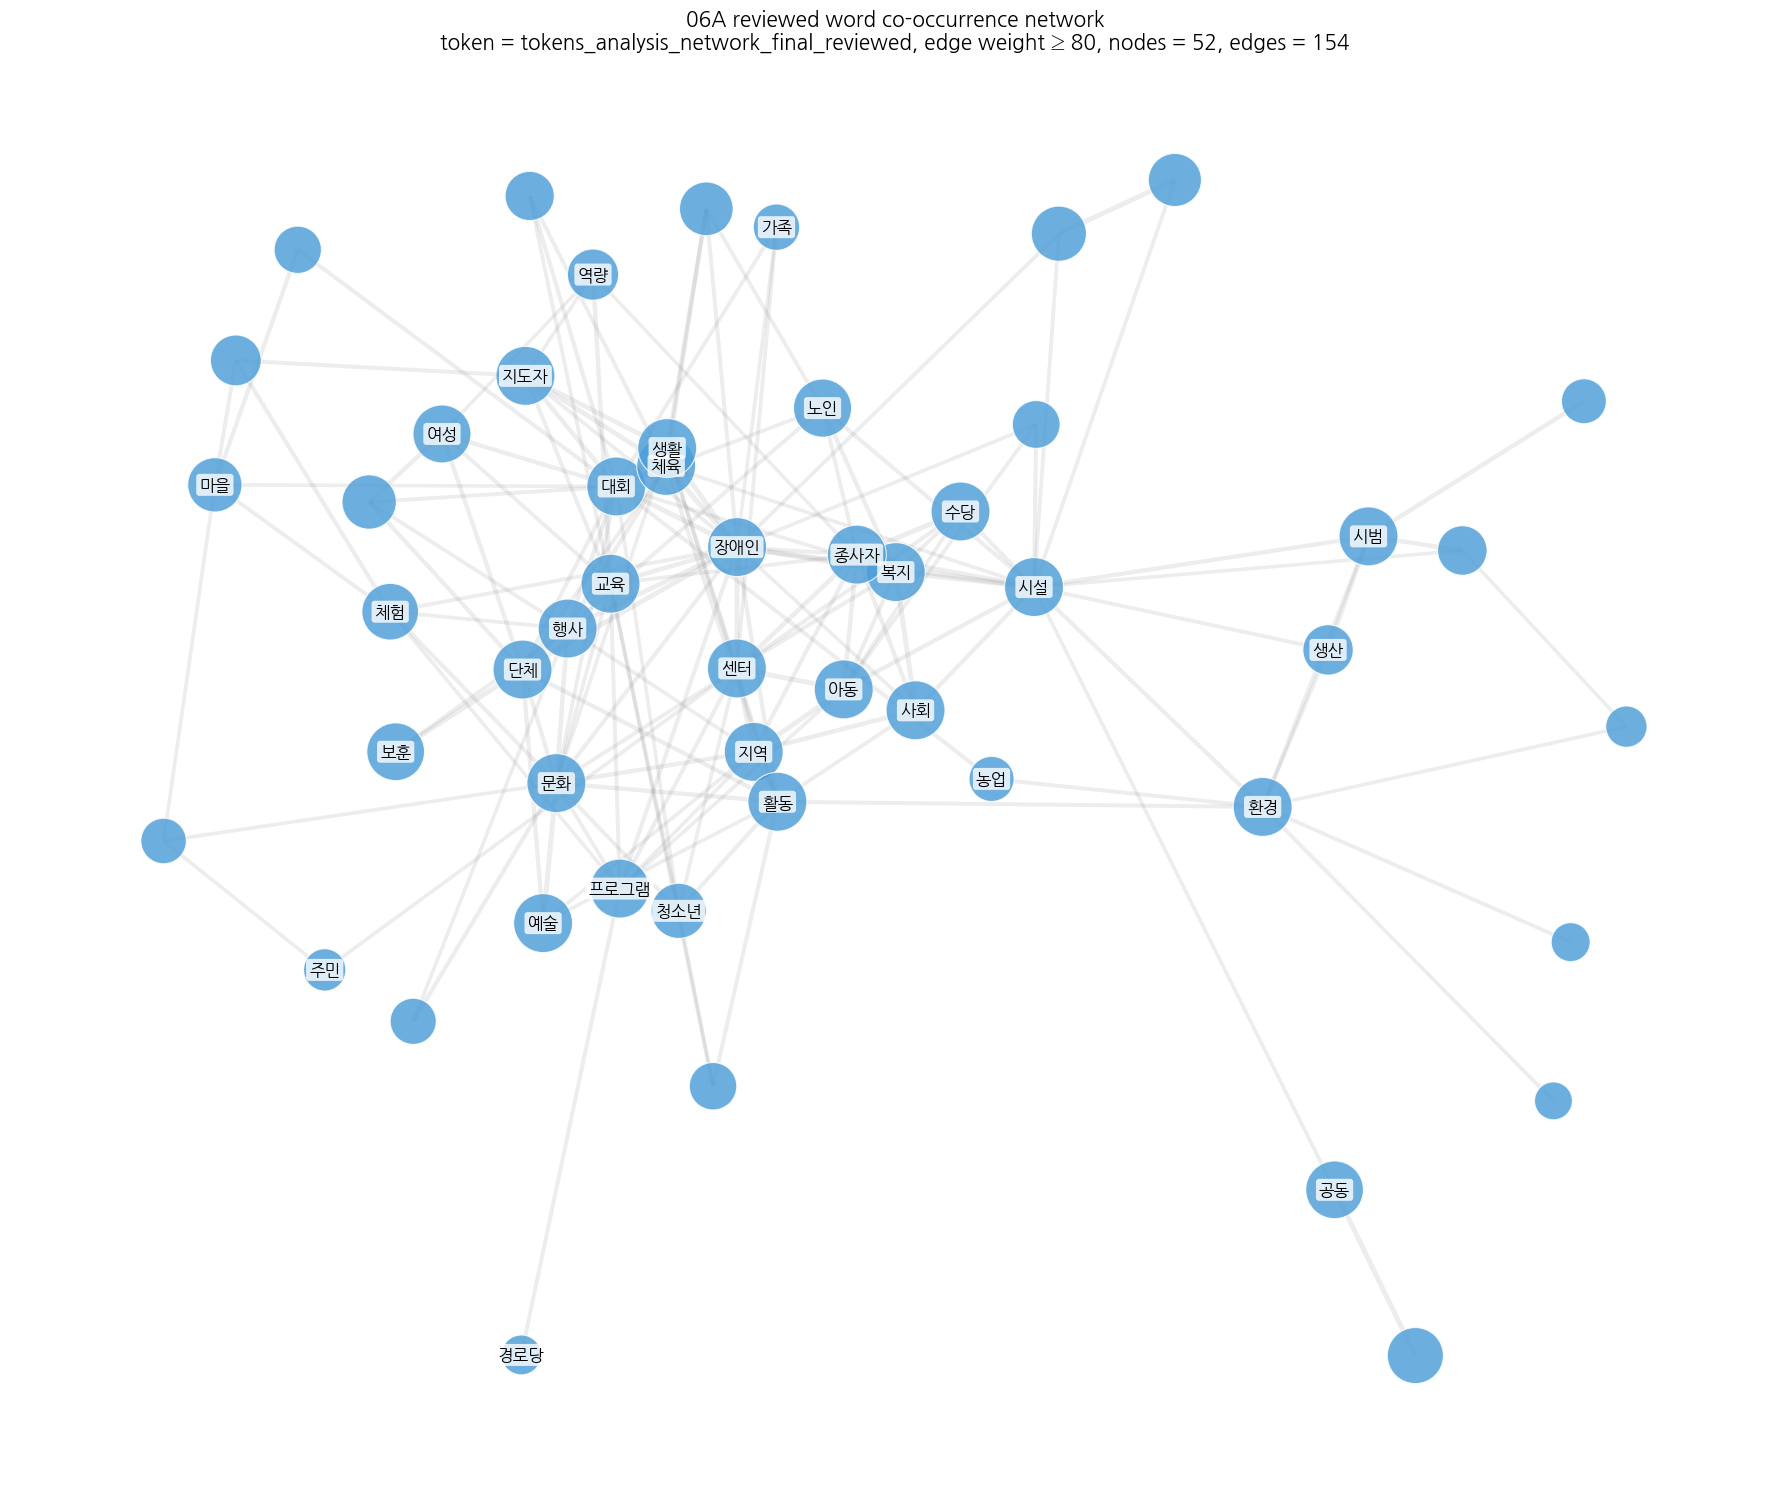


[표시 라벨 수] 35
표시 라벨: ['대회', '체육', '생활', '장애인', '센터', '지역', '아동', '공동', '단체', '보훈', '복지', '시설', '문화', '예술', '사회', '종사자', '수당', '지도자', '행사', '교육', '시범', '생산', '역량', '활동', '여성', '노인', '마을', '체험', '환경', '청소년', '프로그램', '농업', '경로당', '가족', '주민']

06A-APPEND-3-FONTFIX 완료


In [12]:
# 06A-APPEND-3-FONTFIX. 한글 폰트 강제 적용 + 가시성 개선 시각화
# 목적:
# - 한글 라벨 깨짐 문제를 해결합니다.
# - networkx 기본 label 함수 대신 matplotlib ax.text로 직접 라벨을 그립니다.
# - 기존 APPEND-1, APPEND-2 결과인 reviewed_edge_df, reviewed_node_df를 그대로 사용합니다.
#
# 저장 여부:
# - SAVE_OUTPUT = False : 화면 출력만
# - SAVE_OUTPUT = True  : PNG 저장

SAVE_OUTPUT = False   # 저장하려면 True로 변경
INSTALL_KOREAN_FONT = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
from pathlib import Path
import subprocess
import os
import shutil

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

if "reviewed_edge_df" not in globals():
    raise NameError("reviewed_edge_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if "reviewed_node_df" not in globals():
    raise NameError("reviewed_node_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) 시각화 기준 설정
# ------------------------------------------------------------

VIS_MIN_EDGE_WEIGHT = 80
VIS_TOP_N_NODES = 55
VIS_LABEL_TOP_N = 35
VIS_FIGSIZE = (18, 15)
VIS_SEED = 42

print("\n[시각화 기준]")
print("VIS_MIN_EDGE_WEIGHT:", VIS_MIN_EDGE_WEIGHT)
print("VIS_TOP_N_NODES:", VIS_TOP_N_NODES)
print("VIS_LABEL_TOP_N:", VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 2) 한글 폰트 강제 설치 및 경로 탐색
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    # 전체 fonts 폴더에서 한글 후보 검색
    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    print("설치에는 1분 정도 걸릴 수 있습니다.")

    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    # matplotlib font cache 삭제
    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    # font manager 재생성
    fm.fontManager = fm.FontManager()

    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError(
        "한글 폰트를 찾지 못했습니다. Colab 런타임에서 fonts-nanum 설치가 실패했을 수 있습니다."
    )

print("\n[한글 폰트 경로]")
print(font_path)

# FontProperties를 명시적으로 사용
font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용 폰트명:", font_name)

# ------------------------------------------------------------
# 3) 한글 폰트 테스트
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(5, 1.2))
ax.text(
    0.5,
    0.5,
    "한글 폰트 테스트: 대회 장애인 체육 문화 복지",
    ha="center",
    va="center",
    fontproperties=fm.FontProperties(fname=str(font_path), size=14)
)
ax.axis("off")
plt.show()

print("위 테스트 문장이 한글로 보이면 폰트 설정 성공입니다.")

# ------------------------------------------------------------
# 4) 시각화용 노드/엣지 선정
# ------------------------------------------------------------

top_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_TOP_N_NODES)["word"]
)

label_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_LABEL_TOP_N)["word"]
)

vis_edge_df = reviewed_edge_df[
    (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
    & reviewed_edge_df["source"].isin(top_nodes)
    & reviewed_edge_df["target"].isin(top_nodes)
].copy()

if len(vis_edge_df) < 30:
    print("\n주의: edge가 너무 적어 기준을 60으로 완화합니다.")
    VIS_MIN_EDGE_WEIGHT = 60

    vis_edge_df = reviewed_edge_df[
        (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
        & reviewed_edge_df["source"].isin(top_nodes)
        & reviewed_edge_df["target"].isin(top_nodes)
    ].copy()

G_vis = nx.Graph()

for _, row in vis_edge_df.iterrows():
    G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

print("\n[시각화용 graph]")
print("node 수:", G_vis.number_of_nodes())
print("edge 수:", G_vis.number_of_edges())

if G_vis.number_of_nodes() == 0:
    raise ValueError(
        "시각화할 노드가 없습니다. VIS_MIN_EDGE_WEIGHT를 낮추거나 VIS_TOP_N_NODES를 늘려보세요."
    )

# ------------------------------------------------------------
# 5) 레이아웃 계산
# ------------------------------------------------------------

pos = nx.spring_layout(
    G_vis,
    seed=VIS_SEED,
    weight="weight",
    k=1.25 / np.sqrt(max(G_vis.number_of_nodes(), 1)),
    iterations=300
)

weighted_degree_vis = dict(G_vis.degree(weight="weight"))

node_sizes = []
for node in G_vis.nodes():
    wd = weighted_degree_vis.get(node, 1)
    size = 180 + np.sqrt(wd) * 55
    size = max(220, min(size, 1800))
    node_sizes.append(size)

edge_weights = [G_vis[u][v]["weight"] for u, v in G_vis.edges()]
edge_widths = [
    max(0.4, min(np.log1p(w) / 1.7, 3.6))
    for w in edge_weights
]

# ------------------------------------------------------------
# 6) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=VIS_FIGSIZE)

nx.draw_networkx_edges(
    G_vis,
    pos,
    width=edge_widths,
    alpha=0.14,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    alpha=0.82,
    node_color="#4C9ED9",
    edgecolors="white",
    linewidths=0.8,
    ax=ax
)

# ------------------------------------------------------------
# 7) 한글 라벨 직접 그리기
# ------------------------------------------------------------
# nx.draw_networkx_labels 대신 ax.text를 사용합니다.
# 이 방식이 Colab 한글 깨짐 문제를 가장 안정적으로 피합니다.

label_font_prop = fm.FontProperties(fname=str(font_path), size=12)
title_font_prop = fm.FontProperties(fname=str(font_path), size=15)

labels = {
    node: node
    for node in G_vis.nodes()
    if node in label_nodes
}

for node, label in labels.items():
    x, y = pos[node]
    ax.text(
        x,
        y,
        label,
        fontsize=12,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.18"
        ),
        zorder=10
    )

ax.set_title(
    "06A reviewed word co-occurrence network\n"
    f"token = tokens_analysis_network_final_reviewed, "
    f"edge weight ≥ {VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {G_vis.number_of_nodes()}, edges = {G_vis.number_of_edges()}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png = FIGURE_REVIEW_DIR / f"06A_reviewed_network_preview_fontfix_{RUN_VERSION}_{RUN_TS}.png"
    plt.savefig(out_png, dpi=240, bbox_inches="tight")
    print("\n[PNG 저장 완료]")
    print(out_png)

plt.show()

print("\n[표시 라벨 수]", len(labels))
print("표시 라벨:", list(labels.values()))

print("\n06A-APPEND-3-FONTFIX 완료")

SAVE_OUTPUT: True
SHOW_ALL_LABELS: True
INSTALL_KOREAN_FONT: True

[시각화 기준]
VIS_MIN_EDGE_WEIGHT: 80
VIS_TOP_N_NODES: 55
VIS_LABEL_TOP_N: 35

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 reviewed_G 기준 커뮤니티 탐지 결과]
reviewed_G node 수: 540
reviewed_G edge 수: 30634
community 수: 10

[community별 대표 단어]


,community_id,node_count,top_words
0,0,126,"환경, 시범, 생산, 농업, 기술, 농가, 농산물, 재배, 기반, 청년, 단지, 품..."
1,1,99,"문화, 활동, 청소년, 예술, 예방, 안전, 시민, 축제, 시장, 봉사, 학교, 전..."
2,2,89,"시설, 센터, 지역, 복지, 종사자, 아동, 사회, 노인, 수당, 가족, 어린이집,..."
3,3,79,"대회, 장애인, 체육, 생활, 지도자, 교실, 재활, 종목, 어르신, 시각, 증진,..."
4,4,64,"행사, 단체, 여성, 보훈, 농업인, 군경, 안보, 유공자, 견학, 순례, 참전, ..."
5,5,57,"교육, 마을, 프로그램, 체험, 주민, 역량, 경로당, 공모, 운동, 농촌, 워크숍..."
6,6,12,"통일, 평화, 민주, 연수, 자문, 회의, 위원, 근로자, 민주평통, 외국인, 노동..."
7,7,8,"공동, 주택, 유지, 노후, 전기, 비용, 지원금, 요금"
8,8,4,"발전, 지속, 가능, 포럼"
9,9,2,"의용, 소방대"



[시각화용 graph]
node 수: 52
edge 수: 154

[시각화 포함 노드 community_id]


,word,community_id,doc_freq_unique,weighted_degree_in_vis
0,시범,0,1477,1041.0
1,환경,0,2004,967.0
2,생산,0,977,426.0
3,재배,0,637,393.0
4,농업,0,941,253.0
5,기술,0,630,248.0
6,농가,0,944,164.0
7,농산물,0,794,122.0
8,문화,1,2613,2574.0
9,활동,1,2292,1537.0



시각화에 포함된 community 수: 7

[라벨 표시]
표시 라벨 수: 52


/tmp/ipykernel_4193/2830012896.py:282: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(community_count_full, 1))



[저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_reviewed_network_preview_final_v2_v1_20260611_0743.png
- full community summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_reviewed_community_full_v1_20260611_0743.csv
- vis node community: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_reviewed_vis_node_community_v1_20260611_0743.csv


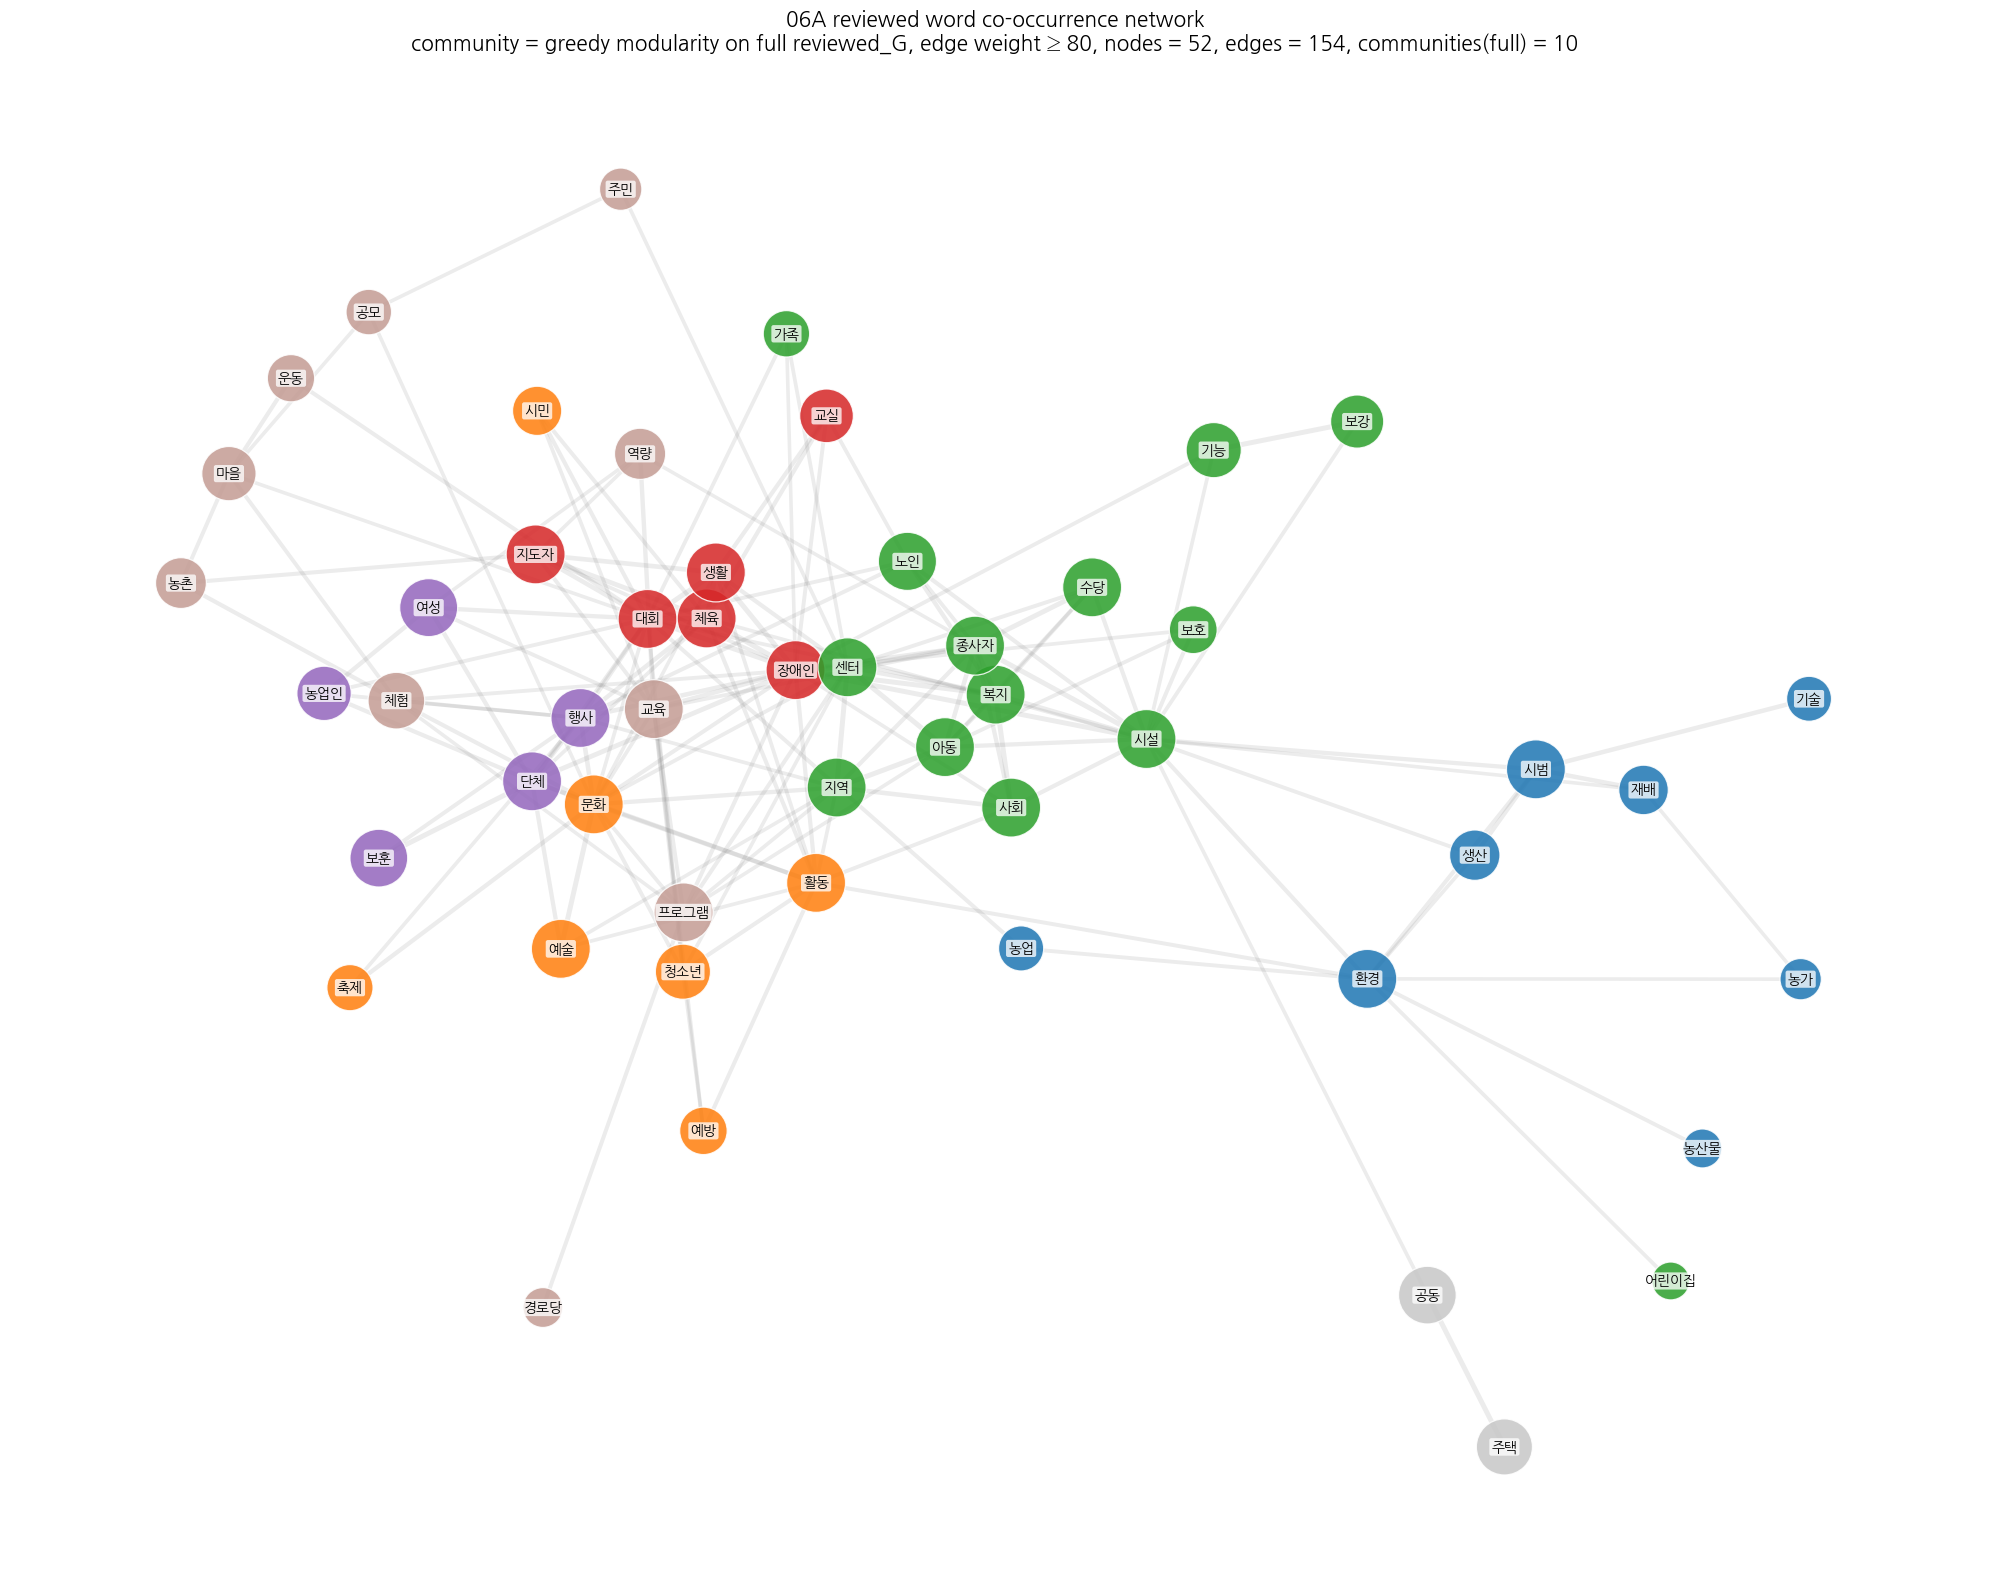


06A-APPEND-3-FINAL-V2 완료


In [14]:
# 06A-APPEND-3-FINAL-V2. 전체 reviewed_G 기준 community_id 색상 적용 시각화
# 목적:
# - reviewed_G 전체 네트워크에 greedy modularity community detection을 적용합니다.
# - 각 단어에 부여된 community_id를 색상 기준으로 사용합니다.
# - 시각화용 그래프 G_vis는 일부 노드/엣지만 필터링하지만,
#   색상은 전체 reviewed_G에서 계산한 community_id를 따릅니다.
# - 한글 폰트 강제 적용
# - 전체 노드 라벨 또는 중심 노드 라벨 선택 가능
#
# 저장 여부:
# - SAVE_OUTPUT = False : 화면 출력만
# - SAVE_OUTPUT = True  : PNG 및 community table 저장

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

# 전체 노드 라벨 표시 여부
SHOW_ALL_LABELS = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
import subprocess
import shutil

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "reviewed_edge_df" not in globals():
    raise NameError("reviewed_edge_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if "reviewed_node_df" not in globals():
    raise NameError("reviewed_node_df가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if "reviewed_G" not in globals():
    raise NameError("reviewed_G가 없습니다. 06A-APPEND-2를 먼저 실행하세요.")

if reviewed_G.number_of_nodes() == 0:
    raise ValueError("reviewed_G에 노드가 없습니다. 06A-APPEND-2 결과를 확인하세요.")

if reviewed_G.number_of_edges() == 0:
    raise ValueError("reviewed_G에 엣지가 없습니다. 06A-APPEND-2 결과를 확인하세요.")

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1) 시각화 기준 설정
# ------------------------------------------------------------

VIS_MIN_EDGE_WEIGHT = 80
VIS_TOP_N_NODES = 55

# SHOW_ALL_LABELS = False일 때만 적용
VIS_LABEL_TOP_N = 35

VIS_FIGSIZE = (20, 16)
VIS_SEED = 42

print("\n[시각화 기준]")
print("VIS_MIN_EDGE_WEIGHT:", VIS_MIN_EDGE_WEIGHT)
print("VIS_TOP_N_NODES:", VIS_TOP_N_NODES)
print("VIS_LABEL_TOP_N:", VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 2) 한글 폰트 강제 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 3) 전체 reviewed_G 기준 greedy modularity community detection
# ------------------------------------------------------------
# 중요:
# - community_id는 시각화용 부분 그래프가 아니라 전체 reviewed_G 기준으로 계산합니다.
# - 이후 G_vis에 포함되는 노드는 이 community_id를 색상 기준으로 사용합니다.

communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        reviewed_G,
        weight="weight"
    )
)

node_to_community_full = {}

for community_id, community_nodes in enumerate(communities_full):
    for node in community_nodes:
        node_to_community_full[node] = community_id

reviewed_node_df = reviewed_node_df.copy()

reviewed_node_df["community_id"] = reviewed_node_df["word"].map(
    node_to_community_full
)

# 혹시 community_id가 없는 노드가 있으면 -1 처리
reviewed_node_df["community_id"] = reviewed_node_df["community_id"].fillna(-1).astype(int)

community_count_full = len(communities_full)

print("\n[전체 reviewed_G 기준 커뮤니티 탐지 결과]")
print("reviewed_G node 수:", reviewed_G.number_of_nodes())
print("reviewed_G edge 수:", reviewed_G.number_of_edges())
print("community 수:", community_count_full)

community_full_summary_rows = []

for community_id, community_nodes in enumerate(communities_full):
    community_nodes = list(community_nodes)

    sub_df = reviewed_node_df[
        reviewed_node_df["word"].isin(community_nodes)
    ].copy()

    sub_df = sub_df.sort_values(
        ["weighted_degree", "doc_freq_unique"],
        ascending=[False, False]
    )

    top_words = sub_df["word"].head(20).tolist()

    community_full_summary_rows.append({
        "community_id": community_id,
        "node_count": len(community_nodes),
        "top_words": ", ".join(top_words)
    })

community_full_summary_df = pd.DataFrame(community_full_summary_rows)

print("\n[community별 대표 단어]")
display(community_full_summary_df)

# ------------------------------------------------------------
# 4) 시각화용 노드/엣지 선정
# ------------------------------------------------------------

top_nodes = set(
    reviewed_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(VIS_TOP_N_NODES)["word"]
)

vis_edge_df = reviewed_edge_df[
    (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
    & reviewed_edge_df["source"].isin(top_nodes)
    & reviewed_edge_df["target"].isin(top_nodes)
].copy()

if len(vis_edge_df) < 30:
    print("\n주의: edge가 너무 적어 기준을 60으로 완화합니다.")
    VIS_MIN_EDGE_WEIGHT = 60

    vis_edge_df = reviewed_edge_df[
        (reviewed_edge_df["weight"] >= VIS_MIN_EDGE_WEIGHT)
        & reviewed_edge_df["source"].isin(top_nodes)
        & reviewed_edge_df["target"].isin(top_nodes)
    ].copy()

G_vis = nx.Graph()

for _, row in vis_edge_df.iterrows():
    G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

print("\n[시각화용 graph]")
print("node 수:", G_vis.number_of_nodes())
print("edge 수:", G_vis.number_of_edges())

if G_vis.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다.")

# ------------------------------------------------------------
# 5) 시각화에 포함된 노드의 community_id 확인
# ------------------------------------------------------------

vis_node_community_rows = []

for node in G_vis.nodes():
    vis_node_community_rows.append({
        "word": node,
        "community_id": node_to_community_full.get(node, -1),
        "doc_freq_unique": reviewed_G.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": G_vis.degree(node, weight="weight")
    })

vis_node_community_df = (
    pd.DataFrame(vis_node_community_rows)
    .sort_values(["community_id", "weighted_degree_in_vis"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n[시각화 포함 노드 community_id]")
display(vis_node_community_df)

vis_community_count = vis_node_community_df["community_id"].nunique()

print("\n시각화에 포함된 community 수:", vis_community_count)

# ------------------------------------------------------------
# 6) community_id 기반 색상 지정
# ------------------------------------------------------------

# 전체 community 수 기준으로 colormap 생성
cmap = plt.cm.get_cmap("tab20", max(community_count_full, 1))

node_colors = []

for node in G_vis.nodes():
    community_id = node_to_community_full.get(node, -1)

    if community_id == -1:
        node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 7) 레이아웃 계산
# ------------------------------------------------------------

pos = nx.spring_layout(
    G_vis,
    seed=VIS_SEED,
    weight="weight",
    k=1.35 / np.sqrt(max(G_vis.number_of_nodes(), 1)),
    iterations=400
)

weighted_degree_vis = dict(G_vis.degree(weight="weight"))

node_sizes = []

for node in G_vis.nodes():
    wd = weighted_degree_vis.get(node, 1)
    size = 180 + np.sqrt(wd) * 55
    size = max(220, min(size, 1800))
    node_sizes.append(size)

edge_weights = [G_vis[u][v]["weight"] for u, v in G_vis.edges()]

edge_widths = [
    max(0.4, min(np.log1p(w) / 1.7, 3.6))
    for w in edge_weights
]

# ------------------------------------------------------------
# 8) 라벨 표시 대상 설정
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    label_nodes = set(G_vis.nodes())
    LABEL_FONT_SIZE = 10
else:
    label_nodes = set(
        reviewed_node_df
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(VIS_LABEL_TOP_N)["word"]
    )
    LABEL_FONT_SIZE = 12

labels = {
    node: node
    for node in G_vis.nodes()
    if node in label_nodes
}

print("\n[라벨 표시]")
print("표시 라벨 수:", len(labels))

# ------------------------------------------------------------
# 9) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=VIS_FIGSIZE)

nx.draw_networkx_edges(
    G_vis,
    pos,
    width=edge_widths,
    alpha=0.15,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_size=node_sizes,
    alpha=0.86,
    node_color=node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LABEL_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=15)

for node, label in labels.items():
    x, y = pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LABEL_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.76,
            boxstyle="round,pad=0.15"
        ),
        zorder=10
    )

ax.set_title(
    "06A reviewed word co-occurrence network\n"
    f"community = greedy modularity on full reviewed_G, "
    f"edge weight ≥ {VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {G_vis.number_of_nodes()}, "
    f"edges = {G_vis.number_of_edges()}, "
    f"communities(full) = {community_count_full}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png = FIGURE_REVIEW_DIR / f"06A_reviewed_network_preview_final_v2_{RUN_VERSION}_{RUN_TS}.png"
    out_community_full = TABLE_REVIEW_DIR / f"06A_reviewed_community_full_{RUN_VERSION}_{RUN_TS}.csv"
    out_vis_node_community = TABLE_REVIEW_DIR / f"06A_reviewed_vis_node_community_{RUN_VERSION}_{RUN_TS}.csv"

    plt.savefig(out_png, dpi=260, bbox_inches="tight")
    community_full_summary_df.to_csv(out_community_full, index=False, encoding="utf-8-sig")
    vis_node_community_df.to_csv(out_vis_node_community, index=False, encoding="utf-8-sig")

    print("\n[저장 완료]")
    print("- PNG:", out_png)
    print("- full community summary:", out_community_full)
    print("- vis node community:", out_vis_node_community)

plt.show()

print("\n06A-APPEND-3-FINAL-V2 완료")

### 06A-APPEND-1C. manual_merge_decision 반영해 재결합 토큰열 생성

In [15]:
# 06A-APPEND-1C. manual_merge_decision 반영해 재결합 토큰열 생성
# 목적:
# - 03번 노트북에서 만든 인접 2-gram/3-gram 재결합 후보 검토표를 읽습니다.
# - manual_merge_decision 시트에서 수동판단=재결합 또는 처리방향=merge인 행만 사용합니다.
# - 현재 06A 시각화용 토큰열(tokens_analysis_network_final_reviewed)에 재결합 규칙을 임시 반영합니다.
#
# 주의:
# - 이 셀은 06A에서 확인용으로만 적용합니다.
# - 최종 확정 후에는 03 노트북에 같은 로직을 반영해서 parquet로 저장해야 합니다.

from pathlib import Path
import pandas as pd
import numpy as np
import ast
import re

# ------------------------------------------------------------
# 1) 재결합 판단 Excel 경로 설정
# ------------------------------------------------------------

MERGE_DECISION_XLSX_NAME = "03_token_adjacent_ngram_merge_review_v1_20260611_2021.xlsx"

MERGE_DECISION_XLSX_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "review"
    / MERGE_DECISION_XLSX_NAME
)

print("[재결합 판단 Excel]")
print(MERGE_DECISION_XLSX_PATH)
print("exists:", MERGE_DECISION_XLSX_PATH.exists())

# 기본 경로에 없으면 Drive에서 자동 검색
if not MERGE_DECISION_XLSX_PATH.exists():
    print("\n기본 경로에서 파일을 찾지 못했습니다. /content/drive 아래에서 자동 검색합니다.")

    matches = list(Path("/content/drive").rglob(MERGE_DECISION_XLSX_NAME))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{MERGE_DECISION_XLSX_NAME} 파일을 Drive에서 찾지 못했습니다. "
            "해당 Excel 파일을 Drive의 03_v1_사업명텍스트분석/tables/review 폴더에 업로드하세요."
        )

    MERGE_DECISION_XLSX_PATH = matches[0]
    print("자동 검색 성공:")
    print(MERGE_DECISION_XLSX_PATH)

# ------------------------------------------------------------
# 2) 현재 06A 토큰 데이터 확인
# ------------------------------------------------------------

if "df_03_review" not in globals():
    raise NameError(
        "df_03_review가 없습니다. 06A-APPEND-1 또는 현재 06A 입력 데이터 로드 셀을 먼저 실행하세요."
    )

if "tokens_analysis_network_final_reviewed" in df_03_review.columns:
    SOURCE_TOKEN_COL_FOR_MANUAL_MERGE = "tokens_analysis_network_final_reviewed"
elif "tokens_analysis_network_final" in df_03_review.columns:
    SOURCE_TOKEN_COL_FOR_MANUAL_MERGE = "tokens_analysis_network_final"
else:
    raise KeyError(
        "tokens_analysis_network_final_reviewed 또는 tokens_analysis_network_final 열이 없습니다."
    )

TARGET_TOKEN_COL_FOR_MANUAL_MERGE = "tokens_analysis_network_final_reviewed_merged"

print("\n[재결합 적용 기준 토큰열]")
print("SOURCE_TOKEN_COL_FOR_MANUAL_MERGE:", SOURCE_TOKEN_COL_FOR_MANUAL_MERGE)
print("TARGET_TOKEN_COL_FOR_MANUAL_MERGE:", TARGET_TOKEN_COL_FOR_MANUAL_MERGE)

# ------------------------------------------------------------
# 3) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

def ensure_token_list_local(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip() != ""]

    if isinstance(x, tuple):
        return [str(t).strip() for t in list(x) if str(t).strip() != ""]

    if isinstance(x, np.ndarray):
        return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

    if x is None:
        return []

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, str):
        x_strip = x.strip()

        if x_strip == "":
            return []

        try:
            parsed = ast.literal_eval(x_strip)

            if isinstance(parsed, list):
                return [str(t).strip() for t in parsed if str(t).strip() != ""]

            if isinstance(parsed, tuple):
                return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]

        except Exception:
            pass

        return [x_strip]

    return [str(x).strip()] if str(x).strip() != "" else []

df_03_review[SOURCE_TOKEN_COL_FOR_MANUAL_MERGE] = df_03_review[
    SOURCE_TOKEN_COL_FOR_MANUAL_MERGE
].apply(ensure_token_list_local)

# ------------------------------------------------------------
# 4) manual_merge_decision 읽기
# ------------------------------------------------------------

manual_merge_df = pd.read_excel(
    MERGE_DECISION_XLSX_PATH,
    sheet_name="manual_merge_decision"
)

manual_merge_df.columns = [str(c).strip() for c in manual_merge_df.columns]

required_cols = [
    "ngram_n",
    "token_1",
    "token_2",
    "token_3",
    "tokens_with_plus",
    "joined_candidate",
    "수동판단",
    "처리방향"
]

missing_cols = [col for col in required_cols if col not in manual_merge_df.columns]

if missing_cols:
    raise KeyError(f"manual_merge_decision 시트에 필요한 열이 없습니다: {missing_cols}")

# 공백/결측 보정
for col in ["token_1", "token_2", "token_3", "joined_candidate", "수동판단", "처리방향"]:
    manual_merge_df[col] = manual_merge_df[col].fillna("").astype(str).str.strip()

# ------------------------------------------------------------
# 5) 재결합 확정 행만 추출
# ------------------------------------------------------------

merge_rule_df = manual_merge_df[
    (manual_merge_df["수동판단"] == "재결합")
    | (manual_merge_df["처리방향"] == "merge")
].copy()

print("\n[manual_merge_decision 반영 현황]")
print("전체 후보 행 수:", len(manual_merge_df))
print("재결합 반영 행 수:", len(merge_rule_df))

if len(merge_rule_df) == 0:
    raise ValueError(
        "수동판단=재결합 또는 처리방향=merge인 행이 없습니다. "
        "manual_merge_decision 시트의 판단값을 확인하세요."
    )

# ------------------------------------------------------------
# 6) 재결합 규칙 생성
# ------------------------------------------------------------

merge_rules = []

for _, row in merge_rule_df.iterrows():
    try:
        ngram_n = int(row["ngram_n"])
    except Exception:
        ngram_n = None

    tokens = []

    if row["token_1"] != "":
        tokens.append(row["token_1"])
    if row["token_2"] != "":
        tokens.append(row["token_2"])
    if row["token_3"] != "":
        tokens.append(row["token_3"])

    if ngram_n is not None:
        tokens = tokens[:ngram_n]

    tokens = [t for t in tokens if t != ""]
    joined_candidate = row["joined_candidate"]

    if len(tokens) < 2:
        continue

    if joined_candidate == "":
        joined_candidate = "".join(tokens)

    merge_rules.append({
        "pattern": tuple(tokens),
        "merged": joined_candidate,
        "ngram_n": len(tokens),
        "tokens_with_plus": " + ".join(tokens),
        "수동판단": row["수동판단"],
        "처리방향": row["처리방향"]
    })

merge_rules_df = pd.DataFrame(merge_rules)

# 중복 제거
merge_rules_df = (
    merge_rules_df
    .drop_duplicates(subset=["pattern", "merged"])
    .sort_values(["ngram_n", "tokens_with_plus"], ascending=[False, True])
    .reset_index(drop=True)
)

merge_rules = [
    (tuple(row["pattern"]), row["merged"])
    for _, row in merge_rules_df.iterrows()
]

print("\n[적용할 재결합 규칙]")
print("규칙 수:", len(merge_rules_df))
display(merge_rules_df)

# ------------------------------------------------------------
# 7) 재결합 적용 함수
# ------------------------------------------------------------
# 3-gram을 먼저 적용하고, 그 다음 2-gram을 적용하기 위해
# merge_rules는 ngram_n 내림차순으로 정렬된 상태입니다.

def apply_manual_merge_rules(tokens, merge_rules):
    tokens = ensure_token_list_local(tokens)

    out_tokens = []
    applied_rules = []

    i = 0

    while i < len(tokens):
        matched = False

        for pattern, merged in merge_rules:
            n = len(pattern)

            if n == 0:
                continue

            if tuple(tokens[i:i+n]) == pattern:
                out_tokens.append(merged)
                applied_rules.append(f"{' + '.join(pattern)} -> {merged}")
                i += n
                matched = True
                break

        if not matched:
            out_tokens.append(tokens[i])
            i += 1

    return out_tokens, applied_rules

# ------------------------------------------------------------
# 8) df_03_review에 임시 재결합 토큰열 생성
# ------------------------------------------------------------

merged_results = df_03_review[SOURCE_TOKEN_COL_FOR_MANUAL_MERGE].apply(
    lambda toks: apply_manual_merge_rules(toks, merge_rules)
)

df_03_review[TARGET_TOKEN_COL_FOR_MANUAL_MERGE] = merged_results.apply(lambda x: x[0])
df_03_review["tokens_network_manual_merged_pairs_review"] = merged_results.apply(lambda x: x[1])

df_03_review[f"{TARGET_TOKEN_COL_FOR_MANUAL_MERGE}_count"] = df_03_review[
    TARGET_TOKEN_COL_FOR_MANUAL_MERGE
].apply(len)

df_03_review[f"{TARGET_TOKEN_COL_FOR_MANUAL_MERGE}_empty"] = df_03_review[
    TARGET_TOKEN_COL_FOR_MANUAL_MERGE
].apply(lambda x: len(x) == 0)

# ------------------------------------------------------------
# 9) 적용 결과 점검
# ------------------------------------------------------------

manual_merge_rows_changed = df_03_review["tokens_network_manual_merged_pairs_review"].apply(len).gt(0).sum()
manual_merge_total_applied = df_03_review["tokens_network_manual_merged_pairs_review"].apply(len).sum()

manual_merge_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "출력 토큰열",
        "재결합 규칙 수",
        "재결합 발생 행 수",
        "재결합 총 적용 횟수",
        "출력 빈 토큰 행 수"
    ],
    "값": [
        SOURCE_TOKEN_COL_FOR_MANUAL_MERGE,
        TARGET_TOKEN_COL_FOR_MANUAL_MERGE,
        len(merge_rules_df),
        int(manual_merge_rows_changed),
        int(manual_merge_total_applied),
        int(df_03_review[f"{TARGET_TOKEN_COL_FOR_MANUAL_MERGE}_empty"].sum())
    ]
})

print("\n[재결합 적용 요약]")
display(manual_merge_summary)

print("\n[재결합 적용 사례 상위 50개]")
merge_changed_cases = df_03_review[
    df_03_review["tokens_network_manual_merged_pairs_review"].apply(len).gt(0)
].copy()

display_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "사업명",
    SOURCE_TOKEN_COL_FOR_MANUAL_MERGE,
    TARGET_TOKEN_COL_FOR_MANUAL_MERGE,
    "tokens_network_manual_merged_pairs_review"
]

display_cols = [col for col in display_cols if col in merge_changed_cases.columns]

display(merge_changed_cases[display_cols].head(50))

print("\n06A-APPEND-1C 완료")
print("다음 셀에서 이 토큰열로 네트워크를 다시 생성하세요.")

[재결합 판단 Excel]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/review/03_token_adjacent_ngram_merge_review_v1_20260611_2021.xlsx
exists: True

[재결합 적용 기준 토큰열]
SOURCE_TOKEN_COL_FOR_MANUAL_MERGE: tokens_analysis_network_final_reviewed
TARGET_TOKEN_COL_FOR_MANUAL_MERGE: tokens_analysis_network_final_reviewed_merged

[manual_merge_decision 반영 현황]
전체 후보 행 수: 10842
재결합 반영 행 수: 353

[적용할 재결합 규칙]
규칙 수: 353


,pattern,merged,ngram_n,tokens_with_plus,수동판단,처리방향
0,"(6.25, 참전, 유공자)",6.25참전유공자,3,6.25 + 참전 + 유공자,재결합,merge
1,"(국악, 경연, 대회)",국악경연대회,3,국악 + 경연 + 대회,재결합,merge
2,"(그라운드, 골프, 대회)",그라운드골프대회,3,그라운드 + 골프 + 대회,재결합,merge
3,"(도민, 체육, 대회)",도민체육대회,3,도민 + 체육 + 대회,재결합,merge
4,"(동호인, 테니스, 대회)",동호인테니스대회,3,동호인 + 테니스 + 대회,재결합,merge
...,...,...,...,...,...,...
348,"(홍보, 행사)",홍보행사,2,홍보 + 행사,재결합,merge
349,"(홍보, 활동)",홍보활동,2,홍보 + 활동,재결합,merge
350,"(화합, 행사)",화합행사,2,화합 + 행사,재결합,merge
351,"(환경, 개선)",환경개선,2,환경 + 개선,재결합,merge



[재결합 적용 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_reviewed
1,출력 토큰열,tokens_analysis_network_final_reviewed_merged
2,재결합 규칙 수,353
3,재결합 발생 행 수,26390
4,재결합 총 적용 횟수,29627
5,출력 빈 토큰 행 수,108



[재결합 적용 사례 상위 50개]


,v1_row_id,시도,지자체명,사업명,tokens_analysis_network_final_reviewed,tokens_analysis_network_final_reviewed_merged,tokens_network_manual_merged_pairs_review
1,1,경남,남해군,2023년 사)진주지역범죄피해자지원센터‘등불 ’남해지부 운영,"[지역, 범죄, 피해자, 센터, 등불, 지부]","[지역, 범죄피해자, 센터, 등불, 지부]",[범죄 + 피해자 -> 범죄피해자]
2,2,경남,남해군,자유민주주의신장 및 자유선진의식 고취,"[자유, 민주주의, 신장, 자유선진, 의식, 고취]","[자유민주주의, 신장, 자유선진, 의식, 고취]",[자유 + 민주주의 -> 자유민주주의]
5,5,경남,남해군,무공수훈자회 운영비 보조,"[무공, 수훈자]",[무공수훈자],[무공 + 수훈자 -> 무공수훈자]
11,11,경남,남해군,문화학교 운영,"[문화, 학교]",[문화학교],[문화 + 학교 -> 문화학교]
12,12,경남,남해군,남중권생활체육 교류 지원,"[남, 생활, 체육, 교류]","[남, 생활체육, 교류]",[생활 + 체육 -> 생활체육]
17,17,경남,남해군,자연환경 보전활동 사업 (자연보호정화활동및군수기경진대회),"[자연, 환경, 보전, 활동, 자연보호, 정화, 활동, 수기, 경진, 대회]","[자연, 환경, 보전, 활동, 자연보호, 정화활동, 수기, 경진대회]","[정화 + 활동 -> 정화활동, 경진 + 대회 -> 경진대회]"
18,18,경남,남해군,2023년 음식점 위생환경 개선사업 (시설환경개선및입식테이블지원),"[음식점, 위생, 환경, 시설, 환경, 입식, 테이블]","[음식점, 위생, 환경, 시설환경, 입식, 테이블]",[시설 + 환경 -> 시설환경]
21,21,경남,남해군,2023년 범죄피해자 지원 및 지원센터‘등불’운영,"[범죄, 피해자, 센터, 등불]","[범죄피해자, 센터, 등불]",[범죄 + 피해자 -> 범죄피해자]
26,26,경남,남해군,새마을지도자 화합한마음대회,"[새마을, 지도자, 화합, 마음, 대회]","[새마을지도자, 화합, 마음, 대회]",[새마을 + 지도자 -> 새마을지도자]
27,27,경남,남해군,국민의식개혁 및 기초질서확립운동,"[국민, 의식, 개혁, 기초, 질서, 확립, 운동]","[국민, 의식, 개혁, 기초질서, 확립, 운동]",[기초 + 질서 -> 기초질서]



06A-APPEND-1C 완료
다음 셀에서 이 토큰열로 네트워크를 다시 생성하세요.


In [16]:
# 06A-APPEND-2C. 재결합 반영 토큰열로 네트워크 재생성
# 목적:
# - 06A-APPEND-1C에서 생성한 tokens_analysis_network_final_reviewed_merged 열을 기준으로
#   단어 동시출현 네트워크를 다시 생성합니다.
# - 이후 기존 06A-APPEND-3-FINAL-V2 시각화 셀을 그대로 실행할 수 있도록
#   reviewed_edge_df, reviewed_node_df, reviewed_G 변수명을 갱신합니다.

from collections import Counter, defaultdict
from itertools import combinations
import pandas as pd
import numpy as np
import networkx as nx

REVIEWED_TOKEN_COL = "tokens_analysis_network_final_reviewed_merged"

REVIEWED_MIN_DOC_FREQ = 100
REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE = 1
REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS = 30

print("[네트워크 재생성 기준]")
print("REVIEWED_TOKEN_COL:", REVIEWED_TOKEN_COL)
print("REVIEWED_MIN_DOC_FREQ:", REVIEWED_MIN_DOC_FREQ)
print("REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE:", REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE)
print("REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS:", REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1C를 먼저 실행하세요.")

if REVIEWED_TOKEN_COL not in df_03_review.columns:
    raise KeyError(f"{REVIEWED_TOKEN_COL} 열이 없습니다. 06A-APPEND-1C를 먼저 실행하세요.")

df_03_review[REVIEWED_TOKEN_COL] = df_03_review[REVIEWED_TOKEN_COL].apply(
    ensure_token_list_local
)

# ------------------------------------------------------------
# 1) 행 단위 unique token 생성
# ------------------------------------------------------------

df_network_reviewed = df_03_review.copy()

df_network_reviewed["tokens_for_network_reviewed"] = df_network_reviewed[
    REVIEWED_TOKEN_COL
].apply(lambda toks: sorted(set(ensure_token_list_local(toks))))

df_network_reviewed["tokens_for_network_reviewed_count"] = df_network_reviewed[
    "tokens_for_network_reviewed"
].apply(len)

print("\n[행 단위 토큰 확인]")
print("전체 행 수:", len(df_network_reviewed))
print("빈 토큰 행 수:", int(df_network_reviewed["tokens_for_network_reviewed_count"].eq(0).sum()))

# ------------------------------------------------------------
# 2) 단어 문서빈도 계산
# ------------------------------------------------------------

word_doc_counter = Counter()

for toks in df_network_reviewed["tokens_for_network_reviewed"]:
    for tok in toks:
        word_doc_counter[tok] += 1

reviewed_word_freq_check = (
    pd.DataFrame(
        [{"word": word, "doc_freq_unique": freq} for word, freq in word_doc_counter.items()]
    )
    .sort_values("doc_freq_unique", ascending=False)
    .reset_index(drop=True)
)

reviewed_valid_words = set(
    reviewed_word_freq_check[
        reviewed_word_freq_check["doc_freq_unique"] >= REVIEWED_MIN_DOC_FREQ
    ]["word"]
)

print("\n[단어 빈도]")
print("전체 unique token 수:", len(reviewed_word_freq_check))
print("doc_freq 기준 통과 token 수:", len(reviewed_valid_words))

display(reviewed_word_freq_check.head(50))

# ------------------------------------------------------------
# 3) 엣지 집계
# ------------------------------------------------------------

edge_counter = Counter()

for toks in df_network_reviewed["tokens_for_network_reviewed"]:
    toks = [tok for tok in toks if tok in reviewed_valid_words]

    if len(toks) < 2:
        continue

    for a, b in combinations(sorted(toks), 2):
        edge_counter[(a, b)] += 1

reviewed_edge_df = pd.DataFrame(
    [
        {
            "source": a,
            "target": b,
            "weight": weight
        }
        for (a, b), weight in edge_counter.items()
        if weight >= REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE
    ]
)

if len(reviewed_edge_df) > 0:
    reviewed_edge_df = (
        reviewed_edge_df
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )

print("\n[엣지]")
print("edge 수:", len(reviewed_edge_df))
display(reviewed_edge_df.head(50))

# ------------------------------------------------------------
# 4) NetworkX graph 생성
# ------------------------------------------------------------

reviewed_G = nx.Graph()

# 노드 추가
for _, row in reviewed_word_freq_check.iterrows():
    word = row["word"]
    freq = int(row["doc_freq_unique"])

    if word in reviewed_valid_words:
        reviewed_G.add_node(
            word,
            doc_freq_unique=freq
        )

# 엣지 추가
for _, row in reviewed_edge_df.iterrows():
    if row["weight"] >= REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS:
        reviewed_G.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

# 고립 노드 제거
reviewed_G.remove_nodes_from(list(nx.isolates(reviewed_G)))

# ------------------------------------------------------------
# 5) 노드 지표 계산
# ------------------------------------------------------------

weighted_degree = dict(reviewed_G.degree(weight="weight"))
degree = dict(reviewed_G.degree())

reviewed_node_rows = []

for node in reviewed_G.nodes():
    reviewed_node_rows.append({
        "word": node,
        "doc_freq_unique": reviewed_G.nodes[node].get("doc_freq_unique", None),
        "degree": degree.get(node, 0),
        "weighted_degree": weighted_degree.get(node, 0)
    })

reviewed_node_df = (
    pd.DataFrame(reviewed_node_rows)
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .reset_index(drop=True)
)

reviewed_network_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "전체 unique token 수",
        "doc_freq 기준 통과 token 수",
        "table edge 수",
        "graph node 수",
        "graph edge 수"
    ],
    "값": [
        REVIEWED_TOKEN_COL,
        len(reviewed_word_freq_check),
        len(reviewed_valid_words),
        len(reviewed_edge_df),
        reviewed_G.number_of_nodes(),
        reviewed_G.number_of_edges()
    ]
})

print("\n[네트워크 요약]")
display(reviewed_network_summary)

print("\n[노드 상위 50개]")
display(reviewed_node_df.head(50))

print("\n06A-APPEND-2C 완료")
print("이제 기존 06A-APPEND-3-FINAL-V2 시각화 셀을 다시 실행하세요.")

[네트워크 재생성 기준]
REVIEWED_TOKEN_COL: tokens_analysis_network_final_reviewed_merged
REVIEWED_MIN_DOC_FREQ: 100
REVIEWED_MIN_EDGE_WEIGHT_FOR_TABLE: 1
REVIEWED_MIN_EDGE_WEIGHT_FOR_VIS: 30

[행 단위 토큰 확인]
전체 행 수: 79262
빈 토큰 행 수: 108

[단어 빈도]
전체 unique token 수: 18370
doc_freq 기준 통과 token 수: 502


,word,doc_freq_unique
0,장애인,4859
1,행사,3091
2,대회,3020
3,교육,2334
4,시설,1948
5,환경,1811
6,경로당,1703
7,마을,1676
8,체육대회,1608
9,활동,1524



[엣지]
edge 수: 24556


,source,target,weight
0,시각,장애인,420
1,장애인,체육대회,386
2,경로당,물품,369
3,개보수,경로당,353
4,장애인,지체,345
5,단체,장애인,337
6,생활체육,지도자,287
7,복지,사회,280
8,장애인,체육회,265
9,복지,장애인,259



[네트워크 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_reviewed_merged
1,전체 unique token 수,18370
2,doc_freq 기준 통과 token 수,502
3,table edge 수,24556
4,graph node 수,321
5,graph edge 수,650



[노드 상위 50개]


,word,doc_freq_unique,degree,weighted_degree
0,장애인,4859,63,6354.0
1,교육,2334,46,2667.0
2,대회,3020,40,2375.0
3,시범,1477,33,2264.0
4,종사자,1018,22,1895.0
5,행사,3091,32,1854.0
6,환경,1811,26,1572.0
7,시설,1948,27,1486.0
8,센터,1449,18,1300.0
9,체육대회,1608,16,1233.0



06A-APPEND-2C 완료
이제 기존 06A-APPEND-3-FINAL-V2 시각화 셀을 다시 실행하세요.


SAVE_OUTPUT: True
SHOW_ALL_LABELS: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_reviewed_merged

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_MANUAL_MERGE_VIS: 20260611_2131

[수동 재결합 반영 시각화 기준]
MERGE_VIS_MIN_EDGE_WEIGHT: 80
MERGE_VIS_TOP_N_NODES: 55
MERGE_VIS_LABEL_TOP_N: 35

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 수동 재결합 반영 graph 기준 커뮤니티 탐지 결과]
manualmerge_G_full node 수: 321
manualmerge_G_full edge 수: 650
community 수: 22

[수동 재결합 반영 community별 대표 단어]


,community_id,node_count,top_words
0,0,68,"시범, 환경, 시설, 생산, 기술, 농산물, 농가, 방제, 재배, 쌀, 원예, 작물..."
1,1,50,"장애인, 행사, 체육대회, 복지, 단체, 시각, 사회, 종목, 지체, 체육회, 재활..."
2,2,34,"종사자, 노인, 어린이집, 아동, 복지시설, 지역아동센터, 수당, 가정, 가족, 처..."
3,3,29,"교육, 프로그램, 여성, 농업인, 역량, 시민, 청년, 평생, 워크숍, 창업, 의식..."
4,4,29,"대회, 농업, 마을, 경영, 운동, 한국, 농촌체험, 휴양, 시장, 배, 회원, 도..."
5,5,22,"청소년, 활동, 체육, 학교, 교통, 문화원, 통일, 쉼터, 지도, 범죄예방, 지방..."
6,6,22,"문화, 축제, 지역, 안전, 봉사, 자원, 교류, 기관, 발간, 관광, 공연, 의료..."
7,7,16,"센터, 공모, 생활, 자원봉사, 장애인자립, 주민, 종합, 진흥, 범죄피해자, 이웃..."
8,8,9,"도서관, 독서, 공동체, 사립, 동아리, 도서, 경진대회, 학습, 국민"
9,9,9,"경로당, 개보수, 물품, 마을회관, 공사, 아파트, 회장, 관리자, 신축"



[수동 재결합 반영 시각화용 graph]
node 수: 47
edge 수: 61

[수동 재결합 반영 시각화 포함 노드 community_id]


,word,community_id,doc_freq_unique,weighted_degree_in_vis
0,시범,0,1477,852.0
1,환경,0,1811,580.0
2,시설,0,1948,380.0
3,기술,0,585,212.0
4,재배,0,428,201.0
5,원예,0,354,146.0
6,생산,0,660,139.0
7,농산물,0,794,122.0
8,장애인,1,4859,3830.0
9,복지,1,1006,684.0



시각화에 포함된 community 수: 10

[라벨 표시]
표시 라벨 수: 47

[수동 재결합 반영 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_manualmerge_network_preview_v1_20260611_2131.png
- full community summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_manualmerge_community_full_v1_20260611_2131.csv
- vis node community: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_manualmerge_vis_node_community_v1_20260611_2131.csv


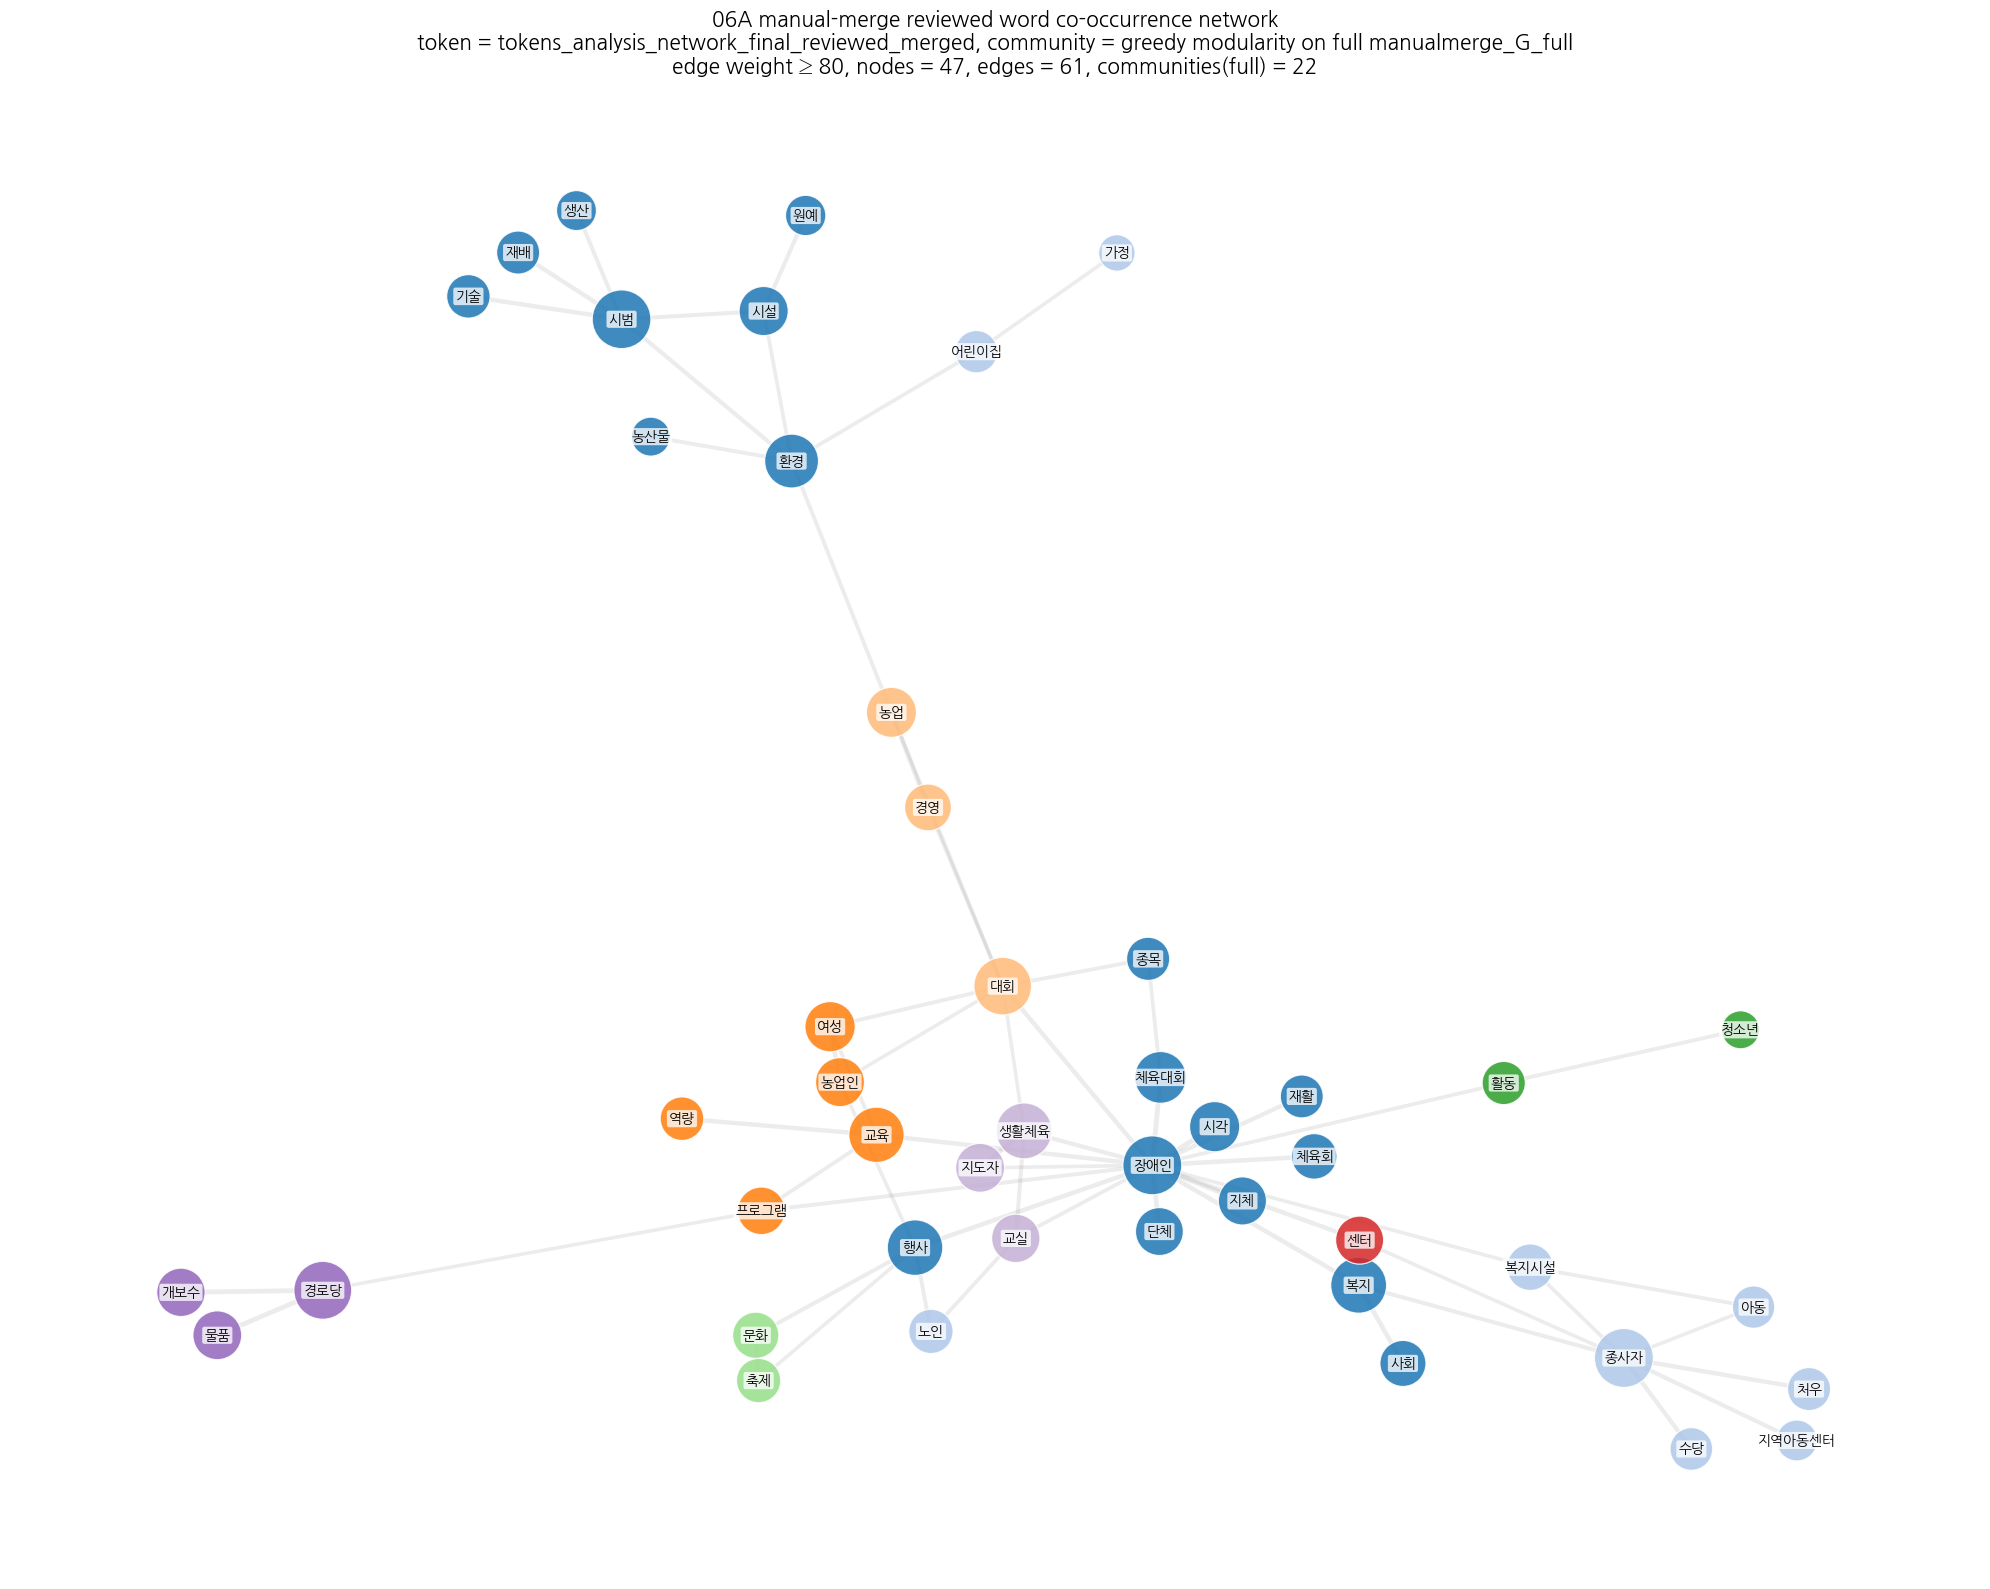


06A-APPEND-3C 완료
기존 06A-APPEND-3-FINAL-V2와 별개의 수동 재결합 반영 시각화입니다.


In [17]:
# 06A-APPEND-3C. 수동 재결합 반영 네트워크 전용 시각화
# 목적:
# - 06A-APPEND-2C에서 생성한 재결합 반영 네트워크를 별도 시각화합니다.
# - 기존 06A-APPEND-3-FINAL-V2 셀과 구분하기 위해 별도 변수명과 별도 파일명을 사용합니다.
# - 전체 reviewed_G 기준 greedy modularity community_id를 색상 기준으로 사용합니다.
#
# 실행 전제:
# - 06A-APPEND-1C 실행 완료
# - 06A-APPEND-2C 실행 완료
# - reviewed_G, reviewed_edge_df, reviewed_node_df가 재결합 반영 토큰열 기준으로 생성되어 있어야 함
#
# 저장 여부:
# - SAVE_OUTPUT = True  : PNG 및 CSV 저장
# - SAVE_OUTPUT = False : 화면 출력만

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

# 전체 노드 라벨 표시 여부
SHOW_ALL_LABELS = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "reviewed_G" not in globals():
    raise NameError("reviewed_G가 없습니다. 06A-APPEND-2C를 먼저 실행하세요.")

if "reviewed_edge_df" not in globals():
    raise NameError("reviewed_edge_df가 없습니다. 06A-APPEND-2C를 먼저 실행하세요.")

if "reviewed_node_df" not in globals():
    raise NameError("reviewed_node_df가 없습니다. 06A-APPEND-2C를 먼저 실행하세요.")

if "REVIEWED_TOKEN_COL" not in globals():
    print("주의: REVIEWED_TOKEN_COL 변수가 없습니다. 06A-APPEND-2C 실행 여부를 확인하세요.")
    REVIEWED_TOKEN_COL_FOR_PLOT = "unknown"
else:
    REVIEWED_TOKEN_COL_FOR_PLOT = REVIEWED_TOKEN_COL

print("\n[현재 시각화 기준 토큰열]")
print(REVIEWED_TOKEN_COL_FOR_PLOT)

if REVIEWED_TOKEN_COL_FOR_PLOT != "tokens_analysis_network_final_reviewed_merged":
    print(
        "\n주의: 현재 REVIEWED_TOKEN_COL이 "
        "'tokens_analysis_network_final_reviewed_merged'가 아닙니다. "
        "수동 재결합 반영 결과를 보려면 06A-APPEND-2C를 다시 실행하세요."
    )

if reviewed_G.number_of_nodes() == 0:
    raise ValueError("reviewed_G에 노드가 없습니다.")

if reviewed_G.number_of_edges() == 0:
    raise ValueError("reviewed_G에 엣지가 없습니다.")

# 기존 reviewed_*를 직접 수정하지 않도록 별도 변수로 복사
manualmerge_G_full = reviewed_G.copy()
manualmerge_edge_df = reviewed_edge_df.copy()
manualmerge_node_df = reviewed_node_df.copy()

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각 설정
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_MANUAL_MERGE_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_MANUAL_MERGE_VIS:", RUN_TS_MANUAL_MERGE_VIS)

# ------------------------------------------------------------
# 2) 시각화 기준 설정
# ------------------------------------------------------------

MERGE_VIS_MIN_EDGE_WEIGHT = 80
MERGE_VIS_TOP_N_NODES = 55

# SHOW_ALL_LABELS=False일 때만 적용
MERGE_VIS_LABEL_TOP_N = 35

MERGE_VIS_FIGSIZE = (20, 16)
MERGE_VIS_SEED = 42

print("\n[수동 재결합 반영 시각화 기준]")
print("MERGE_VIS_MIN_EDGE_WEIGHT:", MERGE_VIS_MIN_EDGE_WEIGHT)
print("MERGE_VIS_TOP_N_NODES:", MERGE_VIS_TOP_N_NODES)
print("MERGE_VIS_LABEL_TOP_N:", MERGE_VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 manualmerge_G_full 기준 greedy modularity community detection
# ------------------------------------------------------------

manualmerge_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        manualmerge_G_full,
        weight="weight"
    )
)

manualmerge_node_to_community_full = {}

for community_id, community_nodes in enumerate(manualmerge_communities_full):
    for node in community_nodes:
        manualmerge_node_to_community_full[node] = community_id

manualmerge_node_df = manualmerge_node_df.copy()
manualmerge_node_df["community_id"] = manualmerge_node_df["word"].map(
    manualmerge_node_to_community_full
)
manualmerge_node_df["community_id"] = manualmerge_node_df["community_id"].fillna(-1).astype(int)

manualmerge_community_count_full = len(manualmerge_communities_full)

print("\n[전체 수동 재결합 반영 graph 기준 커뮤니티 탐지 결과]")
print("manualmerge_G_full node 수:", manualmerge_G_full.number_of_nodes())
print("manualmerge_G_full edge 수:", manualmerge_G_full.number_of_edges())
print("community 수:", manualmerge_community_count_full)

manualmerge_community_summary_rows = []

for community_id, community_nodes in enumerate(manualmerge_communities_full):
    community_nodes = list(community_nodes)

    sub_df = manualmerge_node_df[
        manualmerge_node_df["word"].isin(community_nodes)
    ].copy()

    sub_df = sub_df.sort_values(
        ["weighted_degree", "doc_freq_unique"],
        ascending=[False, False]
    )

    top_words = sub_df["word"].head(20).tolist()

    manualmerge_community_summary_rows.append({
        "community_id": community_id,
        "node_count": len(community_nodes),
        "top_words": ", ".join(top_words)
    })

manualmerge_community_summary_df = pd.DataFrame(manualmerge_community_summary_rows)

print("\n[수동 재결합 반영 community별 대표 단어]")
display(manualmerge_community_summary_df)

# ------------------------------------------------------------
# 5) 시각화용 노드/엣지 선정
# ------------------------------------------------------------

manualmerge_top_nodes = set(
    manualmerge_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(MERGE_VIS_TOP_N_NODES)["word"]
)

manualmerge_vis_edge_df = manualmerge_edge_df[
    (manualmerge_edge_df["weight"] >= MERGE_VIS_MIN_EDGE_WEIGHT)
    & manualmerge_edge_df["source"].isin(manualmerge_top_nodes)
    & manualmerge_edge_df["target"].isin(manualmerge_top_nodes)
].copy()

if len(manualmerge_vis_edge_df) < 30:
    print("\n주의: edge가 너무 적어 기준을 60으로 완화합니다.")
    MERGE_VIS_MIN_EDGE_WEIGHT = 60

    manualmerge_vis_edge_df = manualmerge_edge_df[
        (manualmerge_edge_df["weight"] >= MERGE_VIS_MIN_EDGE_WEIGHT)
        & manualmerge_edge_df["source"].isin(manualmerge_top_nodes)
        & manualmerge_edge_df["target"].isin(manualmerge_top_nodes)
    ].copy()

manualmerge_G_vis = nx.Graph()

for _, row in manualmerge_vis_edge_df.iterrows():
    manualmerge_G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

manualmerge_G_vis.remove_nodes_from(list(nx.isolates(manualmerge_G_vis)))

print("\n[수동 재결합 반영 시각화용 graph]")
print("node 수:", manualmerge_G_vis.number_of_nodes())
print("edge 수:", manualmerge_G_vis.number_of_edges())

if manualmerge_G_vis.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다.")

# ------------------------------------------------------------
# 6) 시각화 포함 노드 community_id 확인
# ------------------------------------------------------------

manualmerge_vis_node_community_rows = []

for node in manualmerge_G_vis.nodes():
    manualmerge_vis_node_community_rows.append({
        "word": node,
        "community_id": manualmerge_node_to_community_full.get(node, -1),
        "doc_freq_unique": manualmerge_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": manualmerge_G_vis.degree(node, weight="weight")
    })

manualmerge_vis_node_community_df = (
    pd.DataFrame(manualmerge_vis_node_community_rows)
    .sort_values(["community_id", "weighted_degree_in_vis"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n[수동 재결합 반영 시각화 포함 노드 community_id]")
display(manualmerge_vis_node_community_df)

manualmerge_vis_community_count = manualmerge_vis_node_community_df["community_id"].nunique()
print("\n시각화에 포함된 community 수:", manualmerge_vis_community_count)

# ------------------------------------------------------------
# 7) community_id 기반 색상 지정
# ------------------------------------------------------------

cmap = plt.get_cmap("tab20", max(manualmerge_community_count_full, 1))

manualmerge_node_colors = []

for node in manualmerge_G_vis.nodes():
    community_id = manualmerge_node_to_community_full.get(node, -1)

    if community_id == -1:
        manualmerge_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        manualmerge_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 8) 레이아웃 계산
# ------------------------------------------------------------

manualmerge_pos = nx.spring_layout(
    manualmerge_G_vis,
    seed=MERGE_VIS_SEED,
    weight="weight",
    k=1.35 / np.sqrt(max(manualmerge_G_vis.number_of_nodes(), 1)),
    iterations=400
)

manualmerge_weighted_degree_vis = dict(manualmerge_G_vis.degree(weight="weight"))

manualmerge_node_sizes = []

for node in manualmerge_G_vis.nodes():
    wd = manualmerge_weighted_degree_vis.get(node, 1)
    size = 180 + np.sqrt(wd) * 55
    size = max(220, min(size, 1800))
    manualmerge_node_sizes.append(size)

manualmerge_edge_weights = [
    manualmerge_G_vis[u][v]["weight"]
    for u, v in manualmerge_G_vis.edges()
]

manualmerge_edge_widths = [
    max(0.4, min(np.log1p(w) / 1.7, 3.6))
    for w in manualmerge_edge_weights
]

# ------------------------------------------------------------
# 9) 라벨 표시 대상 설정
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    manualmerge_label_nodes = set(manualmerge_G_vis.nodes())
    LABEL_FONT_SIZE = 10
else:
    manualmerge_label_nodes = set(
        manualmerge_node_df
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(MERGE_VIS_LABEL_TOP_N)["word"]
    )
    LABEL_FONT_SIZE = 12

manualmerge_labels = {
    node: node
    for node in manualmerge_G_vis.nodes()
    if node in manualmerge_label_nodes
}

print("\n[라벨 표시]")
print("표시 라벨 수:", len(manualmerge_labels))

# ------------------------------------------------------------
# 10) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=MERGE_VIS_FIGSIZE)

nx.draw_networkx_edges(
    manualmerge_G_vis,
    manualmerge_pos,
    width=manualmerge_edge_widths,
    alpha=0.15,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    manualmerge_G_vis,
    manualmerge_pos,
    node_size=manualmerge_node_sizes,
    alpha=0.86,
    node_color=manualmerge_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LABEL_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=15)

for node, label in manualmerge_labels.items():
    x, y = manualmerge_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LABEL_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.76,
            boxstyle="round,pad=0.15"
        ),
        zorder=10
    )

ax.set_title(
    "06A manual-merge reviewed word co-occurrence network\n"
    f"token = {REVIEWED_TOKEN_COL_FOR_PLOT}, "
    f"community = greedy modularity on full manualmerge_G_full\n"
    f"edge weight ≥ {MERGE_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {manualmerge_G_vis.number_of_nodes()}, "
    f"edges = {manualmerge_G_vis.number_of_edges()}, "
    f"communities(full) = {manualmerge_community_count_full}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_manualmerge = (
        FIGURE_REVIEW_DIR
        / f"06A_manualmerge_network_preview_{RUN_VERSION}_{RUN_TS_MANUAL_MERGE_VIS}.png"
    )

    out_community_manualmerge = (
        TABLE_REVIEW_DIR
        / f"06A_manualmerge_community_full_{RUN_VERSION}_{RUN_TS_MANUAL_MERGE_VIS}.csv"
    )

    out_vis_node_manualmerge = (
        TABLE_REVIEW_DIR
        / f"06A_manualmerge_vis_node_community_{RUN_VERSION}_{RUN_TS_MANUAL_MERGE_VIS}.csv"
    )

    plt.savefig(out_png_manualmerge, dpi=260, bbox_inches="tight")

    manualmerge_community_summary_df.to_csv(
        out_community_manualmerge,
        index=False,
        encoding="utf-8-sig"
    )

    manualmerge_vis_node_community_df.to_csv(
        out_vis_node_manualmerge,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[수동 재결합 반영 시각화 저장 완료]")
    print("- PNG:", out_png_manualmerge)
    print("- full community summary:", out_community_manualmerge)
    print("- vis node community:", out_vis_node_manualmerge)

plt.show()

print("\n06A-APPEND-3C 완료")
print("기존 06A-APPEND-3-FINAL-V2와 별개의 수동 재결합 반영 시각화입니다.")

### 06A-APPEND-1E. 최신 수동 재결합 판단 반영 + 저정보 토큰 제거

In [18]:
# 06A-APPEND-1E. 최신 수동 재결합 판단 반영 + 저정보 토큰 제거
# 목적:
# - 최신 manual_merge_decision Excel을 읽습니다.
# - tokens_analysis_network_final에 수동 재결합 규칙을 먼저 적용합니다.
# - 그 다음 기존 저정보 토큰 제거 목록을 적용합니다.
# - 결과 열 tokens_analysis_network_final_manualmerge_reviewed를 생성합니다.
#
# 실행 전제:
# - 06A-APPEND-1 실행 완료
# - df_03_review 존재
# - tokens_analysis_network_final 존재
#
# 중요:
# - 이 셀은 06A 확인용입니다.
# - 최종 확정 후에는 같은 로직을 03 노트북에 반영해야 합니다.

from pathlib import Path
import pandas as pd
import numpy as np
import ast

# ------------------------------------------------------------
# 1) 최신 수동 재결합 판단 Excel 경로
# ------------------------------------------------------------

MERGE_DECISION_XLSX_NAME = "03_token_adjacent_ngram_merge_review_v1_20260611_2022.xlsx"

MERGE_DECISION_XLSX_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "review"
    / MERGE_DECISION_XLSX_NAME
)

print("[최신 재결합 판단 Excel]")
print(MERGE_DECISION_XLSX_PATH)
print("exists:", MERGE_DECISION_XLSX_PATH.exists())

if not MERGE_DECISION_XLSX_PATH.exists():
    print("\n기본 경로에서 파일을 찾지 못했습니다. /content/drive 아래에서 자동 검색합니다.")

    matches = list(Path("/content/drive").rglob(MERGE_DECISION_XLSX_NAME))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{MERGE_DECISION_XLSX_NAME} 파일을 Drive에서 찾지 못했습니다. "
            "해당 Excel 파일을 03_v1_사업명텍스트분석/tables/review 폴더에 업로드하세요."
        )

    MERGE_DECISION_XLSX_PATH = matches[0]
    print("자동 검색 성공:")
    print(MERGE_DECISION_XLSX_PATH)

# ------------------------------------------------------------
# 2) 입력 데이터 확인
# ------------------------------------------------------------

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1을 먼저 실행하세요.")

SOURCE_TOKEN_COL_FOR_MERGE_FIRST = "tokens_analysis_network_final"
MERGED_TOKEN_COL = "tokens_analysis_network_final_manualmerge"
FINAL_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed"

if SOURCE_TOKEN_COL_FOR_MERGE_FIRST not in df_03_review.columns:
    raise KeyError(f"{SOURCE_TOKEN_COL_FOR_MERGE_FIRST} 열이 없습니다.")

print("\n[토큰 처리 흐름]")
print("입력:", SOURCE_TOKEN_COL_FOR_MERGE_FIRST)
print("재결합 후:", MERGED_TOKEN_COL)
print("재결합 후 저정보 제거:", FINAL_TOKEN_COL)

# ------------------------------------------------------------
# 3) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

def ensure_token_list_local(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip() != ""]

    if isinstance(x, tuple):
        return [str(t).strip() for t in list(x) if str(t).strip() != ""]

    if isinstance(x, np.ndarray):
        return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

    if x is None:
        return []

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, str):
        x_strip = x.strip()

        if x_strip == "":
            return []

        try:
            parsed = ast.literal_eval(x_strip)

            if isinstance(parsed, list):
                return [str(t).strip() for t in parsed if str(t).strip() != ""]

            if isinstance(parsed, tuple):
                return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]

        except Exception:
            pass

        return [x_strip]

    return [str(x).strip()] if str(x).strip() != "" else []

df_03_review[SOURCE_TOKEN_COL_FOR_MERGE_FIRST] = df_03_review[
    SOURCE_TOKEN_COL_FOR_MERGE_FIRST
].apply(ensure_token_list_local)

# ------------------------------------------------------------
# 4) manual_merge_decision 읽기
# ------------------------------------------------------------

manual_merge_df = pd.read_excel(
    MERGE_DECISION_XLSX_PATH,
    sheet_name="manual_merge_decision"
)

manual_merge_df.columns = [str(c).strip() for c in manual_merge_df.columns]

required_cols = [
    "ngram_n",
    "token_1",
    "token_2",
    "token_3",
    "tokens_with_plus",
    "joined_candidate",
    "수동판단",
    "처리방향"
]

missing_cols = [col for col in required_cols if col not in manual_merge_df.columns]

if missing_cols:
    raise KeyError(f"manual_merge_decision 시트에 필요한 열이 없습니다: {missing_cols}")

for col in ["token_1", "token_2", "token_3", "joined_candidate", "수동판단", "처리방향"]:
    manual_merge_df[col] = manual_merge_df[col].fillna("").astype(str).str.strip()

# ------------------------------------------------------------
# 5) 재결합 확정 행만 추출
# ------------------------------------------------------------

merge_rule_df = manual_merge_df[
    (manual_merge_df["수동판단"] == "재결합")
    | (manual_merge_df["처리방향"] == "merge")
].copy()

print("\n[manual_merge_decision 반영 현황]")
print("전체 후보 행 수:", len(manual_merge_df))
print("재결합 반영 행 수:", len(merge_rule_df))

if len(merge_rule_df) == 0:
    raise ValueError("재결합으로 표시된 행이 없습니다.")

# ------------------------------------------------------------
# 6) 재결합 규칙 생성
# ------------------------------------------------------------

merge_rules = []

for _, row in merge_rule_df.iterrows():
    try:
        ngram_n = int(row["ngram_n"])
    except Exception:
        ngram_n = None

    tokens = []

    if row["token_1"] != "":
        tokens.append(row["token_1"])
    if row["token_2"] != "":
        tokens.append(row["token_2"])
    if row["token_3"] != "":
        tokens.append(row["token_3"])

    if ngram_n is not None:
        tokens = tokens[:ngram_n]

    tokens = [t for t in tokens if t != ""]
    joined_candidate = row["joined_candidate"]

    if len(tokens) < 2:
        continue

    if joined_candidate == "":
        joined_candidate = "".join(tokens)

    merge_rules.append({
        "pattern": tuple(tokens),
        "merged": joined_candidate,
        "ngram_n": len(tokens),
        "tokens_with_plus": " + ".join(tokens),
        "수동판단": row["수동판단"],
        "처리방향": row["처리방향"]
    })

merge_rules_df = pd.DataFrame(merge_rules)

merge_rules_df = (
    merge_rules_df
    .drop_duplicates(subset=["pattern", "merged"])
    .sort_values(["ngram_n", "tokens_with_plus"], ascending=[False, True])
    .reset_index(drop=True)
)

merge_rules = [
    (tuple(row["pattern"]), row["merged"])
    for _, row in merge_rules_df.iterrows()
]

print("\n[적용할 재결합 규칙]")
print("규칙 수:", len(merge_rules_df))
display(merge_rules_df.head(100))

# ------------------------------------------------------------
# 7) 재결합 적용 함수
# ------------------------------------------------------------
# 3-gram을 먼저 적용하고, 그 다음 2-gram을 적용합니다.

def apply_manual_merge_rules(tokens, merge_rules):
    tokens = ensure_token_list_local(tokens)

    out_tokens = []
    applied_rules = []

    i = 0

    while i < len(tokens):
        matched = False

        for pattern, merged in merge_rules:
            n = len(pattern)

            if n == 0:
                continue

            if tuple(tokens[i:i+n]) == pattern:
                out_tokens.append(merged)
                applied_rules.append(f"{' + '.join(pattern)} -> {merged}")
                i += n
                matched = True
                break

        if not matched:
            out_tokens.append(tokens[i])
            i += 1

    return out_tokens, applied_rules

# ------------------------------------------------------------
# 8) 재결합 먼저 적용
# ------------------------------------------------------------

merged_results = df_03_review[SOURCE_TOKEN_COL_FOR_MERGE_FIRST].apply(
    lambda toks: apply_manual_merge_rules(toks, merge_rules)
)

df_03_review[MERGED_TOKEN_COL] = merged_results.apply(lambda x: x[0])
df_03_review["tokens_network_manual_merged_pairs_latest"] = merged_results.apply(lambda x: x[1])

# ------------------------------------------------------------
# 9) 저정보 토큰 제거 목록 설정
# ------------------------------------------------------------
# 우선 06A-APPEND-1에서 만든 remove_tokens가 있으면 그대로 사용합니다.
# 없으면 기존 fallback 목록을 사용합니다.

fallback_remove_tokens = [
    "개선", "전국", "활성", "육성", "협의회", "강화", "지회", "조성", "구입",
    "설치", "우수", "사업비", "연합회", "사랑", "보급", "마당", "정비",
    "협회", "보수", "추가", "참여", "출전", "자체", "기념행사", "규모",
    "기념", "교체", "맞춤", "행복",
]

if "remove_tokens" in globals():
    lowinfo_remove_tokens = sorted(set([str(t).strip() for t in remove_tokens if str(t).strip() != ""]))
    lowinfo_source = "remove_tokens from 06A-APPEND-1"
else:
    lowinfo_remove_tokens = sorted(set(fallback_remove_tokens))
    lowinfo_source = "fallback_remove_tokens"

# 여기에는 아직 시범/활동/단체/역량 등 추가 제거 후보를 넣지 않습니다.
# 이번 셀은 '재결합 판단 최신 반영' 결과만 확인하기 위한 단계입니다.
EXTRA_LOWINFO_TOKENS_FOR_THIS_TEST = []

lowinfo_remove_set = set(lowinfo_remove_tokens) | set(EXTRA_LOWINFO_TOKENS_FOR_THIS_TEST)

print("\n[저정보 제거 목록]")
print("출처:", lowinfo_source)
print("기본 제거 토큰 수:", len(lowinfo_remove_tokens))
print("추가 제거 토큰:", EXTRA_LOWINFO_TOKENS_FOR_THIS_TEST)
print("전체 제거 토큰 수:", len(lowinfo_remove_set))

# ------------------------------------------------------------
# 10) 재결합 후 저정보 토큰 제거
# ------------------------------------------------------------

def remove_lowinfo_after_merge(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok not in lowinfo_remove_set]

def get_removed_lowinfo_after_merge(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok in lowinfo_remove_set]

df_03_review[FINAL_TOKEN_COL] = df_03_review[MERGED_TOKEN_COL].apply(
    remove_lowinfo_after_merge
)

df_03_review["tokens_network_lowinfo_removed_after_manualmerge"] = df_03_review[
    MERGED_TOKEN_COL
].apply(get_removed_lowinfo_after_merge)

df_03_review[f"{FINAL_TOKEN_COL}_count"] = df_03_review[FINAL_TOKEN_COL].apply(len)
df_03_review[f"{FINAL_TOKEN_COL}_empty"] = df_03_review[FINAL_TOKEN_COL].apply(lambda x: len(x) == 0)

# ------------------------------------------------------------
# 11) 적용 결과 점검
# ------------------------------------------------------------

manual_merge_rows_changed = df_03_review["tokens_network_manual_merged_pairs_latest"].apply(len).gt(0).sum()
manual_merge_total_applied = df_03_review["tokens_network_manual_merged_pairs_latest"].apply(len).sum()

lowinfo_removed_rows = df_03_review["tokens_network_lowinfo_removed_after_manualmerge"].apply(len).gt(0).sum()
lowinfo_removed_total = df_03_review["tokens_network_lowinfo_removed_after_manualmerge"].apply(len).sum()

final_empty_rows = df_03_review[f"{FINAL_TOKEN_COL}_empty"].sum()

manualmerge_latest_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "재결합 후 토큰열",
        "최종 토큰열",
        "재결합 규칙 수",
        "재결합 발생 행 수",
        "재결합 총 적용 횟수",
        "저정보 제거 발생 행 수",
        "저정보 제거 총 횟수",
        "최종 빈 토큰 행 수"
    ],
    "값": [
        SOURCE_TOKEN_COL_FOR_MERGE_FIRST,
        MERGED_TOKEN_COL,
        FINAL_TOKEN_COL,
        len(merge_rules_df),
        int(manual_merge_rows_changed),
        int(manual_merge_total_applied),
        int(lowinfo_removed_rows),
        int(lowinfo_removed_total),
        int(final_empty_rows)
    ]
})

print("\n[최신 수동 재결합 + 저정보 제거 적용 요약]")
display(manualmerge_latest_summary)

print("\n[재결합 적용 사례 상위 50개]")
merge_changed_cases = df_03_review[
    df_03_review["tokens_network_manual_merged_pairs_latest"].apply(len).gt(0)
].copy()

display_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "사업명",
    SOURCE_TOKEN_COL_FOR_MERGE_FIRST,
    MERGED_TOKEN_COL,
    FINAL_TOKEN_COL,
    "tokens_network_manual_merged_pairs_latest",
    "tokens_network_lowinfo_removed_after_manualmerge"
]

display_cols = [col for col in display_cols if col in merge_changed_cases.columns]

display(merge_changed_cases[display_cols].head(50))

print("\n06A-APPEND-1E 완료")
print(f"다음 네트워크 생성 셀에서 REVIEWED_TOKEN_COL = '{FINAL_TOKEN_COL}' 로 설정하세요.")

[최신 재결합 판단 Excel]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/review/03_token_adjacent_ngram_merge_review_v1_20260611_2022.xlsx
exists: True

[토큰 처리 흐름]
입력: tokens_analysis_network_final
재결합 후: tokens_analysis_network_final_manualmerge
재결합 후 저정보 제거: tokens_analysis_network_final_manualmerge_reviewed

[manual_merge_decision 반영 현황]
전체 후보 행 수: 10842
재결합 반영 행 수: 416

[적용할 재결합 규칙]
규칙 수: 416


,pattern,merged,ngram_n,tokens_with_plus,수동판단,처리방향
0,"(6.25, 참전, 유공자)",6.25참전유공자,3,6.25 + 참전 + 유공자,재결합,merge
1,"(공헌, 활동, 전환사업)",공헌활동전환사업,3,공헌 + 활동 + 전환사업,재결합,merge
2,"(국악, 경연, 대회)",국악경연대회,3,국악 + 경연 + 대회,재결합,merge
3,"(그라운드, 골프, 대회)",그라운드골프대회,3,그라운드 + 골프 + 대회,재결합,merge
4,"(도민, 체육, 대회)",도민체육대회,3,도민 + 체육 + 대회,재결합,merge
...,...,...,...,...,...,...
95,"(농촌, 지도자)",농촌지도자,2,농촌 + 지도자,재결합,merge
96,"(농촌, 체험)",농촌체험,2,농촌 + 체험,재결합,merge
97,"(다문화, 가정)",다문화가정,2,다문화 + 가정,재결합,merge
98,"(다문화, 가족)",다문화가족,2,다문화 + 가족,재결합,merge



[저정보 제거 목록]
출처: remove_tokens from 06A-APPEND-1
기본 제거 토큰 수: 29
추가 제거 토큰: []
전체 제거 토큰 수: 29

[최신 수동 재결합 + 저정보 제거 적용 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final
1,재결합 후 토큰열,tokens_analysis_network_final_manualmerge
2,최종 토큰열,tokens_analysis_network_final_manualmerge_revi...
3,재결합 규칙 수,416
4,재결합 발생 행 수,30618
5,재결합 총 적용 횟수,35771
6,저정보 제거 발생 행 수,18264
7,저정보 제거 총 횟수,19848
8,최종 빈 토큰 행 수,108



[재결합 적용 사례 상위 50개]


,v1_row_id,시도,지자체명,사업명,tokens_analysis_network_final,tokens_analysis_network_final_manualmerge,tokens_analysis_network_final_manualmerge_reviewed,tokens_network_manual_merged_pairs_latest,tokens_network_lowinfo_removed_after_manualmerge
1,1,경남,남해군,2023년 사)진주지역범죄피해자지원센터‘등불 ’남해지부 운영,"[지역, 범죄, 피해자, 센터, 등불, 지부]","[지역, 범죄피해자, 센터, 등불, 지부]","[지역, 범죄피해자, 센터, 등불, 지부]",[범죄 + 피해자 -> 범죄피해자],[]
2,2,경남,남해군,자유민주주의신장 및 자유선진의식 고취,"[자유, 민주주의, 신장, 자유선진, 의식, 고취]","[자유민주주의, 신장, 자유선진, 의식, 고취]","[자유민주주의, 신장, 자유선진, 의식, 고취]",[자유 + 민주주의 -> 자유민주주의],[]
4,4,경남,남해군,참전경찰유공자 보훈활동,"[참전, 경찰, 유공자, 보훈, 활동]","[참전, 경찰, 유공자, 보훈활동]","[참전, 경찰, 유공자, 보훈활동]",[보훈 + 활동 -> 보훈활동],[]
5,5,경남,남해군,무공수훈자회 운영비 보조,"[무공, 수훈자]",[무공수훈자],[무공수훈자],[무공 + 수훈자 -> 무공수훈자],[]
11,11,경남,남해군,문화학교 운영,"[문화, 학교]",[문화학교],[문화학교],[문화 + 학교 -> 문화학교],[]
12,12,경남,남해군,남중권생활체육 교류 지원,"[남, 생활, 체육, 교류]","[남, 생활체육, 교류]","[남, 생활체육, 교류]",[생활 + 체육 -> 생활체육],[]
13,13,경남,남해군,"전국대회 운영(구급차, 응급의료 등) 지원","[전국, 대회, 구급차, 응급, 의료]","[전국대회, 구급차, 응급, 의료]","[전국대회, 구급차, 응급, 의료]",[전국 + 대회 -> 전국대회],[]
17,17,경남,남해군,자연환경 보전활동 사업 (자연보호정화활동및군수기경진대회),"[자연, 환경, 보전, 활동, 자연보호, 정화, 활동, 수기, 경진, 대회]","[자연, 환경, 보전활동, 자연보호, 정화활동, 수기, 경진대회]","[자연, 환경, 보전활동, 자연보호, 정화활동, 수기, 경진대회]","[보전 + 활동 -> 보전활동, 정화 + 활동 -> 정화활동, 경진 + 대회 -> ...",[]
18,18,경남,남해군,2023년 음식점 위생환경 개선사업 (시설환경개선및입식테이블지원),"[음식점, 위생, 환경, 개선, 시설, 환경, 개선, 입식, 테이블]","[음식점, 위생, 환경개선, 시설환경개선, 입식, 테이블]","[음식점, 위생, 환경개선, 시설환경개선, 입식, 테이블]","[환경 + 개선 -> 환경개선, 시설 + 환경 + 개선 -> 시설환경개선]",[]
21,21,경남,남해군,2023년 범죄피해자 지원 및 지원센터‘등불’운영,"[범죄, 피해자, 센터, 등불]","[범죄피해자, 센터, 등불]","[범죄피해자, 센터, 등불]",[범죄 + 피해자 -> 범죄피해자],[]



06A-APPEND-1E 완료
다음 네트워크 생성 셀에서 REVIEWED_TOKEN_COL = 'tokens_analysis_network_final_manualmerge_reviewed' 로 설정하세요.


In [19]:
# 06A-APPEND-2E. 최신 수동 재결합+저정보 제거 토큰열로 네트워크 생성
# 목적:
# - 06A-APPEND-1E에서 생성한 tokens_analysis_network_final_manualmerge_reviewed 열을 기준으로
#   단어 동시출현 네트워크를 새로 생성합니다.
# - 기존 reviewed_G, reviewed_edge_df, reviewed_node_df를 덮어쓰지 않고,
#   finalmerge_G_full, finalmerge_edge_df, finalmerge_node_df 등 별도 변수명을 사용합니다.
#
# 실행 전제:
# - 06A-APPEND-1E 실행 완료
# - df_03_review 존재
# - tokens_analysis_network_final_manualmerge_reviewed 존재

from collections import Counter
from itertools import combinations
import pandas as pd
import numpy as np
import networkx as nx
import ast

# ------------------------------------------------------------
# 1) 네트워크 생성 기준
# ------------------------------------------------------------

FINALMERGE_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed"

FINALMERGE_MIN_DOC_FREQ = 100
FINALMERGE_MIN_EDGE_WEIGHT_FOR_TABLE = 1
FINALMERGE_MIN_EDGE_WEIGHT_FOR_GRAPH = 30

print("[06A-APPEND-2E 네트워크 생성 기준]")
print("FINALMERGE_TOKEN_COL:", FINALMERGE_TOKEN_COL)
print("FINALMERGE_MIN_DOC_FREQ:", FINALMERGE_MIN_DOC_FREQ)
print("FINALMERGE_MIN_EDGE_WEIGHT_FOR_TABLE:", FINALMERGE_MIN_EDGE_WEIGHT_FOR_TABLE)
print("FINALMERGE_MIN_EDGE_WEIGHT_FOR_GRAPH:", FINALMERGE_MIN_EDGE_WEIGHT_FOR_GRAPH)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1E를 먼저 실행하세요.")

if FINALMERGE_TOKEN_COL not in df_03_review.columns:
    raise KeyError(f"{FINALMERGE_TOKEN_COL} 열이 없습니다. 06A-APPEND-1E를 먼저 실행하세요.")

# ------------------------------------------------------------
# 2) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

if "ensure_token_list_local" not in globals():
    def ensure_token_list_local(x):
        if isinstance(x, list):
            return [str(t).strip() for t in x if str(t).strip() != ""]

        if isinstance(x, tuple):
            return [str(t).strip() for t in list(x) if str(t).strip() != ""]

        if isinstance(x, np.ndarray):
            return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

        if x is None:
            return []

        try:
            if pd.isna(x):
                return []
        except Exception:
            pass

        if isinstance(x, str):
            x_strip = x.strip()

            if x_strip == "":
                return []

            try:
                parsed = ast.literal_eval(x_strip)

                if isinstance(parsed, list):
                    return [str(t).strip() for t in parsed if str(t).strip() != ""]

                if isinstance(parsed, tuple):
                    return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]

            except Exception:
                pass

            return [x_strip]

        return [str(x).strip()] if str(x).strip() != "" else []

df_03_review[FINALMERGE_TOKEN_COL] = df_03_review[FINALMERGE_TOKEN_COL].apply(
    ensure_token_list_local
)

# ------------------------------------------------------------
# 3) 행 단위 unique token 생성
# ------------------------------------------------------------

finalmerge_df_network = df_03_review.copy()

finalmerge_df_network["tokens_for_finalmerge_network"] = finalmerge_df_network[
    FINALMERGE_TOKEN_COL
].apply(lambda toks: sorted(set(ensure_token_list_local(toks))))

finalmerge_df_network["tokens_for_finalmerge_network_count"] = finalmerge_df_network[
    "tokens_for_finalmerge_network"
].apply(len)

print("\n[행 단위 토큰 확인]")
print("전체 행 수:", len(finalmerge_df_network))
print("빈 토큰 행 수:", int(finalmerge_df_network["tokens_for_finalmerge_network_count"].eq(0).sum()))

# ------------------------------------------------------------
# 4) 단어 문서빈도 계산
# ------------------------------------------------------------

finalmerge_word_doc_counter = Counter()

for toks in finalmerge_df_network["tokens_for_finalmerge_network"]:
    for tok in toks:
        finalmerge_word_doc_counter[tok] += 1

finalmerge_word_freq_df = (
    pd.DataFrame(
        [
            {
                "word": word,
                "doc_freq_unique": freq
            }
            for word, freq in finalmerge_word_doc_counter.items()
        ]
    )
    .sort_values("doc_freq_unique", ascending=False)
    .reset_index(drop=True)
)

finalmerge_valid_words = set(
    finalmerge_word_freq_df[
        finalmerge_word_freq_df["doc_freq_unique"] >= FINALMERGE_MIN_DOC_FREQ
    ]["word"]
)

print("\n[단어 빈도]")
print("전체 unique token 수:", len(finalmerge_word_freq_df))
print("doc_freq 기준 통과 token 수:", len(finalmerge_valid_words))

display(finalmerge_word_freq_df.head(80))

# ------------------------------------------------------------
# 5) 엣지 집계
# ------------------------------------------------------------

finalmerge_edge_counter = Counter()

for toks in finalmerge_df_network["tokens_for_finalmerge_network"]:
    toks = [tok for tok in toks if tok in finalmerge_valid_words]

    if len(toks) < 2:
        continue

    for a, b in combinations(sorted(toks), 2):
        finalmerge_edge_counter[(a, b)] += 1

finalmerge_edge_df = pd.DataFrame(
    [
        {
            "source": a,
            "target": b,
            "weight": weight
        }
        for (a, b), weight in finalmerge_edge_counter.items()
        if weight >= FINALMERGE_MIN_EDGE_WEIGHT_FOR_TABLE
    ]
)

if len(finalmerge_edge_df) > 0:
    finalmerge_edge_df = (
        finalmerge_edge_df
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )

print("\n[엣지]")
print("edge 수:", len(finalmerge_edge_df))
display(finalmerge_edge_df.head(80))

# ------------------------------------------------------------
# 6) NetworkX graph 생성
# ------------------------------------------------------------

finalmerge_G_full = nx.Graph()

for _, row in finalmerge_word_freq_df.iterrows():
    word = row["word"]
    freq = int(row["doc_freq_unique"])

    if word in finalmerge_valid_words:
        finalmerge_G_full.add_node(
            word,
            doc_freq_unique=freq
        )

for _, row in finalmerge_edge_df.iterrows():
    if row["weight"] >= FINALMERGE_MIN_EDGE_WEIGHT_FOR_GRAPH:
        finalmerge_G_full.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

finalmerge_G_full.remove_nodes_from(list(nx.isolates(finalmerge_G_full)))

# ------------------------------------------------------------
# 7) 노드 지표 계산
# ------------------------------------------------------------

finalmerge_weighted_degree = dict(finalmerge_G_full.degree(weight="weight"))
finalmerge_degree = dict(finalmerge_G_full.degree())

finalmerge_node_rows = []

for node in finalmerge_G_full.nodes():
    finalmerge_node_rows.append({
        "word": node,
        "doc_freq_unique": finalmerge_G_full.nodes[node].get("doc_freq_unique", None),
        "degree": finalmerge_degree.get(node, 0),
        "weighted_degree": finalmerge_weighted_degree.get(node, 0)
    })

finalmerge_node_df = (
    pd.DataFrame(finalmerge_node_rows)
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .reset_index(drop=True)
)

finalmerge_network_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "전체 unique token 수",
        "doc_freq 기준 통과 token 수",
        "table edge 수",
        "graph node 수",
        "graph edge 수"
    ],
    "값": [
        FINALMERGE_TOKEN_COL,
        len(finalmerge_word_freq_df),
        len(finalmerge_valid_words),
        len(finalmerge_edge_df),
        finalmerge_G_full.number_of_nodes(),
        finalmerge_G_full.number_of_edges()
    ]
})

print("\n[최신 수동 재결합+저정보 제거 네트워크 요약]")
display(finalmerge_network_summary)

print("\n[노드 상위 80개]")
display(finalmerge_node_df.head(80))

print("\n06A-APPEND-2E 완료")
print("다음으로 06A-APPEND-3E 시각화 셀을 실행하세요.")

[06A-APPEND-2E 네트워크 생성 기준]
FINALMERGE_TOKEN_COL: tokens_analysis_network_final_manualmerge_reviewed
FINALMERGE_MIN_DOC_FREQ: 100
FINALMERGE_MIN_EDGE_WEIGHT_FOR_TABLE: 1
FINALMERGE_MIN_EDGE_WEIGHT_FOR_GRAPH: 30

[행 단위 토큰 확인]
전체 행 수: 79262
빈 토큰 행 수: 108

[단어 빈도]
전체 unique token 수: 18465
doc_freq 기준 통과 token 수: 510


,word,doc_freq_unique
0,장애인,4783
1,행사,2860
2,대회,2818
3,교육,2314
4,경로당,1703
...,...,...
75,건강,407
76,기업,402
77,체험,395
78,공연,395



[엣지]
edge 수: 24547


,source,target,weight
0,장애인,체육대회,385
1,시각,장애인,383
2,경로당,물품,363
3,개보수,경로당,353
4,장애인,지체,345
...,...,...,...
75,대회,종목,99
76,마을,휴양,99
77,농가,양봉,98
78,종목,체육대회,98



[최신 수동 재결합+저정보 제거 네트워크 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_manualmerge_revi...
1,전체 unique token 수,18465
2,doc_freq 기준 통과 token 수,510
3,table edge 수,24547
4,graph node 수,314
5,graph edge 수,600



[노드 상위 80개]


,word,doc_freq_unique,degree,weighted_degree
0,장애인,4783,58,5977.0
1,교육,2314,43,2504.0
2,시범,1449,33,2137.0
3,대회,2818,38,2117.0
4,종사자,1062,23,1939.0
...,...,...,...,...
75,직업,155,4,230.0
76,클럽,317,3,229.0
77,마을회관,323,4,222.0
78,재활시설,131,4,222.0



06A-APPEND-2E 완료
다음으로 06A-APPEND-3E 시각화 셀을 실행하세요.


SAVE_OUTPUT: True
SHOW_ALL_LABELS: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_manualmerge_reviewed

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_FINALMERGE_VIS: 20260611_2223

[최신 finalmerge 시각화 기준]
FINALMERGE_VIS_MIN_EDGE_WEIGHT: 80
FINALMERGE_VIS_TOP_N_NODES: 55
FINALMERGE_VIS_LABEL_TOP_N: 35

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 finalmerge_G_full 기준 커뮤니티 탐지 결과]
finalmerge_G_full node 수: 314
finalmerge_G_full edge 수: 600
community 수: 23

[최신 finalmerge community별 대표 단어]


,community_id,node_count,top_words
0,0,59,"시범, 환경, 생산, 시설, 농산물, 농가, 기술, 방제, 쌀, 벼, 재배, 원예,..."
1,1,59,"장애인, 대회, 행사, 체육대회, 복지, 단체, 시각, 종목, 지체, 체육회, 재활..."
2,2,37,"교육, 프로그램, 여성, 농업, 농업인, 역량강화, 경영, 시민, 청년, 평생, 워..."
3,3,35,"종사자, 청소년, 아동, 복지시설, 수당, 지역아동센터, 가족, 처우개선, 활동, ..."
4,4,23,"문화, 축제, 안전, 지역, 봉사, 자원, 교류, 기관, 발간, 관광, 공연, 의료..."
5,5,18,"경로당, 마을, 개보수, 물품, 운동, 마을회관, 농촌체험, 휴양, 아파트, 회원,..."
6,6,15,"센터, 공모, 자원봉사, 장애인자립, 생활, 종합, 진흥, 범죄피해자, 주민, 이웃..."
7,7,15,"생활체육, 지도자, 노인, 교실, 대학, 어르신, 건강, 배치, 일자리, 일반, 증..."
8,8,11,"어린이집, 가정, 민간, 차량, 공동생활, 냉난방비, 간식, 공공, 이동, 교사, 평가"
9,9,9,"도서관, 독서, 공동체, 사립, 동아리, 도서, 학습, 경진대회, 국민"



[최신 finalmerge 시각화용 graph]
node 수: 47
edge 수: 56

[최신 finalmerge 시각화 포함 노드 community_id]


,word,community_id,doc_freq_unique,weighted_degree_in_vis
0,시범,0,1449,496.0
1,환경,0,1197,314.0
2,기술,0,474,146.0
3,생산,0,661,135.0
4,시설,0,1249,133.0
5,농산물,0,794,121.0
6,장애인,1,4783,3646.0
7,복지,1,902,586.0
8,체육대회,1,1606,575.0
9,행사,1,2860,504.0



시각화에 포함된 community 수: 10

[라벨 표시]
표시 라벨 수: 47

[최신 finalmerge 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_finalmerge_latest_network_preview_v1_20260611_2223.png
- full community summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_finalmerge_latest_community_full_v1_20260611_2223.csv
- vis node community: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_finalmerge_latest_vis_node_community_v1_20260611_2223.csv


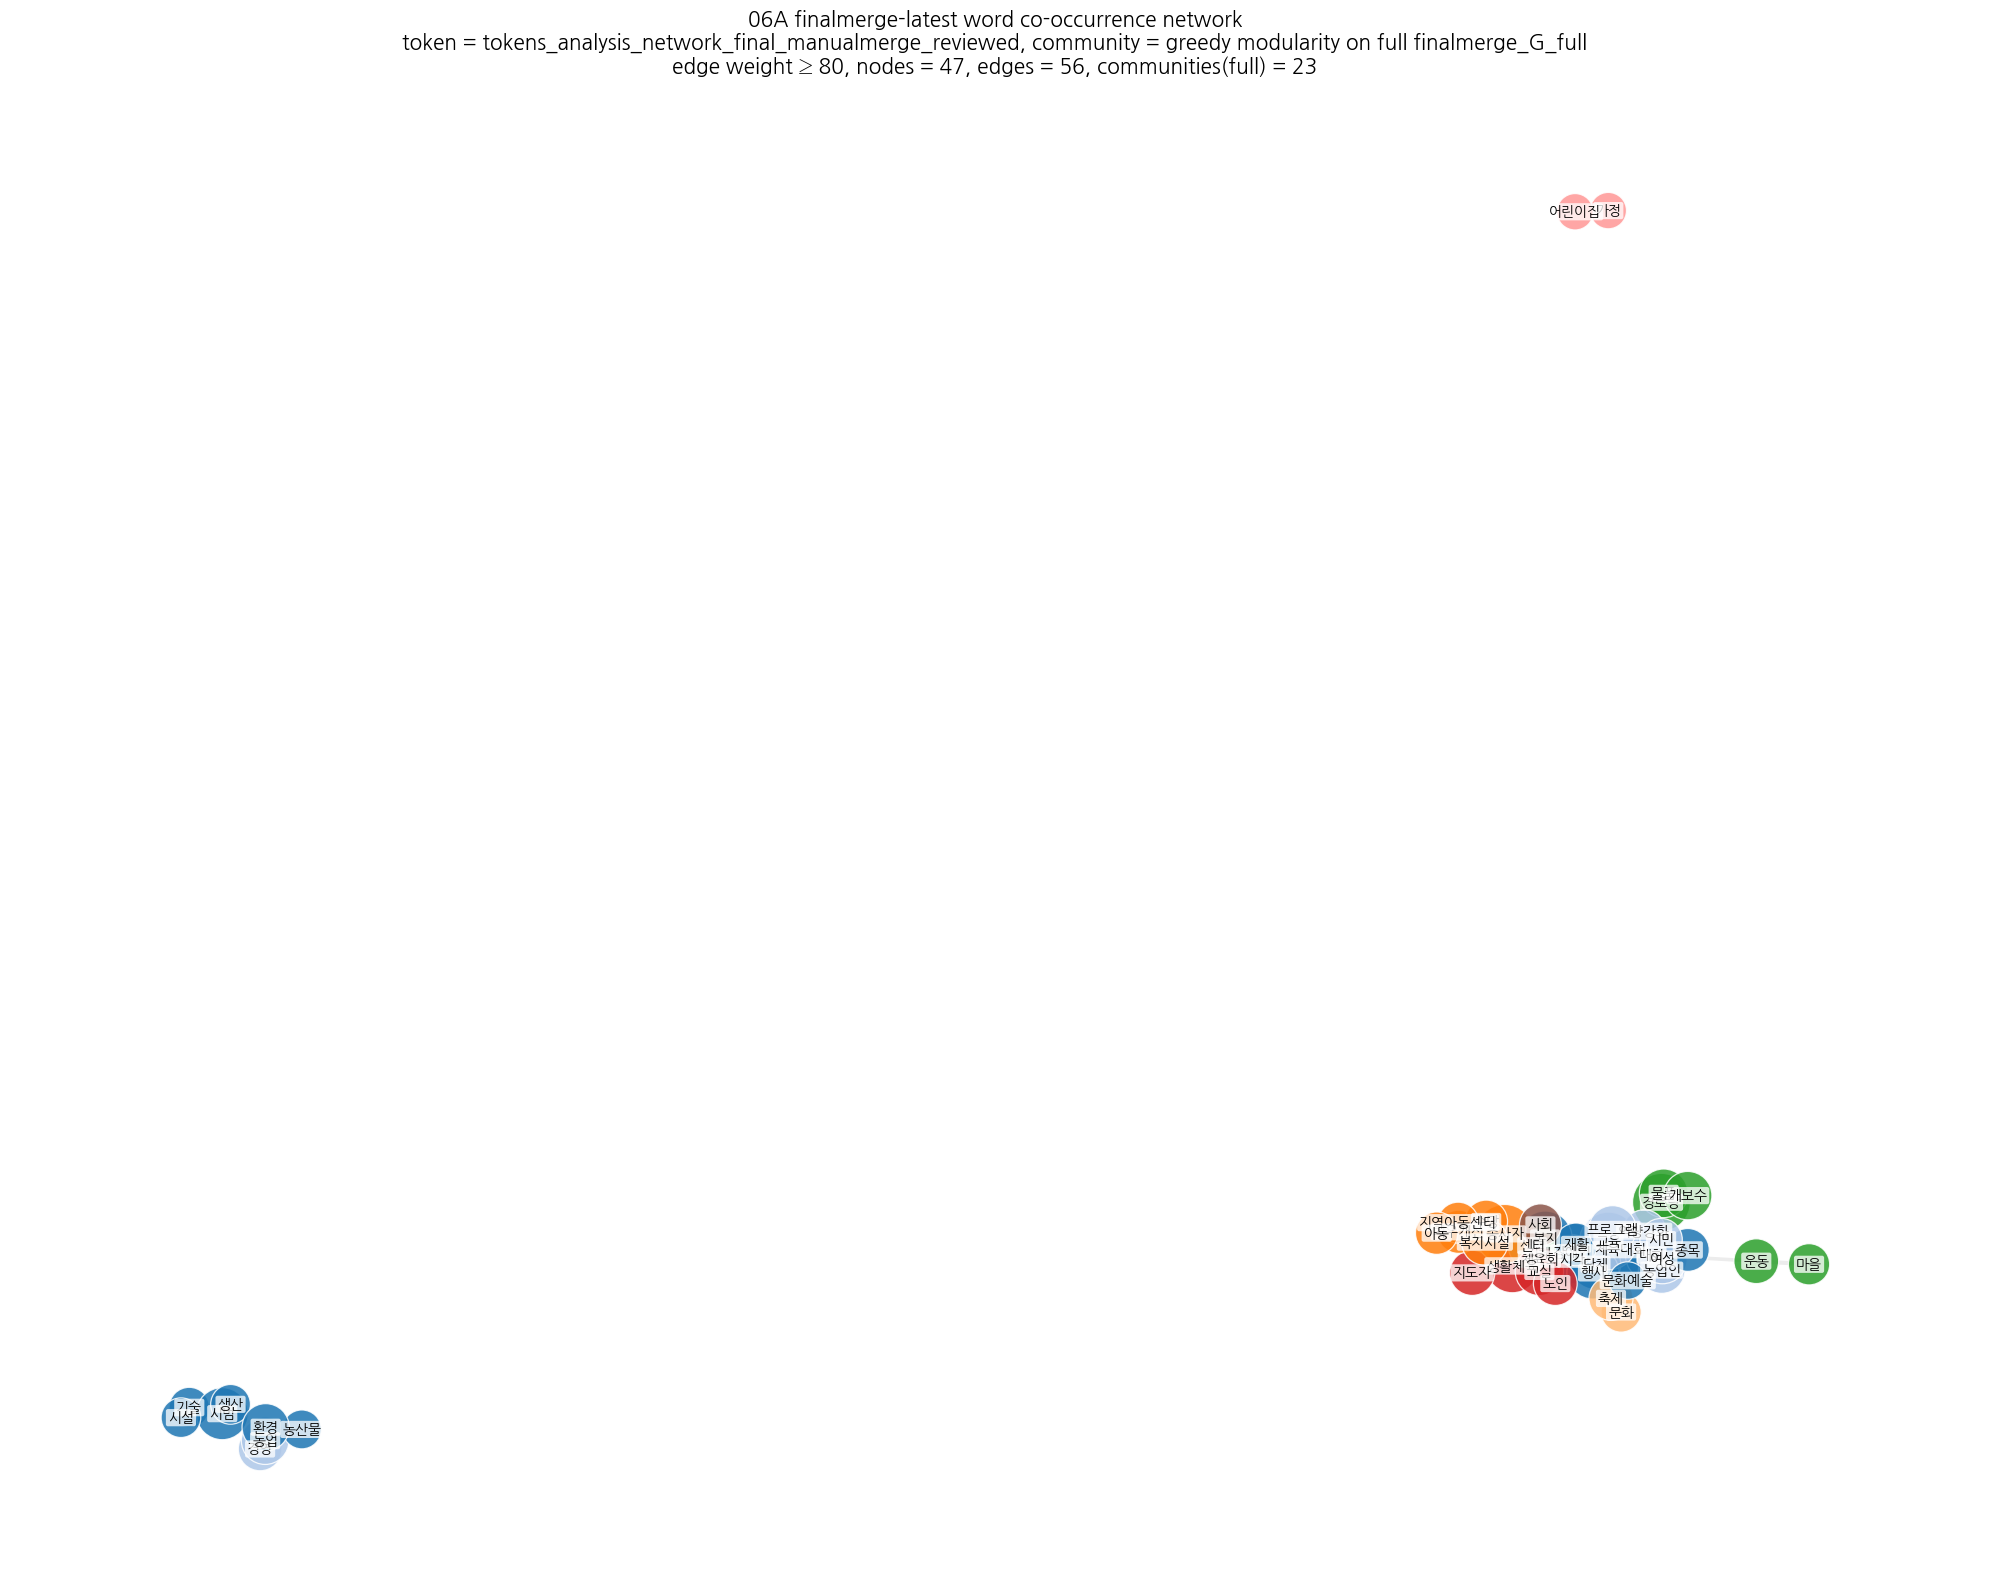


06A-APPEND-3E 완료
기존 06A-APPEND-3C, 06A-APPEND-3-FINAL-V2와 별개의 최신 수동 재결합+저정보 제거 시각화입니다.


In [20]:
# 06A-APPEND-3E. 최신 수동 재결합+저정보 제거 결과 전용 시각화
# 목적:
# - 06A-APPEND-2E에서 생성한 finalmerge_G_full을 별도로 시각화합니다.
# - 기존 06A-APPEND-3C, 06A-APPEND-3-FINAL-V2와 구분되도록
#   변수명과 저장 파일명에 finalmerge_latest를 사용합니다.
# - 전체 finalmerge_G_full 기준 greedy modularity community_id를 색상 기준으로 사용합니다.
#
# 실행 전제:
# - 06A-APPEND-2E 실행 완료

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

# 전체 노드 라벨 표시 여부
SHOW_ALL_LABELS = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "finalmerge_G_full" not in globals():
    raise NameError("finalmerge_G_full이 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "finalmerge_edge_df" not in globals():
    raise NameError("finalmerge_edge_df가 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "finalmerge_node_df" not in globals():
    raise NameError("finalmerge_node_df가 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "FINALMERGE_TOKEN_COL" not in globals():
    FINALMERGE_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed"

print("\n[현재 시각화 기준 토큰열]")
print(FINALMERGE_TOKEN_COL)

if finalmerge_G_full.number_of_nodes() == 0:
    raise ValueError("finalmerge_G_full에 노드가 없습니다.")

if finalmerge_G_full.number_of_edges() == 0:
    raise ValueError("finalmerge_G_full에 엣지가 없습니다.")

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각 설정
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_FINALMERGE_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_FINALMERGE_VIS:", RUN_TS_FINALMERGE_VIS)

# ------------------------------------------------------------
# 2) 시각화 기준 설정
# ------------------------------------------------------------
# 기존 3C와 비교 가능하도록 기본값은 55 / 80으로 둡니다.
# 더 넓게 보고 싶으면 75 / 60 정도로 조정하세요.

FINALMERGE_VIS_MIN_EDGE_WEIGHT = 80
FINALMERGE_VIS_TOP_N_NODES = 55

# SHOW_ALL_LABELS=False일 때만 적용
FINALMERGE_VIS_LABEL_TOP_N = 35

FINALMERGE_VIS_FIGSIZE = (20, 16)
FINALMERGE_VIS_SEED = 42

print("\n[최신 finalmerge 시각화 기준]")
print("FINALMERGE_VIS_MIN_EDGE_WEIGHT:", FINALMERGE_VIS_MIN_EDGE_WEIGHT)
print("FINALMERGE_VIS_TOP_N_NODES:", FINALMERGE_VIS_TOP_N_NODES)
print("FINALMERGE_VIS_LABEL_TOP_N:", FINALMERGE_VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 finalmerge_G_full 기준 community detection
# ------------------------------------------------------------

finalmerge_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        finalmerge_G_full,
        weight="weight"
    )
)

finalmerge_node_to_community_full = {}

for community_id, community_nodes in enumerate(finalmerge_communities_full):
    for node in community_nodes:
        finalmerge_node_to_community_full[node] = community_id

finalmerge_node_df_for_plot = finalmerge_node_df.copy()

finalmerge_node_df_for_plot["community_id"] = finalmerge_node_df_for_plot["word"].map(
    finalmerge_node_to_community_full
)

finalmerge_node_df_for_plot["community_id"] = (
    finalmerge_node_df_for_plot["community_id"]
    .fillna(-1)
    .astype(int)
)

finalmerge_community_count_full = len(finalmerge_communities_full)

print("\n[전체 finalmerge_G_full 기준 커뮤니티 탐지 결과]")
print("finalmerge_G_full node 수:", finalmerge_G_full.number_of_nodes())
print("finalmerge_G_full edge 수:", finalmerge_G_full.number_of_edges())
print("community 수:", finalmerge_community_count_full)

finalmerge_community_summary_rows = []

for community_id, community_nodes in enumerate(finalmerge_communities_full):
    community_nodes = list(community_nodes)

    sub_df = finalmerge_node_df_for_plot[
        finalmerge_node_df_for_plot["word"].isin(community_nodes)
    ].copy()

    sub_df = sub_df.sort_values(
        ["weighted_degree", "doc_freq_unique"],
        ascending=[False, False]
    )

    top_words = sub_df["word"].head(25).tolist()

    finalmerge_community_summary_rows.append({
        "community_id": community_id,
        "node_count": len(community_nodes),
        "top_words": ", ".join(top_words)
    })

finalmerge_community_summary_df = pd.DataFrame(finalmerge_community_summary_rows)

print("\n[최신 finalmerge community별 대표 단어]")
display(finalmerge_community_summary_df)

# ------------------------------------------------------------
# 5) 시각화용 노드/엣지 선정
# ------------------------------------------------------------

finalmerge_top_nodes = set(
    finalmerge_node_df_for_plot
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(FINALMERGE_VIS_TOP_N_NODES)["word"]
)

finalmerge_vis_edge_df = finalmerge_edge_df[
    (finalmerge_edge_df["weight"] >= FINALMERGE_VIS_MIN_EDGE_WEIGHT)
    & finalmerge_edge_df["source"].isin(finalmerge_top_nodes)
    & finalmerge_edge_df["target"].isin(finalmerge_top_nodes)
].copy()

if len(finalmerge_vis_edge_df) < 30:
    print("\n주의: edge가 너무 적어 기준을 60으로 완화합니다.")
    FINALMERGE_VIS_MIN_EDGE_WEIGHT = 60

    finalmerge_vis_edge_df = finalmerge_edge_df[
        (finalmerge_edge_df["weight"] >= FINALMERGE_VIS_MIN_EDGE_WEIGHT)
        & finalmerge_edge_df["source"].isin(finalmerge_top_nodes)
        & finalmerge_edge_df["target"].isin(finalmerge_top_nodes)
    ].copy()

finalmerge_G_vis = nx.Graph()

for _, row in finalmerge_vis_edge_df.iterrows():
    finalmerge_G_vis.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

finalmerge_G_vis.remove_nodes_from(list(nx.isolates(finalmerge_G_vis)))

print("\n[최신 finalmerge 시각화용 graph]")
print("node 수:", finalmerge_G_vis.number_of_nodes())
print("edge 수:", finalmerge_G_vis.number_of_edges())

if finalmerge_G_vis.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다.")

# ------------------------------------------------------------
# 6) 시각화 포함 노드 community_id 확인
# ------------------------------------------------------------

finalmerge_vis_node_community_rows = []

for node in finalmerge_G_vis.nodes():
    finalmerge_vis_node_community_rows.append({
        "word": node,
        "community_id": finalmerge_node_to_community_full.get(node, -1),
        "doc_freq_unique": finalmerge_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": finalmerge_G_vis.degree(node, weight="weight")
    })

finalmerge_vis_node_community_df = (
    pd.DataFrame(finalmerge_vis_node_community_rows)
    .sort_values(["community_id", "weighted_degree_in_vis"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\n[최신 finalmerge 시각화 포함 노드 community_id]")
display(finalmerge_vis_node_community_df)

finalmerge_vis_community_count = finalmerge_vis_node_community_df["community_id"].nunique()
print("\n시각화에 포함된 community 수:", finalmerge_vis_community_count)

# ------------------------------------------------------------
# 7) community_id 기반 색상 지정
# ------------------------------------------------------------

cmap = plt.get_cmap("tab20", max(finalmerge_community_count_full, 1))

finalmerge_node_colors = []

for node in finalmerge_G_vis.nodes():
    community_id = finalmerge_node_to_community_full.get(node, -1)

    if community_id == -1:
        finalmerge_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        finalmerge_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 8) 레이아웃 계산
# ------------------------------------------------------------

finalmerge_pos = nx.spring_layout(
    finalmerge_G_vis,
    seed=FINALMERGE_VIS_SEED,
    weight="weight",
    k=1.35 / np.sqrt(max(finalmerge_G_vis.number_of_nodes(), 1)),
    iterations=400
)

finalmerge_weighted_degree_vis = dict(finalmerge_G_vis.degree(weight="weight"))

finalmerge_node_sizes = []

for node in finalmerge_G_vis.nodes():
    wd = finalmerge_weighted_degree_vis.get(node, 1)
    size = 180 + np.sqrt(wd) * 55
    size = max(220, min(size, 1800))
    finalmerge_node_sizes.append(size)

finalmerge_edge_weights = [
    finalmerge_G_vis[u][v]["weight"]
    for u, v in finalmerge_G_vis.edges()
]

finalmerge_edge_widths = [
    max(0.4, min(np.log1p(w) / 1.7, 3.6))
    for w in finalmerge_edge_weights
]

# ------------------------------------------------------------
# 9) 라벨 표시 대상 설정
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    finalmerge_label_nodes = set(finalmerge_G_vis.nodes())
    LABEL_FONT_SIZE = 10
else:
    finalmerge_label_nodes = set(
        finalmerge_node_df_for_plot
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(FINALMERGE_VIS_LABEL_TOP_N)["word"]
    )
    LABEL_FONT_SIZE = 12

finalmerge_labels = {
    node: node
    for node in finalmerge_G_vis.nodes()
    if node in finalmerge_label_nodes
}

print("\n[라벨 표시]")
print("표시 라벨 수:", len(finalmerge_labels))

# ------------------------------------------------------------
# 10) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=FINALMERGE_VIS_FIGSIZE)

nx.draw_networkx_edges(
    finalmerge_G_vis,
    finalmerge_pos,
    width=finalmerge_edge_widths,
    alpha=0.15,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    finalmerge_G_vis,
    finalmerge_pos,
    node_size=finalmerge_node_sizes,
    alpha=0.86,
    node_color=finalmerge_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LABEL_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=15)

for node, label in finalmerge_labels.items():
    x, y = finalmerge_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LABEL_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.76,
            boxstyle="round,pad=0.15"
        ),
        zorder=10
    )

ax.set_title(
    "06A finalmerge-latest word co-occurrence network\n"
    f"token = {FINALMERGE_TOKEN_COL}, "
    f"community = greedy modularity on full finalmerge_G_full\n"
    f"edge weight ≥ {FINALMERGE_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {finalmerge_G_vis.number_of_nodes()}, "
    f"edges = {finalmerge_G_vis.number_of_edges()}, "
    f"communities(full) = {finalmerge_community_count_full}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_finalmerge = (
        FIGURE_REVIEW_DIR
        / f"06A_finalmerge_latest_network_preview_{RUN_VERSION}_{RUN_TS_FINALMERGE_VIS}.png"
    )

    out_community_finalmerge = (
        TABLE_REVIEW_DIR
        / f"06A_finalmerge_latest_community_full_{RUN_VERSION}_{RUN_TS_FINALMERGE_VIS}.csv"
    )

    out_vis_node_finalmerge = (
        TABLE_REVIEW_DIR
        / f"06A_finalmerge_latest_vis_node_community_{RUN_VERSION}_{RUN_TS_FINALMERGE_VIS}.csv"
    )

    plt.savefig(out_png_finalmerge, dpi=260, bbox_inches="tight")

    finalmerge_community_summary_df.to_csv(
        out_community_finalmerge,
        index=False,
        encoding="utf-8-sig"
    )

    finalmerge_vis_node_community_df.to_csv(
        out_vis_node_finalmerge,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[최신 finalmerge 시각화 저장 완료]")
    print("- PNG:", out_png_finalmerge)
    print("- full community summary:", out_community_finalmerge)
    print("- vis node community:", out_vis_node_finalmerge)

plt.show()

print("\n06A-APPEND-3E 완료")
print("기존 06A-APPEND-3C, 06A-APPEND-3-FINAL-V2와 별개의 최신 수동 재결합+저정보 제거 시각화입니다.")

### 06A-APPEND-3E-FIX. finalmerge 최신 결과 component-aware 가시성 개선 시각화

SAVE_OUTPUT: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_manualmerge_reviewed

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_FINALMERGE_FIX_VIS: 20260611_2230

[가시성 개선 시각화 기준]
COMPONENT_MODE: top_k
TOP_K_COMPONENTS: 5
MIN_COMPONENT_SIZE: 2
FIX_VIS_TOP_N_NODES: 75
FIX_VIS_MIN_EDGE_WEIGHT: 60
SHOW_ALL_LABELS: True
FIX_VIS_LABEL_TOP_N: 45

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 finalmerge_G_full 기준 커뮤니티]
finalmerge_G_full node 수: 314
finalmerge_G_full edge 수: 600
community 수: 23

[component 요약]


,component_raw_id,node_count,edge_count,edge_weight_sum,top_nodes
0,0,67,105,13449.0,"장애인, 교육, 시범, 대회, 종사자, 행사, 센터, 체육대회, 복지, 경로당, 생..."
1,1,3,3,285.0,"어린이집, 가정, 민간"



[선택된 시각화용 graph]
node 수: 70
edge 수: 108
선택 component raw ids: [0, 1]

[라벨 표시]
표시 라벨 수: 70

[시각화 포함 노드]


,word,component_id,community_id,doc_freq_unique,weighted_degree_in_vis
0,시범,0,0,1449,969.0
1,환경,0,0,1197,393.0
2,원예,0,0,354,312.0
3,품질,0,0,414,301.0
4,시설,0,0,1249,273.0
...,...,...,...,...,...
65,노인,0,7,1220,286.0
66,사회,0,11,599,178.0
67,민간,1,8,348,200.0
68,어린이집,1,8,1280,196.0



[component-aware 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_finalmerge_latest_network_componentfix_v1_20260611_2230.png
- component summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_finalmerge_latest_component_summary_v1_20260611_2230.csv
- vis nodes: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_finalmerge_latest_componentfix_vis_nodes_v1_20260611_2230.csv


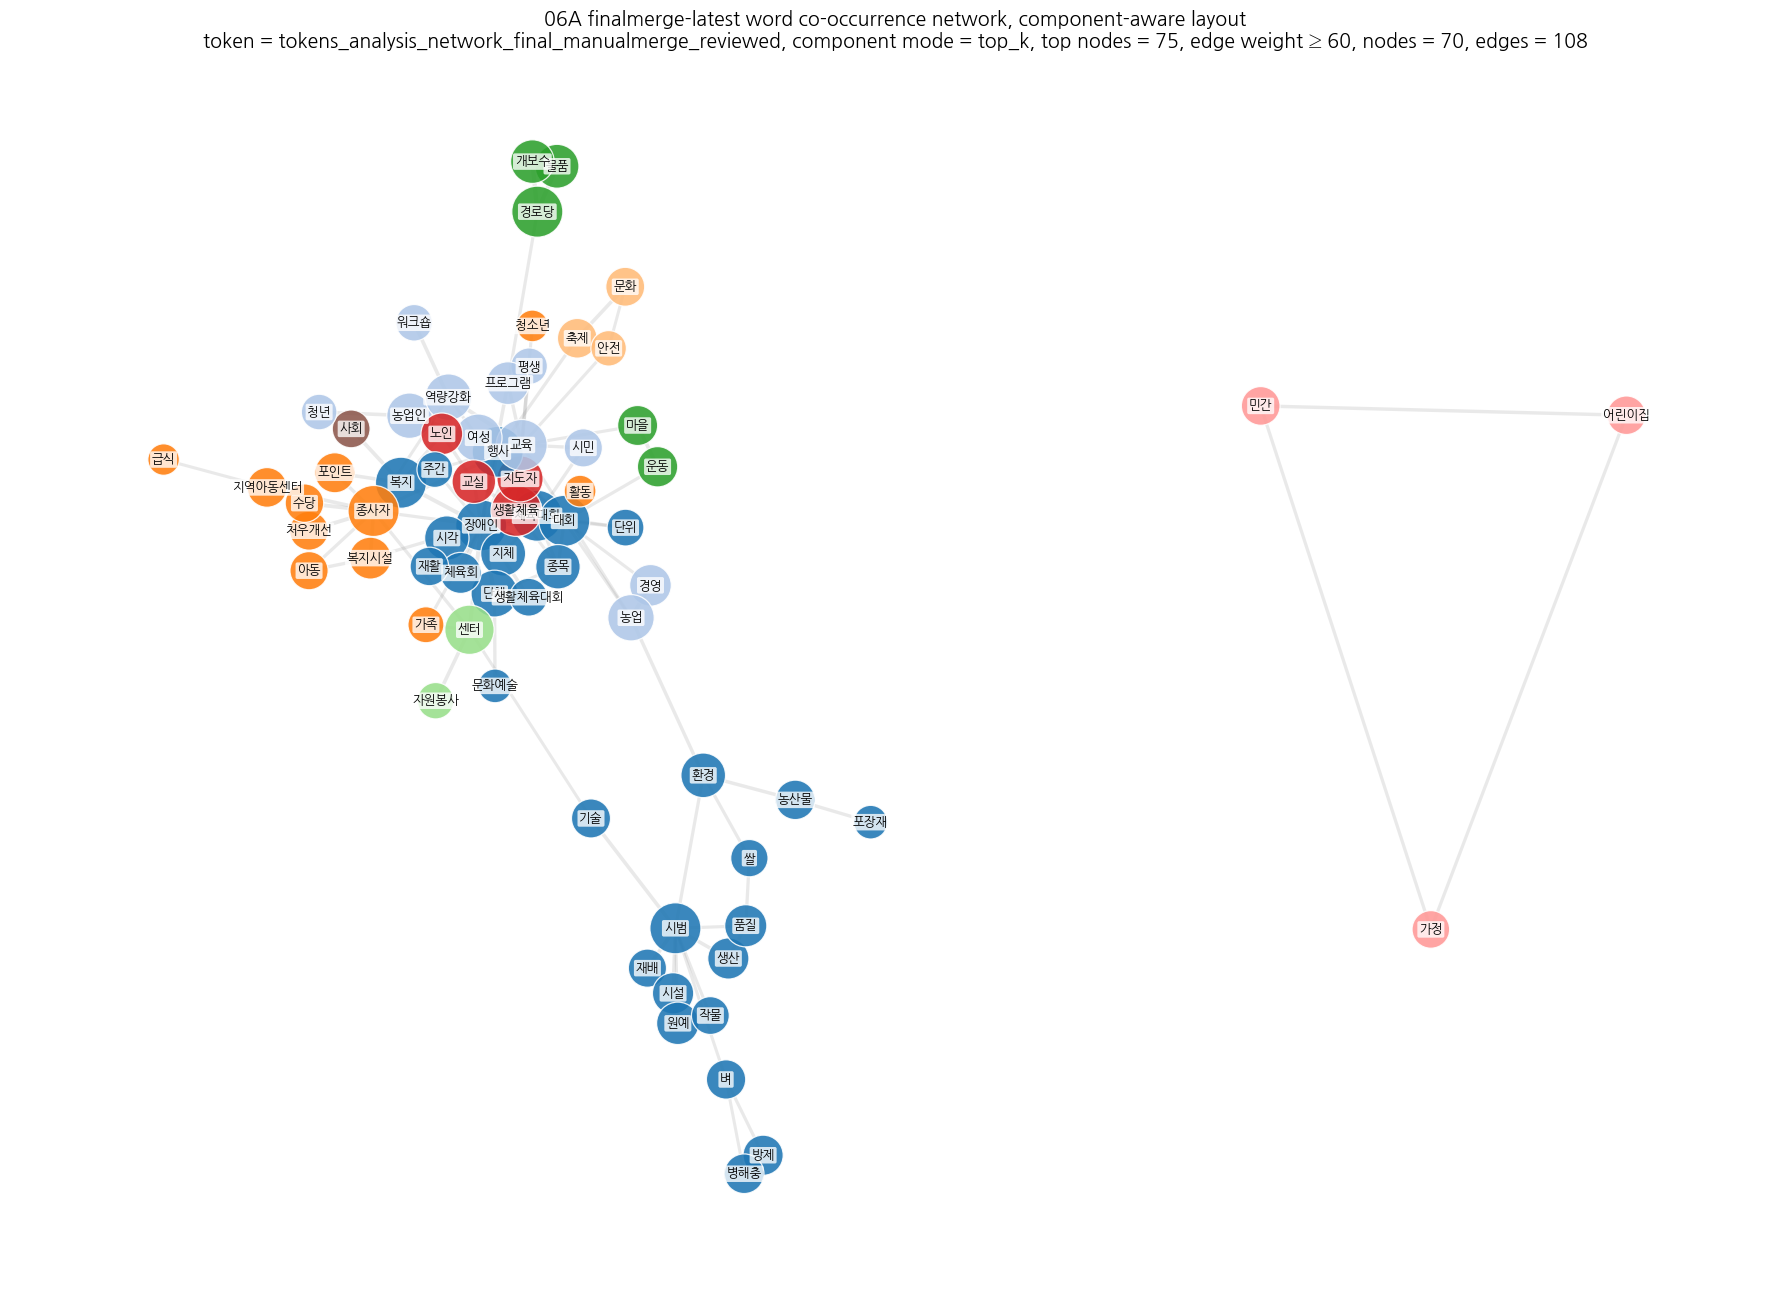


06A-APPEND-3E-FIX 완료


In [21]:
# 06A-APPEND-3E-FIX. finalmerge 최신 결과 component-aware 가시성 개선 시각화
# 목적:
# - 06A-APPEND-2E에서 생성한 finalmerge_G_full을 사용합니다.
# - 기존 06A-APPEND-3E와 구분하기 위해 별도 변수명과 저장 파일명을 사용합니다.
# - disconnected component가 화면 밖으로 퍼지는 문제를 줄이기 위해
#   component별로 레이아웃을 계산하고 화면 안에 재배치합니다.
#
# 실행 전제:
# - 06A-APPEND-1E 실행 완료
# - 06A-APPEND-2E 실행 완료
# - finalmerge_G_full, finalmerge_edge_df, finalmerge_node_df 존재

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil
import math

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "finalmerge_G_full" not in globals():
    raise NameError("finalmerge_G_full이 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "finalmerge_edge_df" not in globals():
    raise NameError("finalmerge_edge_df가 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "finalmerge_node_df" not in globals():
    raise NameError("finalmerge_node_df가 없습니다. 06A-APPEND-2E를 먼저 실행하세요.")

if "FINALMERGE_TOKEN_COL" not in globals():
    FINALMERGE_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed"

print("\n[현재 시각화 기준 토큰열]")
print(FINALMERGE_TOKEN_COL)

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각 설정
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_FINALMERGE_FIX_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_FINALMERGE_FIX_VIS:", RUN_TS_FINALMERGE_FIX_VIS)

# ------------------------------------------------------------
# 2) 가시성 개선 설정
# ------------------------------------------------------------
# COMPONENT_MODE:
# - "top_k"   : 큰 component 몇 개만 표시
# - "largest" : 가장 큰 component 하나만 표시
# - "all"     : 모든 component 표시
#
# 추천:
# - 논문/보고서용 기본 그림: "top_k"
# - 중심 구조만 보고 싶을 때: "largest"
# - 전체 분리 구조 확인용: "all"

COMPONENT_MODE = "top_k"
TOP_K_COMPONENTS = 5
MIN_COMPONENT_SIZE = 2

# 기존보다 조금 넓게 잡되, 너무 복잡하지 않게 설정
FIX_VIS_TOP_N_NODES = 75
FIX_VIS_MIN_EDGE_WEIGHT = 60

# 라벨 기준
SHOW_ALL_LABELS = True
FIX_VIS_LABEL_TOP_N = 45

FIX_VIS_FIGSIZE = (18, 13)
FIX_VIS_SEED = 42

print("\n[가시성 개선 시각화 기준]")
print("COMPONENT_MODE:", COMPONENT_MODE)
print("TOP_K_COMPONENTS:", TOP_K_COMPONENTS)
print("MIN_COMPONENT_SIZE:", MIN_COMPONENT_SIZE)
print("FIX_VIS_TOP_N_NODES:", FIX_VIS_TOP_N_NODES)
print("FIX_VIS_MIN_EDGE_WEIGHT:", FIX_VIS_MIN_EDGE_WEIGHT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("FIX_VIS_LABEL_TOP_N:", FIX_VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 finalmerge_G_full 기준 community detection
# ------------------------------------------------------------

fix_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        finalmerge_G_full,
        weight="weight"
    )
)

fix_node_to_community_full = {}

for community_id, community_nodes in enumerate(fix_communities_full):
    for node in community_nodes:
        fix_node_to_community_full[node] = community_id

fix_community_count_full = len(fix_communities_full)

print("\n[전체 finalmerge_G_full 기준 커뮤니티]")
print("finalmerge_G_full node 수:", finalmerge_G_full.number_of_nodes())
print("finalmerge_G_full edge 수:", finalmerge_G_full.number_of_edges())
print("community 수:", fix_community_count_full)

# ------------------------------------------------------------
# 5) 시각화용 그래프 생성
# ------------------------------------------------------------

fix_node_df_for_plot = finalmerge_node_df.copy()

fix_node_df_for_plot["community_id"] = fix_node_df_for_plot["word"].map(
    fix_node_to_community_full
)

fix_node_df_for_plot["community_id"] = (
    fix_node_df_for_plot["community_id"]
    .fillna(-1)
    .astype(int)
)

fix_top_nodes = set(
    fix_node_df_for_plot
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(FIX_VIS_TOP_N_NODES)["word"]
)

fix_vis_edge_df = finalmerge_edge_df[
    (finalmerge_edge_df["weight"] >= FIX_VIS_MIN_EDGE_WEIGHT)
    & finalmerge_edge_df["source"].isin(fix_top_nodes)
    & finalmerge_edge_df["target"].isin(fix_top_nodes)
].copy()

fix_G_candidate = nx.Graph()

for _, row in fix_vis_edge_df.iterrows():
    fix_G_candidate.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

fix_G_candidate.remove_nodes_from(list(nx.isolates(fix_G_candidate)))

if fix_G_candidate.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다. FIX_VIS_MIN_EDGE_WEIGHT를 낮춰보세요.")

# ------------------------------------------------------------
# 6) component 선택
# ------------------------------------------------------------

components = list(nx.connected_components(fix_G_candidate))

component_info_rows = []

for idx, comp in enumerate(components):
    sub_g = fix_G_candidate.subgraph(comp).copy()
    edge_weight_sum = sum(
        data.get("weight", 1)
        for _, _, data in sub_g.edges(data=True)
    )

    component_info_rows.append({
        "component_raw_id": idx,
        "node_count": sub_g.number_of_nodes(),
        "edge_count": sub_g.number_of_edges(),
        "edge_weight_sum": edge_weight_sum,
        "top_nodes": ", ".join(
            fix_node_df_for_plot[
                fix_node_df_for_plot["word"].isin(comp)
            ]
            .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
            ["word"]
            .head(15)
            .tolist()
        )
    })

fix_component_summary_df = (
    pd.DataFrame(component_info_rows)
    .sort_values(["node_count", "edge_weight_sum"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\n[component 요약]")
display(fix_component_summary_df)

# 선택할 component raw id 결정
if COMPONENT_MODE == "largest":
    selected_component_raw_ids = fix_component_summary_df.head(1)["component_raw_id"].tolist()
elif COMPONENT_MODE == "top_k":
    selected_component_raw_ids = fix_component_summary_df[
        fix_component_summary_df["node_count"] >= MIN_COMPONENT_SIZE
    ].head(TOP_K_COMPONENTS)["component_raw_id"].tolist()
elif COMPONENT_MODE == "all":
    selected_component_raw_ids = fix_component_summary_df[
        fix_component_summary_df["node_count"] >= MIN_COMPONENT_SIZE
    ]["component_raw_id"].tolist()
else:
    raise ValueError("COMPONENT_MODE는 'largest', 'top_k', 'all' 중 하나여야 합니다.")

selected_nodes = set()

for raw_id in selected_component_raw_ids:
    selected_nodes.update(components[raw_id])

fix_G_vis = fix_G_candidate.subgraph(selected_nodes).copy()

print("\n[선택된 시각화용 graph]")
print("node 수:", fix_G_vis.number_of_nodes())
print("edge 수:", fix_G_vis.number_of_edges())
print("선택 component raw ids:", selected_component_raw_ids)

# ------------------------------------------------------------
# 7) component-aware layout 계산
# ------------------------------------------------------------

def normalize_component_pos(pos_dict, scale=1.0):
    xs = np.array([p[0] for p in pos_dict.values()])
    ys = np.array([p[1] for p in pos_dict.values()])

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    x_range = max(x_max - x_min, 1e-9)
    y_range = max(y_max - y_min, 1e-9)

    out = {}

    for node, (x, y) in pos_dict.items():
        x_norm = ((x - x_min) / x_range - 0.5) * 2 * scale
        y_norm = ((y - y_min) / y_range - 0.5) * 2 * scale
        out[node] = np.array([x_norm, y_norm])

    return out

selected_components = list(nx.connected_components(fix_G_vis))
selected_components = sorted(selected_components, key=lambda c: len(c), reverse=True)

n_components = len(selected_components)
grid_cols = min(3, max(1, math.ceil(math.sqrt(n_components))))
grid_rows = math.ceil(n_components / grid_cols)

x_gap = 3.8
y_gap = 3.0

fix_pos = {}

for comp_idx, comp_nodes in enumerate(selected_components):
    sub_g = fix_G_vis.subgraph(comp_nodes).copy()
    n_nodes = sub_g.number_of_nodes()

    if n_nodes == 1:
        local_pos = {list(sub_g.nodes())[0]: np.array([0.0, 0.0])}
    else:
        local_pos = nx.spring_layout(
            sub_g,
            seed=FIX_VIS_SEED + comp_idx,
            weight="weight",
            k=1.25 / np.sqrt(max(n_nodes, 1)),
            iterations=450
        )

    # component 크기에 따라 scale 조정
    comp_scale = max(0.75, min(1.45, np.sqrt(n_nodes) / 3.0))
    local_pos = normalize_component_pos(local_pos, scale=comp_scale)

    row = comp_idx // grid_cols
    col = comp_idx % grid_cols

    x_offset = (col - (grid_cols - 1) / 2) * x_gap
    y_offset = ((grid_rows - 1) / 2 - row) * y_gap

    for node, xy in local_pos.items():
        fix_pos[node] = xy + np.array([x_offset, y_offset])

# ------------------------------------------------------------
# 8) 노드 크기, 엣지 굵기, 색상
# ------------------------------------------------------------

fix_weighted_degree_vis = dict(fix_G_vis.degree(weight="weight"))

fix_node_sizes = []

for node in fix_G_vis.nodes():
    wd = fix_weighted_degree_vis.get(node, 1)
    size = 140 + np.sqrt(wd) * 45
    size = max(190, min(size, 1350))
    fix_node_sizes.append(size)

fix_edge_weights = [
    fix_G_vis[u][v]["weight"]
    for u, v in fix_G_vis.edges()
]

fix_edge_widths = [
    max(0.35, min(np.log1p(w) / 1.9, 3.2))
    for w in fix_edge_weights
]

cmap = plt.get_cmap("tab20", max(fix_community_count_full, 1))

fix_node_colors = []

for node in fix_G_vis.nodes():
    community_id = fix_node_to_community_full.get(node, -1)

    if community_id == -1:
        fix_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        fix_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 9) 라벨 표시 대상
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    fix_label_nodes = set(fix_G_vis.nodes())
    LABEL_FONT_SIZE = 9
else:
    fix_label_nodes = set(
        fix_node_df_for_plot
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(FIX_VIS_LABEL_TOP_N)["word"]
    )
    LABEL_FONT_SIZE = 11

fix_labels = {
    node: node
    for node in fix_G_vis.nodes()
    if node in fix_label_nodes
}

print("\n[라벨 표시]")
print("표시 라벨 수:", len(fix_labels))

# ------------------------------------------------------------
# 10) 시각화 포함 노드 community_id 표
# ------------------------------------------------------------

fix_vis_node_community_rows = []

for node in fix_G_vis.nodes():
    fix_vis_node_community_rows.append({
        "word": node,
        "component_id": None,
        "community_id": fix_node_to_community_full.get(node, -1),
        "doc_freq_unique": finalmerge_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": fix_G_vis.degree(node, weight="weight")
    })

fix_vis_node_community_df = pd.DataFrame(fix_vis_node_community_rows)

# component id 부여
node_to_component_id = {}

for comp_idx, comp_nodes in enumerate(selected_components):
    for node in comp_nodes:
        node_to_component_id[node] = comp_idx

fix_vis_node_community_df["component_id"] = fix_vis_node_community_df["word"].map(
    node_to_component_id
)

fix_vis_node_community_df = (
    fix_vis_node_community_df
    .sort_values(["component_id", "community_id", "weighted_degree_in_vis"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n[시각화 포함 노드]")
display(fix_vis_node_community_df)

# ------------------------------------------------------------
# 11) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIX_VIS_FIGSIZE)

nx.draw_networkx_edges(
    fix_G_vis,
    fix_pos,
    width=fix_edge_widths,
    alpha=0.17,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    fix_G_vis,
    fix_pos,
    node_size=fix_node_sizes,
    alpha=0.88,
    node_color=fix_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LABEL_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=14)

for node, label in fix_labels.items():
    x, y = fix_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LABEL_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14"
        ),
        zorder=10
    )

ax.set_title(
    "06A finalmerge-latest word co-occurrence network, component-aware layout\n"
    f"token = {FINALMERGE_TOKEN_COL}, "
    f"component mode = {COMPONENT_MODE}, "
    f"top nodes = {FIX_VIS_TOP_N_NODES}, "
    f"edge weight ≥ {FIX_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {fix_G_vis.number_of_nodes()}, "
    f"edges = {fix_G_vis.number_of_edges()}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_fix = (
        FIGURE_REVIEW_DIR
        / f"06A_finalmerge_latest_network_componentfix_{RUN_VERSION}_{RUN_TS_FINALMERGE_FIX_VIS}.png"
    )

    out_component_fix = (
        TABLE_REVIEW_DIR
        / f"06A_finalmerge_latest_component_summary_{RUN_VERSION}_{RUN_TS_FINALMERGE_FIX_VIS}.csv"
    )

    out_vis_node_fix = (
        TABLE_REVIEW_DIR
        / f"06A_finalmerge_latest_componentfix_vis_nodes_{RUN_VERSION}_{RUN_TS_FINALMERGE_FIX_VIS}.csv"
    )

    plt.savefig(out_png_fix, dpi=260, bbox_inches="tight")

    fix_component_summary_df.to_csv(
        out_component_fix,
        index=False,
        encoding="utf-8-sig"
    )

    fix_vis_node_community_df.to_csv(
        out_vis_node_fix,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[component-aware 시각화 저장 완료]")
    print("- PNG:", out_png_fix)
    print("- component summary:", out_component_fix)
    print("- vis nodes:", out_vis_node_fix)

plt.show()

print("\n06A-APPEND-3E-FIX 완료")

### 06A-APPEND-1F. 1차 저정보 후보 추가 제거

In [22]:
# 06A-APPEND-1F. 1차 저정보 후보 추가 제거
# 목적:
# - 최신 수동 재결합+저정보 제거 토큰열을 보존합니다.
# - 비교용으로 '시범, 활동, 단체, 프로그램'만 추가 제거한 새 토큰열을 생성합니다.
#
# 입력:
# - tokens_analysis_network_final_manualmerge_reviewed
#
# 출력:
# - tokens_analysis_network_final_manualmerge_reviewed_lowinfo1
#
# 주의:
# - 이 셀은 06A 비교 시각화용입니다.
# - 최종 확정 후에는 03 노트북에 반영합니다.

import pandas as pd
import numpy as np
import ast

SOURCE_TOKEN_COL_LOWINFO1 = "tokens_analysis_network_final_manualmerge_reviewed"
TARGET_TOKEN_COL_LOWINFO1 = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo1"

EXTRA_LOWINFO_TOKENS_1 = [
    "시범",
    "활동",
    "단체",
    "프로그램",
]

print("[06A-APPEND-1F]")
print("입력 토큰열:", SOURCE_TOKEN_COL_LOWINFO1)
print("출력 토큰열:", TARGET_TOKEN_COL_LOWINFO1)
print("추가 제거 토큰:", EXTRA_LOWINFO_TOKENS_1)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1E를 먼저 실행하세요.")

if SOURCE_TOKEN_COL_LOWINFO1 not in df_03_review.columns:
    raise KeyError(f"{SOURCE_TOKEN_COL_LOWINFO1} 열이 없습니다. 06A-APPEND-1E를 먼저 실행하세요.")

if "ensure_token_list_local" not in globals():
    def ensure_token_list_local(x):
        if isinstance(x, list):
            return [str(t).strip() for t in x if str(t).strip() != ""]
        if isinstance(x, tuple):
            return [str(t).strip() for t in list(x) if str(t).strip() != ""]
        if isinstance(x, np.ndarray):
            return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]
        if x is None:
            return []
        try:
            if pd.isna(x):
                return []
        except Exception:
            pass
        if isinstance(x, str):
            x_strip = x.strip()
            if x_strip == "":
                return []
            try:
                parsed = ast.literal_eval(x_strip)
                if isinstance(parsed, list):
                    return [str(t).strip() for t in parsed if str(t).strip() != ""]
                if isinstance(parsed, tuple):
                    return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]
            except Exception:
                pass
            return [x_strip]
        return [str(x).strip()] if str(x).strip() != "" else []

extra_lowinfo_set_1 = set(EXTRA_LOWINFO_TOKENS_1)

df_03_review[SOURCE_TOKEN_COL_LOWINFO1] = df_03_review[SOURCE_TOKEN_COL_LOWINFO1].apply(
    ensure_token_list_local
)

def remove_lowinfo1(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok not in extra_lowinfo_set_1]

def get_removed_lowinfo1(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok in extra_lowinfo_set_1]

df_03_review[TARGET_TOKEN_COL_LOWINFO1] = df_03_review[SOURCE_TOKEN_COL_LOWINFO1].apply(
    remove_lowinfo1
)

df_03_review["tokens_network_extra_removed_lowinfo1"] = df_03_review[
    SOURCE_TOKEN_COL_LOWINFO1
].apply(get_removed_lowinfo1)

df_03_review[f"{TARGET_TOKEN_COL_LOWINFO1}_count"] = df_03_review[
    TARGET_TOKEN_COL_LOWINFO1
].apply(len)

df_03_review[f"{TARGET_TOKEN_COL_LOWINFO1}_empty"] = df_03_review[
    TARGET_TOKEN_COL_LOWINFO1
].apply(lambda x: len(x) == 0)

lowinfo1_removed_rows = df_03_review["tokens_network_extra_removed_lowinfo1"].apply(len).gt(0).sum()
lowinfo1_removed_total = df_03_review["tokens_network_extra_removed_lowinfo1"].apply(len).sum()
lowinfo1_empty_rows = df_03_review[f"{TARGET_TOKEN_COL_LOWINFO1}_empty"].sum()

lowinfo1_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "출력 토큰열",
        "추가 제거 토큰",
        "추가 제거 발생 행 수",
        "추가 제거 총 횟수",
        "출력 빈 토큰 행 수"
    ],
    "값": [
        SOURCE_TOKEN_COL_LOWINFO1,
        TARGET_TOKEN_COL_LOWINFO1,
        ", ".join(EXTRA_LOWINFO_TOKENS_1),
        int(lowinfo1_removed_rows),
        int(lowinfo1_removed_total),
        int(lowinfo1_empty_rows)
    ]
})

print("\n[1차 추가 저정보 제거 요약]")
display(lowinfo1_summary)

print("\n[1차 추가 제거 사례 상위 50개]")
display_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "사업명",
    SOURCE_TOKEN_COL_LOWINFO1,
    TARGET_TOKEN_COL_LOWINFO1,
    "tokens_network_extra_removed_lowinfo1"
]
display_cols = [col for col in display_cols if col in df_03_review.columns]

display(
    df_03_review[
        df_03_review["tokens_network_extra_removed_lowinfo1"].apply(len).gt(0)
    ][display_cols].head(50)
)

print("\n06A-APPEND-1F 완료")

[06A-APPEND-1F]
입력 토큰열: tokens_analysis_network_final_manualmerge_reviewed
출력 토큰열: tokens_analysis_network_final_manualmerge_reviewed_lowinfo1
추가 제거 토큰: ['시범', '활동', '단체', '프로그램']

[1차 추가 저정보 제거 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_manualmerge_revi...
1,출력 토큰열,tokens_analysis_network_final_manualmerge_revi...
2,추가 제거 토큰,"시범, 활동, 단체, 프로그램"
3,추가 제거 발생 행 수,4872
4,추가 제거 총 횟수,4978
5,출력 빈 토큰 행 수,119



[1차 추가 제거 사례 상위 50개]


,v1_row_id,시도,지자체명,사업명,tokens_analysis_network_final_manualmerge_reviewed,tokens_analysis_network_final_manualmerge_reviewed_lowinfo1,tokens_network_extra_removed_lowinfo1
36,36,경남,남해군,전몰군경유족회 단체 운영 및 전몰장병 유지 선양,"[전몰군경유족회, 단체, 전몰, 장병, 유지, 선양]","[전몰군경유족회, 전몰, 장병, 유지, 선양]",[단체]
38,38,경남,남해군,6.25참전유공자회 단체 운영,"[6.25참전유공자, 단체]",[6.25참전유공자],[단체]
40,40,경남,남해군,독립유공자(광복회경남지부) 단체운영 및 민족정기선양사업,"[독립, 유공자, 광복회경남지부, 단체, 민족정기, 선양]","[독립, 유공자, 광복회경남지부, 민족정기, 선양]",[단체]
50,50,경남,남해군,노인회 분회 활동 지원,"[노인회, 분회, 활동]","[노인회, 분회]",[활동]
58,58,경남,남해군,요보호아동 명절위문활동 지원,"[보호, 아동, 명절, 위문, 활동]","[보호, 아동, 명절, 위문]",[활동]
75,75,경남,남해군,우수 체육단체 활동 지원,"[체육단체, 활동]",[체육단체],[활동]
119,119,경남,남해군,지역아동센터 특성화 프로그램 운영,"[지역아동센터, 특성, 프로그램]","[지역아동센터, 특성]",[프로그램]
128,128,경남,남해군,종목단체 육성 지원,"[종목, 단체]",[종목],[단체]
147,147,경남,남해군,상이군경회 단체 운영비 및 참전유공자 선양사업,"[상이, 군경, 단체, 참전유공자, 선양]","[상이, 군경, 참전유공자, 선양]",[단체]
215,215,경남,남해군,우수 체육단체(개인) 활동 지원,"[체육단체, 개인, 활동]","[체육단체, 개인]",[활동]



06A-APPEND-1F 완료


In [23]:
# 06A-APPEND-2F. 1차 추가 제거 토큰열로 네트워크 생성
# 목적:
# - tokens_analysis_network_final_manualmerge_reviewed_lowinfo1 기준으로
#   단어 동시출현 네트워크를 생성합니다.
# - 기존 finalmerge_G_full, reviewed_G 등을 덮어쓰지 않고,
#   lowinfo1_G_full, lowinfo1_edge_df, lowinfo1_node_df 등 별도 변수명을 사용합니다.

from collections import Counter
from itertools import combinations
import pandas as pd
import numpy as np
import networkx as nx

LOWINFO1_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo1"

LOWINFO1_MIN_DOC_FREQ = 100
LOWINFO1_MIN_EDGE_WEIGHT_FOR_TABLE = 1
LOWINFO1_MIN_EDGE_WEIGHT_FOR_GRAPH = 30

print("[06A-APPEND-2F 네트워크 생성 기준]")
print("LOWINFO1_TOKEN_COL:", LOWINFO1_TOKEN_COL)
print("LOWINFO1_MIN_DOC_FREQ:", LOWINFO1_MIN_DOC_FREQ)
print("LOWINFO1_MIN_EDGE_WEIGHT_FOR_TABLE:", LOWINFO1_MIN_EDGE_WEIGHT_FOR_TABLE)
print("LOWINFO1_MIN_EDGE_WEIGHT_FOR_GRAPH:", LOWINFO1_MIN_EDGE_WEIGHT_FOR_GRAPH)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1F를 먼저 실행하세요.")

if LOWINFO1_TOKEN_COL not in df_03_review.columns:
    raise KeyError(f"{LOWINFO1_TOKEN_COL} 열이 없습니다. 06A-APPEND-1F를 먼저 실행하세요.")

df_03_review[LOWINFO1_TOKEN_COL] = df_03_review[LOWINFO1_TOKEN_COL].apply(
    ensure_token_list_local
)

# ------------------------------------------------------------
# 1) 행 단위 unique token 생성
# ------------------------------------------------------------

lowinfo1_df_network = df_03_review.copy()

lowinfo1_df_network["tokens_for_lowinfo1_network"] = lowinfo1_df_network[
    LOWINFO1_TOKEN_COL
].apply(lambda toks: sorted(set(ensure_token_list_local(toks))))

lowinfo1_df_network["tokens_for_lowinfo1_network_count"] = lowinfo1_df_network[
    "tokens_for_lowinfo1_network"
].apply(len)

print("\n[행 단위 토큰 확인]")
print("전체 행 수:", len(lowinfo1_df_network))
print("빈 토큰 행 수:", int(lowinfo1_df_network["tokens_for_lowinfo1_network_count"].eq(0).sum()))

# ------------------------------------------------------------
# 2) 단어 문서빈도 계산
# ------------------------------------------------------------

lowinfo1_word_doc_counter = Counter()

for toks in lowinfo1_df_network["tokens_for_lowinfo1_network"]:
    for tok in toks:
        lowinfo1_word_doc_counter[tok] += 1

lowinfo1_word_freq_df = (
    pd.DataFrame(
        [
            {
                "word": word,
                "doc_freq_unique": freq
            }
            for word, freq in lowinfo1_word_doc_counter.items()
        ]
    )
    .sort_values("doc_freq_unique", ascending=False)
    .reset_index(drop=True)
)

lowinfo1_valid_words = set(
    lowinfo1_word_freq_df[
        lowinfo1_word_freq_df["doc_freq_unique"] >= LOWINFO1_MIN_DOC_FREQ
    ]["word"]
)

print("\n[단어 빈도]")
print("전체 unique token 수:", len(lowinfo1_word_freq_df))
print("doc_freq 기준 통과 token 수:", len(lowinfo1_valid_words))

display(lowinfo1_word_freq_df.head(80))

# ------------------------------------------------------------
# 3) 엣지 집계
# ------------------------------------------------------------

lowinfo1_edge_counter = Counter()

for toks in lowinfo1_df_network["tokens_for_lowinfo1_network"]:
    toks = [tok for tok in toks if tok in lowinfo1_valid_words]

    if len(toks) < 2:
        continue

    for a, b in combinations(sorted(toks), 2):
        lowinfo1_edge_counter[(a, b)] += 1

lowinfo1_edge_df = pd.DataFrame(
    [
        {
            "source": a,
            "target": b,
            "weight": weight
        }
        for (a, b), weight in lowinfo1_edge_counter.items()
        if weight >= LOWINFO1_MIN_EDGE_WEIGHT_FOR_TABLE
    ]
)

if len(lowinfo1_edge_df) > 0:
    lowinfo1_edge_df = (
        lowinfo1_edge_df
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )

print("\n[엣지]")
print("edge 수:", len(lowinfo1_edge_df))
display(lowinfo1_edge_df.head(80))

# ------------------------------------------------------------
# 4) NetworkX graph 생성
# ------------------------------------------------------------

lowinfo1_G_full = nx.Graph()

for _, row in lowinfo1_word_freq_df.iterrows():
    word = row["word"]
    freq = int(row["doc_freq_unique"])

    if word in lowinfo1_valid_words:
        lowinfo1_G_full.add_node(
            word,
            doc_freq_unique=freq
        )

for _, row in lowinfo1_edge_df.iterrows():
    if row["weight"] >= LOWINFO1_MIN_EDGE_WEIGHT_FOR_GRAPH:
        lowinfo1_G_full.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

lowinfo1_G_full.remove_nodes_from(list(nx.isolates(lowinfo1_G_full)))

# ------------------------------------------------------------
# 5) 노드 지표 계산
# ------------------------------------------------------------

lowinfo1_weighted_degree = dict(lowinfo1_G_full.degree(weight="weight"))
lowinfo1_degree = dict(lowinfo1_G_full.degree())

lowinfo1_node_rows = []

for node in lowinfo1_G_full.nodes():
    lowinfo1_node_rows.append({
        "word": node,
        "doc_freq_unique": lowinfo1_G_full.nodes[node].get("doc_freq_unique", None),
        "degree": lowinfo1_degree.get(node, 0),
        "weighted_degree": lowinfo1_weighted_degree.get(node, 0)
    })

lowinfo1_node_df = (
    pd.DataFrame(lowinfo1_node_rows)
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .reset_index(drop=True)
)

lowinfo1_network_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "전체 unique token 수",
        "doc_freq 기준 통과 token 수",
        "table edge 수",
        "graph node 수",
        "graph edge 수"
    ],
    "값": [
        LOWINFO1_TOKEN_COL,
        len(lowinfo1_word_freq_df),
        len(lowinfo1_valid_words),
        len(lowinfo1_edge_df),
        lowinfo1_G_full.number_of_nodes(),
        lowinfo1_G_full.number_of_edges()
    ]
})

print("\n[1차 추가 제거 네트워크 요약]")
display(lowinfo1_network_summary)

print("\n[노드 상위 80개]")
display(lowinfo1_node_df.head(80))

print("\n06A-APPEND-2F 완료")
print("다음으로 06A-APPEND-3F 시각화 셀을 실행하세요.")

[06A-APPEND-2F 네트워크 생성 기준]
LOWINFO1_TOKEN_COL: tokens_analysis_network_final_manualmerge_reviewed_lowinfo1
LOWINFO1_MIN_DOC_FREQ: 100
LOWINFO1_MIN_EDGE_WEIGHT_FOR_TABLE: 1
LOWINFO1_MIN_EDGE_WEIGHT_FOR_GRAPH: 30

[행 단위 토큰 확인]
전체 행 수: 79262
빈 토큰 행 수: 119

[단어 빈도]
전체 unique token 수: 18461
doc_freq 기준 통과 token 수: 506


,word,doc_freq_unique
0,장애인,4783
1,행사,2860
2,대회,2818
3,교육,2314
4,경로당,1703
...,...,...
75,소득,390
76,공동,386
77,가정,382
78,예방,370



[엣지]
edge 수: 23424


,source,target,weight
0,장애인,체육대회,385
1,시각,장애인,383
2,경로당,물품,363
3,개보수,경로당,353
4,장애인,지체,345
...,...,...,...
75,대회,여성,92
76,농촌체험,휴양,92
77,장애인,차량,91
78,경로당,아파트,89



[1차 추가 제거 네트워크 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_manualmerge_revi...
1,전체 unique token 수,18461
2,doc_freq 기준 통과 token 수,506
3,table edge 수,23424
4,graph node 수,304
5,graph edge 수,536



[노드 상위 80개]


,word,doc_freq_unique,degree,weighted_degree
0,장애인,4783,55,5439.0
1,교육,2314,42,2396.0
2,대회,2818,37,2087.0
3,종사자,1062,23,1939.0
4,행사,2860,27,1497.0
...,...,...,...,...
75,부모,220,4,209.0
76,차량,496,3,208.0
77,양성평등,274,3,198.0
78,독서,181,5,197.0



06A-APPEND-2F 완료
다음으로 06A-APPEND-3F 시각화 셀을 실행하세요.


SAVE_OUTPUT: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_manualmerge_reviewed_lowinfo1

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_LOWINFO1_VIS: 20260611_2252

[1차 추가 제거 시각화 기준]
COMPONENT_MODE: largest
TOP_K_COMPONENTS: 5
MIN_COMPONENT_SIZE: 2
LOWINFO1_VIS_TOP_N_NODES: 75
LOWINFO1_VIS_MIN_EDGE_WEIGHT: 60
SHOW_ALL_LABELS: True
LOWINFO1_VIS_LABEL_TOP_N: 45

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 lowinfo1_G_full 기준 커뮤니티]
lowinfo1_G_full node 수: 304
lowinfo1_G_full edge 수: 536
community 수: 26

[component 요약]


,component_raw_id,node_count,edge_count,edge_weight_sum,top_nodes
0,0,55,86,10666.0,"장애인, 교육, 대회, 종사자, 행사, 센터, 체육대회, 복지, 생활체육, 환경, ..."
1,1,3,2,716.0,"경로당, 개보수, 물품"
2,2,3,3,305.0,"방제, 병해충, 벼"
3,4,3,3,285.0,"어린이집, 가정, 민간"
4,3,3,2,247.0,"시설, 원예, 작물"
5,5,2,1,88.0,"공동주택, 유지"



[선택된 시각화용 graph]
node 수: 55
edge 수: 86
선택 component raw ids: [0]

[라벨 표시]
표시 라벨 수: 55

[시각화 포함 노드]


,word,component_id,community_id,doc_freq_unique,weighted_degree_in_vis
0,장애인,0,0,4783,3691.0
1,체육대회,0,0,1606,783.0
2,생활체육,0,0,1071,715.0
3,행사,0,0,2860,714.0
4,지도자,0,0,542,458.0
5,지체,0,0,358,406.0
6,시각,0,0,440,383.0
7,교실,0,0,801,351.0
8,종목,0,0,417,324.0
9,체육회,0,0,696,265.0



[lowinfo1 component-aware 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_lowinfo1_network_componentfix_v1_20260611_2252.png
- component summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo1_component_summary_v1_20260611_2252.csv
- vis nodes: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo1_componentfix_vis_nodes_v1_20260611_2252.csv


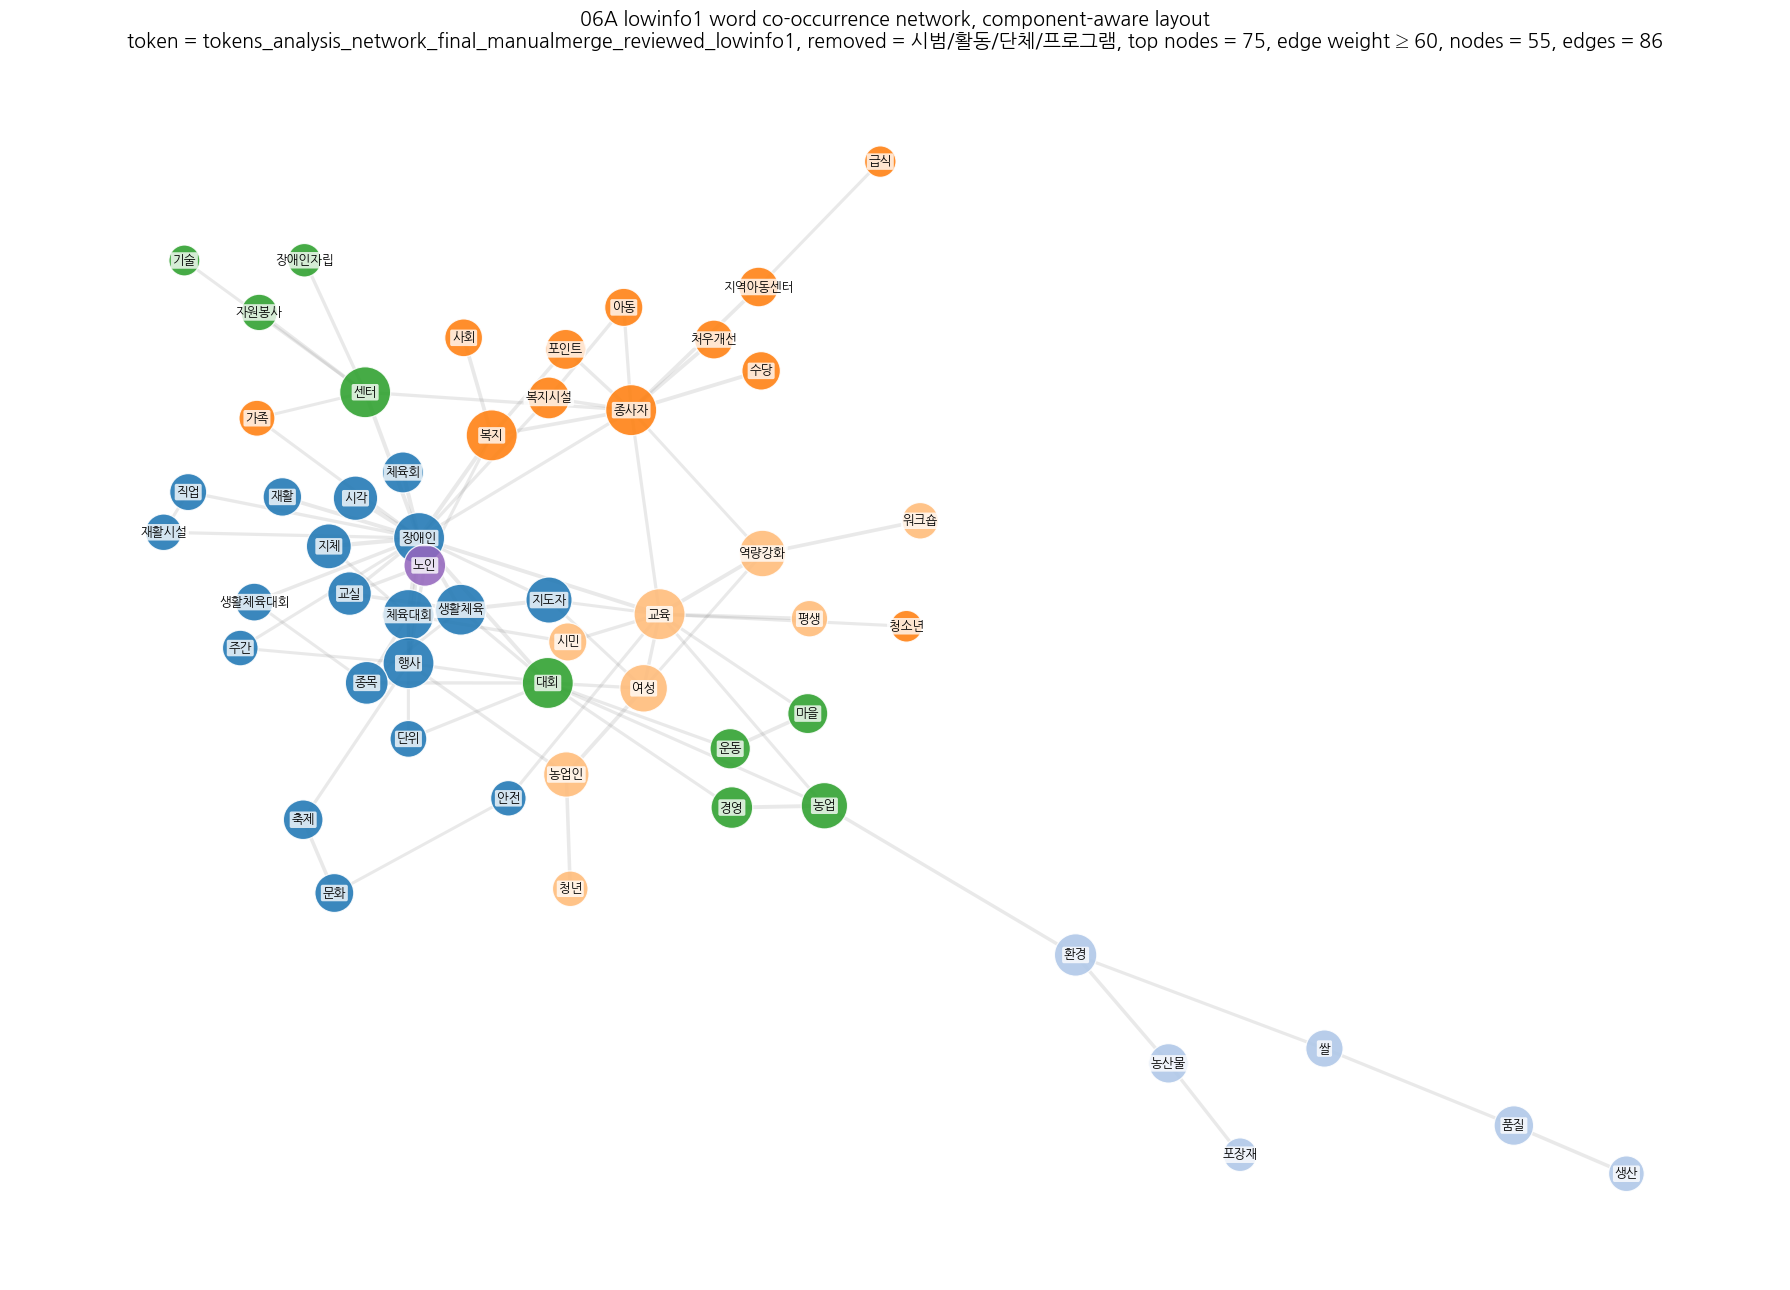


06A-APPEND-3F 완료


In [25]:
# 06A-APPEND-3F. 1차 추가 제거 결과 component-aware 시각화
# 목적:
# - 06A-APPEND-2F에서 생성한 lowinfo1_G_full을 component-aware 방식으로 시각화합니다.
# - 기존 finalmerge, manualmerge 시각화와 구분하기 위해 lowinfo1 파일명으로 저장합니다.
#
# 제거 토큰:
# - 시범, 활동, 단체, 프로그램

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil
import math

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "lowinfo1_G_full" not in globals():
    raise NameError("lowinfo1_G_full이 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "lowinfo1_edge_df" not in globals():
    raise NameError("lowinfo1_edge_df가 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "lowinfo1_node_df" not in globals():
    raise NameError("lowinfo1_node_df가 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "LOWINFO1_TOKEN_COL" not in globals():
    LOWINFO1_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo1"

print("\n[현재 시각화 기준 토큰열]")
print(LOWINFO1_TOKEN_COL)

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각 설정
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_LOWINFO1_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_LOWINFO1_VIS:", RUN_TS_LOWINFO1_VIS)

# ------------------------------------------------------------
# 2) 시각화 설정
# ------------------------------------------------------------

COMPONENT_MODE = "largest"
TOP_K_COMPONENTS = 5
MIN_COMPONENT_SIZE = 2

LOWINFO1_VIS_TOP_N_NODES = 75
LOWINFO1_VIS_MIN_EDGE_WEIGHT = 60

SHOW_ALL_LABELS = True
LOWINFO1_VIS_LABEL_TOP_N = 45

LOWINFO1_VIS_FIGSIZE = (18, 13)
LOWINFO1_VIS_SEED = 42

print("\n[1차 추가 제거 시각화 기준]")
print("COMPONENT_MODE:", COMPONENT_MODE)
print("TOP_K_COMPONENTS:", TOP_K_COMPONENTS)
print("MIN_COMPONENT_SIZE:", MIN_COMPONENT_SIZE)
print("LOWINFO1_VIS_TOP_N_NODES:", LOWINFO1_VIS_TOP_N_NODES)
print("LOWINFO1_VIS_MIN_EDGE_WEIGHT:", LOWINFO1_VIS_MIN_EDGE_WEIGHT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("LOWINFO1_VIS_LABEL_TOP_N:", LOWINFO1_VIS_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    search_roots = [
        Path("/usr/share/fonts"),
        Path("/content"),
    ]

    patterns = [
        "*Nanum*Gothic*.ttf",
        "*Nanum*Barun*.ttf",
        "*Nanum*.ttf",
        "*NotoSansCJK*.ttc",
        "*NotoSansCJK*.otf",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for pattern in patterns:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 lowinfo1_G_full 기준 community detection
# ------------------------------------------------------------

lowinfo1_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        lowinfo1_G_full,
        weight="weight"
    )
)

lowinfo1_node_to_community_full = {}

for community_id, community_nodes in enumerate(lowinfo1_communities_full):
    for node in community_nodes:
        lowinfo1_node_to_community_full[node] = community_id

lowinfo1_community_count_full = len(lowinfo1_communities_full)

print("\n[전체 lowinfo1_G_full 기준 커뮤니티]")
print("lowinfo1_G_full node 수:", lowinfo1_G_full.number_of_nodes())
print("lowinfo1_G_full edge 수:", lowinfo1_G_full.number_of_edges())
print("community 수:", lowinfo1_community_count_full)

# ------------------------------------------------------------
# 5) 시각화용 그래프 생성
# ------------------------------------------------------------

lowinfo1_node_df_for_plot = lowinfo1_node_df.copy()

lowinfo1_node_df_for_plot["community_id"] = lowinfo1_node_df_for_plot["word"].map(
    lowinfo1_node_to_community_full
)

lowinfo1_node_df_for_plot["community_id"] = (
    lowinfo1_node_df_for_plot["community_id"]
    .fillna(-1)
    .astype(int)
)

lowinfo1_top_nodes = set(
    lowinfo1_node_df_for_plot
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(LOWINFO1_VIS_TOP_N_NODES)["word"]
)

lowinfo1_vis_edge_df = lowinfo1_edge_df[
    (lowinfo1_edge_df["weight"] >= LOWINFO1_VIS_MIN_EDGE_WEIGHT)
    & lowinfo1_edge_df["source"].isin(lowinfo1_top_nodes)
    & lowinfo1_edge_df["target"].isin(lowinfo1_top_nodes)
].copy()

lowinfo1_G_candidate = nx.Graph()

for _, row in lowinfo1_vis_edge_df.iterrows():
    lowinfo1_G_candidate.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

lowinfo1_G_candidate.remove_nodes_from(list(nx.isolates(lowinfo1_G_candidate)))

if lowinfo1_G_candidate.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다. LOWINFO1_VIS_MIN_EDGE_WEIGHT를 낮춰보세요.")

# ------------------------------------------------------------
# 6) component 선택
# ------------------------------------------------------------

components = list(nx.connected_components(lowinfo1_G_candidate))

component_info_rows = []

for idx, comp in enumerate(components):
    sub_g = lowinfo1_G_candidate.subgraph(comp).copy()
    edge_weight_sum = sum(
        data.get("weight", 1)
        for _, _, data in sub_g.edges(data=True)
    )

    component_info_rows.append({
        "component_raw_id": idx,
        "node_count": sub_g.number_of_nodes(),
        "edge_count": sub_g.number_of_edges(),
        "edge_weight_sum": edge_weight_sum,
        "top_nodes": ", ".join(
            lowinfo1_node_df_for_plot[
                lowinfo1_node_df_for_plot["word"].isin(comp)
            ]
            .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
            ["word"]
            .head(15)
            .tolist()
        )
    })

lowinfo1_component_summary_df = (
    pd.DataFrame(component_info_rows)
    .sort_values(["node_count", "edge_weight_sum"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\n[component 요약]")
display(lowinfo1_component_summary_df)

if COMPONENT_MODE == "largest":
    selected_component_raw_ids = lowinfo1_component_summary_df.head(1)["component_raw_id"].tolist()
elif COMPONENT_MODE == "top_k":
    selected_component_raw_ids = lowinfo1_component_summary_df[
        lowinfo1_component_summary_df["node_count"] >= MIN_COMPONENT_SIZE
    ].head(TOP_K_COMPONENTS)["component_raw_id"].tolist()
elif COMPONENT_MODE == "all":
    selected_component_raw_ids = lowinfo1_component_summary_df[
        lowinfo1_component_summary_df["node_count"] >= MIN_COMPONENT_SIZE
    ]["component_raw_id"].tolist()
else:
    raise ValueError("COMPONENT_MODE는 'largest', 'top_k', 'all' 중 하나여야 합니다.")

selected_nodes = set()

for raw_id in selected_component_raw_ids:
    selected_nodes.update(components[raw_id])

lowinfo1_G_vis = lowinfo1_G_candidate.subgraph(selected_nodes).copy()

print("\n[선택된 시각화용 graph]")
print("node 수:", lowinfo1_G_vis.number_of_nodes())
print("edge 수:", lowinfo1_G_vis.number_of_edges())
print("선택 component raw ids:", selected_component_raw_ids)

# ------------------------------------------------------------
# 7) component-aware layout 계산
# ------------------------------------------------------------

def normalize_component_pos(pos_dict, scale=1.0):
    xs = np.array([p[0] for p in pos_dict.values()])
    ys = np.array([p[1] for p in pos_dict.values()])

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()

    x_range = max(x_max - x_min, 1e-9)
    y_range = max(y_max - y_min, 1e-9)

    out = {}

    for node, (x, y) in pos_dict.items():
        x_norm = ((x - x_min) / x_range - 0.5) * 2 * scale
        y_norm = ((y - y_min) / y_range - 0.5) * 2 * scale
        out[node] = np.array([x_norm, y_norm])

    return out

selected_components = list(nx.connected_components(lowinfo1_G_vis))
selected_components = sorted(selected_components, key=lambda c: len(c), reverse=True)

n_components = len(selected_components)
grid_cols = min(3, max(1, math.ceil(math.sqrt(n_components))))
grid_rows = math.ceil(n_components / grid_cols)

x_gap = 3.8
y_gap = 3.0

lowinfo1_pos = {}

for comp_idx, comp_nodes in enumerate(selected_components):
    sub_g = lowinfo1_G_vis.subgraph(comp_nodes).copy()
    n_nodes = sub_g.number_of_nodes()

    if n_nodes == 1:
        local_pos = {list(sub_g.nodes())[0]: np.array([0.0, 0.0])}
    else:
        local_pos = nx.spring_layout(
            sub_g,
            seed=LOWINFO1_VIS_SEED + comp_idx,
            weight="weight",
            k=1.25 / np.sqrt(max(n_nodes, 1)),
            iterations=450
        )

    comp_scale = max(0.75, min(1.45, np.sqrt(n_nodes) / 3.0))
    local_pos = normalize_component_pos(local_pos, scale=comp_scale)

    row = comp_idx // grid_cols
    col = comp_idx % grid_cols

    x_offset = (col - (grid_cols - 1) / 2) * x_gap
    y_offset = ((grid_rows - 1) / 2 - row) * y_gap

    for node, xy in local_pos.items():
        lowinfo1_pos[node] = xy + np.array([x_offset, y_offset])

# ------------------------------------------------------------
# 8) 노드 크기, 엣지 굵기, 색상
# ------------------------------------------------------------

lowinfo1_weighted_degree_vis = dict(lowinfo1_G_vis.degree(weight="weight"))

lowinfo1_node_sizes = []

for node in lowinfo1_G_vis.nodes():
    wd = lowinfo1_weighted_degree_vis.get(node, 1)
    size = 140 + np.sqrt(wd) * 45
    size = max(190, min(size, 1350))
    lowinfo1_node_sizes.append(size)

lowinfo1_edge_weights = [
    lowinfo1_G_vis[u][v]["weight"]
    for u, v in lowinfo1_G_vis.edges()
]

lowinfo1_edge_widths = [
    max(0.35, min(np.log1p(w) / 1.9, 3.2))
    for w in lowinfo1_edge_weights
]

cmap = plt.get_cmap("tab20", max(lowinfo1_community_count_full, 1))

lowinfo1_node_colors = []

for node in lowinfo1_G_vis.nodes():
    community_id = lowinfo1_node_to_community_full.get(node, -1)

    if community_id == -1:
        lowinfo1_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        lowinfo1_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 9) 라벨 표시 대상
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    lowinfo1_label_nodes = set(lowinfo1_G_vis.nodes())
    LABEL_FONT_SIZE = 9
else:
    lowinfo1_label_nodes = set(
        lowinfo1_node_df_for_plot
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(LOWINFO1_VIS_LABEL_TOP_N)["word"]
    )
    LABEL_FONT_SIZE = 11

lowinfo1_labels = {
    node: node
    for node in lowinfo1_G_vis.nodes()
    if node in lowinfo1_label_nodes
}

print("\n[라벨 표시]")
print("표시 라벨 수:", len(lowinfo1_labels))

# ------------------------------------------------------------
# 10) 시각화 포함 노드 표
# ------------------------------------------------------------

lowinfo1_vis_node_rows = []

for node in lowinfo1_G_vis.nodes():
    lowinfo1_vis_node_rows.append({
        "word": node,
        "component_id": None,
        "community_id": lowinfo1_node_to_community_full.get(node, -1),
        "doc_freq_unique": lowinfo1_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": lowinfo1_G_vis.degree(node, weight="weight")
    })

lowinfo1_vis_node_df = pd.DataFrame(lowinfo1_vis_node_rows)

node_to_component_id = {}

for comp_idx, comp_nodes in enumerate(selected_components):
    for node in comp_nodes:
        node_to_component_id[node] = comp_idx

lowinfo1_vis_node_df["component_id"] = lowinfo1_vis_node_df["word"].map(
    node_to_component_id
)

lowinfo1_vis_node_df = (
    lowinfo1_vis_node_df
    .sort_values(["component_id", "community_id", "weighted_degree_in_vis"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n[시각화 포함 노드]")
display(lowinfo1_vis_node_df)

# ------------------------------------------------------------
# 11) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=LOWINFO1_VIS_FIGSIZE)

nx.draw_networkx_edges(
    lowinfo1_G_vis,
    lowinfo1_pos,
    width=lowinfo1_edge_widths,
    alpha=0.17,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    lowinfo1_G_vis,
    lowinfo1_pos,
    node_size=lowinfo1_node_sizes,
    alpha=0.88,
    node_color=lowinfo1_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LABEL_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=14)

for node, label in lowinfo1_labels.items():
    x, y = lowinfo1_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LABEL_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14"
        ),
        zorder=10
    )

ax.set_title(
    "06A lowinfo1 word co-occurrence network, component-aware layout\n"
    f"token = {LOWINFO1_TOKEN_COL}, "
    f"removed = 시범/활동/단체/프로그램, "
    f"top nodes = {LOWINFO1_VIS_TOP_N_NODES}, "
    f"edge weight ≥ {LOWINFO1_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {lowinfo1_G_vis.number_of_nodes()}, "
    f"edges = {lowinfo1_G_vis.number_of_edges()}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_lowinfo1 = (
        FIGURE_REVIEW_DIR
        / f"06A_lowinfo1_network_componentfix_{RUN_VERSION}_{RUN_TS_LOWINFO1_VIS}.png"
    )

    out_component_lowinfo1 = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo1_component_summary_{RUN_VERSION}_{RUN_TS_LOWINFO1_VIS}.csv"
    )

    out_vis_node_lowinfo1 = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo1_componentfix_vis_nodes_{RUN_VERSION}_{RUN_TS_LOWINFO1_VIS}.csv"
    )

    plt.savefig(out_png_lowinfo1, dpi=260, bbox_inches="tight")

    lowinfo1_component_summary_df.to_csv(
        out_component_lowinfo1,
        index=False,
        encoding="utf-8-sig"
    )

    lowinfo1_vis_node_df.to_csv(
        out_vis_node_lowinfo1,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[lowinfo1 component-aware 시각화 저장 완료]")
    print("- PNG:", out_png_lowinfo1)
    print("- component summary:", out_component_lowinfo1)
    print("- vis nodes:", out_vis_node_lowinfo1)

plt.show()

print("\n06A-APPEND-3F 완료")

### 06A-APPEND-3G. lowinfo1 largest component 라벨 정리 최종 후보 시각화



SAVE_OUTPUT: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_manualmerge_reviewed_lowinfo1

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_LOWINFO1_LABELTOP_VIS: 20260611_2259

[라벨 정리 시각화 기준]
COMPONENT_MODE: largest
LOWINFO1_LABELTOP_VIS_TOP_N_NODES: 75
LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT: 60
SHOW_ALL_LABELS: False
LOWINFO1_LABELTOP_LABEL_TOP_N: 42

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 lowinfo1_G_full 기준 커뮤니티]
lowinfo1_G_full node 수: 304
lowinfo1_G_full edge 수: 536
community 수: 26

[component 요약]


,component_raw_id,node_count,edge_count,edge_weight_sum,top_nodes
0,0,55,86,10666.0,"장애인, 교육, 대회, 종사자, 행사, 센터, 체육대회, 복지, 생활체육, 환경, ..."
1,1,3,2,716.0,"경로당, 개보수, 물품"
2,2,3,3,305.0,"방제, 병해충, 벼"
3,4,3,3,285.0,"어린이집, 가정, 민간"
4,3,3,2,247.0,"시설, 원예, 작물"
5,5,2,1,88.0,"공동주택, 유지"



[선택된 largest component graph]
node 수: 55
edge 수: 86
선택 component raw id: 0

[라벨 표시]
전체 노드 수: 55
표시 라벨 수: 42

[시각화 포함 노드]


,word,community_id,doc_freq_unique,weighted_degree_in_vis,label_shown
0,장애인,0,4783,3691.0,True
1,체육대회,0,1606,783.0,True
2,생활체육,0,1071,715.0,True
3,행사,0,2860,714.0,True
4,지도자,0,542,458.0,True
5,지체,0,358,406.0,True
6,시각,0,440,383.0,True
7,교실,0,801,351.0,True
8,종목,0,417,324.0,True
9,체육회,0,696,265.0,True



[lowinfo1 largest label-top 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_lowinfo1_largest_labeltop_network_v1_20260611_2259.png
- component summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo1_largest_labeltop_component_summary_v1_20260611_2259.csv
- vis nodes: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo1_largest_labeltop_vis_nodes_v1_20260611_2259.csv


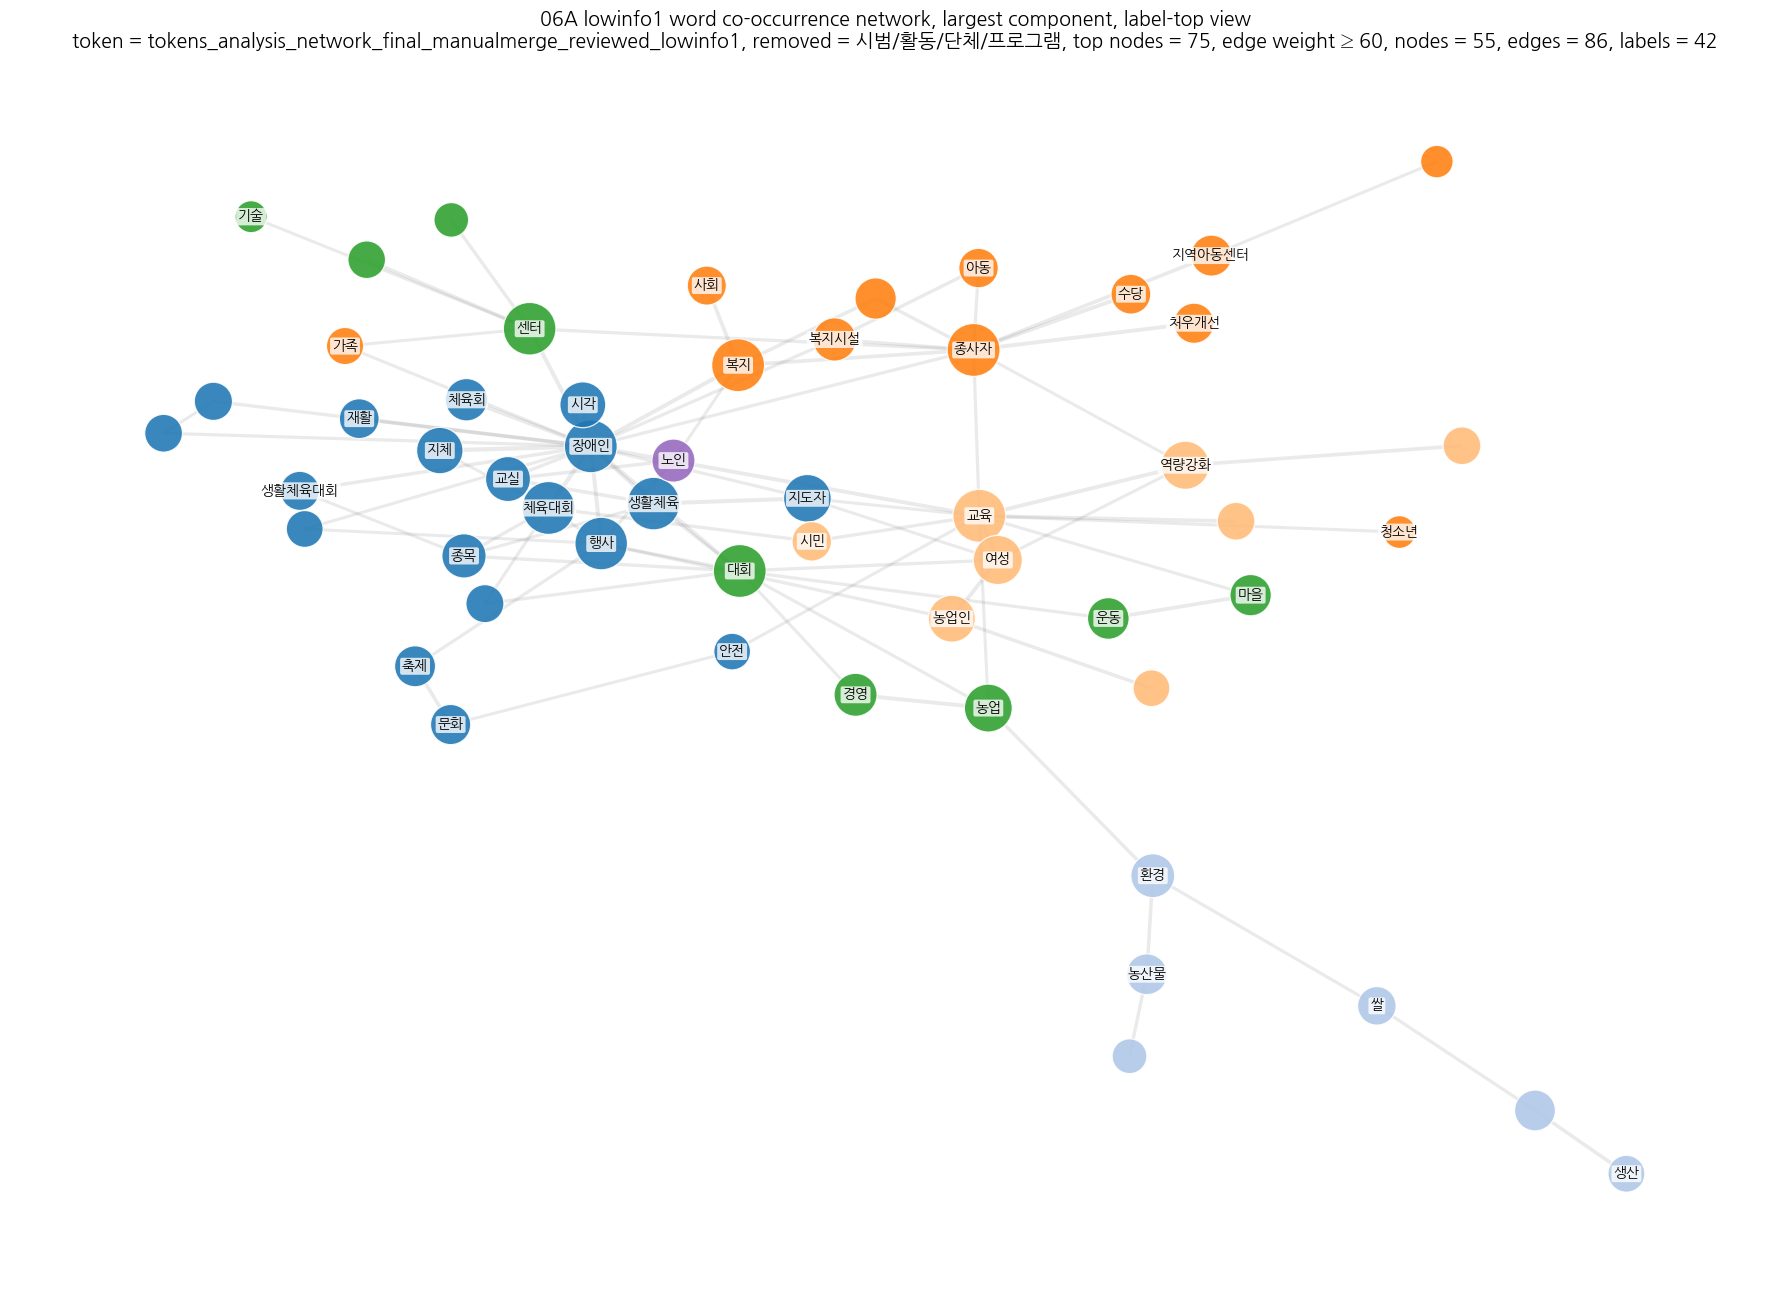


06A-APPEND-3G 완료


In [26]:
# 06A-APPEND-3G. lowinfo1 largest component 라벨 정리 최종 후보 시각화
# 목적:
# - 06A-APPEND-2F에서 만든 lowinfo1_G_full을 사용합니다.
# - COMPONENT_MODE = largest 기준으로 중심 component만 표시합니다.
# - 모든 노드는 그리되, 라벨은 중심성 상위 노드만 표시해서 가시성을 개선합니다.
# - 기존 3F 결과와 구분되도록 labeltop 파일명으로 저장합니다.
#
# 기준 토큰:
# - tokens_analysis_network_final_manualmerge_reviewed_lowinfo1
#
# 제거 반영:
# - 시범, 활동, 단체, 프로그램 제거
#
# 실행 전제:
# - 06A-APPEND-1F 실행 완료
# - 06A-APPEND-2F 실행 완료

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil
import math

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "lowinfo1_G_full" not in globals():
    raise NameError("lowinfo1_G_full이 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "lowinfo1_edge_df" not in globals():
    raise NameError("lowinfo1_edge_df가 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "lowinfo1_node_df" not in globals():
    raise NameError("lowinfo1_node_df가 없습니다. 06A-APPEND-2F를 먼저 실행하세요.")

if "LOWINFO1_TOKEN_COL" not in globals():
    LOWINFO1_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo1"

print("\n[현재 시각화 기준 토큰열]")
print(LOWINFO1_TOKEN_COL)

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_LOWINFO1_LABELTOP_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_LOWINFO1_LABELTOP_VIS:", RUN_TS_LOWINFO1_LABELTOP_VIS)

# ------------------------------------------------------------
# 2) 시각화 설정
# ------------------------------------------------------------

# 최종 후보: 가장 큰 component만 표시
COMPONENT_MODE = "largest"

# 기존 largest 결과와 비교 가능하도록 동일 기준 유지
LOWINFO1_LABELTOP_VIS_TOP_N_NODES = 75
LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT = 60

# 라벨은 중심 노드만 표시
SHOW_ALL_LABELS = False
LOWINFO1_LABELTOP_LABEL_TOP_N = 42

LOWINFO1_LABELTOP_FIGSIZE = (18, 13)
LOWINFO1_LABELTOP_SEED = 42

print("\n[라벨 정리 시각화 기준]")
print("COMPONENT_MODE:", COMPONENT_MODE)
print("LOWINFO1_LABELTOP_VIS_TOP_N_NODES:", LOWINFO1_LABELTOP_VIS_TOP_N_NODES)
print("LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT:", LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("LOWINFO1_LABELTOP_LABEL_TOP_N:", LOWINFO1_LABELTOP_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    for root in [Path("/usr/share/fonts"), Path("/content")]:
        if not root.exists():
            continue
        for pattern in [
            "*Nanum*Gothic*.ttf",
            "*Nanum*Barun*.ttf",
            "*Nanum*.ttf",
            "*NotoSansCJK*.ttc",
            "*NotoSansCJK*.otf",
        ]:
            found = list(root.rglob(pattern))
            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 lowinfo1_G_full 기준 community detection
# ------------------------------------------------------------

lowinfo1_labeltop_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        lowinfo1_G_full,
        weight="weight"
    )
)

lowinfo1_labeltop_node_to_community = {}

for community_id, community_nodes in enumerate(lowinfo1_labeltop_communities_full):
    for node in community_nodes:
        lowinfo1_labeltop_node_to_community[node] = community_id

lowinfo1_labeltop_community_count = len(lowinfo1_labeltop_communities_full)

print("\n[전체 lowinfo1_G_full 기준 커뮤니티]")
print("lowinfo1_G_full node 수:", lowinfo1_G_full.number_of_nodes())
print("lowinfo1_G_full edge 수:", lowinfo1_G_full.number_of_edges())
print("community 수:", lowinfo1_labeltop_community_count)

# ------------------------------------------------------------
# 5) 시각화 후보 graph 생성
# ------------------------------------------------------------

lowinfo1_labeltop_node_df = lowinfo1_node_df.copy()

lowinfo1_labeltop_node_df["community_id"] = lowinfo1_labeltop_node_df["word"].map(
    lowinfo1_labeltop_node_to_community
).fillna(-1).astype(int)

lowinfo1_labeltop_top_nodes = set(
    lowinfo1_labeltop_node_df
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(LOWINFO1_LABELTOP_VIS_TOP_N_NODES)["word"]
)

lowinfo1_labeltop_vis_edge_df = lowinfo1_edge_df[
    (lowinfo1_edge_df["weight"] >= LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT)
    & lowinfo1_edge_df["source"].isin(lowinfo1_labeltop_top_nodes)
    & lowinfo1_edge_df["target"].isin(lowinfo1_labeltop_top_nodes)
].copy()

lowinfo1_labeltop_candidate_G = nx.Graph()

for _, row in lowinfo1_labeltop_vis_edge_df.iterrows():
    lowinfo1_labeltop_candidate_G.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

lowinfo1_labeltop_candidate_G.remove_nodes_from(
    list(nx.isolates(lowinfo1_labeltop_candidate_G))
)

if lowinfo1_labeltop_candidate_G.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다. edge weight 기준을 낮춰보세요.")

# ------------------------------------------------------------
# 6) largest component 선택
# ------------------------------------------------------------

components = list(nx.connected_components(lowinfo1_labeltop_candidate_G))

component_rows = []

for idx, comp in enumerate(components):
    sub_g = lowinfo1_labeltop_candidate_G.subgraph(comp).copy()
    edge_weight_sum = sum(
        data.get("weight", 1)
        for _, _, data in sub_g.edges(data=True)
    )

    component_rows.append({
        "component_raw_id": idx,
        "node_count": sub_g.number_of_nodes(),
        "edge_count": sub_g.number_of_edges(),
        "edge_weight_sum": edge_weight_sum,
        "top_nodes": ", ".join(
            lowinfo1_labeltop_node_df[
                lowinfo1_labeltop_node_df["word"].isin(comp)
            ]
            .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
            ["word"]
            .head(20)
            .tolist()
        )
    })

lowinfo1_labeltop_component_summary_df = (
    pd.DataFrame(component_rows)
    .sort_values(["node_count", "edge_weight_sum"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\n[component 요약]")
display(lowinfo1_labeltop_component_summary_df)

largest_component_raw_id = lowinfo1_labeltop_component_summary_df.iloc[0]["component_raw_id"]
selected_nodes = set(components[int(largest_component_raw_id)])

lowinfo1_labeltop_G_vis = lowinfo1_labeltop_candidate_G.subgraph(selected_nodes).copy()

print("\n[선택된 largest component graph]")
print("node 수:", lowinfo1_labeltop_G_vis.number_of_nodes())
print("edge 수:", lowinfo1_labeltop_G_vis.number_of_edges())
print("선택 component raw id:", largest_component_raw_id)

# ------------------------------------------------------------
# 7) layout 계산
# ------------------------------------------------------------

lowinfo1_labeltop_pos = nx.spring_layout(
    lowinfo1_labeltop_G_vis,
    seed=LOWINFO1_LABELTOP_SEED,
    weight="weight",
    k=1.45 / np.sqrt(max(lowinfo1_labeltop_G_vis.number_of_nodes(), 1)),
    iterations=500
)

# ------------------------------------------------------------
# 8) 노드 크기, 엣지 굵기, 색상
# ------------------------------------------------------------

lowinfo1_labeltop_weighted_degree_vis = dict(
    lowinfo1_labeltop_G_vis.degree(weight="weight")
)

lowinfo1_labeltop_node_sizes = []

for node in lowinfo1_labeltop_G_vis.nodes():
    wd = lowinfo1_labeltop_weighted_degree_vis.get(node, 1)
    size = 150 + np.sqrt(wd) * 48
    size = max(210, min(size, 1450))
    lowinfo1_labeltop_node_sizes.append(size)

lowinfo1_labeltop_edge_weights = [
    lowinfo1_labeltop_G_vis[u][v]["weight"]
    for u, v in lowinfo1_labeltop_G_vis.edges()
]

lowinfo1_labeltop_edge_widths = [
    max(0.35, min(np.log1p(w) / 1.9, 3.2))
    for w in lowinfo1_labeltop_edge_weights
]

cmap = plt.get_cmap("tab20", max(lowinfo1_labeltop_community_count, 1))

lowinfo1_labeltop_node_colors = []

for node in lowinfo1_labeltop_G_vis.nodes():
    community_id = lowinfo1_labeltop_node_to_community.get(node, -1)
    if community_id == -1:
        lowinfo1_labeltop_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        lowinfo1_labeltop_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 9) 라벨 표시 대상: 중심성 상위 노드만
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    lowinfo1_labeltop_label_nodes = set(lowinfo1_labeltop_G_vis.nodes())
else:
    lowinfo1_labeltop_label_nodes = set(
        lowinfo1_labeltop_node_df[
            lowinfo1_labeltop_node_df["word"].isin(lowinfo1_labeltop_G_vis.nodes())
        ]
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(LOWINFO1_LABELTOP_LABEL_TOP_N)["word"]
    )

LOWINFO1_LABELTOP_FONT_SIZE = 10 if not SHOW_ALL_LABELS else 9

lowinfo1_labeltop_labels = {
    node: node
    for node in lowinfo1_labeltop_G_vis.nodes()
    if node in lowinfo1_labeltop_label_nodes
}

print("\n[라벨 표시]")
print("전체 노드 수:", lowinfo1_labeltop_G_vis.number_of_nodes())
print("표시 라벨 수:", len(lowinfo1_labeltop_labels))

# ------------------------------------------------------------
# 10) 시각화 포함 노드 표
# ------------------------------------------------------------

lowinfo1_labeltop_vis_node_rows = []

for node in lowinfo1_labeltop_G_vis.nodes():
    lowinfo1_labeltop_vis_node_rows.append({
        "word": node,
        "community_id": lowinfo1_labeltop_node_to_community.get(node, -1),
        "doc_freq_unique": lowinfo1_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": lowinfo1_labeltop_G_vis.degree(node, weight="weight"),
        "label_shown": node in lowinfo1_labeltop_label_nodes
    })

lowinfo1_labeltop_vis_node_df = (
    pd.DataFrame(lowinfo1_labeltop_vis_node_rows)
    .sort_values(["label_shown", "community_id", "weighted_degree_in_vis"], ascending=[False, True, False])
    .reset_index(drop=True)
)

print("\n[시각화 포함 노드]")
display(lowinfo1_labeltop_vis_node_df)

# ------------------------------------------------------------
# 11) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=LOWINFO1_LABELTOP_FIGSIZE)

nx.draw_networkx_edges(
    lowinfo1_labeltop_G_vis,
    lowinfo1_labeltop_pos,
    width=lowinfo1_labeltop_edge_widths,
    alpha=0.16,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    lowinfo1_labeltop_G_vis,
    lowinfo1_labeltop_pos,
    node_size=lowinfo1_labeltop_node_sizes,
    alpha=0.88,
    node_color=lowinfo1_labeltop_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LOWINFO1_LABELTOP_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=14)

for node, label in lowinfo1_labeltop_labels.items():
    x, y = lowinfo1_labeltop_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LOWINFO1_LABELTOP_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14"
        ),
        zorder=10
    )

ax.set_title(
    "06A lowinfo1 word co-occurrence network, largest component, label-top view\n"
    f"token = {LOWINFO1_TOKEN_COL}, "
    f"removed = 시범/활동/단체/프로그램, "
    f"top nodes = {LOWINFO1_LABELTOP_VIS_TOP_N_NODES}, "
    f"edge weight ≥ {LOWINFO1_LABELTOP_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {lowinfo1_labeltop_G_vis.number_of_nodes()}, "
    f"edges = {lowinfo1_labeltop_G_vis.number_of_edges()}, "
    f"labels = {len(lowinfo1_labeltop_labels)}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_lowinfo1_labeltop = (
        FIGURE_REVIEW_DIR
        / f"06A_lowinfo1_largest_labeltop_network_{RUN_VERSION}_{RUN_TS_LOWINFO1_LABELTOP_VIS}.png"
    )

    out_component_lowinfo1_labeltop = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo1_largest_labeltop_component_summary_{RUN_VERSION}_{RUN_TS_LOWINFO1_LABELTOP_VIS}.csv"
    )

    out_vis_node_lowinfo1_labeltop = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo1_largest_labeltop_vis_nodes_{RUN_VERSION}_{RUN_TS_LOWINFO1_LABELTOP_VIS}.csv"
    )

    plt.savefig(out_png_lowinfo1_labeltop, dpi=260, bbox_inches="tight")

    lowinfo1_labeltop_component_summary_df.to_csv(
        out_component_lowinfo1_labeltop,
        index=False,
        encoding="utf-8-sig"
    )

    lowinfo1_labeltop_vis_node_df.to_csv(
        out_vis_node_lowinfo1_labeltop,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[lowinfo1 largest label-top 시각화 저장 완료]")
    print("- PNG:", out_png_lowinfo1_labeltop)
    print("- component summary:", out_component_lowinfo1_labeltop)
    print("- vis nodes:", out_vis_node_lowinfo1_labeltop)

plt.show()

print("\n06A-APPEND-3G 완료")

###06A-APPEND-1H. 최신 수동검토 재결합표 2023 반영 + lowinfo2 생성

In [27]:
# 06A-APPEND-1H. 최신 재결합표 2023 반영 + lowinfo2 생성
# 목적:
# - 최신 manual_merge_decision Excel(20260611_2023)을 읽습니다.
# - tokens_analysis_network_final에 수동 재결합 규칙을 먼저 적용합니다.
# - 기존 저정보 토큰 제거 목록을 적용합니다.
# - 추가로 시범/활동/단체/프로그램/단위/포인트를 제거한 lowinfo2 토큰열을 생성합니다.
#
# 실행 전제:
# - 06A-APPEND-1 실행 완료
# - df_03_review 존재
# - tokens_analysis_network_final 존재
#
# 출력:
# - tokens_analysis_network_final_manualmerge_2023
# - tokens_analysis_network_final_manualmerge_reviewed_2023
# - tokens_analysis_network_final_manualmerge_reviewed_lowinfo2

from pathlib import Path
import pandas as pd
import numpy as np
import ast

# ------------------------------------------------------------
# 1) 최신 수동 재결합 판단 Excel 경로
# ------------------------------------------------------------

MERGE_DECISION_XLSX_NAME = "03_token_adjacent_ngram_merge_review_v1_20260611_2023.xlsx"

MERGE_DECISION_XLSX_PATH = (
    PROJECT_ROOT
    / "03_중간결과표"
    / "03_v1_사업명텍스트분석"
    / "tables"
    / "review"
    / MERGE_DECISION_XLSX_NAME
)

print("[최신 재결합 판단 Excel]")
print(MERGE_DECISION_XLSX_PATH)
print("exists:", MERGE_DECISION_XLSX_PATH.exists())

if not MERGE_DECISION_XLSX_PATH.exists():
    print("\n기본 경로에서 파일을 찾지 못했습니다. /content/drive 아래에서 자동 검색합니다.")

    matches = list(Path("/content/drive").rglob(MERGE_DECISION_XLSX_NAME))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"{MERGE_DECISION_XLSX_NAME} 파일을 Drive에서 찾지 못했습니다. "
            "해당 Excel 파일을 03_v1_사업명텍스트분석/tables/review 폴더에 업로드하세요."
        )

    MERGE_DECISION_XLSX_PATH = matches[0]
    print("자동 검색 성공:")
    print(MERGE_DECISION_XLSX_PATH)

# ------------------------------------------------------------
# 2) 입력 데이터 확인
# ------------------------------------------------------------

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1을 먼저 실행하세요.")

SOURCE_TOKEN_COL = "tokens_analysis_network_final"
MERGED_TOKEN_COL_2023 = "tokens_analysis_network_final_manualmerge_2023"
REVIEWED_TOKEN_COL_2023 = "tokens_analysis_network_final_manualmerge_reviewed_2023"
LOWINFO2_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo2"

if SOURCE_TOKEN_COL not in df_03_review.columns:
    raise KeyError(f"{SOURCE_TOKEN_COL} 열이 없습니다.")

print("\n[토큰 처리 흐름]")
print("입력:", SOURCE_TOKEN_COL)
print("재결합 후:", MERGED_TOKEN_COL_2023)
print("재결합 후 기본 저정보 제거:", REVIEWED_TOKEN_COL_2023)
print("lowinfo2:", LOWINFO2_TOKEN_COL)

# ------------------------------------------------------------
# 3) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

def ensure_token_list_local(x):
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip() != ""]

    if isinstance(x, tuple):
        return [str(t).strip() for t in list(x) if str(t).strip() != ""]

    if isinstance(x, np.ndarray):
        return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

    if x is None:
        return []

    try:
        if pd.isna(x):
            return []
    except Exception:
        pass

    if isinstance(x, str):
        x_strip = x.strip()

        if x_strip == "":
            return []

        try:
            parsed = ast.literal_eval(x_strip)

            if isinstance(parsed, list):
                return [str(t).strip() for t in parsed if str(t).strip() != ""]

            if isinstance(parsed, tuple):
                return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]

        except Exception:
            pass

        return [x_strip]

    return [str(x).strip()] if str(x).strip() != "" else []

df_03_review[SOURCE_TOKEN_COL] = df_03_review[SOURCE_TOKEN_COL].apply(
    ensure_token_list_local
)

# ------------------------------------------------------------
# 4) manual_merge_decision 읽기
# ------------------------------------------------------------

manual_merge_df = pd.read_excel(
    MERGE_DECISION_XLSX_PATH,
    sheet_name="manual_merge_decision"
)

manual_merge_df.columns = [str(c).strip() for c in manual_merge_df.columns]

required_cols = [
    "ngram_n",
    "token_1",
    "token_2",
    "token_3",
    "tokens_with_plus",
    "joined_candidate",
    "수동판단",
    "처리방향"
]

missing_cols = [col for col in required_cols if col not in manual_merge_df.columns]

if missing_cols:
    raise KeyError(f"manual_merge_decision 시트에 필요한 열이 없습니다: {missing_cols}")

for col in ["token_1", "token_2", "token_3", "joined_candidate", "수동판단", "처리방향"]:
    manual_merge_df[col] = manual_merge_df[col].fillna("").astype(str).str.strip()

# ------------------------------------------------------------
# 5) 재결합 확정 행만 추출
# ------------------------------------------------------------

merge_rule_df = manual_merge_df[
    (manual_merge_df["수동판단"] == "재결합")
    | (manual_merge_df["처리방향"] == "merge")
].copy()

print("\n[manual_merge_decision 반영 현황]")
print("전체 후보 행 수:", len(manual_merge_df))
print("재결합 반영 행 수:", len(merge_rule_df))

if len(merge_rule_df) == 0:
    raise ValueError("재결합으로 표시된 행이 없습니다.")

# ------------------------------------------------------------
# 6) 재결합 규칙 생성
# ------------------------------------------------------------

merge_rules_rows = []

for _, row in merge_rule_df.iterrows():
    try:
        ngram_n = int(row["ngram_n"])
    except Exception:
        ngram_n = None

    tokens = []

    if row["token_1"] != "":
        tokens.append(row["token_1"])
    if row["token_2"] != "":
        tokens.append(row["token_2"])
    if row["token_3"] != "":
        tokens.append(row["token_3"])

    if ngram_n is not None:
        tokens = tokens[:ngram_n]

    tokens = [t for t in tokens if t != ""]
    joined_candidate = row["joined_candidate"]

    if len(tokens) < 2:
        continue

    if joined_candidate == "":
        joined_candidate = "".join(tokens)

    merge_rules_rows.append({
        "pattern": tuple(tokens),
        "merged": joined_candidate,
        "ngram_n": len(tokens),
        "tokens_with_plus": " + ".join(tokens),
        "수동판단": row["수동판단"],
        "처리방향": row["처리방향"]
    })

merge_rules_df_2023 = pd.DataFrame(merge_rules_rows)

merge_rules_df_2023 = (
    merge_rules_df_2023
    .drop_duplicates(subset=["pattern", "merged"])
    .sort_values(["ngram_n", "tokens_with_plus"], ascending=[False, True])
    .reset_index(drop=True)
)

merge_rules_2023 = [
    (tuple(row["pattern"]), row["merged"])
    for _, row in merge_rules_df_2023.iterrows()
]

print("\n[적용할 재결합 규칙]")
print("규칙 수:", len(merge_rules_df_2023))
display(merge_rules_df_2023.head(120))

# ------------------------------------------------------------
# 7) 핵심 재결합 규칙 확인
# ------------------------------------------------------------

check_patterns = [
    "시각 + 장애인",
    "지체 + 장애인",
    "평생 + 교육",
    "평생 + 학습",
    "주간 + 보호",
    "주간 + 보호 + 시설",
    "주간 + 보호 + 센터",
]

print("\n[핵심 재결합 규칙 확인]")
display(
    merge_rules_df_2023[
        merge_rules_df_2023["tokens_with_plus"].isin(check_patterns)
    ]
)

# ------------------------------------------------------------
# 8) 재결합 적용 함수
# ------------------------------------------------------------
# 중요:
# - 3-gram을 먼저 적용하고 그 다음 2-gram을 적용합니다.
# - 예: 주간+보호+센터는 주간보호센터로 먼저 결합됩니다.

def apply_manual_merge_rules(tokens, merge_rules):
    tokens = ensure_token_list_local(tokens)

    out_tokens = []
    applied_rules = []

    i = 0

    while i < len(tokens):
        matched = False

        for pattern, merged in merge_rules:
            n = len(pattern)

            if n == 0:
                continue

            if tuple(tokens[i:i+n]) == pattern:
                out_tokens.append(merged)
                applied_rules.append(f"{' + '.join(pattern)} -> {merged}")
                i += n
                matched = True
                break

        if not matched:
            out_tokens.append(tokens[i])
            i += 1

    return out_tokens, applied_rules

# ------------------------------------------------------------
# 9) 재결합 먼저 적용
# ------------------------------------------------------------

merged_results = df_03_review[SOURCE_TOKEN_COL].apply(
    lambda toks: apply_manual_merge_rules(toks, merge_rules_2023)
)

df_03_review[MERGED_TOKEN_COL_2023] = merged_results.apply(lambda x: x[0])
df_03_review["tokens_network_manual_merged_pairs_2023"] = merged_results.apply(lambda x: x[1])

# ------------------------------------------------------------
# 10) 기본 저정보 토큰 제거 목록
# ------------------------------------------------------------

fallback_remove_tokens = [
    "개선", "전국", "활성", "육성", "협의회", "강화", "지회", "조성", "구입",
    "설치", "우수", "사업비", "연합회", "사랑", "보급", "마당", "정비",
    "협회", "보수", "추가", "참여", "출전", "자체", "기념행사", "규모",
    "기념", "교체", "맞춤", "행복",
]

if "remove_tokens" in globals():
    base_lowinfo_remove_tokens = sorted(set([str(t).strip() for t in remove_tokens if str(t).strip() != ""]))
    lowinfo_source = "remove_tokens from 06A-APPEND-1"
else:
    base_lowinfo_remove_tokens = sorted(set(fallback_remove_tokens))
    lowinfo_source = "fallback_remove_tokens"

base_lowinfo_remove_set = set(base_lowinfo_remove_tokens)

print("\n[기본 저정보 제거 목록]")
print("출처:", lowinfo_source)
print("기본 제거 토큰 수:", len(base_lowinfo_remove_set))

def remove_base_lowinfo(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok not in base_lowinfo_remove_set]

def get_removed_base_lowinfo(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok in base_lowinfo_remove_set]

df_03_review[REVIEWED_TOKEN_COL_2023] = df_03_review[MERGED_TOKEN_COL_2023].apply(
    remove_base_lowinfo
)

df_03_review["tokens_network_lowinfo_removed_after_manualmerge_2023"] = df_03_review[
    MERGED_TOKEN_COL_2023
].apply(get_removed_base_lowinfo)

# ------------------------------------------------------------
# 11) lowinfo2 추가 제거
# ------------------------------------------------------------

EXTRA_LOWINFO_TOKENS_2 = [
    "시범",
    "활동",
    "단체",
    "프로그램",
    "단위",
    "포인트",
]

extra_lowinfo_set_2 = set(EXTRA_LOWINFO_TOKENS_2)

print("\n[lowinfo2 추가 제거 토큰]")
print(EXTRA_LOWINFO_TOKENS_2)

def remove_lowinfo2(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok not in extra_lowinfo_set_2]

def get_removed_lowinfo2(tokens):
    tokens = ensure_token_list_local(tokens)
    return [tok for tok in tokens if tok in extra_lowinfo_set_2]

df_03_review[LOWINFO2_TOKEN_COL] = df_03_review[REVIEWED_TOKEN_COL_2023].apply(
    remove_lowinfo2
)

df_03_review["tokens_network_extra_removed_lowinfo2"] = df_03_review[
    REVIEWED_TOKEN_COL_2023
].apply(get_removed_lowinfo2)

df_03_review[f"{LOWINFO2_TOKEN_COL}_count"] = df_03_review[LOWINFO2_TOKEN_COL].apply(len)
df_03_review[f"{LOWINFO2_TOKEN_COL}_empty"] = df_03_review[LOWINFO2_TOKEN_COL].apply(lambda x: len(x) == 0)

# ------------------------------------------------------------
# 12) 결과 요약
# ------------------------------------------------------------

merge_rows_changed = df_03_review["tokens_network_manual_merged_pairs_2023"].apply(len).gt(0).sum()
merge_total_applied = df_03_review["tokens_network_manual_merged_pairs_2023"].apply(len).sum()

base_removed_rows = df_03_review["tokens_network_lowinfo_removed_after_manualmerge_2023"].apply(len).gt(0).sum()
base_removed_total = df_03_review["tokens_network_lowinfo_removed_after_manualmerge_2023"].apply(len).sum()

lowinfo2_removed_rows = df_03_review["tokens_network_extra_removed_lowinfo2"].apply(len).gt(0).sum()
lowinfo2_removed_total = df_03_review["tokens_network_extra_removed_lowinfo2"].apply(len).sum()

lowinfo2_empty_rows = df_03_review[f"{LOWINFO2_TOKEN_COL}_empty"].sum()

lowinfo2_apply_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "재결합 후 토큰열",
        "기본 저정보 제거 후 토큰열",
        "lowinfo2 최종 토큰열",
        "재결합 규칙 수",
        "재결합 발생 행 수",
        "재결합 총 적용 횟수",
        "기본 저정보 제거 발생 행 수",
        "기본 저정보 제거 총 횟수",
        "lowinfo2 추가 제거 토큰",
        "lowinfo2 추가 제거 발생 행 수",
        "lowinfo2 추가 제거 총 횟수",
        "lowinfo2 최종 빈 토큰 행 수"
    ],
    "값": [
        SOURCE_TOKEN_COL,
        MERGED_TOKEN_COL_2023,
        REVIEWED_TOKEN_COL_2023,
        LOWINFO2_TOKEN_COL,
        len(merge_rules_df_2023),
        int(merge_rows_changed),
        int(merge_total_applied),
        int(base_removed_rows),
        int(base_removed_total),
        ", ".join(EXTRA_LOWINFO_TOKENS_2),
        int(lowinfo2_removed_rows),
        int(lowinfo2_removed_total),
        int(lowinfo2_empty_rows)
    ]
})

print("\n[최신 재결합 2023 + lowinfo2 적용 요약]")
display(lowinfo2_apply_summary)

print("\n[lowinfo2 추가 제거 사례 상위 50개]")
display_cols = [
    "v1_row_id",
    "시도",
    "지자체명",
    "사업명",
    SOURCE_TOKEN_COL,
    MERGED_TOKEN_COL_2023,
    REVIEWED_TOKEN_COL_2023,
    LOWINFO2_TOKEN_COL,
    "tokens_network_manual_merged_pairs_2023",
    "tokens_network_extra_removed_lowinfo2"
]

display_cols = [col for col in display_cols if col in df_03_review.columns]

display(
    df_03_review[
        df_03_review["tokens_network_extra_removed_lowinfo2"].apply(len).gt(0)
    ][display_cols].head(50)
)

print("\n06A-APPEND-1H 완료")
print(f"다음 네트워크 생성 셀에서 기준 토큰열은 '{LOWINFO2_TOKEN_COL}' 입니다.")

[최신 재결합 판단 Excel]
/content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/03_v1_사업명텍스트분석/tables/review/03_token_adjacent_ngram_merge_review_v1_20260611_2023.xlsx
exists: True

[토큰 처리 흐름]
입력: tokens_analysis_network_final
재결합 후: tokens_analysis_network_final_manualmerge_2023
재결합 후 기본 저정보 제거: tokens_analysis_network_final_manualmerge_reviewed_2023
lowinfo2: tokens_analysis_network_final_manualmerge_reviewed_lowinfo2

[manual_merge_decision 반영 현황]
전체 후보 행 수: 10842
재결합 반영 행 수: 423

[적용할 재결합 규칙]
규칙 수: 423


,pattern,merged,ngram_n,tokens_with_plus,수동판단,처리방향
0,"(6.25, 참전, 유공자)",6.25참전유공자,3,6.25 + 참전 + 유공자,재결합,merge
1,"(공헌, 활동, 전환사업)",공헌활동전환사업,3,공헌 + 활동 + 전환사업,재결합,merge
2,"(국악, 경연, 대회)",국악경연대회,3,국악 + 경연 + 대회,재결합,merge
3,"(그라운드, 골프, 대회)",그라운드골프대회,3,그라운드 + 골프 + 대회,재결합,merge
4,"(도민, 체육, 대회)",도민체육대회,3,도민 + 체육 + 대회,재결합,merge
...,...,...,...,...,...,...
115,"(로컬, 푸드)",로컬푸드,2,로컬 + 푸드,재결합,merge
116,"(마라톤, 대회)",마라톤대회,2,마라톤 + 대회,재결합,merge
117,"(마을, 공동체)",마을공동체,2,마을 + 공동체,재결합,merge
118,"(마을, 조성)",마을조성,2,마을 + 조성,재결합,merge



[핵심 재결합 규칙 확인]


,pattern,merged,ngram_n,tokens_with_plus,수동판단,처리방향
23,"(주간, 보호, 센터)",주간보호센터,3,주간 + 보호 + 센터,재결합,merge
24,"(주간, 보호, 시설)",주간보호시설,3,주간 + 보호 + 시설,재결합,merge
210,"(시각, 장애인)",시각장애인,2,시각 + 장애인,재결합,merge
319,"(주간, 보호)",주간보호,2,주간 + 보호,재결합,merge
335,"(지체, 장애인)",지체장애인,2,지체 + 장애인,재결합,merge
387,"(평생, 교육)",평생교육,2,평생 + 교육,재결합,merge
389,"(평생, 학습)",평생학습,2,평생 + 학습,재결합,merge



[기본 저정보 제거 목록]
출처: remove_tokens from 06A-APPEND-1
기본 제거 토큰 수: 29

[lowinfo2 추가 제거 토큰]
['시범', '활동', '단체', '프로그램', '단위', '포인트']

[최신 재결합 2023 + lowinfo2 적용 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final
1,재결합 후 토큰열,tokens_analysis_network_final_manualmerge_2023
2,기본 저정보 제거 후 토큰열,tokens_analysis_network_final_manualmerge_revi...
3,lowinfo2 최종 토큰열,tokens_analysis_network_final_manualmerge_revi...
4,재결합 규칙 수,423
5,재결합 발생 행 수,31210
6,재결합 총 적용 횟수,36644
7,기본 저정보 제거 발생 행 수,18294
8,기본 저정보 제거 총 횟수,19893
9,lowinfo2 추가 제거 토큰,"시범, 활동, 단체, 프로그램, 단위, 포인트"



[lowinfo2 추가 제거 사례 상위 50개]


,v1_row_id,시도,지자체명,사업명,tokens_analysis_network_final,tokens_analysis_network_final_manualmerge_2023,tokens_analysis_network_final_manualmerge_reviewed_2023,tokens_analysis_network_final_manualmerge_reviewed_lowinfo2,tokens_network_manual_merged_pairs_2023,tokens_network_extra_removed_lowinfo2
36,36,경남,남해군,전몰군경유족회 단체 운영 및 전몰장병 유지 선양,"[전몰, 군경, 유족회, 단체, 전몰, 장병, 유지, 선양]","[전몰군경유족회, 단체, 전몰, 장병, 유지, 선양]","[전몰군경유족회, 단체, 전몰, 장병, 유지, 선양]","[전몰군경유족회, 전몰, 장병, 유지, 선양]",[전몰 + 군경 + 유족회 -> 전몰군경유족회],[단체]
38,38,경남,남해군,6.25참전유공자회 단체 운영,"[6.25, 참전, 유공자, 단체]","[6.25참전유공자, 단체]","[6.25참전유공자, 단체]",[6.25참전유공자],[6.25 + 참전 + 유공자 -> 6.25참전유공자],[단체]
40,40,경남,남해군,독립유공자(광복회경남지부) 단체운영 및 민족정기선양사업,"[독립, 유공자, 광복회경남지부, 단체, 민족정기, 선양]","[독립, 유공자, 광복회경남지부, 단체, 민족정기, 선양]","[독립, 유공자, 광복회경남지부, 단체, 민족정기, 선양]","[독립, 유공자, 광복회경남지부, 민족정기, 선양]",[],[단체]
50,50,경남,남해군,노인회 분회 활동 지원,"[노인회, 분회, 활동]","[노인회, 분회, 활동]","[노인회, 분회, 활동]","[노인회, 분회]",[],[활동]
58,58,경남,남해군,요보호아동 명절위문활동 지원,"[보호, 아동, 명절, 위문, 활동]","[보호, 아동, 명절, 위문, 활동]","[보호, 아동, 명절, 위문, 활동]","[보호, 아동, 명절, 위문]",[],[활동]
75,75,경남,남해군,우수 체육단체 활동 지원,"[우수, 체육, 단체, 활동]","[우수, 체육단체, 활동]","[체육단체, 활동]",[체육단체],[체육 + 단체 -> 체육단체],[활동]
119,119,경남,남해군,지역아동센터 특성화 프로그램 운영,"[지역, 아동, 센터, 특성, 프로그램]","[지역아동센터, 특성, 프로그램]","[지역아동센터, 특성, 프로그램]","[지역아동센터, 특성]",[지역 + 아동 + 센터 -> 지역아동센터],[프로그램]
128,128,경남,남해군,종목단체 육성 지원,"[종목, 단체, 육성]","[종목, 단체, 육성]","[종목, 단체]",[종목],[],[단체]
147,147,경남,남해군,상이군경회 단체 운영비 및 참전유공자 선양사업,"[상이, 군경, 단체, 참전, 유공자, 선양]","[상이, 군경, 단체, 참전유공자, 선양]","[상이, 군경, 단체, 참전유공자, 선양]","[상이, 군경, 참전유공자, 선양]",[참전 + 유공자 -> 참전유공자],[단체]
215,215,경남,남해군,우수 체육단체(개인) 활동 지원,"[우수, 체육, 단체, 개인, 활동]","[우수, 체육단체, 개인, 활동]","[체육단체, 개인, 활동]","[체육단체, 개인]",[체육 + 단체 -> 체육단체],[활동]



06A-APPEND-1H 완료
다음 네트워크 생성 셀에서 기준 토큰열은 'tokens_analysis_network_final_manualmerge_reviewed_lowinfo2' 입니다.


In [28]:
# 06A-APPEND-2I. lowinfo2 네트워크 생성
# 목적:
# - 06A-APPEND-1H에서 생성한
#   tokens_analysis_network_final_manualmerge_reviewed_lowinfo2 열을 기준으로
#   단어 동시출현 네트워크를 생성합니다.
#
# 반영 내용:
# - 최신 수동 재결합표 20260611_2023 반영
# - 기본 저정보 토큰 제거
# - 추가 제거: 시범, 활동, 단체, 프로그램, 단위, 포인트
#
# 출력 변수:
# - lowinfo2_df_network
# - lowinfo2_word_freq_df
# - lowinfo2_edge_df
# - lowinfo2_G_full
# - lowinfo2_node_df
# - lowinfo2_network_summary

from collections import Counter
from itertools import combinations
import pandas as pd
import numpy as np
import networkx as nx
import ast

# ------------------------------------------------------------
# 1) 네트워크 생성 기준
# ------------------------------------------------------------

LOWINFO2_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo2"

LOWINFO2_MIN_DOC_FREQ = 100
LOWINFO2_MIN_EDGE_WEIGHT_FOR_TABLE = 1
LOWINFO2_MIN_EDGE_WEIGHT_FOR_GRAPH = 30

print("[06A-APPEND-2I 네트워크 생성 기준]")
print("LOWINFO2_TOKEN_COL:", LOWINFO2_TOKEN_COL)
print("LOWINFO2_MIN_DOC_FREQ:", LOWINFO2_MIN_DOC_FREQ)
print("LOWINFO2_MIN_EDGE_WEIGHT_FOR_TABLE:", LOWINFO2_MIN_EDGE_WEIGHT_FOR_TABLE)
print("LOWINFO2_MIN_EDGE_WEIGHT_FOR_GRAPH:", LOWINFO2_MIN_EDGE_WEIGHT_FOR_GRAPH)

if "df_03_review" not in globals():
    raise NameError("df_03_review가 없습니다. 06A-APPEND-1H를 먼저 실행하세요.")

if LOWINFO2_TOKEN_COL not in df_03_review.columns:
    raise KeyError(
        f"{LOWINFO2_TOKEN_COL} 열이 없습니다. "
        "06A-APPEND-1H가 정상 실행됐는지 확인하세요."
    )

# ------------------------------------------------------------
# 2) 토큰 리스트 안전 변환 함수
# ------------------------------------------------------------

if "ensure_token_list_local" not in globals():
    def ensure_token_list_local(x):
        if isinstance(x, list):
            return [str(t).strip() for t in x if str(t).strip() != ""]

        if isinstance(x, tuple):
            return [str(t).strip() for t in list(x) if str(t).strip() != ""]

        if isinstance(x, np.ndarray):
            return [str(t).strip() for t in x.tolist() if str(t).strip() != ""]

        if x is None:
            return []

        try:
            if pd.isna(x):
                return []
        except Exception:
            pass

        if isinstance(x, str):
            x_strip = x.strip()

            if x_strip == "":
                return []

            try:
                parsed = ast.literal_eval(x_strip)

                if isinstance(parsed, list):
                    return [str(t).strip() for t in parsed if str(t).strip() != ""]

                if isinstance(parsed, tuple):
                    return [str(t).strip() for t in list(parsed) if str(t).strip() != ""]

            except Exception:
                pass

            return [x_strip]

        return [str(x).strip()] if str(x).strip() != "" else []

df_03_review[LOWINFO2_TOKEN_COL] = df_03_review[LOWINFO2_TOKEN_COL].apply(
    ensure_token_list_local
)

# ------------------------------------------------------------
# 3) 행 단위 unique token 생성
# ------------------------------------------------------------

lowinfo2_df_network = df_03_review.copy()

lowinfo2_df_network["tokens_for_lowinfo2_network"] = lowinfo2_df_network[
    LOWINFO2_TOKEN_COL
].apply(lambda toks: sorted(set(ensure_token_list_local(toks))))

lowinfo2_df_network["tokens_for_lowinfo2_network_count"] = lowinfo2_df_network[
    "tokens_for_lowinfo2_network"
].apply(len)

print("\n[행 단위 토큰 확인]")
print("전체 행 수:", len(lowinfo2_df_network))
print("빈 토큰 행 수:", int(lowinfo2_df_network["tokens_for_lowinfo2_network_count"].eq(0).sum()))

# ------------------------------------------------------------
# 4) 단어 문서빈도 계산
# ------------------------------------------------------------

lowinfo2_word_doc_counter = Counter()

for toks in lowinfo2_df_network["tokens_for_lowinfo2_network"]:
    for tok in toks:
        lowinfo2_word_doc_counter[tok] += 1

lowinfo2_word_freq_df = (
    pd.DataFrame(
        [
            {
                "word": word,
                "doc_freq_unique": freq
            }
            for word, freq in lowinfo2_word_doc_counter.items()
        ]
    )
    .sort_values("doc_freq_unique", ascending=False)
    .reset_index(drop=True)
)

lowinfo2_valid_words = set(
    lowinfo2_word_freq_df[
        lowinfo2_word_freq_df["doc_freq_unique"] >= LOWINFO2_MIN_DOC_FREQ
    ]["word"]
)

print("\n[단어 빈도]")
print("전체 unique token 수:", len(lowinfo2_word_freq_df))
print("doc_freq 기준 통과 token 수:", len(lowinfo2_valid_words))

display(lowinfo2_word_freq_df.head(100))

# ------------------------------------------------------------
# 5) 엣지 집계
# ------------------------------------------------------------

lowinfo2_edge_counter = Counter()

for toks in lowinfo2_df_network["tokens_for_lowinfo2_network"]:
    toks = [tok for tok in toks if tok in lowinfo2_valid_words]

    if len(toks) < 2:
        continue

    for a, b in combinations(sorted(toks), 2):
        lowinfo2_edge_counter[(a, b)] += 1

lowinfo2_edge_df = pd.DataFrame(
    [
        {
            "source": a,
            "target": b,
            "weight": weight
        }
        for (a, b), weight in lowinfo2_edge_counter.items()
        if weight >= LOWINFO2_MIN_EDGE_WEIGHT_FOR_TABLE
    ]
)

if len(lowinfo2_edge_df) > 0:
    lowinfo2_edge_df = (
        lowinfo2_edge_df
        .sort_values("weight", ascending=False)
        .reset_index(drop=True)
    )

print("\n[엣지]")
print("edge 수:", len(lowinfo2_edge_df))
display(lowinfo2_edge_df.head(100))

# ------------------------------------------------------------
# 6) NetworkX graph 생성
# ------------------------------------------------------------

lowinfo2_G_full = nx.Graph()

for _, row in lowinfo2_word_freq_df.iterrows():
    word = row["word"]
    freq = int(row["doc_freq_unique"])

    if word in lowinfo2_valid_words:
        lowinfo2_G_full.add_node(
            word,
            doc_freq_unique=freq
        )

for _, row in lowinfo2_edge_df.iterrows():
    if row["weight"] >= LOWINFO2_MIN_EDGE_WEIGHT_FOR_GRAPH:
        lowinfo2_G_full.add_edge(
            row["source"],
            row["target"],
            weight=float(row["weight"])
        )

lowinfo2_G_full.remove_nodes_from(list(nx.isolates(lowinfo2_G_full)))

# ------------------------------------------------------------
# 7) 노드 지표 계산
# ------------------------------------------------------------

lowinfo2_weighted_degree = dict(lowinfo2_G_full.degree(weight="weight"))
lowinfo2_degree = dict(lowinfo2_G_full.degree())

lowinfo2_node_rows = []

for node in lowinfo2_G_full.nodes():
    lowinfo2_node_rows.append({
        "word": node,
        "doc_freq_unique": lowinfo2_G_full.nodes[node].get("doc_freq_unique", None),
        "degree": lowinfo2_degree.get(node, 0),
        "weighted_degree": lowinfo2_weighted_degree.get(node, 0)
    })

lowinfo2_node_df = (
    pd.DataFrame(lowinfo2_node_rows)
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 8) 요약 출력
# ------------------------------------------------------------

lowinfo2_network_summary = pd.DataFrame({
    "항목": [
        "입력 토큰열",
        "전체 unique token 수",
        "doc_freq 기준 통과 token 수",
        "table edge 수",
        "graph node 수",
        "graph edge 수"
    ],
    "값": [
        LOWINFO2_TOKEN_COL,
        len(lowinfo2_word_freq_df),
        len(lowinfo2_valid_words),
        len(lowinfo2_edge_df),
        lowinfo2_G_full.number_of_nodes(),
        lowinfo2_G_full.number_of_edges()
    ]
})

print("\n[lowinfo2 네트워크 요약]")
display(lowinfo2_network_summary)

print("\n[lowinfo2 노드 상위 100개]")
display(lowinfo2_node_df.head(100))

print("\n06A-APPEND-2I 완료")
print("다음으로 06A-APPEND-3I 시각화 셀을 실행하세요.")

[06A-APPEND-2I 네트워크 생성 기준]
LOWINFO2_TOKEN_COL: tokens_analysis_network_final_manualmerge_reviewed_lowinfo2
LOWINFO2_MIN_DOC_FREQ: 100
LOWINFO2_MIN_EDGE_WEIGHT_FOR_TABLE: 1
LOWINFO2_MIN_EDGE_WEIGHT_FOR_GRAPH: 30

[행 단위 토큰 확인]
전체 행 수: 79262
빈 토큰 행 수: 119

[단어 빈도]
전체 unique token 수: 18465
doc_freq 기준 통과 token 수: 504


,word,doc_freq_unique
0,장애인,4112
1,행사,2860
2,대회,2818
3,교육,2168
4,경로당,1703
...,...,...
95,연수,324
96,종합,323
97,마을회관,323
98,급식,320



[엣지]
edge 수: 23219


,source,target,weight
0,경로당,물품,363
1,개보수,경로당,353
2,장애인,체육대회,303
3,장애인,체육회,265
4,생활체육,지도자,254
...,...,...,...
95,어린이집,차량,79
96,노인,일자리,79
97,장애인,차량,77
98,공모,주민,76



[lowinfo2 네트워크 요약]


,항목,값
0,입력 토큰열,tokens_analysis_network_final_manualmerge_revi...
1,전체 unique token 수,18465
2,doc_freq 기준 통과 token 수,504
3,table edge 수,23219
4,graph node 수,301
5,graph edge 수,519



[lowinfo2 노드 상위 100개]


,word,doc_freq_unique,degree,weighted_degree
0,장애인,4112,46,3956.0
1,교육,2168,39,2014.0
2,대회,2818,36,1946.0
3,종사자,1062,22,1833.0
4,행사,2860,27,1446.0
...,...,...,...,...
95,사무국,235,2,151.0
96,진흥,159,4,151.0
97,스포츠,275,1,149.0
98,시장,448,4,148.0



06A-APPEND-2I 완료
다음으로 06A-APPEND-3I 시각화 셀을 실행하세요.


SAVE_OUTPUT: True
INSTALL_KOREAN_FONT: True

[현재 시각화 기준 토큰열]
tokens_analysis_network_final_manualmerge_reviewed_lowinfo2

[저장 경로]
FIGURE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review
TABLE_REVIEW_DIR: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review
RUN_TS_LOWINFO2_VIS: 20260611_2323

[lowinfo2 시각화 기준]
LOWINFO2_VIS_TOP_N_NODES: 75
LOWINFO2_VIS_MIN_EDGE_WEIGHT: 60
SHOW_ALL_LABELS: False
LOWINFO2_LABEL_TOP_N: 42

[한글 폰트]
font_path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
font_name: NanumGothic

[전체 lowinfo2_G_full 기준 커뮤니티]
lowinfo2_G_full node 수: 301
lowinfo2_G_full edge 수: 519
community 수: 26

[component 요약]


,component_raw_id,node_count,edge_count,edge_weight_sum,top_nodes
0,1,55,85,9478.0,"장애인, 교육, 대회, 종사자, 행사, 센터, 체육대회, 생활체육, 복지, 환경, ..."
1,0,3,2,716.0,"경로당, 개보수, 물품"
2,2,3,3,305.0,"방제, 병해충, 벼"
3,3,3,2,247.0,"시설, 원예, 작물"
4,4,2,1,88.0,"공동주택, 유지"



[선택된 largest component graph]
node 수: 55
edge 수: 85
선택 component raw id: 1

[라벨 표시]
전체 노드 수: 55
표시 라벨 수: 42

[시각화 포함 노드]


,word,community_id,doc_freq_unique,weighted_degree_in_vis,label_shown
0,장애인,0,4112,2628.0,True
1,대회,0,2818,731.0,True
2,생활체육,0,1071,712.0,True
3,체육대회,0,1606,567.0,True
4,지도자,0,542,452.0,True
5,교실,0,801,337.0,True
6,종목,0,417,324.0,True
7,체육회,0,696,265.0,True
8,가족,0,540,210.0,True
9,시민,0,749,152.0,True



[lowinfo2 largest label-top 시각화 저장 완료]
- PNG: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/figures/review/06A_lowinfo2_largest_labeltop_network_v1_20260611_2323.png
- component summary: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo2_largest_labeltop_component_summary_v1_20260611_2323.csv
- vis nodes: /content/drive/MyDrive/파공장 (PA Factory)/2026 KAPA/[guide & output] 분석 협업 매뉴얼 및 Figure 후보/03_중간결과표/06A_v1_단어동시출현네트워크/tables/review/06A_lowinfo2_largest_labeltop_vis_nodes_v1_20260611_2323.csv


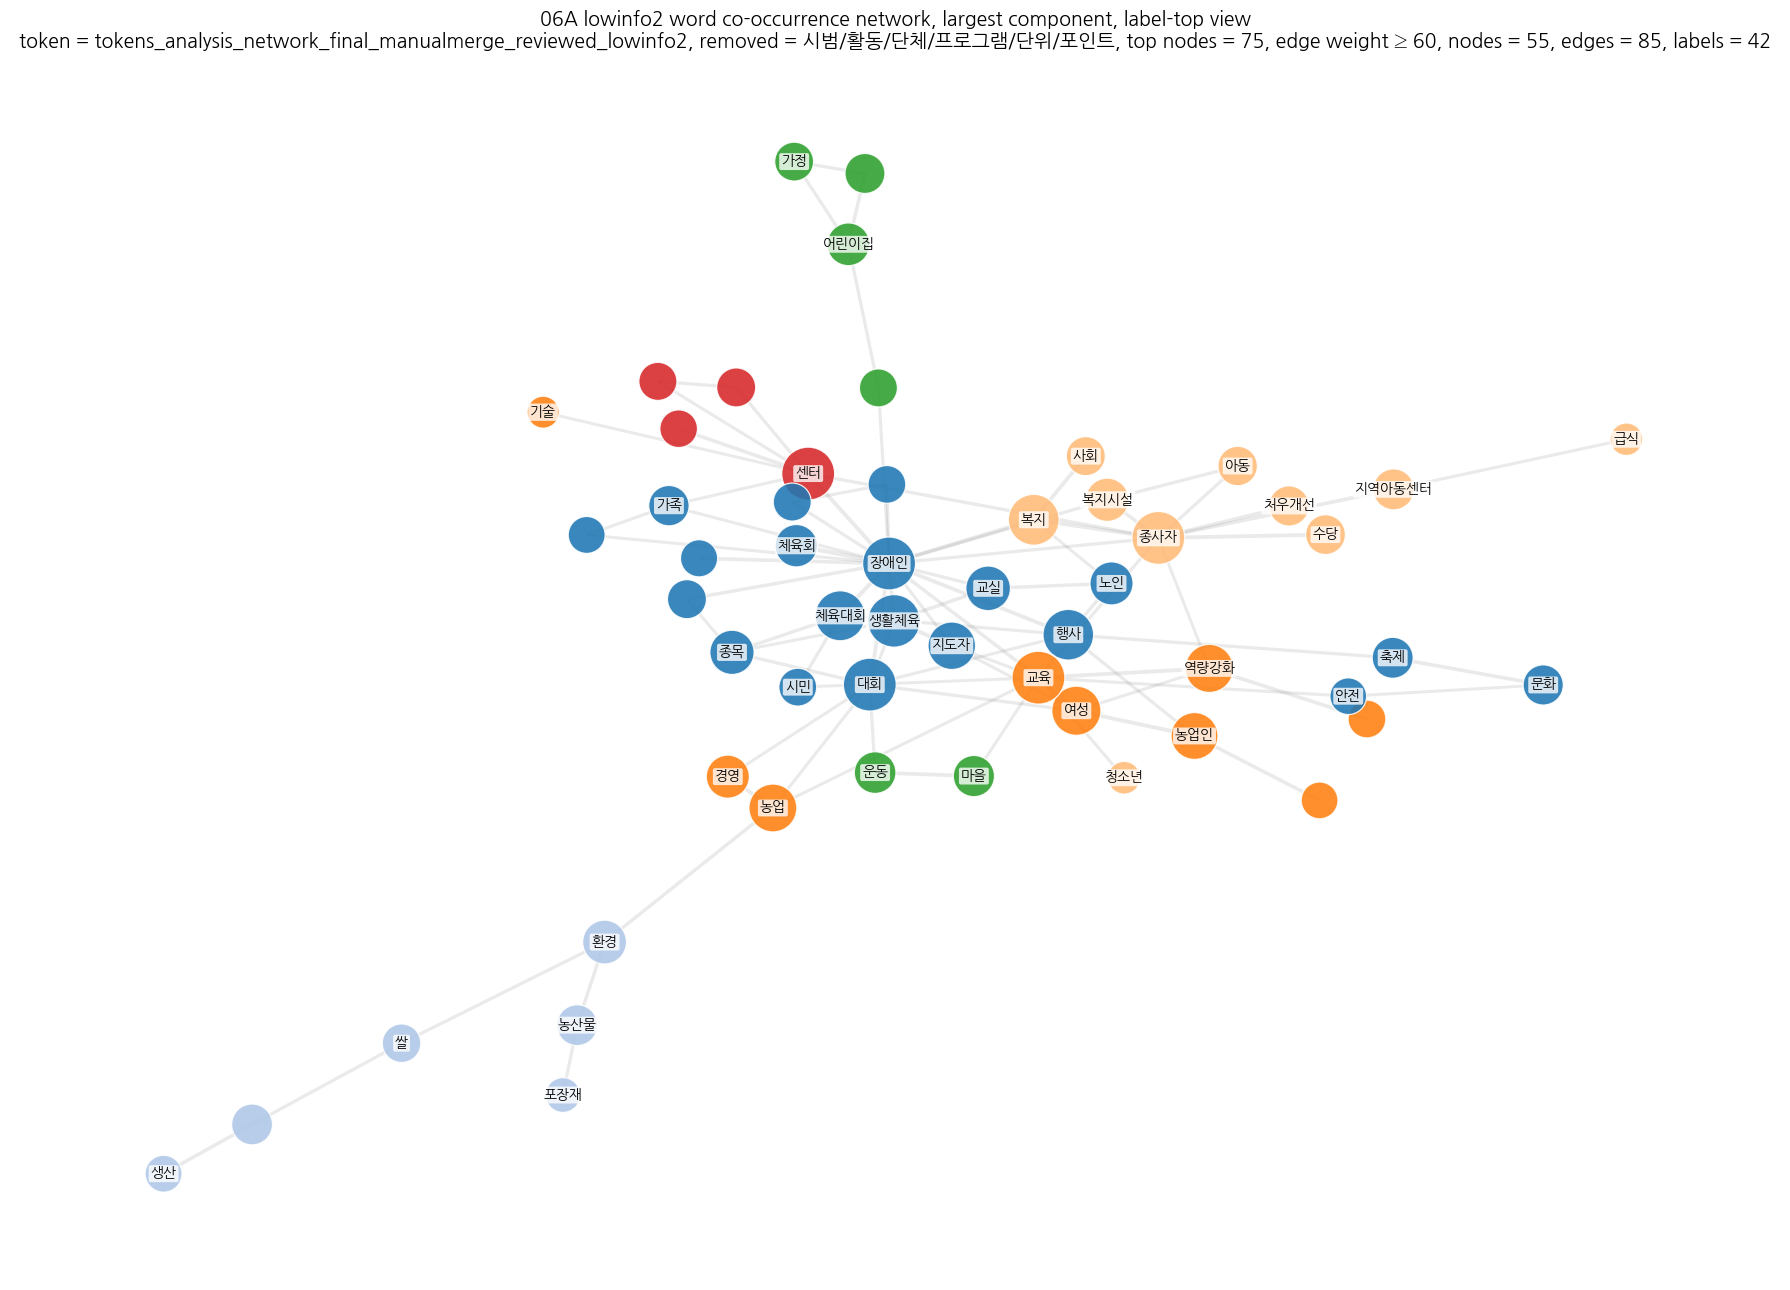


06A-APPEND-3I 완료


In [29]:
# 06A-APPEND-3I. lowinfo2 largest label-top 시각화
# 목적:
# - 06A-APPEND-2I에서 만든 lowinfo2_G_full을 시각화합니다.
# - largest component만 표시합니다.
# - 모든 노드는 표시하되, 라벨은 중심성 상위 노드만 표시합니다.
#
# 반영 내용:
# - 최신 수동 재결합표 20260611_2023 반영
# - 기본 저정보 토큰 제거
# - 추가 제거: 시범, 활동, 단체, 프로그램, 단위, 포인트
#
# 저장 파일:
# - 06A_lowinfo2_largest_labeltop_network_*.png
# - 06A_lowinfo2_largest_labeltop_component_summary_*.csv
# - 06A_lowinfo2_largest_labeltop_vis_nodes_*.csv

SAVE_OUTPUT = True
INSTALL_KOREAN_FONT = True

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
import subprocess
import shutil

print("SAVE_OUTPUT:", SAVE_OUTPUT)
print("INSTALL_KOREAN_FONT:", INSTALL_KOREAN_FONT)

# ------------------------------------------------------------
# 0) 입력 객체 확인
# ------------------------------------------------------------

if "lowinfo2_G_full" not in globals():
    raise NameError("lowinfo2_G_full이 없습니다. 06A-APPEND-2I를 먼저 실행하세요.")

if "lowinfo2_edge_df" not in globals():
    raise NameError("lowinfo2_edge_df가 없습니다. 06A-APPEND-2I를 먼저 실행하세요.")

if "lowinfo2_node_df" not in globals():
    raise NameError("lowinfo2_node_df가 없습니다. 06A-APPEND-2I를 먼저 실행하세요.")

if "LOWINFO2_TOKEN_COL" not in globals():
    LOWINFO2_TOKEN_COL = "tokens_analysis_network_final_manualmerge_reviewed_lowinfo2"

print("\n[현재 시각화 기준 토큰열]")
print(LOWINFO2_TOKEN_COL)

# ------------------------------------------------------------
# 1) 저장 경로 및 실행 시각
# ------------------------------------------------------------

if "RUN_VERSION" not in globals():
    RUN_VERSION = "v1"

RUN_TS_LOWINFO2_VIS = datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M")

if "FIGURE_REVIEW_DIR" not in globals():
    FIGURE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "figures"
        / "review"
    )

if "TABLE_REVIEW_DIR" not in globals():
    TABLE_REVIEW_DIR = (
        PROJECT_ROOT
        / "03_중간결과표"
        / "06A_v1_단어동시출현네트워크"
        / "tables"
        / "review"
    )

if SAVE_OUTPUT:
    FIGURE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

print("\n[저장 경로]")
print("FIGURE_REVIEW_DIR:", FIGURE_REVIEW_DIR)
print("TABLE_REVIEW_DIR:", TABLE_REVIEW_DIR)
print("RUN_TS_LOWINFO2_VIS:", RUN_TS_LOWINFO2_VIS)

# ------------------------------------------------------------
# 2) 시각화 설정
# ------------------------------------------------------------

LOWINFO2_VIS_TOP_N_NODES = 75
LOWINFO2_VIS_MIN_EDGE_WEIGHT = 60

SHOW_ALL_LABELS = False
LOWINFO2_LABEL_TOP_N = 42

LOWINFO2_FIGSIZE = (18, 13)
LOWINFO2_SEED = 42

print("\n[lowinfo2 시각화 기준]")
print("LOWINFO2_VIS_TOP_N_NODES:", LOWINFO2_VIS_TOP_N_NODES)
print("LOWINFO2_VIS_MIN_EDGE_WEIGHT:", LOWINFO2_VIS_MIN_EDGE_WEIGHT)
print("SHOW_ALL_LABELS:", SHOW_ALL_LABELS)
print("LOWINFO2_LABEL_TOP_N:", LOWINFO2_LABEL_TOP_N)

# ------------------------------------------------------------
# 3) 한글 폰트 설정
# ------------------------------------------------------------

def find_korean_font_path():
    candidate_paths = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumSquare.ttf",
        "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
        "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
        "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
    ]

    for fp in candidate_paths:
        if Path(fp).exists():
            return Path(fp)

    for root in [Path("/usr/share/fonts"), Path("/content")]:
        if not root.exists():
            continue

        for pattern in [
            "*Nanum*Gothic*.ttf",
            "*Nanum*Barun*.ttf",
            "*Nanum*.ttf",
            "*NotoSansCJK*.ttc",
            "*NotoSansCJK*.otf",
        ]:
            found = list(root.rglob(pattern))

            if len(found) > 0:
                return found[0]

    return None


font_path = find_korean_font_path()

if font_path is None and INSTALL_KOREAN_FONT:
    print("\n한글 폰트가 없어 fonts-nanum을 설치합니다.")
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], check=False)

    cache_dir = Path.home() / ".cache" / "matplotlib"
    if cache_dir.exists():
        shutil.rmtree(cache_dir, ignore_errors=True)

    fm.fontManager = fm.FontManager()
    font_path = find_korean_font_path()

if font_path is None:
    raise FileNotFoundError("한글 폰트를 찾지 못했습니다.")

font_prop = fm.FontProperties(fname=str(font_path))
font_name = font_prop.get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("\n[한글 폰트]")
print("font_path:", font_path)
print("font_name:", font_name)

# ------------------------------------------------------------
# 4) 전체 lowinfo2_G_full 기준 community detection
# ------------------------------------------------------------

lowinfo2_communities_full = list(
    nx.algorithms.community.greedy_modularity_communities(
        lowinfo2_G_full,
        weight="weight"
    )
)

lowinfo2_node_to_community = {}

for community_id, community_nodes in enumerate(lowinfo2_communities_full):
    for node in community_nodes:
        lowinfo2_node_to_community[node] = community_id

lowinfo2_community_count = len(lowinfo2_communities_full)

print("\n[전체 lowinfo2_G_full 기준 커뮤니티]")
print("lowinfo2_G_full node 수:", lowinfo2_G_full.number_of_nodes())
print("lowinfo2_G_full edge 수:", lowinfo2_G_full.number_of_edges())
print("community 수:", lowinfo2_community_count)

# ------------------------------------------------------------
# 5) 시각화 후보 graph 생성
# ------------------------------------------------------------

lowinfo2_node_df_for_plot = lowinfo2_node_df.copy()

lowinfo2_node_df_for_plot["community_id"] = lowinfo2_node_df_for_plot["word"].map(
    lowinfo2_node_to_community
).fillna(-1).astype(int)

lowinfo2_top_nodes = set(
    lowinfo2_node_df_for_plot
    .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
    .head(LOWINFO2_VIS_TOP_N_NODES)["word"]
)

lowinfo2_vis_edge_df = lowinfo2_edge_df[
    (lowinfo2_edge_df["weight"] >= LOWINFO2_VIS_MIN_EDGE_WEIGHT)
    & lowinfo2_edge_df["source"].isin(lowinfo2_top_nodes)
    & lowinfo2_edge_df["target"].isin(lowinfo2_top_nodes)
].copy()

lowinfo2_candidate_G = nx.Graph()

for _, row in lowinfo2_vis_edge_df.iterrows():
    lowinfo2_candidate_G.add_edge(
        row["source"],
        row["target"],
        weight=float(row["weight"])
    )

lowinfo2_candidate_G.remove_nodes_from(list(nx.isolates(lowinfo2_candidate_G)))

if lowinfo2_candidate_G.number_of_nodes() == 0:
    raise ValueError("시각화할 노드가 없습니다. edge weight 기준을 낮춰보세요.")

# ------------------------------------------------------------
# 6) largest component 선택
# ------------------------------------------------------------

components = list(nx.connected_components(lowinfo2_candidate_G))

component_rows = []

for idx, comp in enumerate(components):
    sub_g = lowinfo2_candidate_G.subgraph(comp).copy()
    edge_weight_sum = sum(
        data.get("weight", 1)
        for _, _, data in sub_g.edges(data=True)
    )

    component_rows.append({
        "component_raw_id": idx,
        "node_count": sub_g.number_of_nodes(),
        "edge_count": sub_g.number_of_edges(),
        "edge_weight_sum": edge_weight_sum,
        "top_nodes": ", ".join(
            lowinfo2_node_df_for_plot[
                lowinfo2_node_df_for_plot["word"].isin(comp)
            ]
            .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
            ["word"]
            .head(20)
            .tolist()
        )
    })

lowinfo2_component_summary_df = (
    pd.DataFrame(component_rows)
    .sort_values(["node_count", "edge_weight_sum"], ascending=[False, False])
    .reset_index(drop=True)
)

print("\n[component 요약]")
display(lowinfo2_component_summary_df)

largest_component_raw_id = lowinfo2_component_summary_df.iloc[0]["component_raw_id"]
selected_nodes = set(components[int(largest_component_raw_id)])

lowinfo2_G_vis = lowinfo2_candidate_G.subgraph(selected_nodes).copy()

print("\n[선택된 largest component graph]")
print("node 수:", lowinfo2_G_vis.number_of_nodes())
print("edge 수:", lowinfo2_G_vis.number_of_edges())
print("선택 component raw id:", largest_component_raw_id)

# ------------------------------------------------------------
# 7) layout 계산
# ------------------------------------------------------------

lowinfo2_pos = nx.spring_layout(
    lowinfo2_G_vis,
    seed=LOWINFO2_SEED,
    weight="weight",
    k=1.45 / np.sqrt(max(lowinfo2_G_vis.number_of_nodes(), 1)),
    iterations=500
)

# ------------------------------------------------------------
# 8) 노드 크기, 엣지 굵기, 색상
# ------------------------------------------------------------

lowinfo2_weighted_degree_vis = dict(
    lowinfo2_G_vis.degree(weight="weight")
)

lowinfo2_node_sizes = []

for node in lowinfo2_G_vis.nodes():
    wd = lowinfo2_weighted_degree_vis.get(node, 1)
    size = 150 + np.sqrt(wd) * 48
    size = max(210, min(size, 1450))
    lowinfo2_node_sizes.append(size)

lowinfo2_edge_weights = [
    lowinfo2_G_vis[u][v]["weight"]
    for u, v in lowinfo2_G_vis.edges()
]

lowinfo2_edge_widths = [
    max(0.35, min(np.log1p(w) / 1.9, 3.2))
    for w in lowinfo2_edge_weights
]

cmap = plt.get_cmap("tab20", max(lowinfo2_community_count, 1))

lowinfo2_node_colors = []

for node in lowinfo2_G_vis.nodes():
    community_id = lowinfo2_node_to_community.get(node, -1)

    if community_id == -1:
        lowinfo2_node_colors.append((0.6, 0.6, 0.6, 1.0))
    else:
        lowinfo2_node_colors.append(cmap(community_id))

# ------------------------------------------------------------
# 9) 라벨 표시 대상
# ------------------------------------------------------------

if SHOW_ALL_LABELS:
    lowinfo2_label_nodes = set(lowinfo2_G_vis.nodes())
else:
    lowinfo2_label_nodes = set(
        lowinfo2_node_df_for_plot[
            lowinfo2_node_df_for_plot["word"].isin(lowinfo2_G_vis.nodes())
        ]
        .sort_values(["weighted_degree", "doc_freq_unique"], ascending=[False, False])
        .head(LOWINFO2_LABEL_TOP_N)["word"]
    )

LOWINFO2_FONT_SIZE = 10 if not SHOW_ALL_LABELS else 9

lowinfo2_labels = {
    node: node
    for node in lowinfo2_G_vis.nodes()
    if node in lowinfo2_label_nodes
}

print("\n[라벨 표시]")
print("전체 노드 수:", lowinfo2_G_vis.number_of_nodes())
print("표시 라벨 수:", len(lowinfo2_labels))

# ------------------------------------------------------------
# 10) 시각화 포함 노드 표
# ------------------------------------------------------------

lowinfo2_vis_node_rows = []

for node in lowinfo2_G_vis.nodes():
    lowinfo2_vis_node_rows.append({
        "word": node,
        "community_id": lowinfo2_node_to_community.get(node, -1),
        "doc_freq_unique": lowinfo2_G_full.nodes[node].get("doc_freq_unique", None),
        "weighted_degree_in_vis": lowinfo2_G_vis.degree(node, weight="weight"),
        "label_shown": node in lowinfo2_label_nodes
    })

lowinfo2_vis_node_df = (
    pd.DataFrame(lowinfo2_vis_node_rows)
    .sort_values(["label_shown", "community_id", "weighted_degree_in_vis"], ascending=[False, True, False])
    .reset_index(drop=True)
)

print("\n[시각화 포함 노드]")
display(lowinfo2_vis_node_df)

# ------------------------------------------------------------
# 11) 그림 생성
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=LOWINFO2_FIGSIZE)

nx.draw_networkx_edges(
    lowinfo2_G_vis,
    lowinfo2_pos,
    width=lowinfo2_edge_widths,
    alpha=0.16,
    edge_color="gray",
    ax=ax
)

nx.draw_networkx_nodes(
    lowinfo2_G_vis,
    lowinfo2_pos,
    node_size=lowinfo2_node_sizes,
    alpha=0.88,
    node_color=lowinfo2_node_colors,
    edgecolors="white",
    linewidths=0.9,
    ax=ax
)

label_font_prop = fm.FontProperties(fname=str(font_path), size=LOWINFO2_FONT_SIZE)
title_font_prop = fm.FontProperties(fname=str(font_path), size=14)

for node, label in lowinfo2_labels.items():
    x, y = lowinfo2_pos[node]

    ax.text(
        x,
        y,
        label,
        fontsize=LOWINFO2_FONT_SIZE,
        fontproperties=label_font_prop,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14"
        ),
        zorder=10
    )

ax.set_title(
    "06A lowinfo2 word co-occurrence network, largest component, label-top view\n"
    f"token = {LOWINFO2_TOKEN_COL}, "
    f"removed = 시범/활동/단체/프로그램/단위/포인트, "
    f"top nodes = {LOWINFO2_VIS_TOP_N_NODES}, "
    f"edge weight ≥ {LOWINFO2_VIS_MIN_EDGE_WEIGHT}, "
    f"nodes = {lowinfo2_G_vis.number_of_nodes()}, "
    f"edges = {lowinfo2_G_vis.number_of_edges()}, "
    f"labels = {len(lowinfo2_labels)}",
    fontproperties=title_font_prop
)

ax.axis("off")
plt.tight_layout()

if SAVE_OUTPUT:
    out_png_lowinfo2 = (
        FIGURE_REVIEW_DIR
        / f"06A_lowinfo2_largest_labeltop_network_{RUN_VERSION}_{RUN_TS_LOWINFO2_VIS}.png"
    )

    out_component_lowinfo2 = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo2_largest_labeltop_component_summary_{RUN_VERSION}_{RUN_TS_LOWINFO2_VIS}.csv"
    )

    out_vis_node_lowinfo2 = (
        TABLE_REVIEW_DIR
        / f"06A_lowinfo2_largest_labeltop_vis_nodes_{RUN_VERSION}_{RUN_TS_LOWINFO2_VIS}.csv"
    )

    plt.savefig(out_png_lowinfo2, dpi=260, bbox_inches="tight")

    lowinfo2_component_summary_df.to_csv(
        out_component_lowinfo2,
        index=False,
        encoding="utf-8-sig"
    )

    lowinfo2_vis_node_df.to_csv(
        out_vis_node_lowinfo2,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n[lowinfo2 largest label-top 시각화 저장 완료]")
    print("- PNG:", out_png_lowinfo2)
    print("- component summary:", out_component_lowinfo2)
    print("- vis nodes:", out_vis_node_lowinfo2)

plt.show()

print("\n06A-APPEND-3I 완료")